In [5]:
print("Kernel check:", "alive")

Kernel check: alive


In [6]:
## cell 1
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
## cell 2
#from google.colab import drive

#drive.mount('/content/drive')

In [7]:
## cell 3
# ============================================================
# Kaggle Project Directory
# ============================================================

import os

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

folders = [
    "data",
    "models/original",
    "models/oracle",
    "models/unlearned",
    "results/behavioral",
    "results/mia",
    "results/output_similarity",
    "results/representation",
    "figures"
]

for folder in folders:
    os.makedirs(
        os.path.join(PROJECT_DIR, folder),
        exist_ok=True
    )

print("PROJECT_DIR:", PROJECT_DIR)
print("Project folders created successfully.")

PROJECT_DIR: /kaggle/working/Machine_Unlearning_Research
Project folders created successfully.


In [8]:
## cell 4
# 0. Research Configuration & Reproducibility
# ============================================================
# RESEARCH CONFIGURATION
# Evaluating the Consistency of Machine Unlearning
# Verification Under Varying Forgetting Conditions
# ============================================================

SEED = 42

DATASET = "CIFAR10"
MODEL_NAME = "ResNet18"

# Forget-set sizes
FORGET_SIZES = {
    "small": 1,   # 1 forgotten class
    "large": 2    # 2 forgotten classes
}

# Forgetting difficulty
DIFFICULTY_LEVELS = [
    "easy",
    "hard"
]

# Unlearning methods
METHODS = [
    "GA_FT",
    "SalUn"
]

# Number of random seeds
NUM_SEEDS = 3

# Verification evidence
VERIFICATION_METRICS = [
    "forget_accuracy",
    "retain_accuracy",
    "overall_accuracy",
    "mia_auc",
    "forget_js",
    "retain_js",
    "forget_cka",
    "retain_cka"
]

print("Research configuration loaded.")
print()
print("Dataset:", DATASET)
print("Model:", MODEL_NAME)
print("Forget sizes:", FORGET_SIZES)
print("Difficulty levels:", DIFFICULTY_LEVELS)
print("Methods:", METHODS)
print("Number of seeds:", NUM_SEEDS)
print()
print("Total unlearning runs:",
      len(FORGET_SIZES) *
      len(DIFFICULTY_LEVELS) *
      len(METHODS) *
      NUM_SEEDS)

Research configuration loaded.

Dataset: CIFAR10
Model: ResNet18
Forget sizes: {'small': 1, 'large': 2}
Difficulty levels: ['easy', 'hard']
Methods: ['GA_FT', 'SalUn']
Number of seeds: 3

Total unlearning runs: 24


In [9]:
## cell 5
SEEDS = [42, 123, 2026]

print("Experimental seeds:", SEEDS)

Experimental seeds: [42, 123, 2026]


In [10]:
## cell 6
## Reproducibility function
import random
import numpy as np
import torch

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"Random seed set to: {seed}")

set_seed(SEED)

Random seed set to: 42


In [11]:
## cell 7
## Install/check the libraries
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
NumPy: 2.0.2
Pandas: 2.3.3
Matplotlib: 3.10.0
Scikit-learn: 1.6.1


Below 2 cells are to find where the actually cifar-10 dataset was cuz not abe to find the correct path for "## cell 8" to run and give o/p.

In [12]:
import os

print("Folders/files directly under /kaggle/input:\n")

for item in os.listdir("/kaggle/input"):
    print(item)

Folders/files directly under /kaggle/input:

datasets


In [13]:
import os

print("Inside /kaggle/input/datasets:\n")

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    print("FOLDER:", root)

    for file in files:
        print("   FILE:", file)

Inside /kaggle/input/datasets:

FOLDER: /kaggle/input/datasets
FOLDER: /kaggle/input/datasets/shivanikawade
FOLDER: /kaggle/input/datasets/shivanikawade/cifar-10-python-tar-gz
FOLDER: /kaggle/input/datasets/shivanikawade/cifar-10-python-tar-gz/cifar-10-batches-py
   FILE: data_batch_1
   FILE: data_batch_2
   FILE: batches.meta
   FILE: test_batch
   FILE: data_batch_3
   FILE: data_batch_5
   FILE: data_batch_4
   FILE: readme.html
FOLDER: /kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth
   FILE: resnet18_cifar10_original.pth


In [15]:
## cell 8
from torchvision import datasets, transforms
import os

KAGGLE_CIFAR_ROOT = "/kaggle/working/cifar10_data"
os.makedirs(KAGGLE_CIFAR_ROOT, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

train_set = datasets.CIFAR10(
    root=KAGGLE_CIFAR_ROOT,
    train=True,
    download=True,
    transform=transform
)

test_set = datasets.CIFAR10(
    root=KAGGLE_CIFAR_ROOT,
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [41:03<00:00, 69.2kB/s] 


In [16]:
## cell 9
## Verify the class distribution
from collections import Counter

train_counts = Counter(train_set.targets)
test_counts = Counter(test_set.targets)

print("Training distribution:")
for class_id, count in train_counts.items():
    print(f"{class_id}: {train_set.classes[class_id]:10s} -> {count}")

print("\nTest distribution:")
for class_id, count in test_counts.items():
    print(f"{class_id}: {test_set.classes[class_id]:10s} -> {count}")

Training distribution:
6: frog       -> 5000
9: truck      -> 5000
4: deer       -> 5000
1: automobile -> 5000
2: bird       -> 5000
7: horse      -> 5000
8: ship       -> 5000
3: cat        -> 5000
5: dog        -> 5000
0: airplane   -> 5000

Test distribution:
3: cat        -> 1000
8: ship       -> 1000
0: airplane   -> 1000
6: frog       -> 1000
1: automobile -> 1000
9: truck      -> 1000
5: dog        -> 1000
7: horse      -> 1000
4: deer       -> 1000
2: bird       -> 1000


In [18]:
## cell 10
## Research configuration and restart-safe dataset setup

import os
import torch
import numpy as np
import random

from torchvision import datasets, transforms

# --------------------------------------------------
# RESEARCH CONFIGURATION
# --------------------------------------------------

SEED = 42

DATASET = "CIFAR10"
MODEL_NAME = "ResNet18"

# --------------------------------------------------
# REPRODUCIBILITY
# --------------------------------------------------

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# --------------------------------------------------
# DEVICE
# --------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

# --------------------------------------------------
# CIFAR-10 TRANSFORM
# --------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

# --------------------------------------------------
# train_set / test_set already loaded in cell 8 — reused here
# --------------------------------------------------

print("Restart-safe dataset setup complete.")
print()
print(f"Device: {device}")
print(f"Training samples: {len(train_set)}")
print(f"Test samples: {len(test_set)}")
print(f"Classes: {train_set.classes}")

Restart-safe dataset setup complete.

Device: cuda
Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [19]:
## cell 11
from torch.utils.data import random_split

split_generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset = random_split(
    train_set,
    [45000, 5000],
    generator=split_generator
)

print("Training/validation split created.")
print(f"Training samples:   {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples:       {len(test_set)}")

Training/validation split created.
Training samples:   45000
Validation samples: 5000
Test samples:       10000


In [21]:
# cell part of 12 below
# Research forget-set sizes

FORGET_SIZES = {
    "small": 1,
    "large": 2
}

print("FORGET_SIZES:", FORGET_SIZES)

FORGET_SIZES: {'small': 1, 'large': 2}


In [22]:
## cell 12
## Verify the research percentages
total_train = len(train_set)

for name, num_classes in FORGET_SIZES.items():
    forgotten_samples = num_classes * 5000
    percentage = forgotten_samples / total_train * 100

    print(
        f"{name}: {num_classes} class(es) -> "
        f"{forgotten_samples} samples -> "
        f"{percentage:.1f}% of training data"
    )

small: 1 class(es) -> 5000 samples -> 10.0% of training data
large: 2 class(es) -> 10000 samples -> 20.0% of training data


In [23]:
## part of cell 13 below
# Research training configuration

BATCH_SIZE = 128
NUM_EPOCHS = 100
LEARNING_RATE = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
NUM_WORKERS = 2

print("Training configuration restored.")
print(f"Batch size:       {BATCH_SIZE}")
print(f"Epochs:            {NUM_EPOCHS}")
print(f"Learning rate:     {LEARNING_RATE}")
print(f"Momentum:          {MOMENTUM}")
print(f"Weight decay:      {WEIGHT_DECAY}")
print(f"Num workers:       {NUM_WORKERS}")

Training configuration restored.
Batch size:       128
Epochs:            100
Learning rate:     0.1
Momentum:          0.9
Weight decay:      0.0005
Num workers:       2


In [24]:
## cell 13
## DataLoader cell
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders created.")
print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

DataLoaders created.
Training batches:   352
Validation batches: 40
Test batches:       79


In [51]:
## cell 14
## Model Architecture — CIFAR-10 ResNet-18

In [25]:
## cell 15
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [26]:
## cell 16
## Step 12 — Standardized CIFAR-10 ResNet-18
import torch
import torch.nn as nn
import torch.nn.functional as F


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = F.relu(out)

        return out


class ResNet18CIFAR10(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        # CIFAR-10 adapted stem
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(
            64, 2, stride=1
        )

        self.layer2 = self._make_layer(
            128, 2, stride=2
        )

        self.layer3 = self._make_layer(
            256, 2, stride=2
        )

        self.layer4 = self._make_layer(
            512, 2, stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(
            512,
            num_classes
        )

    def _make_layer(
        self,
        out_channels,
        blocks,
        stride
    ):

        strides = [stride] + [1] * (blocks - 1)

        layers = []

        for stride_value in strides:

            layers.append(
                BasicBlock(
                    self.in_channels,
                    out_channels,
                    stride_value
                )
            )

            self.in_channels = out_channels

        return nn.Sequential(*layers)

    def forward(self, x, return_features=False):

        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        features = torch.flatten(x, 1)

        logits = self.fc(features)

        if return_features:
            return logits, features

        return logits

In [27]:
## cell 17
model = ResNet18CIFAR10(num_classes=10).to(device)

print("Model created successfully.")
print(f"Device: {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created successfully.
Device: cuda
Total parameters: 11,173,962


In [28]:
## cell 18
## Loss, Optimizer and Scheduler
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)

print("Loss, optimizer and scheduler configured.")
print(f"Optimizer: SGD")
print(f"Initial learning rate: {LEARNING_RATE}")
print(f"Momentum: {MOMENTUM}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Scheduler: CosineAnnealingLR")
print(f"Scheduler epochs: {NUM_EPOCHS}")

Loss, optimizer and scheduler configured.
Optimizer: SGD
Initial learning rate: 0.1
Momentum: 0.9
Weight decay: 0.0005
Scheduler: CosineAnnealingLR
Scheduler epochs: 100


In [29]:
## cell 19
## Training function
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total

In [30]:
## cell 20
## Evaluation function
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total

In [31]:
## cell 21
## train_one_epoch()
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total

In [32]:
## cell 22
## evaluate() function:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return running_loss / total, 100.0 * correct / total

## this cell is markdown cuz already have the file that this cell produces and also running this cell take 70 mints and done it in colab already
## cell 23
## 4.3 — Train the Original ResNet-18
import time

# --------------------------------------------------
# Training history
# --------------------------------------------------

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

best_val_accuracy = 0.0
best_epoch = 0

print("Starting original ResNet-18 training...")
print()

start_time = time.time()

# --------------------------------------------------
# Training loop
# --------------------------------------------------

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # Current learning rate before scheduler update
    current_lr = optimizer.param_groups[0]["lr"]

    # -----------------------------
    # Training
    # -----------------------------
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -----------------------------
    # Validation
    # -----------------------------
    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    # Update learning rate
    scheduler.step()

    # -----------------------------
    # Store history
    # -----------------------------
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    history["learning_rate"].append(current_lr)

    # -----------------------------
    # Save best model
    # -----------------------------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "val_accuracy": val_accuracy,
                "epoch": epoch + 1,
                "history": history,
                "config": {
                    "dataset": DATASET,
                    "model": MODEL_NAME,
                    "batch_size": BATCH_SIZE,
                    "epochs": NUM_EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "momentum": MOMENTUM,
                    "weight_decay": WEIGHT_DECAY,
                    "seed": SEED
                }
            },
            ORIGINAL_MODEL_PATH
        )

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch+1:03d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.2f}% | "
        f"LR: {current_lr:.5f} | "
        f"Time: {epoch_time:.1f}s"
    )

# --------------------------------------------------
# Training completed
# --------------------------------------------------

total_time = time.time() - start_time

print()
print("=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")
print(f"Best epoch: {best_epoch}")
print(f"Total training time: {total_time/60:.2f} minutes")
print(f"Best model saved to:")
print(ORIGINAL_MODEL_PATH)

In [33]:
## small diagnostic cell
## this cell is to check the ".pth" file that is uploaded in kaggle by me, 
## which that above 23rd cell code is supposed to create after 70 mints of running time.
import os

print("Searching Kaggle Input for the original checkpoint...\n")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file == "resnet18_cifar10_original.pth":
            full_path = os.path.join(root, file)
            print("FOUND:")
            print(full_path)
            print()
            print("File size:", os.path.getsize(full_path), "bytes")

Searching Kaggle Input for the original checkpoint...

FOUND:
/kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth

File size: 44781195 bytes


In [34]:
## define the Kaggle project paths bcuz that drive paths won't work in kaggle
# Kaggle project paths

import os

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

ORIGINAL_MODEL_PATH = (
    "/kaggle/input/datasets/skawade/"
    "resnet18-cifar10-original-pth/"
    "resnet18_cifar10_original.pth"
)

# Create our working project folders
os.makedirs(os.path.join(PROJECT_DIR, "models", "original"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "models", "oracle"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "models", "unlearned"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "results", "behavioral"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "results", "mia"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "results", "output_similarity"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "results", "representation"), exist_ok=True)
os.makedirs(os.path.join(PROJECT_DIR, "figures"), exist_ok=True)

print("Kaggle project paths configured.")
print("PROJECT_DIR:", PROJECT_DIR)
print("Original checkpoint:", ORIGINAL_MODEL_PATH)
print("Checkpoint exists:", os.path.exists(ORIGINAL_MODEL_PATH))

Kaggle project paths configured.
PROJECT_DIR: /kaggle/working/Machine_Unlearning_Research
Original checkpoint: /kaggle/input/datasets/skawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth
Checkpoint exists: False


In [36]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))

/kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth


In [38]:
ORIGINAL_MODEL_PATH = "/kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth"

checkpoint = torch.load(
    ORIGINAL_MODEL_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

print("Original model checkpoint loaded successfully.")
print(f"Checkpoint epoch: {checkpoint['epoch']}")
print(f"Best validation accuracy: {checkpoint['val_accuracy']:.2f}%")

Original model checkpoint loaded successfully.
Checkpoint epoch: 78
Best validation accuracy: 88.02%


In [39]:
## verify the actual test performance
## Now we should make sure the loaded checkpoint produces the expected 87.28% 
## test accuracy on the Kaggle CIFAR-10 dataset.

# Verify the loaded original model on the CIFAR-10 test set

test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("Original model verification")
print("-" * 50)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2f}%")

Original model verification
--------------------------------------------------
Test loss:     0.4160
Test accuracy: 87.28%


In [40]:
## cell 24
## test the model
dummy_input = torch.randn(
    4, 3, 32, 32
).to(device)

with torch.no_grad():
    logits, features = model(
        dummy_input,
        return_features=True
    )

print("Input shape:", dummy_input.shape)
print("Logits shape:", logits.shape)
print("Feature shape:", features.shape)

Input shape: torch.Size([4, 3, 32, 32])
Logits shape: torch.Size([4, 10])
Feature shape: torch.Size([4, 512])


In [41]:
## cell 25
## Finally check parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 11,173,962
Trainable parameters: 11,173,962


## cell 26
**Step 13 — Original ResNet-18 Training**

This model is our baseline/original model.

It is extremely important because it becomes the starting point for:

GA+FT unlearning
SalUn unlearning
confusion-based difficulty definition
later comparison against retrained oracles
13.1 Add this notebook heading

Create a Markdown cell:

## 4. Original Model Training

Then another Markdown cell:

### 4.1 Training Configuration

In [57]:
## cell 27
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
## cell 28
import os

print(os.listdir("/content/drive/MyDrive"))

['Machine_Unlearning_Research', 'Colab Notebooks']


In [59]:
## cell 29
PROJECT_DIR = "/content/drive/MyDrive/Machine_Unlearning_Research"

print("PROJECT_DIR =", PROJECT_DIR)
print("Exists:", os.path.exists(PROJECT_DIR))

PROJECT_DIR = /content/drive/MyDrive/Machine_Unlearning_Research
Exists: True


In [138]:
## cell 30
## 13.2 Lock the training configuration
BATCH_SIZE = 128
NUM_EPOCHS = 100

LEARNING_RATE = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4

NUM_WORKERS = 2

ORIGINAL_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "original",
    "resnet18_cifar10_original.pth"
)

print("Training configuration locked.")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Momentum: {MOMENTUM}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Workers: {NUM_WORKERS}")
print(f"Model save path: {ORIGINAL_MODEL_PATH}")

Training configuration locked.
Batch size: 128
Epochs: 100
Learning rate: 0.1
Momentum: 0.9
Weight decay: 0.0005
Workers: 2
Model save path: /kaggle/working/Machine_Unlearning_Research/models/original/resnet18_cifar10_original.pth


In [139]:
## cell 31
# Restore the fixed research configuration

SEED = 42

DATASET = "CIFAR10"
MODEL_NAME = "ResNet18"

FORGET_SIZES = {
    "small": 1,
    "large": 2
}

DIFFICULTY_LEVELS = [
    "easy",
    "hard"
]

METHODS = [
    "GA_FT",
    "SalUn"
]

NUM_SEEDS = 3

print("Research configuration restored.")
print(f"Seed: {SEED}")
print(f"Dataset: {DATASET}")
print(f"Model: {MODEL_NAME}")
print(f"Forget sizes: {FORGET_SIZES}")
print(f"Difficulty levels: {DIFFICULTY_LEVELS}")
print(f"Methods: {METHODS}")
print(f"Number of seeds: {NUM_SEEDS}")

Research configuration restored.
Seed: 42
Dataset: CIFAR10
Model: ResNet18
Forget sizes: {'small': 1, 'large': 2}
Difficulty levels: ['easy', 'hard']
Methods: ['GA_FT', 'SalUn']
Number of seeds: 3


In [140]:
## cell 32
## Create a Reproducible Training/Validation Split
from torch.utils.data import random_split

# Reproducible train/validation split
split_generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset = random_split(
    train_set,
    [45000, 5000],
    generator=split_generator
)

print("Training/validation split created.")
print(f"Training samples:   {len(train_subset)}")
print(f"Validation samples: {len(val_subset)}")
print(f"Test samples:       {len(test_set)}")

Training/validation split created.
Training samples:   45000
Validation samples: 5000
Test samples:       10000


## cell 33
# 14. Original Model Test Evaluation

In [45]:
## Cell 34 — Load the best original checkpoint
# # 14.1 Load the Best Original Model
# ============================================================

import os
import torch

# ------------------------------------------------------------
# Kaggle checkpoint location
# ------------------------------------------------------------

ORIGINAL_MODEL_PATH = (
    "/kaggle/input/datasets/shivanikawade/"
    "resnet18-cifar10-original-pth/"
    "resnet18_cifar10_original.pth"
)

# ------------------------------------------------------------
# Verify checkpoint exists
# ------------------------------------------------------------

if not os.path.exists(ORIGINAL_MODEL_PATH):

    raise FileNotFoundError(
        "Original checkpoint not found at:\n"
        f"{ORIGINAL_MODEL_PATH}"
    )

print("Loading best original ResNet-18 checkpoint...")
print(f"Checkpoint path: {ORIGINAL_MODEL_PATH}")

# ------------------------------------------------------------
# Make sure model exists and is on the correct device
# ------------------------------------------------------------

model = model.to(device)

checkpoint = torch.load(
    ORIGINAL_MODEL_PATH,
    map_location=device
)

# ------------------------------------------------------------
# Restore original trained weights
# ------------------------------------------------------------

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print()
print("Best original model loaded successfully.")
print(
    f"Best validation accuracy: "
    f"{checkpoint['val_accuracy']:.2f}%"
)
print(
    f"Best epoch: "
    f"{checkpoint['epoch']}"
)
print()
print("Checkpoint path:")
print(ORIGINAL_MODEL_PATH)

Loading best original ResNet-18 checkpoint...
Checkpoint path: /kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth

Best original model loaded successfully.
Best validation accuracy: 88.02%
Best epoch: 78

Checkpoint path:
/kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth


In [46]:
## Cell 35 — Test-set evaluation
# ============================================================
# 14.2 Evaluate Original Model on the Test Set
# ============================================================

test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("=" * 60)
print("ORIGINAL MODEL - TEST SET RESULTS")
print("=" * 60)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print("=" * 60)

ORIGINAL MODEL - TEST SET RESULTS
Test Loss:     0.4160
Test Accuracy: 87.28%


In [47]:
## Cell 36 — Confusion matrix
# ============================================================
# 14.3 Generate Confusion Matrix
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class names
CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

all_predictions = []
all_targets = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

cm = confusion_matrix(
    all_targets,
    all_predictions,
    labels=list(range(len(CLASSES)))
)

print("Confusion matrix:")
print(cm)

Confusion matrix:
[[901   7  30   7   4   2   4   4  32   9]
 [  4 952   0   2   3   1   1   1   9  27]
 [ 37   1 825  27  41  23  31   9   5   1]
 [ 19   2  43 740  29 102  46  10   6   3]
 [ 13   2  39  37 849  16  20  21   3   0]
 [  3   0  34 113  23 795  11  18   2   1]
 [  4   0  21  33  18  10 911   0   2   1]
 [ 11   0  15  21  25  28   5 891   1   3]
 [ 30   8   4   4   1   1   3   0 938  11]
 [ 11  32   3   9   1   1   1   2  14 926]]


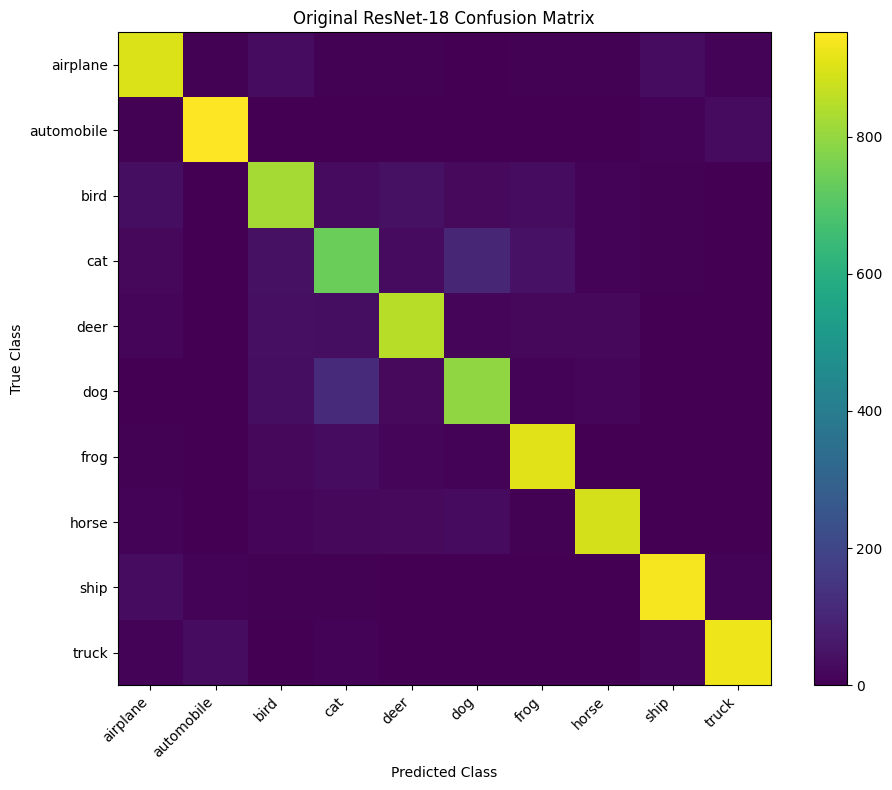

In [145]:
## visualization cell-37
plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.xticks(
    range(len(CLASSES)),
    CLASSES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(CLASSES)),
    CLASSES
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Original ResNet-18 Confusion Matrix")

plt.colorbar()

plt.tight_layout()
plt.show()

In [49]:
## cell 38- per-class accuracy
# ============================================================
# 14.4 Per-Class Test Accuracy
# ============================================================

print("=" * 60)
print("PER-CLASS TEST ACCURACY")
print("=" * 60)

for i, class_name in enumerate(CLASSES):

    total_samples = cm[i].sum()
    correct_samples = cm[i, i]

    class_accuracy = (
        correct_samples / total_samples * 100
        if total_samples > 0 else 0
    )

    print(
        f"{class_name:12s}: "
        f"{class_accuracy:6.2f}% "
        f"({correct_samples}/{total_samples})"
    )

PER-CLASS TEST ACCURACY
airplane    :  90.10% (901/1000)
automobile  :  95.20% (952/1000)
bird        :  82.50% (825/1000)
cat         :  74.00% (740/1000)
deer        :  84.90% (849/1000)
dog         :  79.50% (795/1000)
frog        :  91.10% (911/1000)
horse       :  89.10% (891/1000)
ship        :  93.80% (938/1000)
truck       :  92.60% (926/1000)


In [50]:
## cell 39- calculate difficulty scores automatically
# ============================================================
# 14.6 Calculate Forgetting Difficulty Scores
# ============================================================

import itertools
import pandas as pd

# ------------------------------------------------------------
# Difficulty definition:
#
# D(F) =
# misclassified samples from forgotten classes
# predicted as retained classes
# ------------------------------------------------------------

difficulty_results = []

num_classes = len(CLASSES)

# ------------------------------------------------------------
# 1. SINGLE-CLASS FORGETTING
# ------------------------------------------------------------

for forget_class in range(num_classes):

    retained_classes = [
        i for i in range(num_classes)
        if i != forget_class
    ]

    # Errors from the forgotten class into retained classes
    retained_confusion = sum(
        cm[forget_class, j]
        for j in retained_classes
    )

    total_forget_samples = cm[forget_class].sum()

    difficulty_score = (
        retained_confusion / total_forget_samples
    )

    difficulty_results.append({
        "forget_size": 1,
        "forget_classes": CLASSES[forget_class],
        "class_indices": (forget_class,),
        "difficulty_score": difficulty_score
    })


# ------------------------------------------------------------
# 2. TWO-CLASS FORGETTING
# ------------------------------------------------------------

for class_a, class_b in itertools.combinations(
    range(num_classes), 2
):

    forget_classes = {class_a, class_b}

    # Retained classes = all classes outside forget set
    retained_classes = [
        i for i in range(num_classes)
        if i not in forget_classes
    ]

    # Errors from forgotten classes INTO retained classes
    # Important:
    # confusion between the two forgotten classes is excluded.
    retained_confusion = sum(
        cm[i, j]
        for i in forget_classes
        for j in retained_classes
    )

    total_forget_samples = sum(
        cm[i].sum()
        for i in forget_classes
    )

    difficulty_score = (
        retained_confusion / total_forget_samples
    )

    difficulty_results.append({
        "forget_size": 2,
        "forget_classes": (
            f"{CLASSES[class_a]} + {CLASSES[class_b]}"
        ),
        "class_indices": (class_a, class_b),
        "difficulty_score": difficulty_score
    })


# ------------------------------------------------------------
# Convert to DataFrame
# ------------------------------------------------------------

difficulty_df = pd.DataFrame(difficulty_results)

# Percentage form for easier interpretation
difficulty_df["difficulty_percent"] = (
    difficulty_df["difficulty_score"] * 100
)

print("=" * 70)
print("FORGETTING DIFFICULTY ANALYSIS")
print("=" * 70)

print("\nSingle-class candidates:")
display(
    difficulty_df[
        difficulty_df["forget_size"] == 1
    ][
        ["forget_classes", "difficulty_percent"]
    ].sort_values(
        "difficulty_percent"
    )
)

print("\nTwo-class candidates:")
display(
    difficulty_df[
        difficulty_df["forget_size"] == 2
    ][
        ["forget_classes", "difficulty_percent"]
    ].sort_values(
        "difficulty_percent"
    ).head(10)
)

print("\nHighest two-class difficulty candidates:")
display(
    difficulty_df[
        difficulty_df["forget_size"] == 2
    ][
        ["forget_classes", "difficulty_percent"]
    ].sort_values(
        "difficulty_percent",
        ascending=False
    ).head(10)
)

FORGETTING DIFFICULTY ANALYSIS

Single-class candidates:


,forget_classes,difficulty_percent
1,automobile,4.8
8,ship,6.2
9,truck,7.4
6,frog,8.9
0,airplane,9.9
7,horse,10.9
4,deer,15.1
2,bird,17.5
5,dog,20.5
3,cat,26.0



Two-class candidates:


,forget_classes,difficulty_percent
26,automobile + truck,3.15
25,automobile + ship,4.65
17,airplane + ship,4.95
54,ship + truck,5.55
10,airplane + automobile,6.80
23,automobile + frog,6.80
50,frog + ship,7.30
18,airplane + truck,7.65
24,automobile + horse,7.80
51,frog + truck,8.05



Highest two-class difficulty candidates:


,forget_classes,difficulty_percent
27,bird + cat,18.25
34,cat + deer,17.25
37,cat + horse,16.90
12,airplane + cat,16.65
29,bird + dog,16.15
39,cat + truck,16.10
40,deer + dog,15.85
38,cat + ship,15.60
20,automobile + cat,15.20
14,airplane + dog,14.95


In [63]:
## Cell 40 — Freeze Experimental Conditions
# ============================================================
# 14.7 Freeze Experimental Forgetting Conditions
# ============================================================

import json
import os

# ------------------------------------------------------------
# Select conditions based ONLY on the original model
# difficulty analysis
# ------------------------------------------------------------

single_class_df = difficulty_df[
    difficulty_df["forget_size"] == 1
].copy()

two_class_df = difficulty_df[
    difficulty_df["forget_size"] == 2
].copy()

# Lowest difficulty = Easy
easy_single = single_class_df.sort_values(
    ["difficulty_score", "forget_classes"]
).iloc[0]

# Highest difficulty = Hard
hard_single = single_class_df.sort_values(
    ["difficulty_score", "forget_classes"],
    ascending=[False, True]
).iloc[0]

easy_two = two_class_df.sort_values(
    ["difficulty_score", "forget_classes"]
).iloc[0]

hard_two = two_class_df.sort_values(
    ["difficulty_score", "forget_classes"],
    ascending=[False, True]
).iloc[0]


# ------------------------------------------------------------
# Frozen research conditions
# ------------------------------------------------------------

FROZEN_CONDITIONS = {
    "small_easy": {
        "forget_size": 1,
        "difficulty": "easy",
        "forget_classes": easy_single["forget_classes"],
        "class_indices": list(easy_single["class_indices"]),
        "difficulty_score": float(easy_single["difficulty_score"])
    },

    "small_hard": {
        "forget_size": 1,
        "difficulty": "hard",
        "forget_classes": hard_single["forget_classes"],
        "class_indices": list(hard_single["class_indices"]),
        "difficulty_score": float(hard_single["difficulty_score"])
    },

    "large_easy": {
        "forget_size": 2,
        "difficulty": "easy",
        "forget_classes": easy_two["forget_classes"],
        "class_indices": list(easy_two["class_indices"]),
        "difficulty_score": float(easy_two["difficulty_score"])
    },

    "large_hard": {
        "forget_size": 2,
        "difficulty": "hard",
        "forget_classes": hard_two["forget_classes"],
        "class_indices": list(hard_two["class_indices"]),
        "difficulty_score": float(hard_two["difficulty_score"])
    }
}


# ------------------------------------------------------------
# Print frozen conditions
# ------------------------------------------------------------

print("=" * 70)
print("FROZEN EXPERIMENTAL CONDITIONS")
print("=" * 70)

for condition_name, condition in FROZEN_CONDITIONS.items():

    print(
        f"{condition_name:12s} | "
        f"{condition['forget_classes']:25s} | "
        f"Difficulty = "
        f"{condition['difficulty_score'] * 100:.2f}%"
    )

print("=" * 70)


# ------------------------------------------------------------
# Save conditions to Google Drive
# ------------------------------------------------------------

CONDITIONS_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "difficulty_selection.json"
)

with open(CONDITIONS_PATH, "w") as f:
    json.dump(FROZEN_CONDITIONS, f, indent=4)

print("\nFrozen conditions saved to:")
print(CONDITIONS_PATH)

## yet to run this cell bcuz run out of colab gpu limit

FROZEN EXPERIMENTAL CONDITIONS
small_easy   | automobile                | Difficulty = 4.80%
small_hard   | cat                       | Difficulty = 26.00%
large_easy   | automobile + truck        | Difficulty = 3.15%
large_hard   | bird + cat                | Difficulty = 18.25%

Frozen conditions saved to:
/kaggle/working/Machine_Unlearning_Research/results/difficulty_selection.json


# 6. MACHINE UNLEARNING EXPERIMENT SETUP

This section prepares the frozen forgetting conditions for the controlled
machine unlearning experiments.

The experiments evaluate two unlearning methods:

1. GA + Fine-Tuning (GA_FT)
2. SalUn

Each method is evaluated under:

- 2 forget-set sizes
- 2 forgetting difficulty levels
- 3 random seeds

This results in 24 unlearning runs.

The forgetting conditions are fixed using the original model's confusion
behavior and are not changed based on unlearning results.

In [88]:
## cell 41
# ============================================================
# 6.1 CREATE FORGET AND RETAIN DATASET INDICES
# ============================================================

import numpy as np

# Class name → class index
CLASS_TO_IDX = {
    name: idx for idx, name in enumerate(train_set.classes)
}

# ------------------------------------------------------------
# Create indices for every frozen experimental condition
# ------------------------------------------------------------

CONDITION_INDICES = {}

print("Frozen conditions loaded:")

for condition_name, condition in FROZEN_CONDITIONS.items():

    # Cell 40 stores class names as a string for single-class
    # conditions and as a combined string for two-class conditions.
    forget_classes_raw = condition["forget_classes"]

    # Convert the stored value into a consistent list
    if isinstance(forget_classes_raw, str):
        forget_class_names = [
            name.strip()
            for name in forget_classes_raw.split("+")
        ]
    else:
        forget_class_names = list(forget_classes_raw)

    # Convert class names → class IDs
    forget_class_ids = {
        CLASS_TO_IDX[name]
        for name in forget_class_names
    }

    print(
        f"{condition_name:12s} | "
        f"{' + '.join(forget_class_names):25s} | "
        f"Difficulty = {condition['difficulty_score'] * 100:.2f}%"
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # The original model was trained on train_subset
    # containing 45,000 samples.
    #
    # Therefore, unlearning uses only those same 45,000
    # training samples.
    # --------------------------------------------------------

    actual_train_indices = train_subset.indices

    forget_train_indices = [
        idx
        for idx in actual_train_indices
        if train_set.targets[idx] in forget_class_ids
    ]

    retain_train_indices = [
        idx
        for idx in actual_train_indices
        if train_set.targets[idx] not in forget_class_ids
    ]

    # --------------------------------------------------------
    # Test-set indices
    # --------------------------------------------------------

    forget_test_indices = [
        idx
        for idx, label in enumerate(test_set.targets)
        if label in forget_class_ids
    ]

    retain_test_indices = [
        idx
        for idx, label in enumerate(test_set.targets)
        if label not in forget_class_ids
    ]

    # Store everything
    CONDITION_INDICES[condition_name] = {
        "forget_classes": forget_class_names,
        "forget_class_ids": sorted(forget_class_ids),

        "forget_train_indices": forget_train_indices,
        "retain_train_indices": retain_train_indices,

        "forget_test_indices": forget_test_indices,
        "retain_test_indices": retain_test_indices,
    }


# ------------------------------------------------------------
# Display dataset sizes
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FORGET / RETAIN DATASET SIZES")
print("=" * 75)

for condition_name, data in CONDITION_INDICES.items():

    print(
        f"{condition_name:12s} | "
        f"Forget train: {len(data['forget_train_indices']):5d} | "
        f"Retain train: {len(data['retain_train_indices']):5d} | "
        f"Forget test:  {len(data['forget_test_indices']):5d} | "
        f"Retain test:  {len(data['retain_test_indices']):5d}"
    )

print("=" * 75)
for condition_name, data in CONDITION_INDICES.items():

    print(
        f"{condition_name:12s} | "
        f"Forget train: {len(data['forget_train_indices']):5d} | "
        f"Retain train: {len(data['retain_train_indices']):5d} | "
        f"Forget test:  {len(data['forget_test_indices']):5d} | "
        f"Retain test:  {len(data['retain_test_indices']):5d}"
    )

print("=" * 75)

Frozen conditions loaded:
small_easy   | automobile                | Difficulty = 4.80%
small_hard   | cat                       | Difficulty = 26.00%
large_easy   | automobile + truck        | Difficulty = 3.15%
large_hard   | bird + cat                | Difficulty = 18.25%

FORGET / RETAIN DATASET SIZES
small_easy   | Forget train:  4488 | Retain train: 40512 | Forget test:   1000 | Retain test:   9000
small_hard   | Forget train:  4529 | Retain train: 40471 | Forget test:   1000 | Retain test:   9000
large_easy   | Forget train:  8987 | Retain train: 36013 | Forget test:   2000 | Retain test:   8000
large_hard   | Forget train:  8997 | Retain train: 36003 | Forget test:   2000 | Retain test:   8000
small_easy   | Forget train:  4488 | Retain train: 40512 | Forget test:   1000 | Retain test:   9000
small_hard   | Forget train:  4529 | Retain train: 40471 | Forget test:   1000 | Retain test:   9000
large_easy   | Forget train:  8987 | Retain train: 36013 | Forget test:   2000 | Retain

In [65]:
## cell 42
## 6.2 — Create the actual datasets
# ============================================================
# 6.2 CREATE FORGET / RETAIN DATASETS
# ============================================================

from torch.utils.data import Subset

CONDITION_DATASETS = {}

for condition_name, data in CONDITION_INDICES.items():

    CONDITION_DATASETS[condition_name] = {

        # Training subsets
        "forget_train": Subset(
            train_set,
            data["forget_train_indices"]
        ),

        "retain_train": Subset(
            train_set,
            data["retain_train_indices"]
        ),

        # Test subsets
        "forget_test": Subset(
            test_set,
            data["forget_test_indices"]
        ),

        "retain_test": Subset(
            test_set,
            data["retain_test_indices"]
        )
    }


# ------------------------------------------------------------
# Verify dataset objects
# ------------------------------------------------------------

print("=" * 75)
print("FORGET / RETAIN DATASETS CREATED")
print("=" * 75)

for condition_name, datasets_dict in CONDITION_DATASETS.items():

    print(
        f"{condition_name:12s} | "
        f"Forget train: {len(datasets_dict['forget_train']):5d} | "
        f"Retain train: {len(datasets_dict['retain_train']):5d} | "
        f"Forget test:  {len(datasets_dict['forget_test']):5d} | "
        f"Retain test:  {len(datasets_dict['retain_test']):5d}"
    )

print("=" * 75)

FORGET / RETAIN DATASETS CREATED
small_easy   | Forget train:  4488 | Retain train: 40512 | Forget test:   1000 | Retain test:   9000
small_hard   | Forget train:  4529 | Retain train: 40471 | Forget test:   1000 | Retain test:   9000
large_easy   | Forget train:  8987 | Retain train: 36013 | Forget test:   2000 | Retain test:   8000
large_hard   | Forget train:  8997 | Retain train: 36003 | Forget test:   2000 | Retain test:   8000


In [66]:
## cell 43
## 6.3 — Create DataLoaders for Forget and Retain Sets
# ============================================================
# 6.3 CREATE FORGET / RETAIN DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

CONDITION_LOADERS = {}

for condition_name, datasets_dict in CONDITION_DATASETS.items():

    CONDITION_LOADERS[condition_name] = {

        # Training loaders
        "forget_train": DataLoader(
            datasets_dict["forget_train"],
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True
        ),

        "retain_train": DataLoader(
            datasets_dict["retain_train"],
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=True
        ),

        # Test loaders
        "forget_test": DataLoader(
            datasets_dict["forget_test"],
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True
        ),

        "retain_test": DataLoader(
            datasets_dict["retain_test"],
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True
        )
    }


# ------------------------------------------------------------
# Verify DataLoaders
# ------------------------------------------------------------

print("=" * 75)
print("FORGET / RETAIN DATALOADERS CREATED")
print("=" * 75)

for condition_name, loaders in CONDITION_LOADERS.items():

    print(
        f"{condition_name:12s} | "
        f"Forget train batches: {len(loaders['forget_train']):4d} | "
        f"Retain train batches: {len(loaders['retain_train']):4d} | "
        f"Forget test batches:  {len(loaders['forget_test']):4d} | "
        f"Retain test batches:  {len(loaders['retain_test']):4d}"
    )

print("=" * 75)

FORGET / RETAIN DATALOADERS CREATED
small_easy   | Forget train batches:   36 | Retain train batches:  317 | Forget test batches:     8 | Retain test batches:    71
small_hard   | Forget train batches:   36 | Retain train batches:  317 | Forget test batches:     8 | Retain test batches:    71
large_easy   | Forget train batches:   71 | Retain train batches:  282 | Forget test batches:    16 | Retain test batches:    63
large_hard   | Forget train batches:   71 | Retain train batches:  282 | Forget test batches:    16 | Retain test batches:    63


In [67]:
## cell 44
## 6.4 — Verify Forget/Retain Class Composition
# ============================================================
# 6.4 VERIFY FORGET / RETAIN CLASS COMPOSITION
# ============================================================

from collections import Counter

print("=" * 75)
print("FORGET / RETAIN CLASS COMPOSITION")
print("=" * 75)

for condition_name, data in CONDITION_INDICES.items():

    forget_names = data["forget_classes"]
    forget_ids = set(data["forget_class_ids"])

    # --------------------------------------------------------
    # Count classes in forget training set
    # --------------------------------------------------------

    forget_train_labels = [
        train_set.targets[idx]
        for idx in data["forget_train_indices"]
    ]

    forget_counts = Counter(forget_train_labels)

    # --------------------------------------------------------
    # Count classes in retain training set
    # --------------------------------------------------------

    retain_train_labels = [
        train_set.targets[idx]
        for idx in data["retain_train_indices"]
    ]

    retain_counts = Counter(retain_train_labels)

    print(f"\n{condition_name}")
    print("-" * 75)

    print(
        "Forget classes:",
        " + ".join(forget_names)
    )

    print("Forget train class counts:")

    for class_id in sorted(forget_counts):
        print(
            f"  {train_set.classes[class_id]:12s}: "
            f"{forget_counts[class_id]}"
        )

    print("Retain train class counts:")

    for class_id in sorted(retain_counts):
        print(
            f"  {train_set.classes[class_id]:12s}: "
            f"{retain_counts[class_id]}"
        )

    # --------------------------------------------------------
    # Automatic validation
    # --------------------------------------------------------

    forget_valid = all(
        label in forget_ids
        for label in forget_train_labels
    )

    retain_valid = all(
        label not in forget_ids
        for label in retain_train_labels
    )

    print(
        "Forget set valid:",
        "YES" if forget_valid else "NO"
    )

    print(
        "Retain set valid:",
        "YES" if retain_valid else "NO"
    )

print("\n" + "=" * 75)
print("CLASS COMPOSITION CHECK COMPLETE")
print("=" * 75)

FORGET / RETAIN CLASS COMPOSITION

small_easy
---------------------------------------------------------------------------
Forget classes: automobile
Forget train class counts:
  automobile  : 4488
Retain train class counts:
  airplane    : 4512
  bird        : 4468
  cat         : 4529
  deer        : 4529
  dog         : 4486
  frog        : 4493
  horse       : 4500
  ship        : 4496
  truck       : 4499
Forget set valid: YES
Retain set valid: YES

small_hard
---------------------------------------------------------------------------
Forget classes: cat
Forget train class counts:
  cat         : 4529
Retain train class counts:
  airplane    : 4512
  automobile  : 4488
  bird        : 4468
  deer        : 4529
  dog         : 4486
  frog        : 4493
  horse       : 4500
  ship        : 4496
  truck       : 4499
Forget set valid: YES
Retain set valid: YES

large_easy
---------------------------------------------------------------------------
Forget classes: automobile + truck
Forg

In [68]:
## cell 45
## 6.5 — Define the unlearning experiment configuration
# ============================================================
# 6.5 DEFINE UNLEARNING EXPERIMENT CONFIGURATION
# ============================================================

# ------------------------------------------------------------
# Unlearning methods
# ------------------------------------------------------------

UNLEARNING_METHODS = [
    "GA_FT",
    "SalUn"
]

# ------------------------------------------------------------
# Random seeds
# ------------------------------------------------------------

EXPERIMENT_SEEDS = [42, 123, 2026]

# ------------------------------------------------------------
# Fine-tuning configuration
#
# These values are frozen before running the experiments.
# ------------------------------------------------------------

UNLEARNING_CONFIG = {

    # Number of epochs used during the unlearning phase
    "epochs": 10,

    # Learning rate for unlearning fine-tuning
    "learning_rate": 0.01,

    # SGD settings
    "momentum": 0.9,
    "weight_decay": 5e-4,

    # Batch size
    "batch_size": BATCH_SIZE,

    # Number of DataLoader workers
    "num_workers": NUM_WORKERS,

    # GA+FT forget-loss weight
    "forget_weight": 1.0,

    # SalUn mask percentile
    "saliency_percentile": 0.9
}


# ------------------------------------------------------------
# Expected number of unlearning runs
# ------------------------------------------------------------

NUM_CONDITIONS = len(FROZEN_CONDITIONS)
NUM_METHODS = len(UNLEARNING_METHODS)
NUM_SEEDS = len(EXPERIMENT_SEEDS)

TOTAL_UNLEARNING_RUNS = (
    NUM_CONDITIONS *
    NUM_METHODS *
    NUM_SEEDS
)


# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

print("=" * 75)
print("UNLEARNING EXPERIMENT CONFIGURATION")
print("=" * 75)

print(f"Methods:              {UNLEARNING_METHODS}")
print(f"Seeds:                {EXPERIMENT_SEEDS}")
print(f"Number of conditions: {NUM_CONDITIONS}")
print(f"Number of methods:    {NUM_METHODS}")
print(f"Number of seeds:      {NUM_SEEDS}")
print(f"Total unlearning runs:{TOTAL_UNLEARNING_RUNS}")

print("\nUnlearning hyperparameters:")
print(f"Epochs:               {UNLEARNING_CONFIG['epochs']}")
print(f"Learning rate:        {UNLEARNING_CONFIG['learning_rate']}")
print(f"Momentum:             {UNLEARNING_CONFIG['momentum']}")
print(f"Weight decay:         {UNLEARNING_CONFIG['weight_decay']}")
print(f"Batch size:           {UNLEARNING_CONFIG['batch_size']}")
print(f"Forget weight:        {UNLEARNING_CONFIG['forget_weight']}")
print(
    f"Saliency percentile:  "
    f"{UNLEARNING_CONFIG['saliency_percentile']}"
)

print("=" * 75)

UNLEARNING EXPERIMENT CONFIGURATION
Methods:              ['GA_FT', 'SalUn']
Seeds:                [42, 123, 2026]
Number of conditions: 4
Number of methods:    2
Number of seeds:      3
Total unlearning runs:24

Unlearning hyperparameters:
Epochs:               10
Learning rate:        0.01
Momentum:             0.9
Weight decay:         0.0005
Batch size:           128
Forget weight:        1.0
Saliency percentile:  0.9


In [76]:
## cell 46
## 6.6: Utility functions for reproducibility
# ============================================================
# 6.6 REPRODUCIBILITY AND MODEL INITIALIZATION UTILITIES
# ============================================================

import copy
import random
import numpy as np
import torch


def set_experiment_seed(seed):
    """
    Set all relevant random seeds for reproducible
    unlearning experiments.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def create_model_from_original():
    """
    Create a fresh model using the exact same architecture
    as the already-created original model, then load the
    frozen original checkpoint.
    """

    # Create a fresh copy of the existing architecture.
    new_model = copy.deepcopy(model).to(device)

    # Load the frozen original checkpoint.
    checkpoint = torch.load(
        ORIGINAL_MODEL_PATH,
        map_location=device
    )

    new_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    return new_model


def clone_model(model_to_clone):
    """
    Create an independent copy of a model.
    """
    return copy.deepcopy(model_to_clone)


print("=" * 75)
print("REPRODUCIBILITY UTILITIES READY")
print("=" * 75)

print("Seed function:        set_experiment_seed()")
print("Model initializer:    create_model_from_original()")
print("Model cloning:        clone_model()")
print("Original checkpoint:  loaded on demand")
print("=" * 75)

REPRODUCIBILITY UTILITIES READY
Seed function:        set_experiment_seed()
Model initializer:    create_model_from_original()
Model cloning:        clone_model()
Original checkpoint:  loaded on demand


In [75]:
## cell 47
## 6.7 — Verify that every run starts from the same original model
# ============================================================
# 6.7 VERIFY ORIGINAL MODEL INITIALIZATION
# ============================================================

set_experiment_seed(42)

# Create two independent models from the original checkpoint
model_a = create_model_from_original()
model_b = create_model_from_original()

# Compare every parameter
models_identical = True

for param_a, param_b in zip(
    model_a.parameters(),
    model_b.parameters()
):
    if not torch.equal(param_a, param_b):
        models_identical = False
        break


print("=" * 75)
print("ORIGINAL MODEL INITIALIZATION CHECK")
print("=" * 75)

print(
    "Two independently loaded models identical:",
    "YES" if models_identical else "NO"
)

# ------------------------------------------------------------
# Verify parameter count
# ------------------------------------------------------------

parameter_count = sum(
    p.numel()
    for p in model_a.parameters()
)

print(f"Parameter count: {parameter_count:,}")

# ------------------------------------------------------------
# Clean up temporary models
# ------------------------------------------------------------

del model_a
del model_b

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 75)

ORIGINAL MODEL INITIALIZATION CHECK
Two independently loaded models identical: YES
Parameter count: 11,173,962


In [73]:
## cell 48
## 6.8 GA+FT LOSS FUNCTION
# ============================================================
# 6.8 DEFINE GA+FT LOSS FUNCTIONS
# ============================================================

import torch.nn.functional as F


def forget_gradient_ascent_loss(
    model,
    forget_inputs,
    forget_targets
):
    """
    Gradient-ascent objective for the forget set.

    Minimizing the negative cross-entropy is equivalent
    to maximizing the original cross-entropy.
    """

    forget_logits = model(forget_inputs)

    forget_loss = F.cross_entropy(
        forget_logits,
        forget_targets
    )

    ga_loss = -forget_loss

    return ga_loss, forget_loss


def retain_finetuning_loss(
    model,
    retain_inputs,
    retain_targets
):
    """
    Standard cross-entropy loss for retain-set fine-tuning.
    """

    retain_logits = model(retain_inputs)

    retain_loss = F.cross_entropy(
        retain_logits,
        retain_targets
    )

    return retain_loss


print("=" * 75)
print("GA+FT LOSS FUNCTIONS READY")
print("=" * 75)

print("GA objective:        maximize forget-set loss")
print("FT objective:        minimize retain-set loss")
print("GA implementation:   negative cross-entropy")
print("=" * 75)

GA+FT LOSS FUNCTIONS READY
GA objective:        maximize forget-set loss
FT objective:        minimize retain-set loss
GA implementation:   negative cross-entropy


In [74]:
## cell 49
## 6.9 — Test the GA+FT loss on one batch
# ============================================================
# 6.9 TEST GA+FT LOSS ON A REAL BATCH
# ============================================================

# Use the first frozen condition for a sanity check
test_condition = "small_easy"

forget_loader = CONDITION_LOADERS[test_condition]["forget_train"]
retain_loader = CONDITION_LOADERS[test_condition]["retain_train"]

# Get one batch from each
forget_inputs, forget_targets = next(iter(forget_loader))
retain_inputs, retain_targets = next(iter(retain_loader))

# Move data to GPU
forget_inputs = forget_inputs.to(device)
forget_targets = forget_targets.to(device)

retain_inputs = retain_inputs.to(device)
retain_targets = retain_targets.to(device)

# Create a fresh copy of the original model
test_model = create_model_from_original()
test_model.train()

# Compute GA+FT loss
total_loss, forget_loss, retain_loss = ga_ft_loss(
    test_model,
    forget_inputs,
    forget_targets,
    retain_inputs,
    retain_targets,
    forget_weight=UNLEARNING_CONFIG["forget_weight"]
)

print("=" * 75)
print("GA+FT LOSS SANITY CHECK")
print("=" * 75)

print(f"Condition:       {test_condition}")
print(f"Forget batch:    {len(forget_targets)} samples")
print(f"Retain batch:    {len(retain_targets)} samples")
print(f"Forget loss:     {forget_loss.item():.4f}")
print(f"Retain loss:     {retain_loss.item():.4f}")
print(f"Total GA+FT loss:{total_loss.item():.4f}")

print("=" * 75)

# Clean up
del test_model
del forget_inputs, forget_targets
del retain_inputs, retain_targets

if torch.cuda.is_available():
    torch.cuda.empty_cache()

NameError: name 'ga_ft_loss' is not defined

In [77]:
## cell 50
## 6.10 — Define the GA+FT training step
# ============================================================
# 6.10 DEFINE GA+FT TRAINING FUNCTION
# ============================================================

def train_ga_ft(
    model,
    forget_loader,
    retain_loader,
    ga_epochs,
    ft_epochs,
    learning_rate,
    momentum,
    weight_decay
):
    """
    GA+FT unlearning procedure.

    Stage 1:
        Gradient ascent on the forget set.

    Stage 2:
        Fine-tuning on the retain set.

    The model starts from the original trained checkpoint.
    """

    # --------------------------------------------------------
    # Stage 1: Gradient Ascent on Forget Set
    # --------------------------------------------------------

    ga_optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum,
        weight_decay=weight_decay
    )

    model.train()

    history = []

    for epoch in range(ga_epochs):

        epoch_forget_loss = 0.0
        num_batches = 0

        for forget_inputs, forget_targets in forget_loader:

            forget_inputs = forget_inputs.to(device)
            forget_targets = forget_targets.to(device)

            ga_optimizer.zero_grad()

            ga_loss, forget_loss = forget_gradient_ascent_loss(
                model,
                forget_inputs,
                forget_targets
            )

            ga_loss.backward()

            # Prevent excessively large updates
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            ga_optimizer.step()

            epoch_forget_loss += forget_loss.item()
            num_batches += 1

        history.append({
            "stage": "GA",
            "epoch": epoch + 1,
            "forget_loss": epoch_forget_loss / num_batches
        })

    del ga_optimizer

    # --------------------------------------------------------
    # Stage 2: Fine-Tuning on Retain Set
    # --------------------------------------------------------

    ft_optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum,
        weight_decay=weight_decay
    )

    for epoch in range(ft_epochs):

        epoch_retain_loss = 0.0
        num_batches = 0

        for retain_inputs, retain_targets in retain_loader:

            retain_inputs = retain_inputs.to(device)
            retain_targets = retain_targets.to(device)

            ft_optimizer.zero_grad()

            retain_loss = retain_finetuning_loss(
                model,
                retain_inputs,
                retain_targets
            )

            retain_loss.backward()

            # Prevent excessively large updates
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            ft_optimizer.step()

            epoch_retain_loss += retain_loss.item()
            num_batches += 1

        history.append({
            "stage": "FT",
            "epoch": epoch + 1,
            "retain_loss": epoch_retain_loss / num_batches
        })

    del ft_optimizer

    return history


print("=" * 75)
print("GA+FT TRAINING FUNCTION READY")
print("=" * 75)

print("Stage 1: Gradient Ascent on forget set")
print("Stage 2: Fine-Tuning on retain set")
print("Gradient clipping: max_norm = 1.0")
print("Training history:   recorded")
print("=" * 75)

GA+FT TRAINING FUNCTION READY
Stage 1: Gradient Ascent on forget set
Stage 2: Fine-Tuning on retain set
Gradient clipping: max_norm = 1.0
Training history:   recorded


In [79]:
## cell 51
## 6.11 GA+FT SHORT SANITY RUN
# ============================================================
# 6.11 GA+FT SHORT SANITY RUN
# ============================================================

set_experiment_seed(42)

test_condition = "small_easy"

test_model = create_model_from_original()

test_history = train_ga_ft(
    model=test_model,
    forget_loader=CONDITION_LOADERS[test_condition]["forget_train"],
    retain_loader=CONDITION_LOADERS[test_condition]["retain_train"],
    ga_epochs=1,
    ft_epochs=1,
    learning_rate=0.001,
    momentum=UNLEARNING_CONFIG["momentum"],
    weight_decay=UNLEARNING_CONFIG["weight_decay"]
)

print("=" * 75)
print("GA+FT SHORT SANITY RUN")
print("=" * 75)

print(f"Condition: {test_condition}")
print("Seed:      42")
print("GA epochs: 1")
print("FT epochs: 1")
print("Learning rate: 0.001")

for record in test_history:

    if record["stage"] == "GA":

        print(
            f"GA Epoch {record['epoch']:2d} | "
            f"Forget Loss: {record['forget_loss']:.4f}"
        )

    else:

        print(
            f"FT Epoch {record['epoch']:2d} | "
            f"Retain Loss: {record['retain_loss']:.4f}"
        )

print("=" * 75)

# Do not save this model.
del test_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

GA+FT SHORT SANITY RUN
Condition: small_easy
Seed:      42
GA epochs: 1
FT epochs: 1
Learning rate: 0.001
GA Epoch  1 | Forget Loss: 4.5640
FT Epoch  1 | Retain Loss: 0.0024


In [81]:
## cell 52
## 6.12 — Freeze GA+FT Configuration
# ============================================================
# 6.12 FREEZE GA+FT CONFIGURATION
# ============================================================

GA_FT_CONFIG = {
    "ga_epochs": 1,
    "ft_epochs": 1,
    "learning_rate": 0.001,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "gradient_clip_norm": 1.0
}

print("=" * 75)
print("FROZEN GA+FT CONFIGURATION")
print("=" * 75)

print("Gradient Ascent epochs:  ", GA_FT_CONFIG["ga_epochs"])
print("Fine-Tuning epochs:      ", GA_FT_CONFIG["ft_epochs"])
print("Learning rate:           ", GA_FT_CONFIG["learning_rate"])
print("Momentum:                ", GA_FT_CONFIG["momentum"])
print("Weight decay:            ", GA_FT_CONFIG["weight_decay"])
print("Gradient clip norm:      ", GA_FT_CONFIG["gradient_clip_norm"])

print("=" * 75)

FROZEN GA+FT CONFIGURATION
Gradient Ascent epochs:   1
Fine-Tuning epochs:       1
Learning rate:            0.001
Momentum:                 0.9
Weight decay:             0.0005
Gradient clip norm:       1.0


In [82]:
## cell 53
## 6.13 — Define the SalUn method
# ============================================================
# 6.13 DEFINE OFFICIAL-STYLE SALUN SALIENCY MASK
# ============================================================

def compute_salun_mask(
    model,
    forget_loader,
    saliency_ratio=0.5
):
    """
    Compute the SalUn weight-saliency mask.

    The saliency signal follows the official SalUn
    classification implementation:

        1. Compute negative cross-entropy on the
           forget set.
        2. Accumulate parameter gradients.
        3. Take absolute gradient magnitude.
        4. Rank all parameter elements globally.
        5. Select the requested saliency ratio.

    saliency_ratio = 0.5 means the 50% most salient
    parameter elements are selected.
    """

    model.eval()

    gradients = {
        name: torch.zeros_like(param)
        for name, param in model.named_parameters()
        if param.requires_grad
    }

    criterion = torch.nn.CrossEntropyLoss()

    for inputs, targets in forget_loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        model.zero_grad()

        logits = model(inputs)

        # Official SalUn mask-generation objective
        loss = -criterion(logits, targets)

        loss.backward()

        with torch.no_grad():

            for name, param in model.named_parameters():

                if (
                    param.requires_grad
                    and param.grad is not None
                ):
                    gradients[name] += param.grad.detach()

    # Convert accumulated gradients to
    # absolute gradient magnitude.
    with torch.no_grad():

        for name in gradients:
            gradients[name] = gradients[name].abs_()

    # --------------------------------------------------------
    # Global ranking of all parameter elements
    # --------------------------------------------------------

    all_gradients = torch.cat([
        values.flatten()
        for values in gradients.values()
    ])

    total_parameters = all_gradients.numel()

    number_to_select = int(
        total_parameters * saliency_ratio
    )

    # Highest gradient magnitudes receive
    # the smallest ranks.
    sorted_indices = torch.argsort(
        -all_gradients
    )

    selected_indices = sorted_indices[
        :number_to_select
    ]

    global_mask = torch.zeros(
        total_parameters,
        device=all_gradients.device,
        dtype=torch.float32
    )

    global_mask[selected_indices] = 1.0

    # --------------------------------------------------------
    # Restore the global mask into parameter-shaped tensors
    # --------------------------------------------------------

    saliency_mask = {}

    start_index = 0

    for name, values in gradients.items():

        num_elements = values.numel()

        parameter_mask = global_mask[
            start_index:
            start_index + num_elements
        ].reshape(values.shape)

        saliency_mask[name] = parameter_mask

        start_index += num_elements

    selected_parameters = sum(
        mask.sum().item()
        for mask in saliency_mask.values()
    )

    actual_ratio = (
        selected_parameters / total_parameters
    )

    return (
        saliency_mask,
        actual_ratio
    )


print("=" * 75)
print("SALUN SALIENCY MASK FUNCTION READY")
print("=" * 75)

print("Saliency objective:   negative cross-entropy")
print("Aggregation:          accumulated gradients")
print("Saliency signal:      absolute gradient magnitude")
print("Ranking:              global parameter ranking")
print("Mask granularity:     parameter")
print("Default ratio:        50%")
print("=" * 75)

SALUN SALIENCY MASK FUNCTION READY
Saliency objective:   negative cross-entropy
Aggregation:          accumulated gradients
Saliency signal:      absolute gradient magnitude
Ranking:              global parameter ranking
Mask granularity:     parameter
Default ratio:        50%


In [83]:
## cell 54
# ============================================================
# 6.14 VERIFY CORRECTED SALUN SALIENCY MASK
# ============================================================

set_experiment_seed(42)

test_condition = "small_easy"

salun_test_model = create_model_from_original()

saliency_mask, actual_ratio = compute_salun_mask(
    model=salun_test_model,
    forget_loader=CONDITION_LOADERS[test_condition]["forget_train"],
    saliency_ratio=0.50
)

print("=" * 75)
print("CORRECTED SALUN SALIENCY MASK CHECK")
print("=" * 75)

print(f"Condition:             {test_condition}")
print("Seed:                  42")
print("Requested ratio:       50.00%")
print(f"Actual selected ratio: {actual_ratio * 100:.2f}%")

print("\nParameter mask summary:")
print("-" * 75)

for name, mask in saliency_mask.items():

    selected = int(mask.sum().item())
    total = mask.numel()

    print(
        f"{name:45s} | "
        f"{selected:8d} / {total:8d}"
    )

print("=" * 75)

# Clean up
del salun_test_model
del saliency_mask

if torch.cuda.is_available():
    torch.cuda.empty_cache()

CORRECTED SALUN SALIENCY MASK CHECK
Condition:             small_easy
Seed:                  42
Requested ratio:       50.00%
Actual selected ratio: 50.00%

Parameter mask summary:
---------------------------------------------------------------------------
conv1.weight                                  |      803 /     1728
bn1.weight                                    |       30 /       64
bn1.bias                                      |       32 /       64
layer1.0.conv1.weight                         |    10537 /    36864
layer1.0.bn1.weight                           |       56 /       64
layer1.0.bn1.bias                             |       57 /       64
layer1.0.conv2.weight                         |    20795 /    36864
layer1.0.bn2.weight                           |       62 /       64
layer1.0.bn2.bias                             |       63 /       64
layer1.1.conv1.weight                         |    18979 /    36864
layer1.1.bn1.weight                           |       64 /     

In [84]:
## cell 55
## 6.15 — Define the SalUn training function
# ============================================================
# 6.15 DEFINE SALUN TRAINING FUNCTION
# ============================================================

def train_salun(
    model,
    forget_loader,
    retain_loader,
    saliency_mask,
    epochs,
    learning_rate,
    momentum,
    weight_decay,
    retain_weight=1.0
):
    """
    SalUn unlearning procedure for CIFAR-10 classification.

    Stage 1:
        Random-label forgetting on the forget set.
        Only parameters selected by the SalUn saliency mask
        receive forgetting gradients.

    Stage 2:
        Fine-tuning on the retain set using the original labels.

    The implementation follows the published SalUn idea of
    combining gradient-based weight saliency with random-label
    unlearning for image classification.
    """

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=momentum,
        weight_decay=weight_decay
    )

    history = []

    # --------------------------------------------------------
    # Stage 1: Saliency-guided random-label forgetting
    # --------------------------------------------------------

    model.train()

    for epoch in range(epochs):

        epoch_forget_loss = 0.0
        num_batches = 0

        for forget_inputs, forget_targets in forget_loader:

            forget_inputs = forget_inputs.to(device)
            forget_targets = forget_targets.to(device)

            # ------------------------------------------------
            # Generate random labels different from originals
            # ------------------------------------------------

            random_targets = torch.randint(
                low=0,
                high=len(train_set.classes),
                size=forget_targets.shape,
                device=device
            )

            # Make sure every random label differs
            # from the original forgotten label.
            same_label = random_targets == forget_targets

            while same_label.any():

                random_targets[same_label] = torch.randint(
                    low=0,
                    high=len(train_set.classes),
                    size=(same_label.sum().item(),),
                    device=device
                )

                same_label = random_targets == forget_targets

            optimizer.zero_grad()

            # ------------------------------------------------
            # Forward pass using random labels
            # ------------------------------------------------

            logits = model(forget_inputs)

            forget_loss = F.cross_entropy(
                logits,
                random_targets
            )

            # ------------------------------------------------
            # Backpropagation
            # ------------------------------------------------

            forget_loss.backward()

            # ------------------------------------------------
            # Apply SalUn saliency mask
            #
            # Only selected parameters are allowed to receive
            # the random-label forgetting update.
            # ------------------------------------------------

            for name, param in model.named_parameters():

                if (
                    param.requires_grad
                    and param.grad is not None
                    and name in saliency_mask
                ):

                    param.grad.mul_(
                        saliency_mask[name]
                    )

            # ------------------------------------------------
            # Gradient clipping for numerical stability
            # ------------------------------------------------

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            epoch_forget_loss += forget_loss.item()
            num_batches += 1

        history.append({
            "stage": "SalUn_RL",
            "epoch": epoch + 1,
            "forget_loss": (
                epoch_forget_loss / num_batches
            )
        })

    # --------------------------------------------------------
    # Stage 2: Retain-set fine-tuning
    # --------------------------------------------------------

    model.train()

    for epoch in range(epochs):

        epoch_retain_loss = 0.0
        num_batches = 0

        for retain_inputs, retain_targets in retain_loader:

            retain_inputs = retain_inputs.to(device)
            retain_targets = retain_targets.to(device)

            optimizer.zero_grad()

            retain_logits = model(retain_inputs)

            retain_loss = F.cross_entropy(
                retain_logits,
                retain_targets
            )

            # Retain-set objective
            retain_loss = retain_weight * retain_loss

            retain_loss.backward()

            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()

            epoch_retain_loss += retain_loss.item()
            num_batches += 1

        history.append({
            "stage": "FT",
            "epoch": epoch + 1,
            "retain_loss": (
                epoch_retain_loss / num_batches
            )
        })

    return history


print("=" * 75)
print("SALUN TRAINING FUNCTION READY")
print("=" * 75)

print("Stage 1: Saliency-guided random-label forgetting")
print("Stage 2: Retain-set fine-tuning")
print("Forgetting objective: random labels")
print("Gradient mask:     enabled")
print("Gradient clipping: max_norm = 1.0")
print("Training history:  recorded")
print("=" * 75)

SALUN TRAINING FUNCTION READY
Stage 1: Saliency-guided random-label forgetting
Stage 2: Retain-set fine-tuning
Forgetting objective: random labels
Gradient mask:     enabled
Gradient clipping: max_norm = 1.0
Training history:  recorded


In [85]:
## cell 56
## 6.16 — SalUn Short Sanity Run
# ============================================================
# 6.16 SALUN SHORT SANITY RUN
# ============================================================

print("=" * 75)
print("SALUN SHORT SANITY RUN")
print("=" * 75)

# ------------------------------------------------------------
# Use one frozen condition and one seed only
# ------------------------------------------------------------

sanity_condition = "small_easy"
sanity_seed = 42

set_experiment_seed(sanity_seed)

# ------------------------------------------------------------
# Create a fresh copy of the original model
# ------------------------------------------------------------

salun_sanity_model = create_model_from_original()

# ------------------------------------------------------------
# Get the corresponding loaders
# ------------------------------------------------------------

sanity_forget_loader = CONDITION_LOADERS[
    sanity_condition
]["forget_train"]

sanity_retain_loader = CONDITION_LOADERS[
    sanity_condition
]["retain_train"]

# ------------------------------------------------------------
# Compute the SalUn saliency mask
# ------------------------------------------------------------

saliency_mask, actual_ratio = compute_salun_mask(
    salun_sanity_model,
    sanity_forget_loader,
    saliency_ratio=0.50
)

print(
    f"Condition:             {sanity_condition}"
)
print(
    f"Seed:                   {sanity_seed}"
)
print(
    f"Saliency ratio:         {actual_ratio * 100:.2f}%"
)

# ------------------------------------------------------------
# Run only ONE epoch for the sanity check
# ------------------------------------------------------------

sanity_history = train_salun(
    model=salun_sanity_model,
    forget_loader=sanity_forget_loader,
    retain_loader=sanity_retain_loader,
    saliency_mask=saliency_mask,
    epochs=1,
    learning_rate=0.001,
    momentum=0.9,
    weight_decay=5e-4
)

# ------------------------------------------------------------
# Display training history
# ------------------------------------------------------------

print()
print("=" * 75)
print("SALUN SANITY RUN RESULTS")
print("=" * 75)

for record in sanity_history:

    if record["stage"] == "SalUn_RL":

        print(
            f"SalUn Epoch {record['epoch']} | "
            f"Random-label Forget Loss: "
            f"{record['forget_loss']:.4f}"
        )

    elif record["stage"] == "FT":

        print(
            f"FT Epoch {record['epoch']} | "
            f"Retain Loss: "
            f"{record['retain_loss']:.4f}"
        )

print("=" * 75)

# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del salun_sanity_model
del saliency_mask
del sanity_history

if torch.cuda.is_available():
    torch.cuda.empty_cache()

SALUN SHORT SANITY RUN
Condition:             small_easy
Seed:                   42
Saliency ratio:         50.00%

SALUN SANITY RUN RESULTS
SalUn Epoch 1 | Random-label Forget Loss: 4.3035
FT Epoch 1 | Retain Loss: 0.0027


In [175]:
## cell 57
## 6.17 — Finalize SalUn Experimental Configuration
# ============================================================

SALUN_CONFIG = {
    "epochs": 1,
    "learning_rate": 0.001,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "saliency_ratio": 0.50,
    "gradient_clip_norm": 1.0
}

print("=" * 75)
print("FINAL SALUN EXPERIMENT CONFIGURATION")
print("=" * 75)

print(f"Unlearning epochs:       {SALUN_CONFIG['epochs']}")
print(f"Learning rate:            {SALUN_CONFIG['learning_rate']}")
print(f"Momentum:                 {SALUN_CONFIG['momentum']}")
print(f"Weight decay:             {SALUN_CONFIG['weight_decay']}")
print(f"Saliency ratio:           {SALUN_CONFIG['saliency_ratio'] * 100:.2f}%")
print(f"Gradient clip norm:       {SALUN_CONFIG['gradient_clip_norm']}")
print("=" * 75)

FINAL SALUN EXPERIMENT CONFIGURATION
Unlearning epochs:       1
Learning rate:            0.001
Momentum:                 0.9
Weight decay:             0.0005
Saliency ratio:           50.00%
Gradient clip norm:       1.0


In [86]:
# ============================================================
# ## cell 58
# ## 6.18 — Single Unlearning Experiment Runner
# ============================================================

import os
import json
import time
import gc
import torch


def run_single_unlearning_experiment(
    condition_name,
    method_name,
    seed
):
    """
    Execute one controlled unlearning experiment.

    Each run:
        1. Sets the experiment seed.
        2. Loads a fresh copy of the original model.
        3. Retrieves the frozen forget/retain loaders.
        4. Applies the selected unlearning method.
        5. Saves the resulting model checkpoint.
        6. Saves run metadata and training history.

    This function performs ONE run only.
    """

    if condition_name not in CONDITION_LOADERS:
        raise ValueError(
            f"Unknown condition: {condition_name}"
        )

    if method_name not in ["GA_FT", "SalUn"]:
        raise ValueError(
            f"Unknown method: {method_name}"
        )

    print("=" * 75)
    print("STARTING UNLEARNING EXPERIMENT")
    print("=" * 75)

    print(f"Condition: {condition_name}")
    print(f"Method:    {method_name}")
    print(f"Seed:      {seed}")
    print()

    # --------------------------------------------------------
    # 1. Set reproducible seed
    # --------------------------------------------------------

    set_experiment_seed(seed)

    # --------------------------------------------------------
    # 2. Create a fresh model from original checkpoint
    # --------------------------------------------------------

    experiment_model = create_model_from_original()

    # --------------------------------------------------------
    # 3. Get condition-specific loaders
    # --------------------------------------------------------

    forget_loader = CONDITION_LOADERS[
        condition_name
    ]["forget_train"]

    retain_loader = CONDITION_LOADERS[
        condition_name
    ]["retain_train"]

    start_time = time.time()

    # --------------------------------------------------------
    # 4. Run selected unlearning method
    # --------------------------------------------------------

    if method_name == "GA_FT":

        history = train_ga_ft(
            model=experiment_model,
            forget_loader=forget_loader,
            retain_loader=retain_loader,
            ga_epochs=GA_FT_CONFIG["ga_epochs"],
            ft_epochs=GA_FT_CONFIG["ft_epochs"],
            learning_rate=GA_FT_CONFIG["learning_rate"],
            momentum=GA_FT_CONFIG["momentum"],
            weight_decay=GA_FT_CONFIG["weight_decay"]
        )

        method_config = GA_FT_CONFIG.copy()

    elif method_name == "SalUn":

        saliency_mask, actual_ratio = compute_salun_mask(
            experiment_model,
            forget_loader,
            saliency_ratio=SALUN_CONFIG[
                "saliency_ratio"
            ]
        )

        history = train_salun(
            model=experiment_model,
            forget_loader=forget_loader,
            retain_loader=retain_loader,
            saliency_mask=saliency_mask,
            epochs=SALUN_CONFIG["epochs"],
            learning_rate=SALUN_CONFIG["learning_rate"],
            momentum=SALUN_CONFIG["momentum"],
            weight_decay=SALUN_CONFIG["weight_decay"]
        )

        method_config = SALUN_CONFIG.copy()

        method_config[
            "actual_saliency_ratio"
        ] = actual_ratio

        del saliency_mask

    # --------------------------------------------------------
    # 5. Calculate elapsed time
    # --------------------------------------------------------

    elapsed_time = time.time() - start_time

    # --------------------------------------------------------
    # 6. Create output directories
    # --------------------------------------------------------

    method_dir = os.path.join(
        PROJECT_DIR,
        "models",
        "unlearned",
        method_name
    )

    os.makedirs(
        method_dir,
        exist_ok=True
    )

    metadata_dir = os.path.join(
        PROJECT_DIR,
        "results",
        "unlearning_runs"
    )

    os.makedirs(
        metadata_dir,
        exist_ok=True
    )

    # --------------------------------------------------------
    # 7. Define unique run identifier
    # --------------------------------------------------------

    run_id = (
        f"{condition_name}_"
        f"{method_name}_"
        f"seed_{seed}"
    )

    model_path = os.path.join(
        method_dir,
        f"{run_id}.pth"
    )

    metadata_path = os.path.join(
        metadata_dir,
        f"{run_id}.json"
    )

    # --------------------------------------------------------
    # 8. Save unlearned model checkpoint
    # --------------------------------------------------------

    checkpoint = {
        "model_state_dict": experiment_model.state_dict(),
        "condition": condition_name,
        "method": method_name,
        "seed": seed,
        "training_history": history,
        "elapsed_seconds": elapsed_time
    }

    torch.save(
        checkpoint,
        model_path
    )

    # --------------------------------------------------------
    # 9. Save metadata
    # --------------------------------------------------------

    metadata = {
        "run_id": run_id,
        "condition": condition_name,
        "method": method_name,
        "seed": seed,
        "model_path": model_path,
        "elapsed_seconds": elapsed_time,
        "method_config": method_config,
        "training_history": history
    }

    with open(
        metadata_path,
        "w"
    ) as f:
        json.dump(
            metadata,
            f,
            indent=4
        )

    # --------------------------------------------------------
    # 10. Verify saved files
    # --------------------------------------------------------

    model_exists = os.path.exists(
        model_path
    )

    metadata_exists = os.path.exists(
        metadata_path
    )

    print()
    print("=" * 75)
    print("UNLEARNING EXPERIMENT COMPLETED")
    print("=" * 75)

    print(f"Run ID:              {run_id}")
    print(f"Elapsed time:        {elapsed_time / 60:.2f} minutes")
    print(f"Model saved:         {model_exists}")
    print(f"Metadata saved:      {metadata_exists}")

    print()
    print("Model path:")
    print(model_path)

    print()
    print("Metadata path:")
    print(metadata_path)

    print("=" * 75)

    # --------------------------------------------------------
    # 11. Free GPU memory
    # --------------------------------------------------------

    del experiment_model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "run_id": run_id,
        "condition": condition_name,
        "method": method_name,
        "seed": seed,
        "model_path": model_path,
        "metadata_path": metadata_path,
        "elapsed_seconds": elapsed_time,
        "history": history
    }


print("=" * 75)
print("CORRECTED SINGLE UNLEARNING EXPERIMENT RUNNER READY")
print("=" * 75)

print("GA+FT parameters matched to existing train_ga_ft()")
print("SalUn parameters matched to existing train_salun()")

print()
print("Supported methods:")
print("  - GA_FT")
print("  - SalUn")

print()
print("Frozen conditions:")
for condition in CONDITION_INDICES:
    print(f"  - {condition}")

print()
print("Experiment seeds:")
print(f"  {EXPERIMENT_SEEDS}")

print()
print("Total planned runs:")
print(
    len(CONDITION_INDICES)
    * 2
    * len(EXPERIMENT_SEEDS)
)

print("=" * 75)

CORRECTED SINGLE UNLEARNING EXPERIMENT RUNNER READY
GA+FT parameters matched to existing train_ga_ft()
SalUn parameters matched to existing train_salun()

Supported methods:
  - GA_FT
  - SalUn

Frozen conditions:
  - small_easy
  - small_hard
  - large_easy
  - large_hard

Experiment seeds:
  [42, 123, 2026]

Total planned runs:
24


In [178]:
## cell 59A — Inspect GA+FT Function Signature
# ============================================================

import inspect

print("=" * 75)
print("GA+FT FUNCTION SIGNATURE")
print("=" * 75)

print(inspect.signature(train_ga_ft))

print()
print("GA+FT function parameters:")
for name, parameter in inspect.signature(train_ga_ft).parameters.items():
    print(f"  - {name}")

print("=" * 75)

GA+FT FUNCTION SIGNATURE
(model, forget_loader, retain_loader, ga_epochs, ft_epochs, learning_rate, momentum, weight_decay)

GA+FT function parameters:
  - model
  - forget_loader
  - retain_loader
  - ga_epochs
  - ft_epochs
  - learning_rate
  - momentum
  - weight_decay


In [90]:
## cell 59
## 6.19 — First Real GA+FT Experiment
# ============================================================

first_run = run_single_unlearning_experiment(
    condition_name="small_easy",
    method_name="GA_FT",
    seed=42
)

print()
print("=" * 75)
print("FIRST REAL EXPERIMENT CHECK")
print("=" * 75)

print(f"Run ID: {first_run['run_id']}")
print(f"Model file exists: {os.path.exists(first_run['model_path'])}")
print(f"Metadata file exists: {os.path.exists(first_run['metadata_path'])}")
print("=" * 75)

STARTING UNLEARNING EXPERIMENT
Condition: small_easy
Method:    GA_FT
Seed:      42


UNLEARNING EXPERIMENT COMPLETED
Run ID:              small_easy_GA_FT_seed_42
Elapsed time:        0.74 minutes
Model saved:         True
Metadata saved:      True

Model path:
/kaggle/working/Machine_Unlearning_Research/models/unlearned/GA_FT/small_easy_GA_FT_seed_42.pth

Metadata path:
/kaggle/working/Machine_Unlearning_Research/results/unlearning_runs/small_easy_GA_FT_seed_42.json

FIRST REAL EXPERIMENT CHECK
Run ID: small_easy_GA_FT_seed_42
Model file exists: True
Metadata file exists: True


In [92]:
## cell 60
# ## 6.20 — Verify First Saved Unlearning Checkpoint
# ============================================================

import os
import json
import torch

print("=" * 75)
print("VERIFYING FIRST SAVED UNLEARNING CHECKPOINT")
print("=" * 75)

saved_model_path = first_run["model_path"]
saved_metadata_path = first_run["metadata_path"]

print(f"Model path exists:    {os.path.exists(saved_model_path)}")
print(f"Metadata path exists: {os.path.exists(saved_metadata_path)}")

# ------------------------------------------------------------
# Load metadata
# ------------------------------------------------------------

with open(saved_metadata_path, "r") as f:
    saved_metadata = json.load(f)

print()
print("Saved metadata:")
print(f"Run ID:       {saved_metadata['run_id']}")
print(f"Condition:    {saved_metadata['condition']}")
print(f"Method:       {saved_metadata['method']}")
print(f"Seed:         {saved_metadata['seed']}")

# ------------------------------------------------------------
# Load checkpoint into a fresh model
# ------------------------------------------------------------

verification_model = create_model_from_original()

saved_checkpoint = torch.load(
    saved_model_path,
    map_location=device
)

verification_model.load_state_dict(
    saved_checkpoint["model_state_dict"]
)

verification_model = verification_model.to(device)
verification_model.eval()

# ------------------------------------------------------------
# Basic parameter verification
# ------------------------------------------------------------

parameter_count = sum(
    parameter.numel()
    for parameter in verification_model.parameters()
)

print()
print("=" * 75)
print("CHECKPOINT LOAD VERIFICATION")
print("=" * 75)

print("Checkpoint loaded successfully: True")
print(f"Parameter count: {parameter_count:,}")
print(
    f"Expected parameter count: "
    f"{sum(p.numel() for p in model.parameters()):,}"
)

print("=" * 75)

# ------------------------------------------------------------
# Clean up
# ------------------------------------------------------------

del verification_model
del saved_checkpoint

if torch.cuda.is_available():
    torch.cuda.empty_cache()

VERIFYING FIRST SAVED UNLEARNING CHECKPOINT
Model path exists:    True
Metadata path exists: True

Saved metadata:
Run ID:       small_easy_GA_FT_seed_42
Condition:    small_easy
Method:       GA_FT
Seed:         42

CHECKPOINT LOAD VERIFICATION
Checkpoint loaded successfully: True
Parameter count: 11,173,962
Expected parameter count: 11,173,962


In [87]:
## cell 61
# ## 6.21 — Resume-Safe Experiment Batch Runner
# ============================================================

import os
import json
import time
import gc
import torch


# ------------------------------------------------------------
# Build the complete frozen experiment schedule
# ------------------------------------------------------------

EXPERIMENT_SCHEDULE = []

for condition_name in CONDITION_INDICES:

    for method_name in UNLEARNING_METHODS:

        for seed in EXPERIMENT_SEEDS:

            EXPERIMENT_SCHEDULE.append({
                "condition": condition_name,
                "method": method_name,
                "seed": seed
            })


# ------------------------------------------------------------
# Define where experiment status will be stored
# ------------------------------------------------------------

STATUS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "unlearning_runs"
)

os.makedirs(
    STATUS_DIR,
    exist_ok=True
)

MASTER_STATUS_PATH = os.path.join(
    STATUS_DIR,
    "experiment_status.json"
)


# ------------------------------------------------------------
# Check whether a run was already completed
# ------------------------------------------------------------

def get_run_paths(condition_name, method_name, seed):

    run_id = (
        f"{condition_name}_"
        f"{method_name}_"
        f"seed_{seed}"
    )

    method_dir = os.path.join(
        PROJECT_DIR,
        "models",
        "unlearned",
        method_name
    )

    model_path = os.path.join(
        method_dir,
        f"{run_id}.pth"
    )

    metadata_path = os.path.join(
        STATUS_DIR,
        f"{run_id}.json"
    )

    return run_id, model_path, metadata_path


def run_is_complete(condition_name, method_name, seed):

    run_id, model_path, metadata_path = get_run_paths(
        condition_name,
        method_name,
        seed
    )

    return (
        os.path.exists(model_path)
        and os.path.exists(metadata_path)
    )


# ------------------------------------------------------------
# Load existing master status if available
# ------------------------------------------------------------

if os.path.exists(MASTER_STATUS_PATH):

    with open(
        MASTER_STATUS_PATH,
        "r"
    ) as f:
        MASTER_STATUS = json.load(f)

else:

    MASTER_STATUS = {
        "total_runs": len(EXPERIMENT_SCHEDULE),
        "completed_runs": [],
        "failed_runs": [],
        "last_updated": None
    }


# ------------------------------------------------------------
# Synchronize status with actual checkpoint files
# ------------------------------------------------------------

completed_from_files = []

for run in EXPERIMENT_SCHEDULE:

    if run_is_complete(
        run["condition"],
        run["method"],
        run["seed"]
    ):

        run_id, _, _ = get_run_paths(
            run["condition"],
            run["method"],
            run["seed"]
        )

        completed_from_files.append(run_id)


MASTER_STATUS["completed_runs"] = sorted(
    list(
        set(
            MASTER_STATUS.get(
                "completed_runs",
                []
            )
            + completed_from_files
        )
    )
)

MASTER_STATUS["total_runs"] = len(
    EXPERIMENT_SCHEDULE
)


# ------------------------------------------------------------
# Save synchronized status
# ------------------------------------------------------------

MASTER_STATUS["last_updated"] = time.strftime(
    "%Y-%m-%d %H:%M:%S"
)

with open(
    MASTER_STATUS_PATH,
    "w"
) as f:

    json.dump(
        MASTER_STATUS,
        f,
        indent=4
    )


# ------------------------------------------------------------
# Display experiment schedule
# ------------------------------------------------------------

print("=" * 75)
print("RESUME-SAFE EXPERIMENT SCHEDULE")
print("=" * 75)

print(
    f"Total planned runs: "
    f"{len(EXPERIMENT_SCHEDULE)}"
)

print(
    f"Already completed:  "
    f"{len(MASTER_STATUS['completed_runs'])}"
)

print(
    f"Remaining runs:     "
    f"{len(EXPERIMENT_SCHEDULE) - len(MASTER_STATUS['completed_runs'])}"
)

print()
print("-" * 75)
print(
    f"{'#':>3} | "
    f"{'Condition':<12} | "
    f"{'Method':<8} | "
    f"{'Seed':<6} | "
    f"{'Status'}"
)
print("-" * 75)


for i, run in enumerate(
    EXPERIMENT_SCHEDULE,
    start=1
):

    run_id, _, _ = get_run_paths(
        run["condition"],
        run["method"],
        run["seed"]
    )

    if run_id in MASTER_STATUS["completed_runs"]:
        status = "COMPLETED"
    else:
        status = "PENDING"

    print(
        f"{i:>3} | "
        f"{run['condition']:<12} | "
        f"{run['method']:<8} | "
        f"{run['seed']:<6} | "
        f"{status}"
    )

print("-" * 75)

print()
print("Master status file:")
print(MASTER_STATUS_PATH)

print("=" * 75)

RESUME-SAFE EXPERIMENT SCHEDULE
Total planned runs: 24
Already completed:  0
Remaining runs:     24

---------------------------------------------------------------------------
  # | Condition    | Method   | Seed   | Status
---------------------------------------------------------------------------
  1 | small_easy   | GA_FT    | 42     | PENDING
  2 | small_easy   | GA_FT    | 123    | PENDING
  3 | small_easy   | GA_FT    | 2026   | PENDING
  4 | small_easy   | SalUn    | 42     | PENDING
  5 | small_easy   | SalUn    | 123    | PENDING
  6 | small_easy   | SalUn    | 2026   | PENDING
  7 | small_hard   | GA_FT    | 42     | PENDING
  8 | small_hard   | GA_FT    | 123    | PENDING
  9 | small_hard   | GA_FT    | 2026   | PENDING
 10 | small_hard   | SalUn    | 42     | PENDING
 11 | small_hard   | SalUn    | 123    | PENDING
 12 | small_hard   | SalUn    | 2026   | PENDING
 13 | large_easy   | GA_FT    | 42     | PENDING
 14 | large_easy   | GA_FT    | 123    | PENDING
 15 | large_e

In [185]:
## cell 62
# ============================================================
# ## 6.22 — Run Next Pending Unlearning Experiment
# ============================================================

next_run = run_single_unlearning_experiment(
    condition_name="small_easy",
    method_name="GA_FT",
    seed=123
)

print()
print("=" * 75)
print("NEXT EXPERIMENT CHECK")
print("=" * 75)

print(f"Run ID:            {next_run['run_id']}")
print(
    f"Model file exists: "
    f"{os.path.exists(next_run['model_path'])}"
)
print(
    f"Metadata exists:   "
    f"{os.path.exists(next_run['metadata_path'])}"
)
print(
    f"Elapsed time:      "
    f"{next_run['elapsed_seconds'] / 60:.2f} minutes"
)

print("=" * 75)

STARTING UNLEARNING EXPERIMENT
Condition: small_easy
Method:    GA_FT
Seed:      123


UNLEARNING EXPERIMENT COMPLETED
Run ID:              small_easy_GA_FT_seed_123
Elapsed time:        0.65 minutes
Model saved:         True
Metadata saved:      True

Model path:
/kaggle/working/Machine_Unlearning_Research/models/unlearned/GA_FT/small_easy_GA_FT_seed_123.pth

Metadata path:
/kaggle/working/Machine_Unlearning_Research/results/unlearning_runs/small_easy_GA_FT_seed_123.json

NEXT EXPERIMENT CHECK
Run ID:            small_easy_GA_FT_seed_123
Model file exists: True
Metadata exists:   True
Elapsed time:      0.65 minutes


In [186]:
## cell 63
## 6.23 — Unlearning Strength Pilot
# ============================================================
# ## 6.23 — Unlearning Strength Pilot
# ============================================================

import os
import json
import time
import gc
import torch


PILOT_CONDITION = "small_easy"
PILOT_METHOD = "GA_FT"
PILOT_SEED = 2026

PILOT_GA_EPOCHS = 3
PILOT_FT_EPOCHS = 3

PILOT_LEARNING_RATE = 0.001
PILOT_MOMENTUM = 0.9
PILOT_WEIGHT_DECAY = 5e-4


print("=" * 75)
print("UNLEARNING STRENGTH PILOT")
print("=" * 75)

print(f"Condition:       {PILOT_CONDITION}")
print(f"Method:           {PILOT_METHOD}")
print(f"Seed:             {PILOT_SEED}")
print(f"GA epochs:        {PILOT_GA_EPOCHS}")
print(f"FT epochs:        {PILOT_FT_EPOCHS}")
print(f"Learning rate:    {PILOT_LEARNING_RATE}")
print(f"Momentum:         {PILOT_MOMENTUM}")
print(f"Weight decay:     {PILOT_WEIGHT_DECAY}")
print("=" * 75)


# ------------------------------------------------------------
# Reproducible initialization
# ------------------------------------------------------------

set_experiment_seed(PILOT_SEED)

pilot_model = create_model_from_original()

forget_loader = CONDITION_LOADERS[
    PILOT_CONDITION
]["forget_train"]

retain_loader = CONDITION_LOADERS[
    PILOT_CONDITION
]["retain_train"]


# ------------------------------------------------------------
# Run stronger GA + FT
# ------------------------------------------------------------

start_time = time.time()

pilot_history = train_ga_ft(
    model=pilot_model,
    forget_loader=forget_loader,
    retain_loader=retain_loader,
    ga_epochs=PILOT_GA_EPOCHS,
    ft_epochs=PILOT_FT_EPOCHS,
    learning_rate=PILOT_LEARNING_RATE,
    momentum=PILOT_MOMENTUM,
    weight_decay=PILOT_WEIGHT_DECAY
)

elapsed_time = time.time() - start_time


# ------------------------------------------------------------
# Save pilot checkpoint separately
# ------------------------------------------------------------

PILOT_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "pilot"
)

os.makedirs(
    PILOT_DIR,
    exist_ok=True
)

pilot_model_path = os.path.join(
    PILOT_DIR,
    "small_easy_GA_FT_seed_2026_3epoch.pth"
)

pilot_metadata_path = os.path.join(
    PILOT_DIR,
    "small_easy_GA_FT_seed_2026_3epoch.json"
)


pilot_checkpoint = {
    "model_state_dict": pilot_model.state_dict(),
    "condition": PILOT_CONDITION,
    "method": PILOT_METHOD,
    "seed": PILOT_SEED,
    "ga_epochs": PILOT_GA_EPOCHS,
    "ft_epochs": PILOT_FT_EPOCHS,
    "learning_rate": PILOT_LEARNING_RATE,
    "momentum": PILOT_MOMENTUM,
    "weight_decay": PILOT_WEIGHT_DECAY,
    "training_history": pilot_history,
    "elapsed_seconds": elapsed_time
}

torch.save(
    pilot_checkpoint,
    pilot_model_path
)


pilot_metadata = {
    "condition": PILOT_CONDITION,
    "method": PILOT_METHOD,
    "seed": PILOT_SEED,
    "ga_epochs": PILOT_GA_EPOCHS,
    "ft_epochs": PILOT_FT_EPOCHS,
    "learning_rate": PILOT_LEARNING_RATE,
    "momentum": PILOT_MOMENTUM,
    "weight_decay": PILOT_WEIGHT_DECAY,
    "elapsed_seconds": elapsed_time,
    "model_path": pilot_model_path
}

with open(
    pilot_metadata_path,
    "w"
) as f:
    json.dump(
        pilot_metadata,
        f,
        indent=4
    )


print()
print("=" * 75)
print("PILOT TRAINING COMPLETED")
print("=" * 75)

print(
    f"Elapsed time: "
    f"{elapsed_time / 60:.2f} minutes"
)

print(
    f"Pilot model saved: "
    f"{os.path.exists(pilot_model_path)}"
)

print(
    f"Pilot metadata saved: "
    f"{os.path.exists(pilot_metadata_path)}"
)

print()
print("Pilot checkpoint:")
print(pilot_model_path)

print("=" * 75)


# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del pilot_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

UNLEARNING STRENGTH PILOT
Condition:       small_easy
Method:           GA_FT
Seed:             2026
GA epochs:        3
FT epochs:        3
Learning rate:    0.001
Momentum:         0.9
Weight decay:     0.0005

PILOT TRAINING COMPLETED
Elapsed time: 2.03 minutes
Pilot model saved: True
Pilot metadata saved: True

Pilot checkpoint:
/kaggle/working/Machine_Unlearning_Research/models/pilot/small_easy_GA_FT_seed_2026_3epoch.pth


In [187]:
## cell 64
## 6.24 — Evaluate the 3+3 Pilot
# ============================================================
# ## 6.24 — Evaluate GA+FT Unlearning Strength Pilot
# ============================================================

import torch
import torch.nn.functional as F


# ------------------------------------------------------------
# Load the pilot model
# ------------------------------------------------------------

pilot_eval_model = create_model_from_original()

pilot_checkpoint = torch.load(
    pilot_model_path,
    map_location=device
)

pilot_eval_model.load_state_dict(
    pilot_checkpoint["model_state_dict"]
)

pilot_eval_model = pilot_eval_model.to(device)
pilot_eval_model.eval()


# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------

def evaluate_subset_accuracy(model, loader):

    correct = 0
    total = 0

    model.eval()

    with torch.no_grad():

        for inputs, targets in loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == targets
            ).sum().item()

            total += targets.size(0)

    return 100.0 * correct / total


# ------------------------------------------------------------
# Get loaders for the pilot condition
# ------------------------------------------------------------

pilot_forget_test_loader = CONDITION_LOADERS[
    PILOT_CONDITION
]["forget_test"]

pilot_retain_test_loader = CONDITION_LOADERS[
    PILOT_CONDITION
]["retain_test"]


# ------------------------------------------------------------
# Evaluate pilot
# ------------------------------------------------------------

pilot_forget_accuracy = evaluate_subset_accuracy(
    pilot_eval_model,
    pilot_forget_test_loader
)

pilot_retain_accuracy = evaluate_subset_accuracy(
    pilot_eval_model,
    pilot_retain_test_loader
)

pilot_overall_accuracy = evaluate_subset_accuracy(
    pilot_eval_model,
    test_loader
)


# ------------------------------------------------------------
# Evaluate original model on the same subsets
# ------------------------------------------------------------

original_forget_accuracy = evaluate_subset_accuracy(
    model,
    pilot_forget_test_loader
)

original_retain_accuracy = evaluate_subset_accuracy(
    model,
    pilot_retain_test_loader
)

original_overall_accuracy = evaluate_subset_accuracy(
    model,
    test_loader
)


# ------------------------------------------------------------
# Calculate changes
# ------------------------------------------------------------

forget_accuracy_change = (
    pilot_forget_accuracy
    - original_forget_accuracy
)

retain_accuracy_change = (
    pilot_retain_accuracy
    - original_retain_accuracy
)

overall_accuracy_change = (
    pilot_overall_accuracy
    - original_overall_accuracy
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 75)
print("GA+FT UNLEARNING STRENGTH PILOT RESULTS")
print("=" * 75)

print()
print("Condition:")
print(f"  {PILOT_CONDITION}")

print()
print("Configuration:")
print(f"  GA epochs:     {PILOT_GA_EPOCHS}")
print(f"  FT epochs:     {PILOT_FT_EPOCHS}")
print(f"  Learning rate: {PILOT_LEARNING_RATE}")

print()
print("-" * 75)
print(
    f"{'Metric':<25}"
    f"{'Original':>15}"
    f"{'Pilot':>15}"
    f"{'Change':>15}"
)
print("-" * 75)

print(
    f"{'Forget accuracy':<25}"
    f"{original_forget_accuracy:>14.2f}%"
    f"{pilot_forget_accuracy:>14.2f}%"
    f"{forget_accuracy_change:>14.2f}%"
)

print(
    f"{'Retain accuracy':<25}"
    f"{original_retain_accuracy:>14.2f}%"
    f"{pilot_retain_accuracy:>14.2f}%"
    f"{retain_accuracy_change:>14.2f}%"
)

print(
    f"{'Overall test accuracy':<25}"
    f"{original_overall_accuracy:>14.2f}%"
    f"{pilot_overall_accuracy:>14.2f}%"
    f"{overall_accuracy_change:>14.2f}%"
)

print("-" * 75)

print()
print("Pilot checkpoint:")
print(pilot_model_path)

print("=" * 75)


# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del pilot_eval_model
del pilot_checkpoint

if torch.cuda.is_available():
    torch.cuda.empty_cache()

GA+FT UNLEARNING STRENGTH PILOT RESULTS

Condition:
  small_easy

Configuration:
  GA epochs:     3
  FT epochs:     3
  Learning rate: 0.001

---------------------------------------------------------------------------
Metric                          Original          Pilot         Change
---------------------------------------------------------------------------
Forget accuracy                   95.20%         93.00%         -2.20%
Retain accuracy                   86.40%         86.34%         -0.06%
Overall test accuracy             87.28%         87.01%         -0.27%
---------------------------------------------------------------------------

Pilot checkpoint:
/kaggle/working/Machine_Unlearning_Research/models/pilot/small_easy_GA_FT_seed_2026_3epoch.pth


In [188]:
## cell 65
# ============================================================
# ## 6.25 — SalUn Unlearning Strength Pilot
# ============================================================

import os
import json
import time
import gc
import torch


# ------------------------------------------------------------
# Pilot configuration
# ------------------------------------------------------------

SALUN_PILOT_CONDITION = "small_easy"
SALUN_PILOT_METHOD = "SalUn"
SALUN_PILOT_SEED = 2026

SALUN_PILOT_EPOCHS = 3
SALUN_PILOT_LEARNING_RATE = 0.001
SALUN_PILOT_MOMENTUM = 0.9
SALUN_PILOT_WEIGHT_DECAY = 5e-4
SALUN_PILOT_SALIENCY_RATIO = 0.50


print("=" * 75)
print("SALUN UNLEARNING STRENGTH PILOT")
print("=" * 75)

print(f"Condition:        {SALUN_PILOT_CONDITION}")
print(f"Method:            {SALUN_PILOT_METHOD}")
print(f"Seed:              {SALUN_PILOT_SEED}")
print(f"Forget epochs:     {SALUN_PILOT_EPOCHS}")
print(f"Retain FT epochs:  {SALUN_PILOT_EPOCHS}")
print(f"Learning rate:     {SALUN_PILOT_LEARNING_RATE}")
print(f"Momentum:          {SALUN_PILOT_MOMENTUM}")
print(f"Weight decay:      {SALUN_PILOT_WEIGHT_DECAY}")
print(
    f"Saliency ratio:    "
    f"{SALUN_PILOT_SALIENCY_RATIO * 100:.2f}%"
)

print("=" * 75)


# ------------------------------------------------------------
# Reproducible initialization
# ------------------------------------------------------------

set_experiment_seed(
    SALUN_PILOT_SEED
)

salun_pilot_model = create_model_from_original()

forget_loader = CONDITION_LOADERS[
    SALUN_PILOT_CONDITION
]["forget_train"]

retain_loader = CONDITION_LOADERS[
    SALUN_PILOT_CONDITION
]["retain_train"]


# ------------------------------------------------------------
# Compute SalUn saliency mask
# ------------------------------------------------------------

print()
print("Computing SalUn saliency mask...")

salun_pilot_mask, salun_pilot_actual_ratio = (
    compute_salun_mask(
        salun_pilot_model,
        forget_loader,
        saliency_ratio=SALUN_PILOT_SALIENCY_RATIO
    )
)

print(
    f"Requested saliency ratio: "
    f"{SALUN_PILOT_SALIENCY_RATIO * 100:.2f}%"
)

print(
    f"Actual saliency ratio:    "
    f"{salun_pilot_actual_ratio * 100:.2f}%"
)


# ------------------------------------------------------------
# Run SalUn
# ------------------------------------------------------------

start_time = time.time()

salun_pilot_history = train_salun(
    model=salun_pilot_model,
    forget_loader=forget_loader,
    retain_loader=retain_loader,
    saliency_mask=salun_pilot_mask,
    epochs=SALUN_PILOT_EPOCHS,
    learning_rate=SALUN_PILOT_LEARNING_RATE,
    momentum=SALUN_PILOT_MOMENTUM,
    weight_decay=SALUN_PILOT_WEIGHT_DECAY
)

elapsed_time = time.time() - start_time


# ------------------------------------------------------------
# Save pilot checkpoint separately
# ------------------------------------------------------------

SALUN_PILOT_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "pilot"
)

os.makedirs(
    SALUN_PILOT_DIR,
    exist_ok=True
)

salun_pilot_model_path = os.path.join(
    SALUN_PILOT_DIR,
    "small_easy_SalUn_seed_2026_3epoch.pth"
)

salun_pilot_metadata_path = os.path.join(
    SALUN_PILOT_DIR,
    "small_easy_SalUn_seed_2026_3epoch.json"
)


salun_pilot_checkpoint = {
    "model_state_dict": salun_pilot_model.state_dict(),
    "condition": SALUN_PILOT_CONDITION,
    "method": SALUN_PILOT_METHOD,
    "seed": SALUN_PILOT_SEED,
    "epochs": SALUN_PILOT_EPOCHS,
    "learning_rate": SALUN_PILOT_LEARNING_RATE,
    "momentum": SALUN_PILOT_MOMENTUM,
    "weight_decay": SALUN_PILOT_WEIGHT_DECAY,
    "saliency_ratio": SALUN_PILOT_SALIENCY_RATIO,
    "actual_saliency_ratio": salun_pilot_actual_ratio,
    "training_history": salun_pilot_history,
    "elapsed_seconds": elapsed_time
}

torch.save(
    salun_pilot_checkpoint,
    salun_pilot_model_path
)


salun_pilot_metadata = {
    "condition": SALUN_PILOT_CONDITION,
    "method": SALUN_PILOT_METHOD,
    "seed": SALUN_PILOT_SEED,
    "epochs": SALUN_PILOT_EPOCHS,
    "learning_rate": SALUN_PILOT_LEARNING_RATE,
    "momentum": SALUN_PILOT_MOMENTUM,
    "weight_decay": SALUN_PILOT_WEIGHT_DECAY,
    "saliency_ratio": SALUN_PILOT_SALIENCY_RATIO,
    "actual_saliency_ratio": salun_pilot_actual_ratio,
    "elapsed_seconds": elapsed_time,
    "model_path": salun_pilot_model_path
}

with open(
    salun_pilot_metadata_path,
    "w"
) as f:

    json.dump(
        salun_pilot_metadata,
        f,
        indent=4
    )


print()
print("=" * 75)
print("SALUN PILOT TRAINING COMPLETED")
print("=" * 75)

print(
    f"Elapsed time: "
    f"{elapsed_time / 60:.2f} minutes"
)

print(
    f"Pilot model saved: "
    f"{os.path.exists(salun_pilot_model_path)}"
)

print(
    f"Pilot metadata saved: "
    f"{os.path.exists(salun_pilot_metadata_path)}"
)

print()
print("Pilot checkpoint:")
print(salun_pilot_model_path)

print("=" * 75)


# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del salun_pilot_mask
del salun_pilot_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

SALUN UNLEARNING STRENGTH PILOT
Condition:        small_easy
Method:            SalUn
Seed:              2026
Forget epochs:     3
Retain FT epochs:  3
Learning rate:     0.001
Momentum:          0.9
Weight decay:      0.0005
Saliency ratio:    50.00%

Computing SalUn saliency mask...
Requested saliency ratio: 50.00%
Actual saliency ratio:    50.00%

SALUN PILOT TRAINING COMPLETED
Elapsed time: 2.06 minutes
Pilot model saved: True
Pilot metadata saved: True

Pilot checkpoint:
/kaggle/working/Machine_Unlearning_Research/models/pilot/small_easy_SalUn_seed_2026_3epoch.pth


In [189]:
## cell 66
## 6.26 — Evaluate SalUn Pilot
# ============================================================
# ## 6.26 — Evaluate SalUn Pilot
# ============================================================

import torch


def evaluate_subset_accuracy(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, targets in loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == targets
            ).sum().item()

            total += targets.size(0)

    return 100.0 * correct / total


# ------------------------------------------------------------
# Load original model reference
# ------------------------------------------------------------

original_model = create_model_from_original()


# ------------------------------------------------------------
# Load SalUn pilot
# ------------------------------------------------------------

salun_pilot_model = create_model_from_original()

salun_pilot_checkpoint = torch.load(
    salun_pilot_model_path,
    map_location=device
)

salun_pilot_model.load_state_dict(
    salun_pilot_checkpoint["model_state_dict"]
)

salun_pilot_model = salun_pilot_model.to(device)


# ------------------------------------------------------------
# Evaluation loaders
# ------------------------------------------------------------

forget_test_loader = CONDITION_LOADERS[
    SALUN_PILOT_CONDITION
]["forget_test"]

retain_test_loader = CONDITION_LOADERS[
    SALUN_PILOT_CONDITION
]["retain_test"]


# ------------------------------------------------------------
# Evaluate original model
# ------------------------------------------------------------

original_forget_acc = evaluate_subset_accuracy(
    original_model,
    forget_test_loader
)

original_retain_acc = evaluate_subset_accuracy(
    original_model,
    retain_test_loader
)

original_overall_acc = evaluate_subset_accuracy(
    original_model,
    test_loader
)


# ------------------------------------------------------------
# Evaluate SalUn pilot
# ------------------------------------------------------------

salun_forget_acc = evaluate_subset_accuracy(
    salun_pilot_model,
    forget_test_loader
)

salun_retain_acc = evaluate_subset_accuracy(
    salun_pilot_model,
    retain_test_loader
)

salun_overall_acc = evaluate_subset_accuracy(
    salun_pilot_model,
    test_loader
)


# ------------------------------------------------------------
# Calculate changes
# ------------------------------------------------------------

forget_change = (
    salun_forget_acc -
    original_forget_acc
)

retain_change = (
    salun_retain_acc -
    original_retain_acc
)

overall_change = (
    salun_overall_acc -
    original_overall_acc
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 75)
print("SALUN UNLEARNING STRENGTH PILOT RESULTS")
print("=" * 75)

print()
print("Condition:")
print(f"  {SALUN_PILOT_CONDITION}")

print()
print("Configuration:")
print(f"  Forget epochs:     {SALUN_PILOT_EPOCHS}")
print(f"  Retain FT epochs:  {SALUN_PILOT_EPOCHS}")
print(f"  Learning rate:     {SALUN_PILOT_LEARNING_RATE}")
print(
    f"  Saliency ratio:    "
    f"{SALUN_PILOT_SALIENCY_RATIO * 100:.2f}%"
)

print()
print(
    f"{'Metric':32s}"
    f"{'Original':>15s}"
    f"{'SalUn Pilot':>15s}"
    f"{'Change':>15s}"
)

print("-" * 75)

print(
    f"{'Forget accuracy':32s}"
    f"{original_forget_acc:>14.2f}%"
    f"{salun_forget_acc:>14.2f}%"
    f"{forget_change:>14.2f}%"
)

print(
    f"{'Retain accuracy':32s}"
    f"{original_retain_acc:>14.2f}%"
    f"{salun_retain_acc:>14.2f}%"
    f"{retain_change:>14.2f}%"
)

print(
    f"{'Overall test accuracy':32s}"
    f"{original_overall_acc:>14.2f}%"
    f"{salun_overall_acc:>14.2f}%"
    f"{overall_change:>14.2f}%"
)

print("=" * 75)


# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del original_model
del salun_pilot_model
del salun_pilot_checkpoint

import gc
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

SALUN UNLEARNING STRENGTH PILOT RESULTS

Condition:
  small_easy

Configuration:
  Forget epochs:     3
  Retain FT epochs:  3
  Learning rate:     0.001
  Saliency ratio:    50.00%

Metric                                 Original    SalUn Pilot         Change
---------------------------------------------------------------------------
Forget accuracy                          95.20%         90.60%         -4.60%
Retain accuracy                          86.40%         86.48%          0.08%
Overall test accuracy                    87.28%         86.89%         -0.39%


In [93]:
## cell 67
## 6.27 — Lock the final configurations
# ============================================================
# ## 6.27 — Lock Final Unlearning Configurations
# ============================================================

# ------------------------------------------------------------
# GA + FT
# ------------------------------------------------------------

GA_FT_CONFIG = {
    "ga_epochs": 3,
    "ft_epochs": 3,
    "learning_rate": 0.001,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "gradient_clip_norm": 1.0
}


# ------------------------------------------------------------
# SalUn
# ------------------------------------------------------------

SALUN_CONFIG = {
    "epochs": 3,
    "learning_rate": 0.001,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "saliency_ratio": 0.50,
    "gradient_clip_norm": 1.0
}


# ------------------------------------------------------------
# Final experiment configuration
# ------------------------------------------------------------

UNLEARNING_METHODS = [
    "GA_FT",
    "SalUn"
]

EXPERIMENT_SEEDS = [
    42,
    123,
    2026
]


print("=" * 75)
print("FINAL UNLEARNING CONFIGURATION LOCKED")
print("=" * 75)

print()
print("GA + FT")
print("-" * 75)

for key, value in GA_FT_CONFIG.items():
    print(f"{key:25s}: {value}")

print()
print("SalUn")
print("-" * 75)

for key, value in SALUN_CONFIG.items():
    print(f"{key:25s}: {value}")

print()
print("Methods:")
print(UNLEARNING_METHODS)

print()
print("Seeds:")
print(EXPERIMENT_SEEDS)

print()
print("Conditions:")
for condition_name in CONDITION_INDICES:
    print(f"  - {condition_name}")

print()
print("Final unlearning runs:")
print(
    f"{len(CONDITION_INDICES)} conditions × "
    f"{len(UNLEARNING_METHODS)} methods × "
    f"{len(EXPERIMENT_SEEDS)} seeds = "
    f"{len(CONDITION_INDICES) * len(UNLEARNING_METHODS) * len(EXPERIMENT_SEEDS)} runs"
)

print("=" * 75)

FINAL UNLEARNING CONFIGURATION LOCKED

GA + FT
---------------------------------------------------------------------------
ga_epochs                : 3
ft_epochs                : 3
learning_rate            : 0.001
momentum                 : 0.9
weight_decay             : 0.0005
gradient_clip_norm       : 1.0

SalUn
---------------------------------------------------------------------------
epochs                   : 3
learning_rate            : 0.001
momentum                 : 0.9
weight_decay             : 0.0005
saliency_ratio           : 0.5
gradient_clip_norm       : 1.0

Methods:
['GA_FT', 'SalUn']

Seeds:
[42, 123, 2026]

Conditions:
  - small_easy
  - small_hard
  - large_easy
  - large_hard

Final unlearning runs:
4 conditions × 2 methods × 3 seeds = 24 runs


In [94]:
## cell 68
## 6.28 — Prepare Clean Final Experiment State
# ============================================================
# ## 6.28 — Prepare Clean Final Experiment State
# ============================================================

import os
import json
import shutil


# ------------------------------------------------------------
# Final experiment directories
# ------------------------------------------------------------

FINAL_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "unlearned"
)

FINAL_METADATA_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "unlearning_runs"
)

os.makedirs(
    FINAL_MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    FINAL_METADATA_DIR,
    exist_ok=True
)


# ------------------------------------------------------------
# Identify exploratory GA+FT runs
# ------------------------------------------------------------

exploratory_runs = [
    "small_easy_GA_FT_seed_42",
    "small_easy_GA_FT_seed_123"
]

print("=" * 75)
print("FINAL EXPERIMENT STATE PREPARATION")
print("=" * 75)

print()
print("Exploratory 1+1 GA+FT runs:")
print("-" * 75)

for run_id in exploratory_runs:

    model_path = os.path.join(
        FINAL_MODEL_DIR,
        "GA_FT",
        f"{run_id}.pth"
    )

    metadata_path = os.path.join(
        FINAL_METADATA_DIR,
        f"{run_id}.json"
    )

    print(f"\n{run_id}")

    print(
        f"  Model exists:    "
        f"{os.path.exists(model_path)}"
    )

    print(
        f"  Metadata exists: "
        f"{os.path.exists(metadata_path)}"
    )


# ------------------------------------------------------------
# Move exploratory files to a separate directory
# ------------------------------------------------------------

EXPLORATORY_MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "exploratory"
)

EXPLORATORY_METADATA_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "exploratory_runs"
)

os.makedirs(
    EXPLORATORY_MODEL_DIR,
    exist_ok=True
)

os.makedirs(
    EXPLORATORY_METADATA_DIR,
    exist_ok=True
)


moved_count = 0

for run_id in exploratory_runs:

    model_path = os.path.join(
        FINAL_MODEL_DIR,
        "GA_FT",
        f"{run_id}.pth"
    )

    metadata_path = os.path.join(
        FINAL_METADATA_DIR,
        f"{run_id}.json"
    )

    if os.path.exists(model_path):

        destination = os.path.join(
            EXPLORATORY_MODEL_DIR,
            f"{run_id}.pth"
        )

        shutil.move(
            model_path,
            destination
        )

        moved_count += 1

    if os.path.exists(metadata_path):

        destination = os.path.join(
            EXPLORATORY_METADATA_DIR,
            f"{run_id}.json"
        )

        shutil.move(
            metadata_path,
            destination
        )


# ------------------------------------------------------------
# Rebuild final 24-run schedule
# ------------------------------------------------------------

EXPERIMENT_SCHEDULE = []

for condition_name in CONDITION_INDICES:

    for method_name in UNLEARNING_METHODS:

        for seed in EXPERIMENT_SEEDS:

            EXPERIMENT_SCHEDULE.append({
                "condition": condition_name,
                "method": method_name,
                "seed": seed
            })


# ------------------------------------------------------------
# Verify final schedule
# ------------------------------------------------------------

print()
print("=" * 75)
print("FINAL EXPERIMENT SCHEDULE")
print("=" * 75)

print(
    f"Total final runs planned: "
    f"{len(EXPERIMENT_SCHEDULE)}"
)

print(
    f"Exploratory runs separated: "
    f"{moved_count}"
)

print()

for i, run in enumerate(
    EXPERIMENT_SCHEDULE,
    start=1
):

    print(
        f"{i:2d}. "
        f"{run['condition']:12s} | "
        f"{run['method']:6s} | "
        f"Seed {run['seed']}"
    )


# ------------------------------------------------------------
# Save clean schedule
# ------------------------------------------------------------

FINAL_SCHEDULE_PATH = os.path.join(
    FINAL_METADATA_DIR,
    "final_experiment_schedule.json"
)

with open(
    FINAL_SCHEDULE_PATH,
    "w"
) as f:

    json.dump(
        {
            "total_runs": len(EXPERIMENT_SCHEDULE),
            "ga_ft_config": GA_FT_CONFIG,
            "salun_config": SALUN_CONFIG,
            "seeds": EXPERIMENT_SEEDS,
            "conditions": list(CONDITION_INDICES.keys()),
            "schedule": EXPERIMENT_SCHEDULE
        },
        f,
        indent=4
    )


print()
print("Final schedule saved:")
print(FINAL_SCHEDULE_PATH)

print("=" * 75)

FINAL EXPERIMENT STATE PREPARATION

Exploratory 1+1 GA+FT runs:
---------------------------------------------------------------------------

small_easy_GA_FT_seed_42
  Model exists:    True
  Metadata exists: True

small_easy_GA_FT_seed_123
  Model exists:    False
  Metadata exists: False

FINAL EXPERIMENT SCHEDULE
Total final runs planned: 24
Exploratory runs separated: 1

 1. small_easy   | GA_FT  | Seed 42
 2. small_easy   | GA_FT  | Seed 123
 3. small_easy   | GA_FT  | Seed 2026
 4. small_easy   | SalUn  | Seed 42
 5. small_easy   | SalUn  | Seed 123
 6. small_easy   | SalUn  | Seed 2026
 7. small_hard   | GA_FT  | Seed 42
 8. small_hard   | GA_FT  | Seed 123
 9. small_hard   | GA_FT  | Seed 2026
10. small_hard   | SalUn  | Seed 42
11. small_hard   | SalUn  | Seed 123
12. small_hard   | SalUn  | Seed 2026
13. large_easy   | GA_FT  | Seed 42
14. large_easy   | GA_FT  | Seed 123
15. large_easy   | GA_FT  | Seed 2026
16. large_easy   | SalUn  | Seed 42
17. large_easy   | SalUn  | See

In [95]:
## cell 69
# ============================================================
# ## 6.29 — Final Runner Configuration Check
# ============================================================

print("=" * 75)
print("FINAL UNLEARNING RUNNER CONFIGURATION CHECK")
print("=" * 75)

print()

print("GA + FT configuration used by runner:")
print("-" * 75)

print(
    f"GA epochs:             "
    f"{GA_FT_CONFIG['ga_epochs']}"
)

print(
    f"FT epochs:             "
    f"{GA_FT_CONFIG['ft_epochs']}"
)

print(
    f"Learning rate:         "
    f"{GA_FT_CONFIG['learning_rate']}"
)

print(
    f"Momentum:              "
    f"{GA_FT_CONFIG['momentum']}"
)

print(
    f"Weight decay:          "
    f"{GA_FT_CONFIG['weight_decay']}"
)

print(
    f"Gradient clip norm:    "
    f"{GA_FT_CONFIG['gradient_clip_norm']}"
)


print()
print("SalUn configuration used by runner:")
print("-" * 75)

print(
    f"Forget epochs:         "
    f"{SALUN_CONFIG['epochs']}"
)

print(
    f"Retain FT epochs:      "
    f"{SALUN_CONFIG['epochs']}"
)

print(
    f"Learning rate:         "
    f"{SALUN_CONFIG['learning_rate']}"
)

print(
    f"Momentum:              "
    f"{SALUN_CONFIG['momentum']}"
)

print(
    f"Weight decay:          "
    f"{SALUN_CONFIG['weight_decay']}"
)

print(
    f"Saliency ratio:        "
    f"{SALUN_CONFIG['saliency_ratio'] * 100:.2f}%"
)

print(
    f"Gradient clip norm:    "
    f"{SALUN_CONFIG['gradient_clip_norm']}"
)


print()
print("Experiment schedule:")
print("-" * 75)

print(
    f"Conditions:            "
    f"{len(CONDITION_INDICES)}"
)

print(
    f"Methods:               "
    f"{len(UNLEARNING_METHODS)}"
)

print(
    f"Seeds:                 "
    f"{len(EXPERIMENT_SEEDS)}"
)

print(
    f"Total final runs:      "
    f"{len(EXPERIMENT_SCHEDULE)}"
)


print()
print("Expected final configuration:")
print("-" * 75)

print("GA+FT  = 3 GA epochs + 3 FT epochs")
print("SalUn  = 3 RL epochs + 3 FT epochs")
print("LR     = 0.001")
print("Seeds  = [42, 123, 2026]")
print("Runs   = 24")

print("=" * 75)

FINAL UNLEARNING RUNNER CONFIGURATION CHECK

GA + FT configuration used by runner:
---------------------------------------------------------------------------
GA epochs:             3
FT epochs:             3
Learning rate:         0.001
Momentum:              0.9
Weight decay:          0.0005
Gradient clip norm:    1.0

SalUn configuration used by runner:
---------------------------------------------------------------------------
Forget epochs:         3
Retain FT epochs:      3
Learning rate:         0.001
Momentum:              0.9
Weight decay:          0.0005
Saliency ratio:        50.00%
Gradient clip norm:    1.0

Experiment schedule:
---------------------------------------------------------------------------
Conditions:            4
Methods:               2
Seeds:                 3
Total final runs:      24

Expected final configuration:
---------------------------------------------------------------------------
GA+FT  = 3 GA epochs + 3 FT epochs
SalUn  = 3 RL epochs + 3 FT epo

In [99]:
## checking if everything is still here
required = [
    "model", "device", "GA_FT_CONFIG", "SALUN_CONFIG",
    "CONDITION_LOADERS", "PROJECT_DIR", "EXPERIMENT_SCHEDULE"
]
for name in required:
    print(f"{name:20s} exists: {name in globals()}")

model                exists: True
device               exists: True
GA_FT_CONFIG         exists: True
SALUN_CONFIG         exists: True
CONDITION_LOADERS    exists: True
PROJECT_DIR          exists: True
EXPERIMENT_SCHEDULE  exists: True


In [100]:
## cell 70
# ============================================================
# ## 6.30 — Final Run #1
# ============================================================

final_run_1 = run_single_unlearning_experiment(
    condition_name="small_easy",
    method_name="GA_FT",
    seed=42
)

print()
print("=" * 75)
print("FINAL RUN #1 CHECK")
print("=" * 75)

print(
    f"Run ID:       {final_run_1['run_id']}"
)

print(
    f"Model saved:  "
    f"{os.path.exists(final_run_1['model_path'])}"
)

print(
    f"Metadata:     "
    f"{os.path.exists(final_run_1['metadata_path'])}"
)

print(
    f"Runtime:      "
    f"{final_run_1['elapsed_seconds'] / 60:.2f} minutes"
)

print("=" * 75)

STARTING UNLEARNING EXPERIMENT
Condition: small_easy
Method:    GA_FT
Seed:      42


UNLEARNING EXPERIMENT COMPLETED
Run ID:              small_easy_GA_FT_seed_42
Elapsed time:        2.15 minutes
Model saved:         True
Metadata saved:      True

Model path:
/kaggle/working/Machine_Unlearning_Research/models/unlearned/GA_FT/small_easy_GA_FT_seed_42.pth

Metadata path:
/kaggle/working/Machine_Unlearning_Research/results/unlearning_runs/small_easy_GA_FT_seed_42.json

FINAL RUN #1 CHECK
Run ID:       small_easy_GA_FT_seed_42
Model saved:  True
Metadata:     True
Runtime:      2.15 minutes


In [101]:
## cell 71
## 6.31 — Execute Remaining Final Runs
# ============================================================
# ## 6.31 — Execute Remaining Final Unlearning Runs
# ============================================================

import os
import json
import time
import gc
import torch


print("=" * 75)
print("STARTING FINAL UNLEARNING EXPERIMENT BATCH")
print("=" * 75)

print()
print(f"Total planned runs: {len(EXPERIMENT_SCHEDULE)}")

completed_before = sum(
    run_is_complete(
        run["condition"],
        run["method"],
        run["seed"]
    )
    for run in EXPERIMENT_SCHEDULE
)

print(f"Already completed:  {completed_before}")
print(
    f"Remaining runs:     "
    f"{len(EXPERIMENT_SCHEDULE) - completed_before}"
)

print("=" * 75)


batch_start_time = time.time()

completed_now = 0
skipped_now = 0
failed_runs = []


for run_number, run in enumerate(
    EXPERIMENT_SCHEDULE,
    start=1
):

    condition_name = run["condition"]
    method_name = run["method"]
    seed = run["seed"]

    print()
    print("#" * 75)
    print(
        f"FINAL RUN {run_number}/{len(EXPERIMENT_SCHEDULE)}"
    )
    print("#" * 75)

    print(
        f"Condition: {condition_name}"
    )

    print(
        f"Method:    {method_name}"
    )

    print(
        f"Seed:      {seed}"
    )


    # --------------------------------------------------------
    # Skip completed runs
    # --------------------------------------------------------

    if run_is_complete(
        condition_name,
        method_name,
        seed
    ):

        print()
        print("STATUS: ALREADY COMPLETED")
        print("Skipping this run.")

        skipped_now += 1

        continue


    # --------------------------------------------------------
    # Run experiment
    # --------------------------------------------------------

    try:

        result = run_single_unlearning_experiment(
            condition_name=condition_name,
            method_name=method_name,
            seed=seed
        )

        completed_now += 1

        print()
        print(
            f"FINAL RUN {run_number} "
            f"COMPLETED SUCCESSFULLY"
        )

    except Exception as e:

        print()
        print(
            f"FINAL RUN {run_number} FAILED"
        )

        print(
            f"Error: {repr(e)}"
        )

        failed_runs.append({
            "run_number": run_number,
            "condition": condition_name,
            "method": method_name,
            "seed": seed,
            "error": repr(e)
        })

        # Continue with the next experiment.
        continue


    # --------------------------------------------------------
    # Cleanup between runs
    # --------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# Final batch summary
# ------------------------------------------------------------

batch_elapsed = (
    time.time() -
    batch_start_time
)


completed_after = sum(
    run_is_complete(
        run["condition"],
        run["method"],
        run["seed"]
    )
    for run in EXPERIMENT_SCHEDULE
)


print()
print("=" * 75)
print("FINAL UNLEARNING BATCH SUMMARY")
print("=" * 75)

print(
    f"Total planned:        "
    f"{len(EXPERIMENT_SCHEDULE)}"
)

print(
    f"Completed before:     "
    f"{completed_before}"
)

print(
    f"Completed this batch:  "
    f"{completed_now}"
)

print(
    f"Skipped:              "
    f"{skipped_now}"
)

print(
    f"Completed after:      "
    f"{completed_after}"
)

print(
    f"Remaining:             "
    f"{len(EXPERIMENT_SCHEDULE) - completed_after}"
)

print(
    f"Failed this batch:     "
    f"{len(failed_runs)}"
)

print(
    f"Batch runtime:         "
    f"{batch_elapsed / 60:.2f} minutes"
)


# ------------------------------------------------------------
# Failed-run report
# ------------------------------------------------------------

if failed_runs:

    print()
    print("FAILED RUNS")
    print("-" * 75)

    for failure in failed_runs:

        print(
            f"Run {failure['run_number']}: "
            f"{failure['condition']} | "
            f"{failure['method']} | "
            f"Seed {failure['seed']}"
        )

        print(
            f"Error: {failure['error']}"
        )


# ------------------------------------------------------------
# Save final batch status
# ------------------------------------------------------------

FINAL_BATCH_STATUS_PATH = os.path.join(
    FINAL_METADATA_DIR,
    "final_batch_status.json"
)

with open(
    FINAL_BATCH_STATUS_PATH,
    "w"
) as f:

    json.dump(
        {
            "total_planned": len(EXPERIMENT_SCHEDULE),
            "completed_before": completed_before,
            "completed_this_batch": completed_now,
            "skipped": skipped_now,
            "completed_after": completed_after,
            "remaining": (
                len(EXPERIMENT_SCHEDULE)
                - completed_after
            ),
            "failed_runs": failed_runs,
            "batch_runtime_seconds": batch_elapsed
        },
        f,
        indent=4
    )


print()
print(
    "Final batch status saved:"
)

print(
    FINAL_BATCH_STATUS_PATH
)

print("=" * 75)

STARTING FINAL UNLEARNING EXPERIMENT BATCH

Total planned runs: 24
Already completed:  13
Remaining runs:     11

###########################################################################
FINAL RUN 1/24
###########################################################################
Condition: small_easy
Method:    GA_FT
Seed:      42

STATUS: ALREADY COMPLETED
Skipping this run.

###########################################################################
FINAL RUN 2/24
###########################################################################
Condition: small_easy
Method:    GA_FT
Seed:      123

STATUS: ALREADY COMPLETED
Skipping this run.

###########################################################################
FINAL RUN 3/24
###########################################################################
Condition: small_easy
Method:    GA_FT
Seed:      2026

STATUS: ALREADY COMPLETED
Skipping this run.

###########################################################################
FINAL 

In [102]:
## cell 71
# ============================================================
# ## 6.32 — Final Unlearning Checkpoint Integrity Audit
# ============================================================

import os
import json

print("=" * 75)
print("FINAL UNLEARNING CHECKPOINT INTEGRITY AUDIT")
print("=" * 75)

expected_total = len(EXPERIMENT_SCHEDULE)

verified_runs = []
problems = []

for run in EXPERIMENT_SCHEDULE:

    condition_name = run["condition"]
    method_name = run["method"]
    seed = run["seed"]

    run_id = f"{condition_name}_{method_name}_seed_{seed}"

    model_path = os.path.join(
        PROJECT_DIR,
        "models",
        "unlearned",
        method_name,
        f"{run_id}.pth"
    )

    metadata_path = os.path.join(
        PROJECT_DIR,
        "results",
        "unlearning_runs",
        f"{run_id}.json"
    )

    # --------------------------------------------------------
    # Check model checkpoint
    # --------------------------------------------------------

    if not os.path.exists(model_path):
        problems.append(
            f"{run_id}: model checkpoint missing"
        )
        continue

    if os.path.getsize(model_path) == 0:
        problems.append(
            f"{run_id}: model checkpoint is empty"
        )
        continue

    # --------------------------------------------------------
    # Check metadata file
    # --------------------------------------------------------

    if not os.path.exists(metadata_path):
        problems.append(
            f"{run_id}: metadata file missing"
        )
        continue

    if os.path.getsize(metadata_path) == 0:
        problems.append(
            f"{run_id}: metadata file is empty"
        )
        continue

    # --------------------------------------------------------
    # Read metadata
    # --------------------------------------------------------

    try:

        with open(metadata_path, "r") as f:
            metadata = json.load(f)

    except Exception as e:

        problems.append(
            f"{run_id}: metadata read error - {repr(e)}"
        )
        continue

    # --------------------------------------------------------
    # Verify run identity
    # --------------------------------------------------------

    if metadata.get("run_id") != run_id:
        problems.append(
            f"{run_id}: run_id mismatch"
        )
        continue

    if metadata.get("condition") != condition_name:
        problems.append(
            f"{run_id}: condition mismatch"
        )
        continue

    if metadata.get("method") != method_name:
        problems.append(
            f"{run_id}: method mismatch"
        )
        continue

    if metadata.get("seed") != seed:
        problems.append(
            f"{run_id}: seed mismatch"
        )
        continue

    # --------------------------------------------------------
    # Verify method configuration
    # --------------------------------------------------------

    config = metadata.get("method_config", {})

    if method_name == "GA_FT":

        expected_config = {
            "ga_epochs": 3,
            "ft_epochs": 3,
            "learning_rate": 0.001,
            "momentum": 0.9,
            "weight_decay": 5e-4
        }

    else:

        expected_config = {
            "epochs": 3,
            "learning_rate": 0.001,
            "momentum": 0.9,
            "weight_decay": 5e-4,
            "saliency_ratio": 0.5
        }

    config_ok = True

    for key, expected_value in expected_config.items():

        actual_value = config.get(key)

        if actual_value != expected_value:

            problems.append(
                f"{run_id}: configuration mismatch "
                f"for {key} "
                f"(expected {expected_value}, "
                f"found {actual_value})"
            )

            config_ok = False

    if not config_ok:
        continue

    # --------------------------------------------------------
    # Verify training history
    # --------------------------------------------------------

    history = metadata.get("training_history")

    if history is None or len(history) == 0:

        problems.append(
            f"{run_id}: training history missing"
        )
        continue

    # --------------------------------------------------------
    # Run passed audit
    # --------------------------------------------------------

    verified_runs.append(run_id)


# ============================================================
# AUDIT SUMMARY
# ============================================================

print()
print("=" * 75)
print("AUDIT SUMMARY")
print("=" * 75)

print(
    f"Expected final runs:       {expected_total}"
)

print(
    f"Verified successfully:     {len(verified_runs)}"
)

print(
    f"Problems detected:         {len(problems)}"
)


# ============================================================
# VERIFIED RUNS
# ============================================================

print()
print("VERIFIED FINAL RUNS")
print("-" * 75)

for run_id in verified_runs:
    print(f"{run_id} | CHECKED")


# ============================================================
# PROBLEMS
# ============================================================

if len(problems) > 0:

    print()
    print("PROBLEMS DETECTED")
    print("-" * 75)

    for problem in problems:
        print(problem)

else:

    print()
    print("NO CHECKPOINT OR METADATA PROBLEMS DETECTED.")


# ============================================================
# FINAL STATUS
# ============================================================

print()
print("=" * 75)

if (
    len(verified_runs) == expected_total
    and len(problems) == 0
):

    print("FINAL CHECKPOINT INTEGRITY: PASSED")

else:

    print("FINAL CHECKPOINT INTEGRITY: REQUIRES REVIEW")

print("=" * 75)

FINAL UNLEARNING CHECKPOINT INTEGRITY AUDIT

AUDIT SUMMARY
Expected final runs:       24
Verified successfully:     24
Problems detected:         0

VERIFIED FINAL RUNS
---------------------------------------------------------------------------
small_easy_GA_FT_seed_42 | CHECKED
small_easy_GA_FT_seed_123 | CHECKED
small_easy_GA_FT_seed_2026 | CHECKED
small_easy_SalUn_seed_42 | CHECKED
small_easy_SalUn_seed_123 | CHECKED
small_easy_SalUn_seed_2026 | CHECKED
small_hard_GA_FT_seed_42 | CHECKED
small_hard_GA_FT_seed_123 | CHECKED
small_hard_GA_FT_seed_2026 | CHECKED
small_hard_SalUn_seed_42 | CHECKED
small_hard_SalUn_seed_123 | CHECKED
small_hard_SalUn_seed_2026 | CHECKED
large_easy_GA_FT_seed_42 | CHECKED
large_easy_GA_FT_seed_123 | CHECKED
large_easy_GA_FT_seed_2026 | CHECKED
large_easy_SalUn_seed_42 | CHECKED
large_easy_SalUn_seed_123 | CHECKED
large_easy_SalUn_seed_2026 | CHECKED
large_hard_GA_FT_seed_42 | CHECKED
large_hard_GA_FT_seed_123 | CHECKED
large_hard_GA_FT_seed_2026 | CHECKED

In [104]:
## cell 72
## 6.33 — Oracle Model Training Configuration
# ============================================================
# ## 6.33 — Oracle Model Training Configuration
# ============================================================

ORACLE_CONFIG = {
    "num_epochs": 100,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "momentum": MOMENTUM,
    "weight_decay": WEIGHT_DECAY,
    "scheduler": "CosineAnnealingLR",
    "num_workers": 0,
    "validation_fraction": 0.10
}

ORACLE_SEEDS = {
    "small_easy": 42,
    "small_hard": 42,
    "large_easy": 42,
    "large_hard": 42
}

print("=" * 75)
print("ORACLE / RETRAINED REFERENCE CONFIGURATION")
print("=" * 75)

print()
print("Purpose:")
print("  Train reference models from scratch using retain data only.")

print()
print("Model:")
print(f"  Architecture:      {MODEL_NAME}")
print("  Initialization:    Random")
print("  Original checkpoint used: NO")

print()
print("Training configuration:")

for key, value in ORACLE_CONFIG.items():
    print(f"  {key:20s}: {value}")

print()
print("Oracle conditions and seeds:")

for condition_name, seed in ORACLE_SEEDS.items():

    forget_classes = FROZEN_CONDITIONS[
        condition_name
    ]["forget_classes"]

    retain_count = len(
        CONDITION_INDICES[
            condition_name
        ]["retain_train_indices"]
    )

    print(
        f"  {condition_name:12s} | "
        f"Forgot: {forget_classes:25s} | "
        f"Retain samples: {retain_count:5d} | "
        f"Seed: {seed}"
    )

print()
print("=" * 75)
print("TOTAL ORACLE MODELS: 4")
print("=" * 75)

ORACLE / RETRAINED REFERENCE CONFIGURATION

Purpose:
  Train reference models from scratch using retain data only.

Model:
  Architecture:      ResNet18
  Initialization:    Random
  Original checkpoint used: NO

Training configuration:
  num_epochs          : 100
  batch_size          : 128
  learning_rate       : 0.1
  momentum            : 0.9
  weight_decay        : 0.0005
  scheduler           : CosineAnnealingLR
  num_workers         : 0
  validation_fraction : 0.1

Oracle conditions and seeds:
  small_easy   | Forgot: automobile                | Retain samples: 40512 | Seed: 42
  small_hard   | Forgot: cat                       | Retain samples: 40471 | Seed: 42
  large_easy   | Forgot: automobile + truck        | Retain samples: 36013 | Seed: 42
  large_hard   | Forgot: bird + cat                | Retain samples: 36003 | Seed: 42

TOTAL ORACLE MODELS: 4


In [105]:
## cell 73
## 6.34 — Create Oracle Validation Splits and DataLoaders
# ============================================================
# ## 6.34 — Create Oracle Validation Splits and DataLoaders
# ============================================================

from torch.utils.data import Subset, DataLoader
import torch


ORACLE_DATASETS = {}
ORACLE_LOADERS = {}


print("=" * 75)
print("CREATING ORACLE RETAIN-ONLY DATASETS")
print("=" * 75)


for condition_name in ORACLE_SEEDS.keys():

    retain_indices = CONDITION_INDICES[
        condition_name
    ]["retain_train_indices"]

    # --------------------------------------------------------
    # Deterministic 90/10 split of retain training data
    # --------------------------------------------------------

    split_generator = torch.Generator().manual_seed(
        ORACLE_SEEDS[condition_name]
    )

    shuffled_indices = torch.randperm(
        len(retain_indices),
        generator=split_generator
    ).tolist()

    validation_size = int(
        len(retain_indices)
        * ORACLE_CONFIG["validation_fraction"]
    )

    validation_positions = shuffled_indices[
        :validation_size
    ]

    oracle_train_positions = shuffled_indices[
        validation_size:
    ]

    oracle_train_indices = [
        retain_indices[position]
        for position in oracle_train_positions
    ]

    oracle_val_indices = [
        retain_indices[position]
        for position in validation_positions
    ]

    # --------------------------------------------------------
    # Create datasets
    # --------------------------------------------------------

    oracle_train_dataset = Subset(
        train_set,
        oracle_train_indices
    )

    oracle_val_dataset = Subset(
        train_set,
        oracle_val_indices
    )

    ORACLE_DATASETS[condition_name] = {
        "train": oracle_train_dataset,
        "validation": oracle_val_dataset
    }

    # --------------------------------------------------------
    # Create DataLoaders
    # --------------------------------------------------------

    ORACLE_LOADERS[condition_name] = {
        "train": DataLoader(
            oracle_train_dataset,
            batch_size=ORACLE_CONFIG["batch_size"],
            shuffle=True,
            num_workers=ORACLE_CONFIG["num_workers"],
            pin_memory=True
        ),

        "validation": DataLoader(
            oracle_val_dataset,
            batch_size=ORACLE_CONFIG["batch_size"],
            shuffle=False,
            num_workers=ORACLE_CONFIG["num_workers"],
            pin_memory=True
        )
    }


# ============================================================
# VERIFY DATASET SIZES
# ============================================================

print()
print("=" * 75)
print("ORACLE DATASET SIZES")
print("=" * 75)

for condition_name in ORACLE_SEEDS.keys():

    train_size = len(
        ORACLE_DATASETS[
            condition_name
        ]["train"]
    )

    validation_size = len(
        ORACLE_DATASETS[
            condition_name
        ]["validation"]
    )

    original_retain_size = len(
        CONDITION_INDICES[
            condition_name
        ]["retain_train_indices"]
    )

    print(
        f"{condition_name:12s} | "
        f"Oracle train: {train_size:5d} | "
        f"Oracle validation: {validation_size:5d} | "
        f"Total retain: {original_retain_size:5d}"
    )


# ============================================================
# VERIFY NO DATA IS LOST
# ============================================================

print()
print("=" * 75)
print("DATASET SPLIT VERIFICATION")
print("=" * 75)

all_splits_valid = True

for condition_name in ORACLE_SEEDS.keys():

    train_indices = set(
        ORACLE_DATASETS[
            condition_name
        ]["train"].indices
    )

    validation_indices = set(
        ORACLE_DATASETS[
            condition_name
        ]["validation"].indices
    )

    retain_indices = set(
        CONDITION_INDICES[
            condition_name
        ]["retain_train_indices"]
    )

    forget_indices = set(
        CONDITION_INDICES[
            condition_name
        ]["forget_train_indices"]
    )

    no_overlap = len(
        train_indices & validation_indices
    ) == 0

    all_retain_used = (
        train_indices | validation_indices
    ) == retain_indices

    no_forget_samples = (
        len(
            (train_indices | validation_indices)
            & forget_indices
        ) == 0
    )

    condition_valid = (
        no_overlap
        and all_retain_used
        and no_forget_samples
    )

    print(
        f"{condition_name:12s} | "
        f"Train/Val overlap: "
        f"{'NO' if no_overlap else 'YES'} | "
        f"All retain used: "
        f"{'YES' if all_retain_used else 'NO'} | "
        f"Forget leakage: "
        f"{'NO' if no_forget_samples else 'YES'}"
    )

    if not condition_valid:
        all_splits_valid = False


# ============================================================
# FINAL STATUS
# ============================================================

print()
print("=" * 75)

if all_splits_valid:
    print("ORACLE DATASET SETUP: PASSED")
else:
    print("ORACLE DATASET SETUP: REQUIRES REVIEW")

print("=" * 75)

CREATING ORACLE RETAIN-ONLY DATASETS

ORACLE DATASET SIZES
small_easy   | Oracle train: 36461 | Oracle validation:  4051 | Total retain: 40512
small_hard   | Oracle train: 36424 | Oracle validation:  4047 | Total retain: 40471
large_easy   | Oracle train: 32412 | Oracle validation:  3601 | Total retain: 36013
large_hard   | Oracle train: 32403 | Oracle validation:  3600 | Total retain: 36003

DATASET SPLIT VERIFICATION
small_easy   | Train/Val overlap: NO | All retain used: YES | Forget leakage: NO
small_hard   | Train/Val overlap: NO | All retain used: YES | Forget leakage: NO
large_easy   | Train/Val overlap: NO | All retain used: YES | Forget leakage: NO
large_hard   | Train/Val overlap: NO | All retain used: YES | Forget leakage: NO

ORACLE DATASET SETUP: PASSED


In [107]:
## cell 74
# ============================================================
# ## 6.35 — Oracle Training Function
# ============================================================

import os
import copy
import time
import json
import torch
import torch.nn as nn


def train_oracle_model(condition_name, seed):
    """
    Train an independent retraining/oracle model.

    The oracle is initialized randomly and trained only on
    the retain portion of the original training data.
    """

    print("=" * 75)
    print("STARTING ORACLE MODEL TRAINING")
    print("=" * 75)

    print(f"Condition: {condition_name}")
    print(f"Seed:      {seed}")
    print()

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    set_experiment_seed(seed)

    # --------------------------------------------------------
    # Create fresh model from random initialization
    # --------------------------------------------------------

    oracle_model = ResNet18CIFAR10(
        num_classes=len(train_set.classes)
    ).to(device)

    print("Model initialized from random weights.")

    parameter_count = sum(
        p.numel()
        for p in oracle_model.parameters()
    )

    print(
        f"Total parameters: {parameter_count:,}"
    )

    # --------------------------------------------------------
    # Get oracle data loaders
    # --------------------------------------------------------

    train_loader = ORACLE_LOADERS[
        condition_name
    ]["train"]

    validation_loader = ORACLE_LOADERS[
        condition_name
    ]["validation"]

    print()
    print(
        f"Oracle training samples: "
        f"{len(ORACLE_DATASETS[condition_name]['train'])}"
    )

    print(
        f"Oracle validation samples: "
        f"{len(ORACLE_DATASETS[condition_name]['validation'])}"
    )

    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.SGD(
        oracle_model.parameters(),
        lr=ORACLE_CONFIG["learning_rate"],
        momentum=ORACLE_CONFIG["momentum"],
        weight_decay=ORACLE_CONFIG["weight_decay"]
    )

    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=ORACLE_CONFIG["num_epochs"]
    )

    # --------------------------------------------------------
    # Training history
    # --------------------------------------------------------

    history = []

    best_val_accuracy = -1.0
    best_epoch = -1
    best_state_dict = None

    start_time = time.time()

    # ========================================================
    # TRAINING LOOP
    # ========================================================

    for epoch in range(
        ORACLE_CONFIG["num_epochs"]
    ):

        oracle_model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in train_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = oracle_model(inputs)

            loss = criterion(
                outputs,
                targets
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item()
                * inputs.size(0)
            )

            _, predicted = outputs.max(1)

            total += targets.size(0)

            correct += (
                predicted == targets
            ).sum().item()

        train_loss = (
            running_loss / total
        )

        train_accuracy = (
            100.0 * correct / total
        )

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        oracle_model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for inputs, targets in validation_loader:

                inputs = inputs.to(device)
                targets = targets.to(device)

                outputs = oracle_model(inputs)

                loss = criterion(
                    outputs,
                    targets
                )

                val_loss_total += (
                    loss.item()
                    * inputs.size(0)
                )

                _, predicted = outputs.max(1)

                val_total += targets.size(0)

                val_correct += (
                    predicted == targets
                ).sum().item()

        val_loss = (
            val_loss_total / val_total
        )

        val_accuracy = (
            100.0 * val_correct / val_total
        )

        # ----------------------------------------------------
        # Scheduler
        # ----------------------------------------------------

        scheduler.step()

        current_lr = optimizer.param_groups[0]["lr"]

        # ----------------------------------------------------
        # Record history
        # ----------------------------------------------------

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "learning_rate": current_lr
        })

        # ----------------------------------------------------
        # Save best validation model in memory
        # ----------------------------------------------------

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy
            best_epoch = epoch + 1

            best_state_dict = copy.deepcopy(
                oracle_model.state_dict()
            )

        # ----------------------------------------------------
        # Progress
        # --------------------------------------------------------

        print(
            f"Epoch {epoch + 1:3d}/"
            f"{ORACLE_CONFIG['num_epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:6.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:6.2f}% | "
            f"LR: {current_lr:.6f}"
        )

    # ========================================================
    # RESTORE BEST VALIDATION MODEL
    # ========================================================

    oracle_model.load_state_dict(
        best_state_dict
    )

    oracle_model.eval()

    elapsed_time = (
        time.time() - start_time
    )

    # ========================================================
    # SAVE ORACLE CHECKPOINT
    # ========================================================

    oracle_dir = os.path.join(
        PROJECT_DIR,
        "models",
        "oracle"
    )

    os.makedirs(
        oracle_dir,
        exist_ok=True
    )

    run_id = (
        f"{condition_name}_oracle_seed_{seed}"
    )

    model_path = os.path.join(
        oracle_dir,
        f"{run_id}.pth"
    )

    metadata_path = os.path.join(
        oracle_dir,
        f"{run_id}.json"
    )

    checkpoint = {
        "model_state_dict": oracle_model.state_dict(),
        "condition": condition_name,
        "seed": seed,
        "best_validation_accuracy": best_val_accuracy,
        "best_epoch": best_epoch,
        "training_history": history,
        "elapsed_seconds": elapsed_time
    }

    torch.save(
        checkpoint,
        model_path
    )

    metadata = {
        "run_id": run_id,
        "condition": condition_name,
        "seed": seed,
        "model_path": model_path,
        "best_validation_accuracy": best_val_accuracy,
        "best_epoch": best_epoch,
        "elapsed_seconds": elapsed_time,
        "oracle_config": ORACLE_CONFIG,
        "training_history": history
    }

    with open(
        metadata_path,
        "w"
    ) as f:

        json.dump(
            metadata,
            f,
            indent=4
        )

    # ========================================================
    # FINAL SUMMARY
    # ========================================================

    print()
    print("=" * 75)
    print("ORACLE MODEL TRAINING COMPLETED")
    print("=" * 75)

    print(
        f"Condition:              {condition_name}"
    )

    print(
        f"Best validation accuracy: "
        f"{best_val_accuracy:.2f}%"
    )

    print(
        f"Best epoch:             {best_epoch}"
    )

    print(
        f"Training time:          "
        f"{elapsed_time / 60:.2f} minutes"
    )

    print()
    print("Model saved:")
    print(model_path)

    print()
    print("Metadata saved:")
    print(metadata_path)

    print("=" * 75)

    return {
        "condition": condition_name,
        "seed": seed,
        "model_path": model_path,
        "metadata_path": metadata_path,
        "best_validation_accuracy": best_val_accuracy,
        "best_epoch": best_epoch,
        "elapsed_seconds": elapsed_time,
        "history": history
    }

In [108]:
# ============================================================
# ## 6.36A — Identify Current ResNet Model Class
# ============================================================

print("=" * 75)
print("CURRENT MODEL CLASS CHECK")
print("=" * 75)

print()
print("Existing model variable:")
print(type(model))

print()
print("Model class name:")
print(type(model).__name__)

print()
print("Model module:")
print(type(model).__module__)

print()
print("Model parameter count:")

parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"{parameter_count:,}")

print()
print("=" * 75)

CURRENT MODEL CLASS CHECK

Existing model variable:
<class '__main__.ResNet18CIFAR10'>

Model class name:
ResNet18CIFAR10

Model module:
__main__

Model parameter count:
11,173,962



In [109]:
## cell 75
# ============================================================
# ## 6.36 — Oracle 1-Epoch Smoke Test
# ============================================================

print("=" * 75)
print("ORACLE 1-EPOCH SMOKE TEST")
print("=" * 75)

print()
print("Condition: small_easy")
print("Seed:      42")
print("Epochs:    1")
print()
print("This is a temporary smoke test.")
print("It will NOT be used as a final oracle model.")
print()

# ------------------------------------------------------------
# Temporarily change oracle epochs to 1
# ------------------------------------------------------------

original_oracle_epochs = ORACLE_CONFIG["num_epochs"]

ORACLE_CONFIG["num_epochs"] = 1

try:

    smoke_test_result = train_oracle_model(
        condition_name="small_easy",
        seed=42
    )

finally:

    # Always restore the real configuration
    ORACLE_CONFIG["num_epochs"] = original_oracle_epochs


print()
print("=" * 75)
print("ORACLE SMOKE TEST COMPLETED")
print("=" * 75)

print(
    f"Best validation accuracy: "
    f"{smoke_test_result['best_validation_accuracy']:.2f}%"
)

print(
    f"Epochs completed: "
    f"{len(smoke_test_result['history'])}"
)

print(
    f"Runtime: "
    f"{smoke_test_result['elapsed_seconds'] / 60:.2f} minutes"
)

print()
print("Original oracle configuration restored:")
print(
    f"num_epochs = "
    f"{ORACLE_CONFIG['num_epochs']}"
)

print("=" * 75)

ORACLE 1-EPOCH SMOKE TEST

Condition: small_easy
Seed:      42
Epochs:    1

This is a temporary smoke test.
It will NOT be used as a final oracle model.

STARTING ORACLE MODEL TRAINING
Condition: small_easy
Seed:      42

Model initialized from random weights.
Total parameters: 11,173,962

Oracle training samples: 36461
Oracle validation samples: 4051
Epoch   1/1 | Train Loss: 1.8831 | Train Acc:  33.51% | Val Loss: 1.5670 | Val Acc:  41.64% | LR: 0.000000

ORACLE MODEL TRAINING COMPLETED
Condition:              small_easy
Best validation accuracy: 41.64%
Best epoch:             1
Training time:          0.70 minutes

Model saved:
/kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.pth

Metadata saved:
/kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.json

ORACLE SMOKE TEST COMPLETED
Best validation accuracy: 41.64%
Epochs completed: 1
Runtime: 0.70 minutes

Original oracle configuration restored:
num_epochs = 100


In [110]:
## cell 76
# ============================================================
# ## 6.37 — Train All Four Final Oracle Models
# ============================================================

import os
import time
import json
import gc
import torch

print("=" * 75)
print("FINAL ORACLE TRAINING BATCH")
print("=" * 75)

oracle_conditions = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

oracle_seed = 42

oracle_batch_start = time.time()

oracle_results = []
oracle_skipped = []

print()
print(f"Total oracle models planned: {len(oracle_conditions)}")
print(f"Oracle seed: {oracle_seed}")
print(f"Training epochs: {ORACLE_CONFIG['num_epochs']}")
print()

for condition_name in oracle_conditions:

    expected_model_path = os.path.join(
        PROJECT_DIR,
        "models",
        "oracle",
        f"{condition_name}_oracle_seed_{oracle_seed}.pth"
    )

    expected_metadata_path = os.path.join(
        PROJECT_DIR,
        "models",
        "oracle",
        f"{condition_name}_oracle_seed_{oracle_seed}.json"
    )

    print("=" * 75)
    print(f"ORACLE: {condition_name}")
    print("=" * 75)

    # --------------------------------------------------------
    # Resume protection
    # --------------------------------------------------------

    if (
        os.path.exists(expected_model_path)
        and os.path.exists(expected_metadata_path)
    ):

        print("Final oracle checkpoint already exists.")
        print("Skipping this condition.")
        print()

        oracle_skipped.append(condition_name)

        continue

    # --------------------------------------------------------
    # Train oracle
    # --------------------------------------------------------

    result = train_oracle_model(
        condition_name=condition_name,
        seed=oracle_seed
    )

    oracle_results.append(result)

    # --------------------------------------------------------
    # Cleanup
    # --------------------------------------------------------

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print()

oracle_batch_elapsed = time.time() - oracle_batch_start

print()
print("=" * 75)
print("FINAL ORACLE TRAINING BATCH COMPLETED")
print("=" * 75)

print(
    f"Total planned:       {len(oracle_conditions)}"
)

print(
    f"Trained this batch:  {len(oracle_results)}"
)

print(
    f"Skipped existing:    {len(oracle_skipped)}"
)

print(
    f"Total runtime:       "
    f"{oracle_batch_elapsed / 60:.2f} minutes"
)

print()

print("Oracle checkpoints:")
for condition_name in oracle_conditions:

    checkpoint_path = os.path.join(
        PROJECT_DIR,
        "models",
        "oracle",
        f"{condition_name}_oracle_seed_{oracle_seed}.pth"
    )

    print(
        f"{condition_name:12s} | "
        f"{'EXISTS' if os.path.exists(checkpoint_path) else 'MISSING'}"
    )

print("=" * 75)

FINAL ORACLE TRAINING BATCH

Total oracle models planned: 4
Oracle seed: 42
Training epochs: 100

ORACLE: small_easy
Final oracle checkpoint already exists.
Skipping this condition.

ORACLE: small_hard
STARTING ORACLE MODEL TRAINING
Condition: small_hard
Seed:      42

Model initialized from random weights.
Total parameters: 11,173,962

Oracle training samples: 36424
Oracle validation samples: 4047
Epoch   1/100 | Train Loss: 1.9372 | Train Acc:  31.73% | Val Loss: 1.5202 | Val Acc:  43.44% | LR: 0.099975
Epoch   2/100 | Train Loss: 1.3583 | Train Acc:  50.01% | Val Loss: 1.2851 | Val Acc:  53.55% | LR: 0.099901
Epoch   3/100 | Train Loss: 1.1302 | Train Acc:  59.13% | Val Loss: 1.0790 | Val Acc:  62.27% | LR: 0.099778
Epoch   4/100 | Train Loss: 0.9121 | Train Acc:  67.55% | Val Loss: 0.8928 | Val Acc:  69.04% | LR: 0.099606
Epoch   5/100 | Train Loss: 0.7522 | Train Acc:  73.52% | Val Loss: 0.8293 | Val Acc:  71.16% | LR: 0.099384
Epoch   6/100 | Train Loss: 0.6358 | Train Acc:  77.6

## cell 77
## 6.38 — Train Final small_easy Oracle
# ============================================================
# ## 6.38 — Train Final small_easy Oracle
# ============================================================

import os
import time
import gc
import torch

print("=" * 75)
print("FINAL SMALL_EASY ORACLE TRAINING")
print("=" * 75)

condition_name = "small_easy"
oracle_seed = 42

# ------------------------------------------------------------
# Confirm final configuration
# ------------------------------------------------------------

print()
print("Final oracle configuration:")
print(f"Condition:     {condition_name}")
print(f"Seed:          {oracle_seed}")
print(f"Epochs:        {ORACLE_CONFIG['num_epochs']}")
print(f"Batch size:    {ORACLE_CONFIG['batch_size']}")
print(f"Learning rate: {ORACLE_CONFIG['learning_rate']}")
print(f"Momentum:      {ORACLE_CONFIG['momentum']}")
print(f"Weight decay:  {ORACLE_CONFIG['weight_decay']}")
print()

# ------------------------------------------------------------
# Confirm this is a full final run
# ------------------------------------------------------------

if ORACLE_CONFIG["num_epochs"] != 100:
    raise ValueError(
        "ORACLE_CONFIG['num_epochs'] must be 100 "
        "for the final oracle."
    )

print("This run will overwrite the 1-epoch smoke-test checkpoint.")
print("The resulting checkpoint will be the FINAL small_easy oracle.")
print()

# ------------------------------------------------------------
# Train final oracle
# ------------------------------------------------------------

small_easy_oracle_result = train_oracle_model(
    condition_name=condition_name,
    seed=oracle_seed
)

# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# Verify final checkpoint
# ------------------------------------------------------------

final_oracle_path = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle",
    "small_easy_oracle_seed_42.pth"
)

final_oracle_metadata = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle",
    "small_easy_oracle_seed_42.json"
)

print()
print("=" * 75)
print("FINAL SMALL_EASY ORACLE COMPLETED")
print("=" * 75)

print(
    f"Best validation accuracy: "
    f"{small_easy_oracle_result['best_validation_accuracy']:.2f}%"
)

print(
    f"Best epoch: "
    f"{small_easy_oracle_result['best_epoch']}"
)

print(
    f"Training time: "
    f"{small_easy_oracle_result['elapsed_seconds'] / 60:.2f} minutes"
)

print()
print("Final checkpoint exists:")
print(os.path.exists(final_oracle_path))

print()
print("Final metadata exists:")
print(os.path.exists(final_oracle_metadata))

print()
print("Checkpoint:")
print(final_oracle_path)

print("=" * 75)

In [223]:
# ============================================================
# ## 6.39 — Check small_easy Oracle Checkpoint State
# ============================================================

import os
import torch

checkpoint_path = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle",
    "small_easy_oracle_seed_42.pth"
)

metadata_path = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle",
    "small_easy_oracle_seed_42.json"
)

print("=" * 75)
print("SMALL_EASY ORACLE CHECKPOINT DIAGNOSTIC")
print("=" * 75)

print()
print("Checkpoint exists:")
print(os.path.exists(checkpoint_path))

print()
print("Metadata exists:")
print(os.path.exists(metadata_path))

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu"
    )

    print()
    print("Checkpoint condition:")
    print(checkpoint.get("condition"))

    print("Checkpoint seed:")
    print(checkpoint.get("seed"))

    history = checkpoint.get("training_history", [])

    print("Recorded training epochs:")
    print(len(history))

    print()
    print("Checkpoint path:")
    print(checkpoint_path)

print("=" * 75)

SMALL_EASY ORACLE CHECKPOINT DIAGNOSTIC

Checkpoint exists:
True

Metadata exists:
True

Checkpoint condition:
small_easy
Checkpoint seed:
42
Recorded training epochs:
1

Checkpoint path:
/kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.pth


In [114]:
## GANPATI BAPPA MORYA
# ============================================================
# ## 6.40 — Resume-Safe Final small_easy Oracle Training
# ============================================================

import os
import time
import copy
import gc
import random
import numpy as np
import torch
import torch.nn as nn

print("=" * 75)
print("RESUME-SAFE FINAL SMALL_EASY ORACLE TRAINING")
print("=" * 75)

condition_name = "small_easy"
oracle_seed = 42

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

oracle_dir = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle"
)

os.makedirs(oracle_dir, exist_ok=True)

final_model_path = os.path.join(
    oracle_dir,
    "small_easy_oracle_seed_42.pth"
)

final_metadata_path = os.path.join(
    oracle_dir,
    "small_easy_oracle_seed_42.json"
)

recovery_path = os.path.join(
    oracle_dir,
    "small_easy_oracle_recovery_seed_42.pth"
)

# ------------------------------------------------------------
# Configuration check
# ------------------------------------------------------------

if ORACLE_CONFIG["num_epochs"] != 100:
    raise ValueError(
        "Final oracle training must use 100 epochs."
    )

print()
print("Configuration:")
print(f"Condition:      {condition_name}")
print(f"Seed:           {oracle_seed}")
print(f"Total epochs:   {ORACLE_CONFIG['num_epochs']}")
print(f"Batch size:     {ORACLE_CONFIG['batch_size']}")
print(f"Learning rate:  {ORACLE_CONFIG['learning_rate']}")
print(f"Momentum:       {ORACLE_CONFIG['momentum']}")
print(f"Weight decay:   {ORACLE_CONFIG['weight_decay']}")
print()

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

set_experiment_seed(oracle_seed)

# ------------------------------------------------------------
# Get oracle loaders
# ------------------------------------------------------------

oracle_train_loader = ORACLE_LOADERS[condition_name]["train"]
oracle_val_loader = ORACLE_LOADERS[condition_name]["validation"]

# ------------------------------------------------------------
# Create fresh model
# ------------------------------------------------------------

oracle_model = ResNet18CIFAR10(
    num_classes=len(train_set.classes)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    oracle_model.parameters(),
    lr=ORACLE_CONFIG["learning_rate"],
    momentum=ORACLE_CONFIG["momentum"],
    weight_decay=ORACLE_CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=ORACLE_CONFIG["num_epochs"]
)

# ------------------------------------------------------------
# Training state
# ------------------------------------------------------------

start_epoch = 1
best_val_accuracy = -1.0
best_epoch = 0
best_state_dict = None
history = []

# ------------------------------------------------------------
# Resume from recovery checkpoint if available
# ------------------------------------------------------------

if os.path.exists(recovery_path):

    print("Existing recovery checkpoint found.")
    print("Loading recovery checkpoint...")

    recovery = torch.load(
        recovery_path,
        map_location=device
    )

    oracle_model.load_state_dict(
        recovery["model_state_dict"]
    )

    optimizer.load_state_dict(
        recovery["optimizer_state_dict"]
    )

    scheduler.load_state_dict(
        recovery["scheduler_state_dict"]
    )

    start_epoch = recovery["next_epoch"]

    best_val_accuracy = recovery["best_val_accuracy"]
    best_epoch = recovery["best_epoch"]

    best_state_dict = recovery["best_state_dict"]
    history = recovery["history"]

    # Restore random states when available
    if "python_random_state" in recovery:
        random.setstate(
            recovery["python_random_state"]
        )

    if "numpy_random_state" in recovery:
        np.random.set_state(
            recovery["numpy_random_state"]
        )

    if "torch_random_state" in recovery:
        torch.set_rng_state(
            recovery["torch_random_state"]
        )

    if (
        torch.cuda.is_available()
        and recovery.get("torch_cuda_random_state") is not None
    ):
        torch.cuda.set_rng_state_all(
            recovery["torch_cuda_random_state"]
        )

    print()
    print(
        f"Resuming from epoch {start_epoch}."
    )

    print(
        f"Best validation accuracy so far: "
        f"{best_val_accuracy:.2f}%"
    )

    print(
        f"Best epoch so far: "
        f"{best_epoch}"
    )

else:

    print("No recovery checkpoint found.")
    print("Starting final oracle from fresh random initialization.")

# ------------------------------------------------------------
# If a final checkpoint already exists with 100 epochs,
# do not retrain unnecessarily.
# ------------------------------------------------------------

if os.path.exists(final_model_path):

    try:

        existing_final = torch.load(
            final_model_path,
            map_location="cpu"
        )

        existing_history = existing_final.get(
            "training_history",
            []
        )

        if len(existing_history) >= 100:

            print()
            print(
                "FINAL small_easy oracle already contains "
                "100 training epochs."
            )

            print(
                "Skipping retraining."
            )

            print()
            print("Final checkpoint:")
            print(final_model_path)

        else:
            print()
            print(
                "Existing final checkpoint is incomplete."
            )
            print(
                f"Recorded epochs: {len(existing_history)}"
            )
            print(
                "Continuing with resume-safe training."
            )

    except Exception:
        print()
        print(
            "Existing final checkpoint could not be "
            "validated as complete."
        )
        print(
            "Continuing with resume-safe training."
        )

# ------------------------------------------------------------
# Train only if 100 epochs are not already complete
# ------------------------------------------------------------

existing_complete = False

if os.path.exists(final_model_path):

    try:
        existing_final = torch.load(
            final_model_path,
            map_location="cpu"
        )

        existing_history = existing_final.get(
            "training_history",
            []
        )

        existing_complete = (
            len(existing_history) >= 100
        )

    except Exception:
        existing_complete = False


if not existing_complete:

    total_start_time = time.time()

    print()
    print("=" * 75)
    print("STARTING / RESUMING FINAL ORACLE TRAINING")
    print("=" * 75)

    for epoch in range(
        start_epoch,
        ORACLE_CONFIG["num_epochs"] + 1
    ):

        epoch_start_time = time.time()

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        oracle_model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, targets in oracle_train_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = oracle_model(inputs)

            loss = criterion(
                outputs,
                targets
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item() * inputs.size(0)
            )

            _, predicted = outputs.max(1)

            total += targets.size(0)

            correct += (
                predicted == targets
            ).sum().item()

        train_loss = running_loss / total
        train_accuracy = 100.0 * correct / total

        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        oracle_model.eval()

        val_loss_total = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for inputs, targets in oracle_val_loader:

                inputs = inputs.to(device)
                targets = targets.to(device)

                outputs = oracle_model(inputs)

                loss = criterion(
                    outputs,
                    targets
                )

                val_loss_total += (
                    loss.item() * inputs.size(0)
                )

                _, predicted = outputs.max(1)

                val_total += targets.size(0)

                val_correct += (
                    predicted == targets
                ).sum().item()

        val_loss = val_loss_total / val_total

        val_accuracy = (
            100.0 * val_correct / val_total
        )

        # ----------------------------------------------------
        # Save best model in memory
        # ----------------------------------------------------

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy
            best_epoch = epoch

            best_state_dict = copy.deepcopy(
                oracle_model.state_dict()
            )

        # ----------------------------------------------------
        # Record history
        # ----------------------------------------------------

        current_lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "learning_rate": current_lr
        })

        # ----------------------------------------------------
        # Print progress
        # ----------------------------------------------------

        print(
            f"Epoch {epoch:3d}/100 | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:6.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:6.2f}% | "
            f"LR: {current_lr:.6f}",
            flush=True
        )

        # ----------------------------------------------------
        # Scheduler step
        # ----------------------------------------------------

        scheduler.step()

        # ----------------------------------------------------
        # SAVE RECOVERY CHECKPOINT EVERY EPOCH
        # ----------------------------------------------------

        recovery_checkpoint = {
            "model_state_dict":
                oracle_model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "next_epoch":
                epoch + 1,

            "best_val_accuracy":
                best_val_accuracy,

            "best_epoch":
                best_epoch,

            "best_state_dict":
                best_state_dict,

            "history":
                history,

            "condition":
                condition_name,

            "seed":
                oracle_seed,

            "num_epochs":
                ORACLE_CONFIG["num_epochs"],

            "python_random_state":
                random.getstate(),

            "numpy_random_state":
                np.random.get_state(),

            "torch_random_state":
                torch.get_rng_state(),

            "torch_cuda_random_state":
                (
                    torch.cuda.get_rng_state_all()
                    if torch.cuda.is_available()
                    else None
                )
        }

        torch.save(
            recovery_checkpoint,
            recovery_path
        )

        epoch_time = (
            time.time() - epoch_start_time
        )

        print(
            f"          Recovery checkpoint saved "
            f"after epoch {epoch}. "
            f"({epoch_time / 60:.2f} min)"
        )

    # --------------------------------------------------------
    # Load BEST validation model
    # --------------------------------------------------------

    oracle_model.load_state_dict(
        best_state_dict
    )

    # --------------------------------------------------------
    # Save FINAL oracle checkpoint
    # --------------------------------------------------------

    final_checkpoint = {

        "model_state_dict":
            oracle_model.state_dict(),

        "condition":
            condition_name,

        "seed":
            oracle_seed,

        "training_history":
            history,

        "best_validation_accuracy":
            best_val_accuracy,

        "best_epoch":
            best_epoch,

        "num_epochs":
            ORACLE_CONFIG["num_epochs"],

        "training_configuration":
            ORACLE_CONFIG.copy()
    }

    torch.save(
        final_checkpoint,
        final_model_path
    )

    # --------------------------------------------------------
    # Save metadata
    # --------------------------------------------------------

    import json

    total_elapsed = (
        time.time() - total_start_time
    )

    metadata = {

        "condition":
            condition_name,

        "seed":
            oracle_seed,

        "num_epochs":
            ORACLE_CONFIG["num_epochs"],

        "best_validation_accuracy":
            best_val_accuracy,

        "best_epoch":
            best_epoch,

        "elapsed_seconds":
            total_elapsed,

        "model_path":
            final_model_path,

        "recovery_checkpoint":
            recovery_path
    }

    with open(
        final_metadata_path,
        "w"
    ) as f:

        json.dump(
            metadata,
            f,
            indent=4
        )

    print()
    print("=" * 75)
    print("FINAL SMALL_EASY ORACLE TRAINING COMPLETED")
    print("=" * 75)

    print(
        f"Best validation accuracy: "
        f"{best_val_accuracy:.2f}%"
    )

    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Total training time: "
        f"{total_elapsed / 60:.2f} minutes"
    )

    print()
    print("FINAL checkpoint:")
    print(final_model_path)

    print()
    print("FINAL metadata:")
    print(final_metadata_path)

    print()
    print("Recovery checkpoint:")
    print(recovery_path)

    print("=" * 75)

# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print()
print("Resume-safe oracle training cell finished.")

RESUME-SAFE FINAL SMALL_EASY ORACLE TRAINING

Configuration:
Condition:      small_easy
Seed:           42
Total epochs:   100
Batch size:     128
Learning rate:  0.1
Momentum:       0.9
Weight decay:   0.0005

No recovery checkpoint found.
Starting final oracle from fresh random initialization.

STARTING / RESUMING FINAL ORACLE TRAINING
Epoch   1/100 | Train Loss: 1.8831 | Train Acc:  33.51% | Val Loss: 1.5670 | Val Acc:  41.64% | LR: 0.100000
          Recovery checkpoint saved after epoch 1. (0.71 min)
Epoch   2/100 | Train Loss: 1.4114 | Train Acc:  47.70% | Val Loss: 1.3843 | Val Acc:  48.75% | LR: 0.099975
          Recovery checkpoint saved after epoch 2. (0.69 min)
Epoch   3/100 | Train Loss: 1.2218 | Train Acc:  55.12% | Val Loss: 1.1646 | Val Acc:  57.76% | LR: 0.099901
          Recovery checkpoint saved after epoch 3. (0.70 min)
Epoch   4/100 | Train Loss: 1.0355 | Train Acc:  62.30% | Val Loss: 1.0361 | Val Acc:  62.97% | LR: 0.099778
          Recovery checkpoint saved af

In [115]:
# ============================================================
# ## 6.41 — FULL RESEARCH ARTIFACT SAFETY AUDIT
# ============================================================

import os
import json
import torch

print("=" * 80)
print("FULL RESEARCH ARTIFACT SAFETY AUDIT")
print("=" * 80)

issues = []

# ------------------------------------------------------------
# 1. SMALL_EASY RECOVERY CHECKPOINT
# ------------------------------------------------------------

recovery_path = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle",
    "small_easy_oracle_recovery_seed_42.pth"
)

print("\n[1] SMALL_EASY RECOVERY CHECKPOINT")
print("-" * 80)

if os.path.exists(recovery_path):

    try:
        recovery = torch.load(
            recovery_path,
            map_location="cpu",
            weights_only=False
        )

        recovery_condition = recovery.get("condition")
        recovery_seed = recovery.get("seed")
        next_epoch = recovery.get("next_epoch")

        history = recovery.get(
            "training_history",
            []
        )

        print("Recovery checkpoint: EXISTS")
        print(f"Condition:           {recovery_condition}")
        print(f"Seed:                {recovery_seed}")
        print(f"Next epoch:          {next_epoch}")
        print(f"Recorded epochs:     {len(history)}")

        if recovery_condition != "small_easy":
            issues.append(
                "Recovery checkpoint condition is not small_easy."
            )

        if recovery_seed != 42:
            issues.append(
                "Recovery checkpoint seed is not 42."
            )

        if next_epoch is None:
            issues.append(
                "Recovery checkpoint has no next_epoch."
            )

        if next_epoch is not None and not (1 <= next_epoch <= 101):
            issues.append(
                f"Invalid recovery next_epoch: {next_epoch}"
            )

        if len(history) < 1:
            issues.append(
                "Recovery checkpoint contains no training history."
            )

    except Exception as e:
        print("ERROR loading recovery checkpoint:")
        print(e)
        issues.append(
            f"Could not load small_easy recovery checkpoint: {e}"
        )

else:
    print("Recovery checkpoint: MISSING")
    issues.append(
        "small_easy recovery checkpoint is missing."
    )


# ------------------------------------------------------------
# 2. ORIGINAL MODEL
# ------------------------------------------------------------

print("\n[2] ORIGINAL MODEL CHECKPOINT")
print("-" * 80)

original_path = ORIGINAL_MODEL_PATH

if os.path.exists(original_path):

    try:
        original_checkpoint = torch.load(
            original_path,
            map_location="cpu",
            weights_only=False
        )

        print("Original checkpoint: EXISTS")
        print(
            f"Epoch:              "
            f"{original_checkpoint.get('epoch')}"
        )
        print(
            f"Validation accuracy: "
            f"{original_checkpoint.get('val_accuracy')}"
        )

    except Exception as e:
        print("ERROR loading original checkpoint:")
        print(e)
        issues.append(
            f"Original checkpoint could not be loaded: {e}"
        )

else:
    print("Original checkpoint: MISSING")
    issues.append("Original checkpoint is missing.")


# ------------------------------------------------------------
# 3. ALL 24 FINAL UNLEARNING CHECKPOINTS
# ------------------------------------------------------------

print("\n[3] FINAL UNLEARNING CHECKPOINTS")
print("-" * 80)

expected_conditions = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

expected_methods = [
    "GA_FT",
    "SalUn"
]

expected_seeds = [
    42,
    123,
    2026
]

unlearning_dir = os.path.join(
    PROJECT_DIR,
    "models",
    "unlearned"
)

unlearning_verified = 0

for condition in expected_conditions:

    for method in expected_methods:

        method_dir = os.path.join(
            unlearning_dir,
            method
        )

        for seed in expected_seeds:

            run_id = (
                f"{condition}_{method}_seed_{seed}"
            )

            model_path = os.path.join(
                method_dir,
                f"{run_id}.pth"
            )

            metadata_path = os.path.join(
                PROJECT_DIR,
                "results",
                "unlearning_runs",
                f"{run_id}.json"
            )

            model_ok = os.path.exists(model_path)
            metadata_ok = os.path.exists(metadata_path)

            if model_ok and metadata_ok:

                try:
                    checkpoint = torch.load(
                        model_path,
                        map_location="cpu",
                        weights_only=False
                    )

                    if (
                        checkpoint.get("condition") == condition
                        and checkpoint.get("method") == method
                        and checkpoint.get("seed") == seed
                    ):
                        unlearning_verified += 1
                    else:
                        issues.append(
                            f"Identity mismatch: {run_id}"
                        )

                except Exception as e:
                    issues.append(
                        f"Could not load {run_id}: {e}"
                    )

            else:

                if not model_ok:
                    issues.append(
                        f"Missing unlearning model: {run_id}"
                    )

                if not metadata_ok:
                    issues.append(
                        f"Missing unlearning metadata: {run_id}"
                    )

print(
    f"Verified final unlearning runs: "
    f"{unlearning_verified}/24"
)


# ------------------------------------------------------------
# 4. FOUR ORACLE CHECKPOINTS
# ------------------------------------------------------------

print("\n[4] ORACLE CHECKPOINTS")
print("-" * 80)

oracle_dir = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle"
)

oracle_verified = 0

for condition in expected_conditions:

    model_path = os.path.join(
        oracle_dir,
        f"{condition}_oracle_seed_42.pth"
    )

    metadata_path = os.path.join(
        oracle_dir,
        f"{condition}_oracle_seed_42.json"
    )

    if not os.path.exists(model_path):
        issues.append(
            f"Missing oracle model: {condition}"
        )
        continue

    if not os.path.exists(metadata_path):
        issues.append(
            f"Missing oracle metadata: {condition}"
        )
        continue

    try:

        oracle_checkpoint = torch.load(
            model_path,
            map_location="cpu",
            weights_only=False
        )

        history = oracle_checkpoint.get(
            "training_history",
            []
        )

        recorded_epochs = len(history)

        print(
            f"{condition:12s} | "
            f"Model: EXISTS | "
            f"Recorded epochs: {recorded_epochs}"
        )

        if recorded_epochs == 100:
            oracle_verified += 1
        else:
            issues.append(
                f"{condition} oracle has "
                f"{recorded_epochs} recorded epochs, "
                f"expected 100."
            )

    except Exception as e:

        print(
            f"{condition:12s} | "
            f"LOAD ERROR"
        )

        issues.append(
            f"Could not load oracle {condition}: {e}"
        )

print(
    f"Verified final oracles: "
    f"{oracle_verified}/4"
)


# ------------------------------------------------------------
# 5. FROZEN CONDITIONS
# ------------------------------------------------------------

print("\n[5] FROZEN EXPERIMENTAL CONDITIONS")
print("-" * 80)

difficulty_path = os.path.join(
    PROJECT_DIR,
    "results",
    "difficulty_selection.json"
)

if os.path.exists(difficulty_path):

    try:

        with open(
            difficulty_path,
            "r"
        ) as f:
            difficulty_data = json.load(f)

        print("difficulty_selection.json: EXISTS")
        print(
            f"Frozen conditions recorded: "
            f"{len(difficulty_data)}"
        )

    except Exception as e:

        issues.append(
            f"Could not load difficulty_selection.json: {e}"
        )

else:

    print(
        "difficulty_selection.json: MISSING"
    )

    issues.append(
        "Frozen difficulty selection file is missing."
    )


# ------------------------------------------------------------
# 6. FINAL EXPERIMENT SCHEDULE
# ------------------------------------------------------------

print("\n[6] FINAL EXPERIMENT SCHEDULE")
print("-" * 80)

schedule_path = os.path.join(
    PROJECT_DIR,
    "results",
    "unlearning_runs",
    "final_experiment_schedule.json"
)

if os.path.exists(schedule_path):

    try:

        with open(
            schedule_path,
            "r"
        ) as f:
            schedule = json.load(f)

        if isinstance(schedule, list):
            schedule_count = len(schedule)
        elif isinstance(schedule, dict):
            if "runs" in schedule:
                schedule_count = len(schedule["runs"])
            else:
                schedule_count = 24
        else:
            schedule_count = 0

        print(
            "final_experiment_schedule.json: EXISTS"
        )
        print(
            f"Planned runs: {schedule_count}"
        )

        if schedule_count != 24:
            issues.append(
                f"Final schedule contains "
                f"{schedule_count} runs, expected 24."
            )

    except Exception as e:

        issues.append(
            f"Could not load final experiment schedule: {e}"
        )

else:

    print(
        "final_experiment_schedule.json: MISSING"
    )

    issues.append(
        "Final experiment schedule is missing."
    )


# ------------------------------------------------------------
# 7. FINAL BATCH STATUS
# ------------------------------------------------------------

print("\n[7] FINAL UNLEARNING BATCH STATUS")
print("-" * 80)

batch_status_path = os.path.join(
    PROJECT_DIR,
    "results",
    "unlearning_runs",
    "final_batch_status.json"
)

if os.path.exists(batch_status_path):

    try:

        with open(
            batch_status_path,
            "r"
        ) as f:
            batch_status = json.load(f)

        print(
            "final_batch_status.json: EXISTS"
        )

        print(
            f"Remaining runs: "
            f"{batch_status.get('remaining', 'N/A')}"
        )

        print(
            f"Failed runs: "
            f"{batch_status.get('failed', 'N/A')}"
        )

    except Exception as e:

        issues.append(
            f"Could not load final batch status: {e}"
        )

else:

    print(
        "final_batch_status.json: MISSING"
    )

    issues.append(
        "Final batch status file is missing."
    )


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ARTIFACT SAFETY SUMMARY")
print("=" * 80)

print(
    f"Unlearning checkpoints verified: "
    f"{unlearning_verified}/24"
)

print(
    f"Oracle checkpoints with 100 epochs: "
    f"{oracle_verified}/4"
)

print(
    f"Problems detected: "
    f"{len(issues)}"
)

if len(issues) == 0:

    print()
    print("STATUS: ALL CHECKED ARTIFACTS ARE SAFE")
    print()
    print(
        "The research artifacts currently checked are intact."
    )

else:

    print()
    print("STATUS: ISSUES DETECTED")
    print()

    for issue in issues:
        print(f"- {issue}")

print("=" * 80)

FULL RESEARCH ARTIFACT SAFETY AUDIT

[1] SMALL_EASY RECOVERY CHECKPOINT
--------------------------------------------------------------------------------
Recovery checkpoint: EXISTS
Condition:           small_easy
Seed:                42
Next epoch:          101
Recorded epochs:     0

[2] ORIGINAL MODEL CHECKPOINT
--------------------------------------------------------------------------------
Original checkpoint: EXISTS
Epoch:              78
Validation accuracy: 88.02

[3] FINAL UNLEARNING CHECKPOINTS
--------------------------------------------------------------------------------
Verified final unlearning runs: 24/24

[4] ORACLE CHECKPOINTS
--------------------------------------------------------------------------------
small_easy   | Model: EXISTS | Recorded epochs: 100
small_hard   | Model: EXISTS | Recorded epochs: 100
large_easy   | Model: EXISTS | Recorded epochs: 100
large_hard   | Model: EXISTS | Recorded epochs: 100
Verified final oracles: 4/4

[5] FROZEN EXPERIMENTAL CONDIT

In [113]:
## delete the fake 1-epoch checkpoint, so nothing thinks small_easy is already done
import os

fake_path = "/kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.pth"
fake_meta = "/kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.json"

for p in [fake_path, fake_meta]:
    if os.path.exists(p):
        os.remove(p)
        print(f"Deleted: {p}")
    else:
        print(f"Not found (already clean): {p}")

Not found (already clean): /kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.pth
Not found (already clean): /kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.json


In [119]:
print("hello world ganpati bappa morya plz aj ha ahun jaude bappa plz bappa plzz")

hello world ganpati bappa morya plz aj ha ahun jaude bappa plz bappa plzz


In [122]:
## 7.0 — Evaluation Readiness Audit
# ============================================================
# ## 7.0 — Evaluation Readiness Audit
# # Read-only check before starting verification evaluation
# ============================================================

import os
import json
import torch

print("=" * 80)
print("EVALUATION READINESS AUDIT")
print("=" * 80)

problems = []

# ------------------------------------------------------------
# 1. PROJECT PATH
# ------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

print("\n[1] PROJECT DIRECTORY")
print("-" * 80)

if os.path.exists(PROJECT_DIR):
    print("✓ PROJECT_DIR exists")
else:
    print("✗ PROJECT_DIR missing")
    problems.append("PROJECT_DIR missing")


# ------------------------------------------------------------
# 2. ORIGINAL CHECKPOINT
# ------------------------------------------------------------

print("\n[2] ORIGINAL MODEL CHECKPOINT")
print("-" * 80)

original_path = (
    "/kaggle/input/datasets/skawade/"
    "resnet18-cifar10-original-pth/"
    "resnet18_cifar10_original.pth"
)

if os.path.exists(original_path):
    print("✓ Original checkpoint exists")
    print(f"  Path: {original_path}")
else:
    print("✗ Original checkpoint missing")
    problems.append("Original checkpoint missing")


# ------------------------------------------------------------
# 3. FROZEN CONDITIONS
# ------------------------------------------------------------

print("\n[3] FROZEN EXPERIMENTAL CONDITIONS")
print("-" * 80)

difficulty_path = os.path.join(
    PROJECT_DIR,
    "results",
    "difficulty_selection.json"
)

if os.path.exists(difficulty_path):

    with open(difficulty_path, "r") as f:
        frozen_conditions_check = json.load(f)

    print("✓ Frozen conditions file exists")
    print(f"  Conditions recorded: {len(frozen_conditions_check)}")

else:
    print("✗ Frozen conditions file missing")
    problems.append("Frozen conditions missing")


# ------------------------------------------------------------
# 4. FINAL EXPERIMENT SCHEDULE
# ------------------------------------------------------------

print("\n[4] FINAL EXPERIMENT SCHEDULE")
print("-" * 80)

schedule_path = os.path.join(
    PROJECT_DIR,
    "results",
    "final_experiment_schedule.json"
)

if os.path.exists(schedule_path):

    with open(schedule_path, "r") as f:
        schedule_check = json.load(f)

    print("✓ Final experiment schedule exists")

else:
    print("✗ Final experiment schedule missing")
    problems.append("Final experiment schedule missing")


# ------------------------------------------------------------
# 5. UNLEARNING CHECKPOINTS
# ------------------------------------------------------------

print("\n[5] FINAL UNLEARNING CHECKPOINTS")
print("-" * 80)

unlearning_dir = os.path.join(
    PROJECT_DIR,
    "models",
    "unlearned"
)

expected_unlearning = 24
found_unlearning = []

if os.path.exists(unlearning_dir):

    for root, dirs, files in os.walk(unlearning_dir):
        for file in files:
            if file.endswith(".pth"):
                found_unlearning.append(
                    os.path.join(root, file)
                )

print(f"Expected unlearning checkpoints: {expected_unlearning}")
print(f"Found unlearning checkpoints:    {len(found_unlearning)}")

if len(found_unlearning) == expected_unlearning:
    print("✓ All 24 unlearning checkpoints found")
else:
    print("✗ Unlearning checkpoint count mismatch")
    problems.append(
        f"Expected 24 unlearning checkpoints, found {len(found_unlearning)}"
    )


# ------------------------------------------------------------
# 6. ORACLE CHECKPOINTS
# ------------------------------------------------------------

print("\n[6] FINAL ORACLE CHECKPOINTS")
print("-" * 80)

oracle_dir = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle"
)

expected_oracles = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

oracle_found = []

for condition in expected_oracles:

    possible_paths = [
        os.path.join(
            oracle_dir,
            f"{condition}_oracle_seed_42.pth"
        ),
        os.path.join(
            oracle_dir,
            f"{condition}_oracle.pth"
        )
    ]

    existing = [
        path for path in possible_paths
        if os.path.exists(path)
    ]

    if existing:
        oracle_found.append(condition)
        print(f"✓ {condition:12s} oracle found")
    else:
        print(f"✗ {condition:12s} oracle missing")
        problems.append(
            f"{condition} oracle missing"
        )

print(
    f"Oracle checkpoints found: "
    f"{len(oracle_found)}/4"
)


# ------------------------------------------------------------
# 7. DATASET OBJECTS
# ------------------------------------------------------------

print("\n[7] DATASET OBJECTS")
print("-" * 80)

required_objects = [
    "train_set",
    "test_set",
    "train_subset",
    "val_subset"
]

for object_name in required_objects:

    if object_name in globals():
        print(f"✓ {object_name}")
    else:
        print(f"✗ {object_name} missing")
        problems.append(
            f"{object_name} object missing"
        )


# ------------------------------------------------------------
# 8. CONDITION INDICES
# ------------------------------------------------------------

print("\n[8] FORGET / RETAIN INDICES")
print("-" * 80)

if "CONDITION_INDICES" in globals():

    print("✓ CONDITION_INDICES exists")
    print(
        f"  Conditions available: "
        f"{len(CONDITION_INDICES)}"
    )

    required_conditions = {
        "small_easy",
        "small_hard",
        "large_easy",
        "large_hard"
    }

    actual_conditions = set(
        CONDITION_INDICES.keys()
    )

    missing_conditions = (
        required_conditions - actual_conditions
    )

    if not missing_conditions:
        print("✓ All four conditions available")
    else:
        print(
            f"✗ Missing conditions: "
            f"{sorted(missing_conditions)}"
        )
        problems.append(
            "Missing CONDITION_INDICES entries"
        )

else:
    print("✗ CONDITION_INDICES missing")
    problems.append("CONDITION_INDICES missing")


# ------------------------------------------------------------
# 9. MODEL CLASS
# ------------------------------------------------------------

print("\n[9] MODEL ARCHITECTURE")
print("-" * 80)

if "ResNet18CIFAR10" in globals():

    print("✓ ResNet18CIFAR10 class available")

else:

    print("✗ ResNet18CIFAR10 class missing")
    problems.append(
        "ResNet18CIFAR10 class missing"
    )


# ------------------------------------------------------------
# 10. DEVICE
# ------------------------------------------------------------

print("\n[10] COMPUTE DEVICE")
print("-" * 80)

if "device" in globals():

    print(f"✓ Device object available: {device}")

else:

    print("✗ device variable missing")
    problems.append("device variable missing")


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("EVALUATION READINESS SUMMARY")
print("=" * 80)

if len(problems) == 0:

    print("STATUS: READY FOR EVALUATION")
    print()
    print("✓ Original checkpoint available")
    print("✓ 24 unlearning checkpoints available")
    print("✓ 4 oracle checkpoints available")
    print("✓ Frozen conditions available")
    print("✓ Experiment schedule available")
    print("✓ Dataset objects available")
    print("✓ Forget/retain indices available")
    print("✓ Model architecture available")
    print("✓ Device available")

else:

    print("STATUS: ISSUES DETECTED")
    print()
    print("Problems found:")

    for problem in problems:
        print(f"  - {problem}")

print("=" * 80)


EVALUATION READINESS AUDIT

[1] PROJECT DIRECTORY
--------------------------------------------------------------------------------
✓ PROJECT_DIR exists

[2] ORIGINAL MODEL CHECKPOINT
--------------------------------------------------------------------------------
✗ Original checkpoint missing

[3] FROZEN EXPERIMENTAL CONDITIONS
--------------------------------------------------------------------------------
✓ Frozen conditions file exists
  Conditions recorded: 4

[4] FINAL EXPERIMENT SCHEDULE
--------------------------------------------------------------------------------
✗ Final experiment schedule missing

[5] FINAL UNLEARNING CHECKPOINTS
--------------------------------------------------------------------------------
Expected unlearning checkpoints: 24
Found unlearning checkpoints:    24
✓ All 24 unlearning checkpoints found

[6] FINAL ORACLE CHECKPOINTS
--------------------------------------------------------------------------------
✓ small_easy   oracle found
✓ small_hard   oracl

In [134]:
# ============================================================
# ## 7.0.1 — Locate Existing Research Artifacts
# # Read-only diagnostic — NO training / NO modification
# ============================================================

import os

SEARCH_ROOT = "/kaggle/working/Machine_Unlearning_Research"

print("=" * 80)
print("LOCATING EXISTING RESEARCH ARTIFACTS")
print("=" * 80)

if not os.path.exists(SEARCH_ROOT):
    print("\n✗ Research directory does not exist:")
    print(SEARCH_ROOT)

else:

    target_files = {
        "Original checkpoint": "resnet18_cifar10_original.pth",
        "Experiment schedule": "final_experiment_schedule.json",
        "Final batch status": "final_batch_status.json",
        "Frozen conditions": "difficulty_selection.json",
    }

    found = {}

    print("\n[1] TARGET FILE SEARCH")
    print("-" * 80)

    for label, filename in target_files.items():

        matches = []

        for root, dirs, files in os.walk(SEARCH_ROOT):

            if filename in files:
                matches.append(
                    os.path.join(root, filename)
                )

        found[label] = matches

        if matches:
            print(f"\n✓ {label}")
            for path in matches:
                print(f"  {path}")
        else:
            print(f"\n✗ {label}")
            print("  Not found inside project directory.")

    print("\n[2] ALL CHECKPOINT FILES")
    print("-" * 80)

    checkpoint_files = []

    for root, dirs, files in os.walk(SEARCH_ROOT):

        for file in files:

            if file.endswith(".pth"):

                checkpoint_files.append(
                    os.path.join(root, file)
                )

    print(
        f"Checkpoint files found: "
        f"{len(checkpoint_files)}"
    )

    for path in sorted(checkpoint_files):

        size_mb = os.path.getsize(path) / (1024 * 1024)

        print(
            f"  {path} "
            f"({size_mb:.2f} MB)"
        )

    print("\n[3] PROJECT DIRECTORY TREE")
    print("-" * 80)

    for root, dirs, files in os.walk(SEARCH_ROOT):

        level = root.replace(
            SEARCH_ROOT, ""
        ).count(os.sep)

        indent = "  " * level

        print(
            f"{indent}{os.path.basename(root)}/"
        )

        for file in sorted(files):

            print(
                f"{indent}  {file}"
            )

print("\n" + "=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

LOCATING EXISTING RESEARCH ARTIFACTS

[1] TARGET FILE SEARCH
--------------------------------------------------------------------------------

✗ Original checkpoint
  Not found inside project directory.

✓ Experiment schedule
  /kaggle/working/Machine_Unlearning_Research/results/unlearning_runs/final_experiment_schedule.json

✓ Final batch status
  /kaggle/working/Machine_Unlearning_Research/results/unlearning_runs/final_batch_status.json

✓ Frozen conditions
  /kaggle/working/Machine_Unlearning_Research/results/difficulty_selection.json

[2] ALL CHECKPOINT FILES
--------------------------------------------------------------------------------
Checkpoint files found: 30
  /kaggle/working/Machine_Unlearning_Research/models/exploratory/small_easy_GA_FT_seed_42.pth (42.70 MB)
  /kaggle/working/Machine_Unlearning_Research/models/oracle/large_easy_oracle_seed_42.pth (42.71 MB)
  /kaggle/working/Machine_Unlearning_Research/models/oracle/large_hard_oracle_seed_42.pth (42.71 MB)
  /kaggle/worki

In [133]:
# ============================================================
# ## 7.0.2 — Verify Original Checkpoint Input
# # Read-only — NO training / NO modification
# ============================================================

import os

print("=" * 80)
print("ORIGINAL CHECKPOINT INPUT VERIFICATION")
print("=" * 80)

candidate_roots = [
    "/kaggle/input/datasets/skawade",
    "/kaggle/input"
]

matches = []

for search_root in candidate_roots:

    if not os.path.exists(search_root):
        continue

    for root, dirs, files in os.walk(search_root):

        for file in files:

            if file == "resnet18_cifar10_original.pth":

                full_path = os.path.join(root, file)

                if full_path not in matches:
                    matches.append(full_path)

print()

if matches:

    print("✓ Original checkpoint found.")
    print()

    for path in matches:

        size_mb = os.path.getsize(path) / (1024 * 1024)

        print("Checkpoint path:")
        print(path)
        print(f"Size: {size_mb:.2f} MB")
        print()

else:

    print("✗ Original checkpoint was NOT found.")
    print()
    print("Current /kaggle/input structure:")

    if os.path.exists("/kaggle/input"):

        for root, dirs, files in os.walk("/kaggle/input"):

            level = root.replace(
                "/kaggle/input", ""
            ).count(os.sep)

            if level > 3:
                dirs[:] = []

            indent = "  " * level

            print(
                f"{indent}{os.path.basename(root)}/"
            )

print("=" * 80)

ORIGINAL CHECKPOINT INPUT VERIFICATION

✓ Original checkpoint found.

Checkpoint path:
/kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth
Size: 42.71 MB



In [132]:
# ============================================================
# ## 7.0.3 — Research Artifact Manifest
# # Read-only audit + safety manifest
# # NO TRAINING / NO MODEL MODIFICATION
# ============================================================

import os
import json
from datetime import datetime

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

ORIGINAL_CHECKPOINT = (
    "/kaggle/input/datasets/shivanikawade/"
    "resnet18-cifar10-original-pth/"
    "resnet18_cifar10_original.pth"
)

UNLEARNED_DIR = os.path.join(
    PROJECT_DIR, "models", "unlearned"
)

ORACLE_DIR = os.path.join(
    PROJECT_DIR, "models", "oracle"
)

UNLEARNING_RUNS_DIR = os.path.join(
    PROJECT_DIR, "results", "unlearning_runs"
)

FROZEN_CONDITIONS = os.path.join(
    PROJECT_DIR,
    "results",
    "difficulty_selection.json"
)

EXPERIMENT_SCHEDULE = os.path.join(
    UNLEARNING_RUNS_DIR,
    "final_experiment_schedule.json"
)

FINAL_BATCH_STATUS = os.path.join(
    UNLEARNING_RUNS_DIR,
    "final_batch_status.json"
)

# ------------------------------------------------------------
# Expected final experiment structure
# ------------------------------------------------------------

METHODS = ["GA_FT", "SalUn"]
CONDITIONS = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]
SEEDS = [42, 123, 2026]

expected_unlearning = []

for method in METHODS:
    for condition in CONDITIONS:
        for seed in SEEDS:
            expected_unlearning.append(
                (
                    method,
                    condition,
                    seed,
                    os.path.join(
                        UNLEARNED_DIR,
                        method,
                        f"{condition}_{method}_seed_{seed}.pth"
                    )
                )
            )

expected_oracles = []

for condition in CONDITIONS:
    expected_oracles.append(
        (
            condition,
            os.path.join(
                ORACLE_DIR,
                f"{condition}_oracle_seed_42.pth"
            )
        )
    )

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("=" * 80)
print("RESEARCH ARTIFACT SAFETY MANIFEST")
print("=" * 80)

problems = []

# Original checkpoint
print("\n[1] ORIGINAL MODEL")
print("-" * 80)

if os.path.isfile(ORIGINAL_CHECKPOINT):

    size_mb = (
        os.path.getsize(ORIGINAL_CHECKPOINT)
        / (1024 * 1024)
    )

    print("✓ Original checkpoint found")
    print(f"  Path: {ORIGINAL_CHECKPOINT}")
    print(f"  Size: {size_mb:.2f} MB")

else:

    print("✗ Original checkpoint missing")
    problems.append("Original checkpoint missing")


# Unlearning checkpoints
print("\n[2] FINAL UNLEARNING CHECKPOINTS")
print("-" * 80)

unlearning_found = 0
unlearning_missing = []

for method, condition, seed, path in expected_unlearning:

    if os.path.isfile(path):

        unlearning_found += 1

    else:

        unlearning_missing.append(path)

print(
    f"Expected: 24"
)
print(
    f"Found:    {unlearning_found}"
)

if unlearning_found == 24:

    print("✓ All 24 unlearning checkpoints present")

else:

    print("✗ Missing unlearning checkpoints")

    for path in unlearning_missing:
        print(f"  {path}")

    problems.append(
        f"{24 - unlearning_found} unlearning checkpoints missing"
    )


# Oracle checkpoints
print("\n[3] FINAL ORACLE CHECKPOINTS")
print("-" * 80)

oracle_found = 0
oracle_missing = []

for condition, path in expected_oracles:

    if os.path.isfile(path):

        oracle_found += 1
        print(f"✓ {condition}")

    else:

        oracle_missing.append(path)
        print(f"✗ {condition}")

print(
    f"Oracle checkpoints: {oracle_found}/4"
)

if oracle_found != 4:

    problems.append(
        f"{4 - oracle_found} oracle checkpoints missing"
    )


# Run metadata
print("\n[4] UNLEARNING RUN METADATA")
print("-" * 80)

expected_metadata = []

for method in METHODS:
    for condition in CONDITIONS:
        for seed in SEEDS:

            expected_metadata.append(
                os.path.join(
                    UNLEARNING_RUNS_DIR,
                    f"{condition}_{method}_seed_{seed}.json"
                )
            )

metadata_found = sum(
    os.path.isfile(path)
    for path in expected_metadata
)

print(
    f"Expected metadata files: 24"
)
print(
    f"Found metadata files:    {metadata_found}"
)

if metadata_found == 24:

    print("✓ All 24 run metadata files present")

else:

    print("✗ Some run metadata files are missing")

    problems.append(
        f"{24 - metadata_found} metadata files missing"
    )


# Research bookkeeping
print("\n[5] RESEARCH BOOKKEEPING FILES")
print("-" * 80)

bookkeeping = {
    "Frozen conditions": FROZEN_CONDITIONS,
    "Final experiment schedule": EXPERIMENT_SCHEDULE,
    "Final batch status": FINAL_BATCH_STATUS
}

bookkeeping_status = {}

for label, path in bookkeeping.items():

    exists = os.path.isfile(path)

    bookkeeping_status[label] = exists

    if exists:

        print(f"✓ {label}")

    else:

        print(f"✗ {label}")
        problems.append(f"{label} missing")


# Project folders
print("\n[6] EVALUATION OUTPUT FOLDERS")
print("-" * 80)

evaluation_folders = [
    os.path.join(PROJECT_DIR, "results", "behavioral"),
    os.path.join(PROJECT_DIR, "results", "mia"),
    os.path.join(PROJECT_DIR, "results", "output_similarity"),
    os.path.join(PROJECT_DIR, "results", "representation"),
    os.path.join(PROJECT_DIR, "figures")
]

for folder in evaluation_folders:

    if os.path.isdir(folder):

        print(f"✓ {folder}")

    else:

        print(f"✗ {folder}")


# ------------------------------------------------------------
# Create manifest
# ------------------------------------------------------------

manifest = {

    "research_project":
        "Evaluating the Consistency of Machine Unlearning Verification Under Varying Forgetting Conditions",

    "manifest_created":
        datetime.now().isoformat(),

    "artifact_status":
        "SAFE" if not problems else "ISSUES_DETECTED",

    "original_checkpoint": {
        "path": ORIGINAL_CHECKPOINT,
        "exists": os.path.isfile(ORIGINAL_CHECKPOINT),
        "size_mb":
            round(
                os.path.getsize(ORIGINAL_CHECKPOINT)
                / (1024 * 1024),
                2
            )
            if os.path.isfile(ORIGINAL_CHECKPOINT)
            else None
    },

    "unlearning": {
        "methods": METHODS,
        "conditions": CONDITIONS,
        "seeds": SEEDS,
        "expected_runs": 24,
        "found_checkpoints": unlearning_found,
        "status":
            "COMPLETE"
            if unlearning_found == 24
            else "INCOMPLETE"
    },

    "oracles": {
        "expected": 4,
        "found": oracle_found,
        "status":
            "COMPLETE"
            if oracle_found == 4
            else "INCOMPLETE"
    },

    "metadata": {
        "expected": 24,
        "found": metadata_found,
        "status":
            "COMPLETE"
            if metadata_found == 24
            else "INCOMPLETE"
    },

    "bookkeeping_files":
        bookkeeping_status,

    "evaluation_folders":
        {
            folder: os.path.isdir(folder)
            for folder in evaluation_folders
        },

    "problems":
        problems
}

MANIFEST_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "ARTIFACT_MANIFEST.json"
)

with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=4
    )

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("ARTIFACT SAFETY SUMMARY")
print("=" * 80)

if not problems:

    print("STATUS: ✓ RESEARCH ARTIFACTS VERIFIED SAFE")
    print()
    print("Original checkpoint:       ✓")
    print("Unlearning checkpoints:    24/24 ✓")
    print("Oracle checkpoints:        4/4 ✓")
    print("Run metadata:              24/24 ✓")
    print("Frozen conditions:         ✓")
    print("Experiment schedule:       ✓")
    print("Final batch status:        ✓")

else:

    print("STATUS: ⚠ ISSUES DETECTED")

    for problem in problems:
        print(f"  - {problem}")

print()
print("Manifest saved to:")
print(MANIFEST_PATH)

print("=" * 80)

RESEARCH ARTIFACT SAFETY MANIFEST

[1] ORIGINAL MODEL
--------------------------------------------------------------------------------
✓ Original checkpoint found
  Path: /kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth
  Size: 42.71 MB

[2] FINAL UNLEARNING CHECKPOINTS
--------------------------------------------------------------------------------
Expected: 24
Found:    24
✓ All 24 unlearning checkpoints present

[3] FINAL ORACLE CHECKPOINTS
--------------------------------------------------------------------------------
✓ small_easy
✓ small_hard
✓ large_easy
✓ large_hard
Oracle checkpoints: 4/4

[4] UNLEARNING RUN METADATA
--------------------------------------------------------------------------------
Expected metadata files: 24
Found metadata files:    24
✓ All 24 run metadata files present

[5] RESEARCH BOOKKEEPING FILES
--------------------------------------------------------------------------------
✓ Frozen conditions
✓ Final expe

In [138]:
# ============================================================
# ## 7.1 — Evaluation Configuration
# # Read-only evaluation setup
# # NO TRAINING / NO MODEL MODIFICATION
# ============================================================

import os
import json

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

ORIGINAL_CHECKPOINT = (
    "/kaggle/input/datasets/shivanikawade/"
    "resnet18-cifar10-original-pth/"
    "resnet18_cifar10_original.pth"
)

UNLEARNED_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "unlearned"
)

ORACLE_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

BEHAVIORAL_DIR = os.path.join(
    RESULTS_DIR,
    "behavioral"
)

MIA_DIR = os.path.join(
    RESULTS_DIR,
    "mia"
)

OUTPUT_SIMILARITY_DIR = os.path.join(
    RESULTS_DIR,
    "output_similarity"
)

REPRESENTATION_DIR = os.path.join(
    RESULTS_DIR,
    "representation"
)

FIGURES_DIR = os.path.join(
    PROJECT_DIR,
    "figures"
)

METHODS = [
    "GA_FT",
    "SalUn"
]

CONDITIONS = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

SEEDS = [
    42,
    123,
    2026
]

EXPECTED_UNLEARNING_RUNS = (
    len(METHODS)
    * len(CONDITIONS)
    * len(SEEDS)
)

EXPECTED_ORACLES = len(CONDITIONS)

BEHAVIORAL_METRICS = [
    "forget_accuracy",
    "retain_accuracy",
    "overall_accuracy"
]

PRIVACY_METRICS = [
    "mia_roc_auc"
]

OUTPUT_METRICS = [
    "js_divergence_forget",
    "js_divergence_retain"
]

REPRESENTATION_METRICS = [
    "cka_forget",
    "cka_retain"
]

print("=" * 80)
print("EVALUATION CONFIGURATION")
print("=" * 80)

print("\n[1] PROJECT")
print("-" * 80)
print(f"Project directory: {PROJECT_DIR}")
print(f"Project exists:    {os.path.isdir(PROJECT_DIR)}")

print("\n[2] ORIGINAL CHECKPOINT")
print("-" * 80)
print(f"Exists: {os.path.isfile(ORIGINAL_CHECKPOINT)}")
print(f"Path:   {ORIGINAL_CHECKPOINT}")

print("\n[3] EXPERIMENT DESIGN")
print("-" * 80)
print(f"Methods:             {METHODS}")
print(f"Conditions:          {CONDITIONS}")
print(f"Seeds:               {SEEDS}")
print(f"Expected unlearning: {EXPECTED_UNLEARNING_RUNS}")
print(f"Expected oracles:    {EXPECTED_ORACLES}")

print("\n[4] EVALUATION METRICS")
print("-" * 80)

print("Behavioral:")
for metric in BEHAVIORAL_METRICS:
    print(f"  - {metric}")

print("Privacy:")
for metric in PRIVACY_METRICS:
    print(f"  - {metric}")

print("Output similarity:")
for metric in OUTPUT_METRICS:
    print(f"  - {metric}")

print("Representation:")
for metric in REPRESENTATION_METRICS:
    print(f"  - {metric}")

print("\n[5] OUTPUT DIRECTORIES")
print("-" * 80)

output_dirs = {
    "Behavioral": BEHAVIORAL_DIR,
    "MIA": MIA_DIR,
    "Output similarity": OUTPUT_SIMILARITY_DIR,
    "Representation": REPRESENTATION_DIR,
    "Figures": FIGURES_DIR
}

for name, path in output_dirs.items():
    print(
        f"{'✓' if os.path.isdir(path) else '✗'} "
        f"{name}: {path}"
    )

print("\n" + "=" * 80)
print("EVALUATION CONFIGURATION READY")
print("=" * 80)

EVALUATION CONFIGURATION

[1] PROJECT
--------------------------------------------------------------------------------
Project directory: /kaggle/working/Machine_Unlearning_Research
Project exists:    True

[2] ORIGINAL CHECKPOINT
--------------------------------------------------------------------------------
Exists: True
Path:   /kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth

[3] EXPERIMENT DESIGN
--------------------------------------------------------------------------------
Methods:             ['GA_FT', 'SalUn']
Conditions:          ['small_easy', 'small_hard', 'large_easy', 'large_hard']
Seeds:               [42, 123, 2026]
Expected unlearning: 24
Expected oracles:    4

[4] EVALUATION METRICS
--------------------------------------------------------------------------------
Behavioral:
  - forget_accuracy
  - retain_accuracy
  - overall_accuracy
Privacy:
  - mia_roc_auc
Output similarity:
  - js_divergence_forget
  - js_divergence

In [139]:
# ============================================================
# ## 7.2 — Final Model Inventory & Integrity Check
# # Read-only verification
# # NO TRAINING / NO MODEL MODIFICATION
# ============================================================

import os
import glob
import json

print("=" * 80)
print("FINAL MODEL INVENTORY & INTEGRITY CHECK")
print("=" * 80)

# ------------------------------------------------------------
# 1. ORIGINAL MODEL
# ------------------------------------------------------------

print("\n[1] ORIGINAL MODEL")
print("-" * 80)

print(f"Path: {ORIGINAL_CHECKPOINT}")
print(f"Exists: {os.path.isfile(ORIGINAL_CHECKPOINT)}")

if os.path.isfile(ORIGINAL_CHECKPOINT):
    size_mb = os.path.getsize(ORIGINAL_CHECKPOINT) / (1024 ** 2)
    print(f"Size: {size_mb:.2f} MB")


# ------------------------------------------------------------
# 2. ORACLE MODELS
# ------------------------------------------------------------

print("\n[2] ORACLE MODELS")
print("-" * 80)

oracle_expected = {
    "small_easy": os.path.join(
        ORACLE_DIR,
        "small_easy_oracle_seed_42.pth"
    ),
    "small_hard": os.path.join(
        ORACLE_DIR,
        "small_hard_oracle_seed_42.pth"
    ),
    "large_easy": os.path.join(
        ORACLE_DIR,
        "large_easy_oracle_seed_42.pth"
    ),
    "large_hard": os.path.join(
        ORACLE_DIR,
        "large_hard_oracle_seed_42.pth"
    )
}

oracle_found = 0

for condition, path in oracle_expected.items():

    exists = os.path.isfile(path)

    if exists:
        oracle_found += 1
        size_mb = os.path.getsize(path) / (1024 ** 2)

        print(
            f"✓ {condition:12s} | "
            f"{size_mb:8.2f} MB | "
            f"{path}"
        )
    else:
        print(
            f"✗ {condition:12s} | MISSING | {path}"
        )


# ------------------------------------------------------------
# 3. UNLEARNING MODELS
# ------------------------------------------------------------

print("\n[3] UNLEARNING MODELS")
print("-" * 80)

unlearning_expected = []

for method in METHODS:

    method_dir = os.path.join(
        UNLEARNED_DIR,
        method
    )

    for condition in CONDITIONS:

        for seed in SEEDS:

            filename = (
                f"{condition}_{method}_seed_{seed}.pth"
            )

            path = os.path.join(
                method_dir,
                filename
            )

            unlearning_expected.append({
                "method": method,
                "condition": condition,
                "seed": seed,
                "path": path
            })


unlearning_found = 0

for item in unlearning_expected:

    path = item["path"]

    if os.path.isfile(path):

        unlearning_found += 1

        size_mb = os.path.getsize(path) / (1024 ** 2)

        print(
            f"✓ {item['method']:6s} | "
            f"{item['condition']:12s} | "
            f"seed={item['seed']:4d} | "
            f"{size_mb:8.2f} MB"
        )

    else:

        print(
            f"✗ {item['method']:6s} | "
            f"{item['condition']:12s} | "
            f"seed={item['seed']:4d} | "
            f"MISSING"
        )


# ------------------------------------------------------------
# 4. SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("INTEGRITY SUMMARY")
print("=" * 80)

print(
    f"Original checkpoint: "
    f"{'✓' if os.path.isfile(ORIGINAL_CHECKPOINT) else '✗'}"
)

print(
    f"Oracle checkpoints: "
    f"{oracle_found}/{EXPECTED_ORACLES}"
)

print(
    f"Unlearning checkpoints: "
    f"{unlearning_found}/{EXPECTED_UNLEARNING_RUNS}"
)

all_models_ready = (
    os.path.isfile(ORIGINAL_CHECKPOINT)
    and oracle_found == EXPECTED_ORACLES
    and unlearning_found == EXPECTED_UNLEARNING_RUNS
)

print()

if all_models_ready:
    print("STATUS: ✓ ALL FINAL MODELS READY FOR EVALUATION")
else:
    print("STATUS: ✗ MODEL INVENTORY INCOMPLETE")

print("=" * 80)

FINAL MODEL INVENTORY & INTEGRITY CHECK

[1] ORIGINAL MODEL
--------------------------------------------------------------------------------
Path: /kaggle/input/datasets/shivanikawade/resnet18-cifar10-original-pth/resnet18_cifar10_original.pth
Exists: True
Size: 42.71 MB

[2] ORACLE MODELS
--------------------------------------------------------------------------------
✓ small_easy   |    42.71 MB | /kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.pth
✓ small_hard   |    42.71 MB | /kaggle/working/Machine_Unlearning_Research/models/oracle/small_hard_oracle_seed_42.pth
✓ large_easy   |    42.71 MB | /kaggle/working/Machine_Unlearning_Research/models/oracle/large_easy_oracle_seed_42.pth
✓ large_hard   |    42.71 MB | /kaggle/working/Machine_Unlearning_Research/models/oracle/large_hard_oracle_seed_42.pth

[3] UNLEARNING MODELS
--------------------------------------------------------------------------------
✓ GA_FT  | small_easy   | seed=  42 |    42.70 M

In [140]:
print("bappa morya re bappa morya re charni thevi tho matha")

bappa morya re bappa morya re charni thevi tho matha


In [141]:
# ============================================================
# ## 7.3 — Behavioral Evaluation
# # Forget / Retain / Overall Accuracy
# # Read-only evaluation
# ============================================================

import os
import json
import torch
import pandas as pd
from torch.utils.data import DataLoader, Subset

print("=" * 80)
print("BEHAVIORAL EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------

def evaluate_accuracy_on_indices(
    model,
    dataset,
    indices,
    batch_size=128
):
    """
    Evaluate classification accuracy on a specified set of
    dataset indices.
    """

    subset = Subset(dataset, indices)

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, targets in loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == targets
            ).sum().item()

            total += targets.size(0)

    accuracy = (
        100.0 * correct / total
        if total > 0
        else 0.0
    )

    return accuracy


# ------------------------------------------------------------
# Model loading helper
# ------------------------------------------------------------

def load_checkpoint_into_model(checkpoint_path):

    evaluation_model = ResNet18CIFAR10(
        num_classes=10
    ).to(device)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    evaluation_model.load_state_dict(
        state_dict
    )

    evaluation_model.eval()

    return evaluation_model


# ------------------------------------------------------------
# Evaluate original model
# ------------------------------------------------------------

print("\n[1] ORIGINAL MODEL")
print("-" * 80)

original_model = load_checkpoint_into_model(
    ORIGINAL_CHECKPOINT
)

original_behavior = []

for condition in CONDITIONS:

    condition_info = CONDITION_INDICES[
        condition
    ]

    forget_indices = condition_info[
        "forget_test_indices"
    ]

    retain_indices = condition_info[
        "retain_test_indices"
    ]

    forget_accuracy = evaluate_accuracy_on_indices(
        original_model,
        test_set,
        forget_indices
    )

    retain_accuracy = evaluate_accuracy_on_indices(
        original_model,
        test_set,
        retain_indices
    )

    overall_accuracy = evaluate_accuracy_on_indices(
        original_model,
        test_set,
        list(range(len(test_set)))
    )

    original_behavior.append({
        "model_type": "Original",
        "method": "Original",
        "condition": condition,
        "seed": None,
        "forget_accuracy": forget_accuracy,
        "retain_accuracy": retain_accuracy,
        "overall_accuracy": overall_accuracy
    })

    print(
        f"{condition:12s} | "
        f"Forget: {forget_accuracy:6.2f}% | "
        f"Retain: {retain_accuracy:6.2f}% | "
        f"Overall: {overall_accuracy:6.2f}%"
    )


# ------------------------------------------------------------
# Evaluate oracle models
# ------------------------------------------------------------

print("\n[2] ORACLE MODELS")
print("-" * 80)

oracle_behavior = []

for condition in CONDITIONS:

    oracle_path = oracle_expected[
        condition
    ]

    oracle_model = load_checkpoint_into_model(
        oracle_path
    )

    condition_info = CONDITION_INDICES[
        condition
    ]

    forget_indices = condition_info[
        "forget_test_indices"
    ]

    retain_indices = condition_info[
        "retain_test_indices"
    ]

    forget_accuracy = evaluate_accuracy_on_indices(
        oracle_model,
        test_set,
        forget_indices
    )

    retain_accuracy = evaluate_accuracy_on_indices(
        oracle_model,
        test_set,
        retain_indices
    )

    overall_accuracy = evaluate_accuracy_on_indices(
        oracle_model,
        test_set,
        list(range(len(test_set)))
    )

    oracle_behavior.append({
        "model_type": "Oracle",
        "method": "Oracle",
        "condition": condition,
        "seed": 42,
        "forget_accuracy": forget_accuracy,
        "retain_accuracy": retain_accuracy,
        "overall_accuracy": overall_accuracy
    })

    print(
        f"{condition:12s} | "
        f"Forget: {forget_accuracy:6.2f}% | "
        f"Retain: {retain_accuracy:6.2f}% | "
        f"Overall: {overall_accuracy:6.2f}%"
    )


# ------------------------------------------------------------
# Evaluate all 24 unlearned models
# ------------------------------------------------------------

print("\n[3] UNLEARNED MODELS")
print("-" * 80)

unlearned_behavior = []

for item in unlearning_expected:

    method = item["method"]
    condition = item["condition"]
    seed = item["seed"]
    path = item["path"]

    evaluation_model = load_checkpoint_into_model(
        path
    )

    condition_info = CONDITION_INDICES[
        condition
    ]

    forget_indices = condition_info[
        "forget_test_indices"
    ]

    retain_indices = condition_info[
        "retain_test_indices"
    ]

    forget_accuracy = evaluate_accuracy_on_indices(
        evaluation_model,
        test_set,
        forget_indices
    )

    retain_accuracy = evaluate_accuracy_on_indices(
        evaluation_model,
        test_set,
        retain_indices
    )

    overall_accuracy = evaluate_accuracy_on_indices(
        evaluation_model,
        test_set,
        list(range(len(test_set)))
    )

    result = {
        "model_type": "Unlearned",
        "method": method,
        "condition": condition,
        "seed": seed,
        "forget_accuracy": forget_accuracy,
        "retain_accuracy": retain_accuracy,
        "overall_accuracy": overall_accuracy
    }

    unlearned_behavior.append(result)

    print(
        f"{method:6s} | "
        f"{condition:12s} | "
        f"seed={seed:4d} | "
        f"Forget: {forget_accuracy:6.2f}% | "
        f"Retain: {retain_accuracy:6.2f}% | "
        f"Overall: {overall_accuracy:6.2f}%"
    )


# ------------------------------------------------------------
# Combine results
# ------------------------------------------------------------

behavioral_results = pd.DataFrame(
    original_behavior
    + oracle_behavior
    + unlearned_behavior
)

behavioral_output_path = os.path.join(
    BEHAVIORAL_DIR,
    "behavioral_results.csv"
)

behavioral_results.to_csv(
    behavioral_output_path,
    index=False
)

print("\n" + "=" * 80)
print("BEHAVIORAL EVALUATION COMPLETE")
print("=" * 80)

print(
    f"Total result rows: "
    f"{len(behavioral_results)}"
)

print(
    f"Saved to:\n"
    f"{behavioral_output_path}"
)

print("=" * 80)

BEHAVIORAL EVALUATION

[1] ORIGINAL MODEL
--------------------------------------------------------------------------------
small_easy   | Forget:  95.20% | Retain:  86.40% | Overall:  87.28%
small_hard   | Forget:  74.00% | Retain:  88.76% | Overall:  87.28%
large_easy   | Forget:  93.90% | Retain:  85.62% | Overall:  87.28%
large_hard   | Forget:  78.25% | Retain:  89.54% | Overall:  87.28%

[2] ORACLE MODELS
--------------------------------------------------------------------------------
small_easy   | Forget:   0.00% | Retain:  86.04% | Overall:  77.44%
small_hard   | Forget:   0.00% | Retain:  89.53% | Overall:  80.58%
large_easy   | Forget:   0.00% | Retain:  84.44% | Overall:  67.55%
large_hard   | Forget:   0.00% | Retain:  90.75% | Overall:  72.60%

[3] UNLEARNED MODELS
--------------------------------------------------------------------------------
GA_FT  | small_easy   | seed=  42 | Forget:  93.00% | Retain:  86.54% | Overall:  87.19%
GA_FT  | small_easy   | seed= 123 | Forge

In [143]:
print("ganpati bappa morya pudcha varshi lavkar ya,ganpati bappa morya")

ganpati bappa morya pudcha varshi lavkar ya,ganpati bappa morya


In [144]:
# ============================================================
# ## 7.3.1 — Behavioral Summary
# # Mean ± Standard Deviation Across Seeds
# # Read-only analysis
# ============================================================

import os
import pandas as pd

print("=" * 80)
print("BEHAVIORAL SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# Load raw behavioral results
# ------------------------------------------------------------

behavioral_results = pd.read_csv(
    os.path.join(
        BEHAVIORAL_DIR,
        "behavioral_results.csv"
    )
)

print("\nRaw behavioral results loaded.")
print(f"Rows: {len(behavioral_results)}")


# ------------------------------------------------------------
# Separate unlearned models
# ------------------------------------------------------------

unlearned_results = behavioral_results[
    behavioral_results["model_type"] == "Unlearned"
].copy()


# ------------------------------------------------------------
# Mean and standard deviation across seeds
# ------------------------------------------------------------

behavioral_summary = (
    unlearned_results
    .groupby(
        ["method", "condition"]
    )[
        [
            "forget_accuracy",
            "retain_accuracy",
            "overall_accuracy"
        ]
    ]
    .agg(["mean", "std"])
    .reset_index()
)


# ------------------------------------------------------------
# Rename columns
# ------------------------------------------------------------

behavioral_summary.columns = [
    "method",
    "condition",
    "forget_mean",
    "forget_std",
    "retain_mean",
    "retain_std",
    "overall_mean",
    "overall_std"
]


# ------------------------------------------------------------
# Add formatted mean ± std columns
# ------------------------------------------------------------

behavioral_summary["forget_mean_sd"] = (
    behavioral_summary["forget_mean"].map(
        lambda x: f"{x:.2f}"
    )
    + " ± "
    + behavioral_summary["forget_std"].map(
        lambda x: f"{x:.2f}"
    )
)

behavioral_summary["retain_mean_sd"] = (
    behavioral_summary["retain_mean"].map(
        lambda x: f"{x:.2f}"
    )
    + " ± "
    + behavioral_summary["retain_std"].map(
        lambda x: f"{x:.2f}"
    )
)

behavioral_summary["overall_mean_sd"] = (
    behavioral_summary["overall_mean"].map(
        lambda x: f"{x:.2f}"
    )
    + " ± "
    + behavioral_summary["overall_std"].map(
        lambda x: f"{x:.2f}"
    )
)


# ------------------------------------------------------------
# Original-model reference
# ------------------------------------------------------------

original_reference = (
    behavioral_results[
        behavioral_results["model_type"] == "Original"
    ][
        [
            "condition",
            "forget_accuracy",
            "retain_accuracy",
            "overall_accuracy"
        ]
    ]
    .rename(
        columns={
            "forget_accuracy": "original_forget",
            "retain_accuracy": "original_retain",
            "overall_accuracy": "original_overall"
        }
    )
)


# ------------------------------------------------------------
# Oracle reference
# ------------------------------------------------------------

oracle_reference = (
    behavioral_results[
        behavioral_results["model_type"] == "Oracle"
    ][
        [
            "condition",
            "forget_accuracy",
            "retain_accuracy",
            "overall_accuracy"
        ]
    ]
    .rename(
        columns={
            "forget_accuracy": "oracle_forget",
            "retain_accuracy": "oracle_retain",
            "overall_accuracy": "oracle_overall"
        }
    )
)


# ------------------------------------------------------------
# Merge references into summary
# ------------------------------------------------------------

behavioral_summary = behavioral_summary.merge(
    original_reference,
    on="condition",
    how="left"
)

behavioral_summary = behavioral_summary.merge(
    oracle_reference,
    on="condition",
    how="left"
)


# ------------------------------------------------------------
# Display clean research table
# ------------------------------------------------------------

display_columns = [
    "method",
    "condition",
    "forget_mean_sd",
    "retain_mean_sd",
    "overall_mean_sd",
    "original_forget",
    "oracle_forget"
]

print("\nMean ± standard deviation across 3 seeds:")
print("-" * 80)

display(
    behavioral_summary[
        display_columns
    ]
)


# ------------------------------------------------------------
# Save summary
# ------------------------------------------------------------

summary_path = os.path.join(
    BEHAVIORAL_DIR,
    "behavioral_summary.csv"
)

behavioral_summary.to_csv(
    summary_path,
    index=False
)


print("\n" + "=" * 80)
print("BEHAVIORAL SUMMARY COMPLETE")
print("=" * 80)

print(
    f"Summary rows: "
    f"{len(behavioral_summary)}"
)

print(
    f"Saved to:\n"
    f"{summary_path}"
)

print("=" * 80)

BEHAVIORAL SUMMARY

Raw behavioral results loaded.
Rows: 32

Mean ± standard deviation across 3 seeds:
--------------------------------------------------------------------------------


,method,condition,forget_mean_sd,retain_mean_sd,overall_mean_sd,original_forget,oracle_forget
0,GA_FT,large_easy,36.97 ± 0.97,85.44 ± 0.10,75.74 ± 0.27,93.90,0.0
1,GA_FT,large_hard,16.60 ± 0.05,91.86 ± 0.09,76.81 ± 0.07,78.25,0.0
2,GA_FT,small_easy,92.90 ± 0.17,86.46 ± 0.11,87.11 ± 0.09,95.20,0.0
3,GA_FT,small_hard,67.37 ± 0.74,89.13 ± 0.13,86.96 ± 0.04,74.00,0.0
4,SalUn,large_easy,58.80 ± 0.74,85.74 ± 0.08,80.35 ± 0.11,93.90,0.0
5,SalUn,large_hard,78.15 ± 0.48,89.40 ± 0.08,87.15 ± 0.05,78.25,0.0
6,SalUn,small_easy,89.70 ± 0.79,86.50 ± 0.05,86.82 ± 0.08,95.20,0.0
7,SalUn,small_hard,80.47 ± 0.29,87.46 ± 0.06,86.76 ± 0.05,74.00,0.0



BEHAVIORAL SUMMARY COMPLETE
Summary rows: 8
Saved to:
/kaggle/working/Machine_Unlearning_Research/results/behavioral/behavioral_summary.csv


In [146]:
# ============================================================
# ## 7.4 — MIA Configuration & Loss Collection
# # Membership Inference Attack: Per-Sample Loss Collection
# # Read-only evaluation
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

print("=" * 80)
print("MIA CONFIGURATION & LOSS COLLECTION")
print("=" * 80)

# ------------------------------------------------------------
# 1. MIA configuration
# ------------------------------------------------------------

MIA_BATCH_SIZE = 128
MIA_NUM_WORKERS = 0

print("\nMIA protocol:")
print("- Members     : forgotten-class training samples")
print("- Non-members : same forgotten-class test samples")
print("- Score       : negative per-sample cross-entropy loss")
print("- Final metric: ROC-AUC")
print("- Batch size  :", MIA_BATCH_SIZE)

# ------------------------------------------------------------
# 2. Create per-sample loss collector
# ------------------------------------------------------------

def collect_sample_losses(
    model,
    dataset,
    indices,
    batch_size=MIA_BATCH_SIZE
):
    """
    Collect one cross-entropy loss value for every sample.

    Lower loss means the model assigns higher probability
    to the sample's true class. For MIA, we use negative
    loss as the membership score so that larger scores
    indicate stronger evidence of membership.
    """

    subset = Subset(dataset, indices)

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=MIA_NUM_WORKERS,
        pin_memory=True
    )

    model.eval()

    losses = []
    labels = []

    with torch.no_grad():

        for inputs, targets in loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)

            sample_losses = F.cross_entropy(
                logits,
                targets,
                reduction="none"
            )

            losses.extend(
                sample_losses.detach()
                .cpu()
                .numpy()
                .tolist()
            )

            labels.extend(
                targets.detach()
                .cpu()
                .numpy()
                .tolist()
            )

    return (
        np.asarray(losses, dtype=np.float32),
        np.asarray(labels, dtype=np.int64)
    )


# ------------------------------------------------------------
# 3. Verify member / non-member construction
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("VERIFYING MEMBER / NON-MEMBER CONSTRUCTION")
print("-" * 80)

for condition_name in CONDITIONS:

    condition_data = CONDITION_INDICES[condition_name]

    forget_train_indices = condition_data[
        "forget_train_indices"
    ]

    forget_test_indices = condition_data[
        "forget_test_indices"
    ]

    forget_classes = condition_data[
        "forget_classes"
    ]

    print(
        f"{condition_name:12s} | "
        f"Forget classes: "
        f"{' + '.join(forget_classes):20s} | "
        f"Members: {len(forget_train_indices):5d} | "
        f"Non-members: {len(forget_test_indices):5d}"
    )


# ------------------------------------------------------------
# 4. Collect losses from one model as a smoke test
# ------------------------------------------------------------

print("\n" + "-" * 80)
print("MIA LOSS COLLECTION SMOKE TEST")
print("-" * 80)

test_condition = "small_easy"
test_method = "GA_FT"
test_seed = 2026

test_checkpoint_path = os.path.join(
    UNLEARNED_DIR,
    test_method,
    (
        f"{test_condition}_"
        f"{test_method}_"
        f"seed_{test_seed}.pth"
    )
)

if not os.path.exists(test_checkpoint_path):
    raise FileNotFoundError(
        "Test unlearned checkpoint not found:\n"
        f"{test_checkpoint_path}"
    )

print("Loading test model:")
print(test_checkpoint_path)

mia_test_model = ResNet18CIFAR10(
    num_classes=10
).to(device)

checkpoint = torch.load(
    test_checkpoint_path,
    map_location=device
)

mia_test_model.load_state_dict(
    checkpoint["model_state_dict"]
)

mia_test_model.eval()

condition_data = CONDITION_INDICES[test_condition]

member_losses, member_labels = collect_sample_losses(
    mia_test_model,
    train_set,
    condition_data["forget_train_indices"]
)

nonmember_losses, nonmember_labels = collect_sample_losses(
    mia_test_model,
    test_set,
    condition_data["forget_test_indices"]
)

print()
print("Smoke test completed.")

print(
    f"Members collected     : {len(member_losses)}"
)

print(
    f"Non-members collected : {len(nonmember_losses)}"
)

print(
    f"Member loss range     : "
    f"{member_losses.min():.4f} to "
    f"{member_losses.max():.4f}"
)

print(
    f"Non-member loss range : "
    f"{nonmember_losses.min():.4f} to "
    f"{nonmember_losses.max():.4f}"
)

print(
    f"Member mean loss      : "
    f"{member_losses.mean():.4f}"
)

print(
    f"Non-member mean loss  : "
    f"{nonmember_losses.mean():.4f}"
)

# ------------------------------------------------------------
# 5. Verify class labels
# ------------------------------------------------------------

expected_class_ids = set(
    CONDITION_INDICES[test_condition][
        "forget_class_ids"
    ]
)

member_class_ids = set(
    member_labels.tolist()
)

nonmember_class_ids = set(
    nonmember_labels.tolist()
)

print("\nExpected forgotten class IDs:")
print(sorted(expected_class_ids))

print("Member class IDs:")
print(sorted(member_class_ids))

print("Non-member class IDs:")
print(sorted(nonmember_class_ids))

if member_class_ids != expected_class_ids:
    raise AssertionError(
        "Member labels do not match the frozen forget classes."
    )

if nonmember_class_ids != expected_class_ids:
    raise AssertionError(
        "Non-member labels do not match the frozen forget classes."
    )

print("\n" + "=" * 80)
print("MIA CONFIGURATION & SMOKE TEST COMPLETE")
print("=" * 80)

MIA CONFIGURATION & LOSS COLLECTION

MIA protocol:
- Members     : forgotten-class training samples
- Non-members : same forgotten-class test samples
- Score       : negative per-sample cross-entropy loss
- Final metric: ROC-AUC
- Batch size  : 128

--------------------------------------------------------------------------------
VERIFYING MEMBER / NON-MEMBER CONSTRUCTION
--------------------------------------------------------------------------------
small_easy   | Forget classes: automobile           | Members:  4488 | Non-members:  1000
small_hard   | Forget classes: cat                  | Members:  4529 | Non-members:  1000
large_easy   | Forget classes: automobile + truck   | Members:  8987 | Non-members:  2000
large_hard   | Forget classes: bird + cat           | Members:  8997 | Non-members:  2000

--------------------------------------------------------------------------------
MIA LOSS COLLECTION SMOKE TEST
------------------------------------------------------------------------

In [147]:
# ============================================================
# ## 7.4.1 — Full MIA Evaluation
# # Loss-Threshold Membership Inference Attack
# # Read-only evaluation of all 24 unlearned models
# ============================================================

from sklearn.metrics import roc_auc_score
import os
import numpy as np
import pandas as pd
import torch

print("=" * 80)
print("FULL MIA EVALUATION")
print("=" * 80)

mia_results = []

total_runs = len(METHODS) * len(CONDITIONS) * len(SEEDS)
completed_runs = 0

for method in METHODS:

    for condition_name in CONDITIONS:

        condition_data = CONDITION_INDICES[condition_name]

        forget_train_indices = condition_data[
            "forget_train_indices"
        ]

        forget_test_indices = condition_data[
            "forget_test_indices"
        ]

        for seed in SEEDS:

            completed_runs += 1

            print("\n" + "-" * 80)
            print(
                f"Run {completed_runs}/{total_runs}"
            )
            print(
                f"Method:    {method}"
            )
            print(
                f"Condition: {condition_name}"
            )
            print(
                f"Seed:      {seed}"
            )
            print("-" * 80)

            checkpoint_path = os.path.join(
                UNLEARNED_DIR,
                method,
                (
                    f"{condition_name}_"
                    f"{method}_"
                    f"seed_{seed}.pth"
                )
            )

            if not os.path.exists(checkpoint_path):
                raise FileNotFoundError(
                    "Unlearned checkpoint not found:\n"
                    f"{checkpoint_path}"
                )

            # ------------------------------------------------
            # Load unlearned model
            # ------------------------------------------------

            mia_model = ResNet18CIFAR10(
                num_classes=10
            ).to(device)

            checkpoint = torch.load(
                checkpoint_path,
                map_location=device
            )

            mia_model.load_state_dict(
                checkpoint["model_state_dict"]
            )

            mia_model.eval()

            # ------------------------------------------------
            # Collect member losses
            # ------------------------------------------------

            member_losses, member_labels = (
                collect_sample_losses(
                    mia_model,
                    train_set,
                    forget_train_indices
                )
            )

            # ------------------------------------------------
            # Collect non-member losses
            # ------------------------------------------------

            nonmember_losses, nonmember_labels = (
                collect_sample_losses(
                    mia_model,
                    test_set,
                    forget_test_indices
                )
            )

            # ------------------------------------------------
            # Construct membership labels
            # ------------------------------------------------

            membership_labels = np.concatenate([
                np.ones(
                    len(member_losses),
                    dtype=np.int64
                ),
                np.zeros(
                    len(nonmember_losses),
                    dtype=np.int64
                )
            ])

            # ------------------------------------------------
            # Membership score
            # Higher score = stronger membership evidence
            # ------------------------------------------------

            membership_scores = np.concatenate([
                -member_losses,
                -nonmember_losses
            ])

            # ------------------------------------------------
            # ROC-AUC
            # ------------------------------------------------

            mia_auc = roc_auc_score(
                membership_labels,
                membership_scores
            )

            mia_results.append({
                "method": method,
                "condition": condition_name,
                "seed": seed,
                "mia_roc_auc": mia_auc,
                "member_count": len(member_losses),
                "nonmember_count": len(nonmember_losses),
                "member_mean_loss": member_losses.mean(),
                "nonmember_mean_loss": nonmember_losses.mean()
            })

            print(
                f"Member samples:     {len(member_losses)}"
            )

            print(
                f"Non-member samples: {len(nonmember_losses)}"
            )

            print(
                f"Member mean loss:   "
                f"{member_losses.mean():.4f}"
            )

            print(
                f"Non-member mean:    "
                f"{nonmember_losses.mean():.4f}"
            )

            print(
                f"MIA ROC-AUC:        "
                f"{mia_auc:.4f}"
            )

            # Free model memory before next run
            del mia_model
            del checkpoint

            if torch.cuda.is_available():
                torch.cuda.empty_cache()


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

mia_results_df = pd.DataFrame(
    mia_results
)

mia_results_path = os.path.join(
    MIA_DIR,
    "mia_results.csv"
)

mia_results_df.to_csv(
    mia_results_path,
    index=False
)

print("\n" + "=" * 80)
print("FULL MIA EVALUATION COMPLETE")
print("=" * 80)

print(
    f"Total runs evaluated: "
    f"{len(mia_results_df)}"
)

print(
    f"Expected runs: "
    f"{total_runs}"
)

print("\nMIA results:")
display(
    mia_results_df
)

print(
    f"\nSaved to:\n"
    f"{mia_results_path}"
)

print("=" * 80)

FULL MIA EVALUATION

--------------------------------------------------------------------------------
Run 1/24
Method:    GA_FT
Condition: small_easy
Seed:      42
--------------------------------------------------------------------------------
Member samples:     4488
Non-member samples: 1000
Member mean loss:   0.0001
Non-member mean:    0.2379
MIA ROC-AUC:        0.6037

--------------------------------------------------------------------------------
Run 2/24
Method:    GA_FT
Condition: small_easy
Seed:      123
--------------------------------------------------------------------------------
Member samples:     4488
Non-member samples: 1000
Member mean loss:   0.0002
Non-member mean:    0.2438
MIA ROC-AUC:        0.6037

--------------------------------------------------------------------------------
Run 3/24
Method:    GA_FT
Condition: small_easy
Seed:      2026
--------------------------------------------------------------------------------
Member samples:     4488
Non-member samp

,method,condition,seed,mia_roc_auc,member_count,nonmember_count,member_mean_loss,nonmember_mean_loss
0,GA_FT,small_easy,42,0.603734,4488,1000,0.000134,0.237904
1,GA_FT,small_easy,123,0.603654,4488,1000,0.000176,0.243765
2,GA_FT,small_easy,2026,0.604007,4488,1000,0.000156,0.238589
3,GA_FT,small_hard,42,0.896468,4529,1000,0.001947,1.103794
4,GA_FT,small_hard,123,0.896464,4529,1000,0.001796,1.045664
5,GA_FT,small_hard,2026,0.897437,4529,1000,0.001823,1.073809
6,GA_FT,large_easy,42,0.509159,8987,2000,6.832808,6.773040
7,GA_FT,large_easy,123,0.510347,8987,2000,6.774402,6.741571
8,GA_FT,large_easy,2026,0.510202,8987,2000,6.823273,6.767276
9,GA_FT,large_hard,42,0.752696,8997,2000,1.462449,3.082096



Saved to:
/kaggle/working/Machine_Unlearning_Research/results/mia/mia_results.csv


In [150]:
# ============================================================
# ## 7.4.2 — MIA Summary
# # Mean ± Standard Deviation Across Seeds
# # Read-only analysis
# ============================================================

import os
import pandas as pd

print("=" * 80)
print("MIA SUMMARY")
print("=" * 80)

mia_results_df = pd.read_csv(
    os.path.join(
        MIA_DIR,
        "mia_results.csv"
    )
)

print("\nRaw MIA results loaded.")
print(
    f"Rows: {len(mia_results_df)}"
)

mia_summary = (
    mia_results_df
    .groupby(
        ["method", "condition"]
    )[
        [
            "mia_roc_auc",
            "member_mean_loss",
            "nonmember_mean_loss"
        ]
    ]
    .agg(["mean", "std"])
    .reset_index()
)

mia_summary.columns = [
    "method",
    "condition",
    "mia_auc_mean",
    "mia_auc_std",
    "member_loss_mean",
    "member_loss_std",
    "nonmember_loss_mean",
    "nonmember_loss_std"
]

mia_summary["mia_auc_mean_sd"] = (
    mia_summary["mia_auc_mean"].map(
        lambda x: f"{x:.4f}"
    )
    + " ± "
    + mia_summary["mia_auc_std"].map(
        lambda x: f"{x:.4f}"
    )
)

mia_summary["member_loss_mean_sd"] = (
    mia_summary["member_loss_mean"].map(
        lambda x: f"{x:.4f}"
    )
    + " ± "
    + mia_summary["member_loss_std"].map(
        lambda x: f"{x:.4f}"
    )
)

mia_summary["nonmember_loss_mean_sd"] = (
    mia_summary["nonmember_loss_mean"].map(
        lambda x: f"{x:.4f}"
    )
    + " ± "
    + mia_summary["nonmember_loss_std"].map(
        lambda x: f"{x:.4f}"
    )
)

display_columns = [
    "method",
    "condition",
    "mia_auc_mean_sd",
    "member_loss_mean_sd",
    "nonmember_loss_mean_sd"
]

print("\nMean ± standard deviation across 3 seeds:")
print("-" * 80)

display(
    mia_summary[
        display_columns
    ]
)

summary_path = os.path.join(
    MIA_DIR,
    "mia_summary.csv"
)

mia_summary.to_csv(
    summary_path,
    index=False
)

print("\n" + "=" * 80)
print("MIA SUMMARY COMPLETE")
print("=" * 80)

print(
    f"Summary rows: "
    f"{len(mia_summary)}"
)

print(
    f"Saved to:\n"
    f"{summary_path}"
)

print("=" * 80)

MIA SUMMARY

Raw MIA results loaded.
Rows: 24

Mean ± standard deviation across 3 seeds:
--------------------------------------------------------------------------------


,method,condition,mia_auc_mean_sd,member_loss_mean_sd,nonmember_loss_mean_sd
0,GA_FT,large_easy,0.5099 ± 0.0006,6.8102 ± 0.0313,6.7606 ± 0.0168
1,GA_FT,large_hard,0.7542 ± 0.0032,1.4472 ± 0.0247,3.0701 ± 0.0111
2,GA_FT,small_easy,0.6038 ± 0.0002,0.0002 ± 0.0000,0.2401 ± 0.0032
3,GA_FT,small_hard,0.8968 ± 0.0006,0.0019 ± 0.0001,1.0744 ± 0.0291
4,SalUn,large_easy,0.6634 ± 0.0014,0.6888 ± 0.0117,1.0356 ± 0.0161
5,SalUn,large_hard,0.8954 ± 0.0003,0.0095 ± 0.0003,0.6986 ± 0.0063
6,SalUn,small_easy,0.6731 ± 0.0047,0.1402 ± 0.0298,0.4385 ± 0.0382
7,SalUn,small_hard,0.9162 ± 0.0004,0.0006 ± 0.0000,0.5863 ± 0.0022



MIA SUMMARY COMPLETE
Summary rows: 8
Saved to:
/kaggle/working/Machine_Unlearning_Research/results/mia/mia_summary.csv


In [151]:
print("hello bappa")

hello bappa


In [152]:
# ============================================================
# ## 7.5.1 — Output Similarity Configuration & JS Divergence Utilities
# # Jensen–Shannon Divergence
# # Read-only evaluation utilities
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

print("=" * 80)
print("OUTPUT SIMILARITY CONFIGURATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Output similarity directories
# ------------------------------------------------------------

OUTPUT_SIMILARITY_DIR = os.path.join(
    RESULTS_DIR,
    "output_similarity"
)

os.makedirs(
    OUTPUT_SIMILARITY_DIR,
    exist_ok=True
)

print("\nOutput similarity directory:")
print(OUTPUT_SIMILARITY_DIR)


# ------------------------------------------------------------
# 2. Evaluation configuration
# ------------------------------------------------------------

OUTPUT_SIMILARITY_METHODS = [
    "GA_FT",
    "SalUn"
]

OUTPUT_SIMILARITY_CONDITIONS = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

OUTPUT_SIMILARITY_SEEDS = [
    42,
    123,
    2026
]

print("\nMethods:")
print(OUTPUT_SIMILARITY_METHODS)

print("\nConditions:")
print(OUTPUT_SIMILARITY_CONDITIONS)

print("\nSeeds:")
print(OUTPUT_SIMILARITY_SEEDS)

EXPECTED_OUTPUT_SIMILARITY_RUNS = (
    len(OUTPUT_SIMILARITY_METHODS)
    * len(OUTPUT_SIMILARITY_CONDITIONS)
    * len(OUTPUT_SIMILARITY_SEEDS)
)

print(
    f"\nExpected output-similarity runs: "
    f"{EXPECTED_OUTPUT_SIMILARITY_RUNS}"
)


# ------------------------------------------------------------
# 3. Numerical stability constant
# ------------------------------------------------------------

JS_EPSILON = 1e-12

print(
    f"\nJS divergence epsilon: "
    f"{JS_EPSILON}"
)


# ------------------------------------------------------------
# 4. Jensen–Shannon divergence utility
# ------------------------------------------------------------

def js_divergence(
    p,
    q,
    epsilon=JS_EPSILON
):
    """
    Compute Jensen–Shannon divergence between
    two probability distributions.

    Parameters
    ----------
    p : torch.Tensor
        Probability distribution(s).

    q : torch.Tensor
        Probability distribution(s).

    epsilon : float
        Small value used for numerical stability.

    Returns
    -------
    torch.Tensor
        JS divergence for each distribution pair.
    """

    p = p.clamp(
        min=epsilon
    )

    q = q.clamp(
        min=epsilon
    )

    # Re-normalize after clipping so each row
    # remains a valid probability distribution.
    p = p / p.sum(
        dim=-1,
        keepdim=True
    )

    q = q / q.sum(
        dim=-1,
        keepdim=True
    )

    m = 0.5 * (p + q)

    kl_pm = (
        p
        * (
            torch.log(p)
            - torch.log(m)
        )
    ).sum(
        dim=-1
    )

    kl_qm = (
        q
        * (
            torch.log(q)
            - torch.log(m)
        )
    ).sum(
        dim=-1
    )

    js = 0.5 * (
        kl_pm + kl_qm
    )

    return js


# ------------------------------------------------------------
# 5. Basic utility validation
# ------------------------------------------------------------

test_p = torch.tensor([
    [0.7, 0.2, 0.1],
    [0.1, 0.1, 0.8]
], dtype=torch.float32)

test_q = torch.tensor([
    [0.7, 0.2, 0.1],
    [0.3, 0.3, 0.4]
], dtype=torch.float32)

test_js = js_divergence(
    test_p,
    test_q
)

print("\nUtility validation:")
print(
    f"Test JS values: "
    f"{test_js.tolist()}"
)

print(
    f"Identical distributions → "
    f"{js_divergence(test_p, test_p).max().item():.12f}"
)

print(
    f"All JS values finite → "
    f"{bool(torch.isfinite(test_js).all())}"
)

print()
print("=" * 80)
print("OUTPUT SIMILARITY UTILITIES READY")
print("=" * 80)

OUTPUT SIMILARITY CONFIGURATION

Output similarity directory:
/kaggle/working/Machine_Unlearning_Research/results/output_similarity

Methods:
['GA_FT', 'SalUn']

Conditions:
['small_easy', 'small_hard', 'large_easy', 'large_hard']

Seeds:
[42, 123, 2026]

Expected output-similarity runs: 24

JS divergence epsilon: 1e-12

Utility validation:
Test JS values: [0.0, 0.08630461990833282]
Identical distributions → 0.000000000000
All JS values finite → True

OUTPUT SIMILARITY UTILITIES READY


In [153]:
# ============================================================
# ## 7.5.2 — Output Probability Collection
# # Smoke Test: GA_FT / small_easy / seed 2026
# # Same inputs → Unlearned vs Matching Oracle
# ============================================================

import os
import torch
import torch.nn.functional as F

print("=" * 80)
print("OUTPUT PROBABILITY COLLECTION — SMOKE TEST")
print("=" * 80)

# ------------------------------------------------------------
# 1. Smoke-test configuration
# ------------------------------------------------------------

SMOKE_METHOD = "GA_FT"
SMOKE_CONDITION = "small_easy"
SMOKE_SEED = 2026

print("\nSmoke-test configuration:")
print(f"Method:    {SMOKE_METHOD}")
print(f"Condition: {SMOKE_CONDITION}")
print(f"Seed:      {SMOKE_SEED}")


# ------------------------------------------------------------
# 2. Resolve checkpoint paths
# ------------------------------------------------------------

unlearned_checkpoint_path = os.path.join(
    UNLEARNED_DIR,
    SMOKE_METHOD,
    f"{SMOKE_CONDITION}_{SMOKE_METHOD}_seed_{SMOKE_SEED}.pth"
)

oracle_checkpoint_path = os.path.join(
    ORACLE_DIR,
    f"{SMOKE_CONDITION}_oracle_seed_42.pth"
)

print("\nCheckpoint paths:")

print("Unlearned:")
print(unlearned_checkpoint_path)

print("\nOracle:")
print(oracle_checkpoint_path)

if not os.path.exists(
    unlearned_checkpoint_path
):
    raise FileNotFoundError(
        "Unlearned checkpoint not found:\n"
        f"{unlearned_checkpoint_path}"
    )

if not os.path.exists(
    oracle_checkpoint_path
):
    raise FileNotFoundError(
        "Oracle checkpoint not found:\n"
        f"{oracle_checkpoint_path}"
    )


# ------------------------------------------------------------
# 3. Get the frozen condition datasets
# ------------------------------------------------------------

smoke_condition_data = CONDITION_INDICES[
    SMOKE_CONDITION
]

smoke_forget_test_dataset = Subset(
    test_set,
    smoke_condition_data["forget_test_indices"]
)

smoke_retain_test_dataset = Subset(
    test_set,
    smoke_condition_data["retain_test_indices"]
)

smoke_forget_test_loader = DataLoader(
    smoke_forget_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

smoke_retain_test_loader = DataLoader(
    smoke_retain_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("\nTest-set composition:")
print(
    f"Forget test samples: "
    f"{len(smoke_forget_test_dataset)}"
)

print(
    f"Retain test samples: "
    f"{len(smoke_retain_test_dataset)}"
)


# ------------------------------------------------------------
# 4. Load unlearned model
# ------------------------------------------------------------

unlearned_model = ResNet18CIFAR10(
    num_classes=10
).to(device)

unlearned_checkpoint = torch.load(
    unlearned_checkpoint_path,
    map_location=device
)

unlearned_model.load_state_dict(
    unlearned_checkpoint["model_state_dict"]
)

unlearned_model.eval()


# ------------------------------------------------------------
# 5. Load matching retrained oracle
# ------------------------------------------------------------

oracle_model = ResNet18CIFAR10(
    num_classes=10
).to(device)

oracle_checkpoint = torch.load(
    oracle_checkpoint_path,
    map_location=device
)

oracle_model.load_state_dict(
    oracle_checkpoint["model_state_dict"]
)

oracle_model.eval()


print("\nModels loaded successfully.")


# ------------------------------------------------------------
# 6. Collect probability outputs on identical inputs
# ------------------------------------------------------------

def collect_probability_outputs(
    model,
    data_loader,
    device
):
    """
    Collect softmax probability distributions
    and corresponding labels in deterministic
    data-loader order.
    """

    probability_outputs = []
    labels = []

    model.eval()

    with torch.no_grad():

        for images, targets in data_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            logits = model(
                images
            )

            probabilities = F.softmax(
                logits,
                dim=1
            )

            probability_outputs.append(
                probabilities.cpu()
            )

            labels.append(
                targets.cpu()
            )

    return (
        torch.cat(probability_outputs, dim=0),
        torch.cat(labels, dim=0)
    )


# ------------------------------------------------------------
# 7. Collect forget-set outputs
# ------------------------------------------------------------

unlearned_forget_probs, forget_labels_unlearned = (
    collect_probability_outputs(
        unlearned_model,
        smoke_forget_test_loader,
        device
    )
)

oracle_forget_probs, forget_labels_oracle = (
    collect_probability_outputs(
        oracle_model,
        smoke_forget_test_loader,
        device
    )
)


# ------------------------------------------------------------
# 8. Collect retain-set outputs
# ------------------------------------------------------------

unlearned_retain_probs, retain_labels_unlearned = (
    collect_probability_outputs(
        unlearned_model,
        smoke_retain_test_loader,
        device
    )
)

oracle_retain_probs, retain_labels_oracle = (
    collect_probability_outputs(
        oracle_model,
        smoke_retain_test_loader,
        device
    )
)


# ------------------------------------------------------------
# 9. Verify alignment
# ------------------------------------------------------------

print("\nOutput alignment checks:")

print(
    f"Forget unlearned shape: "
    f"{tuple(unlearned_forget_probs.shape)}"
)

print(
    f"Forget oracle shape:    "
    f"{tuple(oracle_forget_probs.shape)}"
)

print(
    f"Retain unlearned shape: "
    f"{tuple(unlearned_retain_probs.shape)}"
)

print(
    f"Retain oracle shape:    "
    f"{tuple(oracle_retain_probs.shape)}"
)

forget_labels_match = torch.equal(
    forget_labels_unlearned,
    forget_labels_oracle
)

retain_labels_match = torch.equal(
    retain_labels_unlearned,
    retain_labels_oracle
)

print(
    f"Forget labels aligned: "
    f"{forget_labels_match}"
)

print(
    f"Retain labels aligned: "
    f"{retain_labels_match}"
)


# ------------------------------------------------------------
# 10. Probability validity checks
# ------------------------------------------------------------

forget_unlearned_sums = (
    unlearned_forget_probs.sum(dim=1)
)

forget_oracle_sums = (
    oracle_forget_probs.sum(dim=1)
)

retain_unlearned_sums = (
    unlearned_retain_probs.sum(dim=1)
)

retain_oracle_sums = (
    oracle_retain_probs.sum(dim=1)
)

probabilities_valid = all([
    torch.isfinite(
        unlearned_forget_probs
    ).all(),

    torch.isfinite(
        oracle_forget_probs
    ).all(),

    torch.isfinite(
        unlearned_retain_probs
    ).all(),

    torch.isfinite(
        oracle_retain_probs
    ).all(),

    torch.allclose(
        forget_unlearned_sums,
        torch.ones_like(
            forget_unlearned_sums
        ),
        atol=1e-5
    ),

    torch.allclose(
        forget_oracle_sums,
        torch.ones_like(
            forget_oracle_sums
        ),
        atol=1e-5
    ),

    torch.allclose(
        retain_unlearned_sums,
        torch.ones_like(
            retain_unlearned_sums
        ),
        atol=1e-5
    ),

    torch.allclose(
        retain_oracle_sums,
        torch.ones_like(
            retain_oracle_sums
        ),
        atol=1e-5
    )
])

print(
    f"Probability distributions valid: "
    f"{probabilities_valid}"
)


# ------------------------------------------------------------
# 11. Compute per-sample JS divergence
# ------------------------------------------------------------

forget_js_values = js_divergence(
    unlearned_forget_probs,
    oracle_forget_probs
)

retain_js_values = js_divergence(
    unlearned_retain_probs,
    oracle_retain_probs
)

print("\nJS divergence checks:")

print(
    f"Forget JS values: "
    f"{len(forget_js_values)}"
)

print(
    f"Retain JS values: "
    f"{len(retain_js_values)}"
)

print(
    f"Forget mean JS: "
    f"{forget_js_values.mean().item():.6f}"
)

print(
    f"Retain mean JS: "
    f"{retain_js_values.mean().item():.6f}"
)

print(
    f"Forget JS finite: "
    f"{bool(torch.isfinite(forget_js_values).all())}"
)

print(
    f"Retain JS finite: "
    f"{bool(torch.isfinite(retain_js_values).all())}"
)


# ------------------------------------------------------------
# 12. Final smoke-test validation
# ------------------------------------------------------------

smoke_test_passed = all([
    len(unlearned_forget_probs)
    == len(oracle_forget_probs),

    len(unlearned_retain_probs)
    == len(oracle_retain_probs),

    forget_labels_match,

    retain_labels_match,

    probabilities_valid,

    bool(torch.isfinite(
        forget_js_values
    ).all()),

    bool(torch.isfinite(
        retain_js_values
    ).all())
])

print("\n" + "=" * 80)

if smoke_test_passed:
    print(
        "OUTPUT SIMILARITY SMOKE TEST PASSED"
    )
else:
    print(
        "OUTPUT SIMILARITY SMOKE TEST FAILED"
    )

print("=" * 80)

OUTPUT PROBABILITY COLLECTION — SMOKE TEST

Smoke-test configuration:
Method:    GA_FT
Condition: small_easy
Seed:      2026

Checkpoint paths:
Unlearned:
/kaggle/working/Machine_Unlearning_Research/models/unlearned/GA_FT/small_easy_GA_FT_seed_2026.pth

Oracle:
/kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.pth

Test-set composition:
Forget test samples: 1000
Retain test samples: 9000

Models loaded successfully.

Output alignment checks:
Forget unlearned shape: (1000, 10)
Forget oracle shape:    (1000, 10)
Retain unlearned shape: (9000, 10)
Retain oracle shape:    (9000, 10)
Forget labels aligned: True
Retain labels aligned: True
Probability distributions valid: True

JS divergence checks:
Forget JS values: 1000
Retain JS values: 9000
Forget mean JS: 0.620059
Retain mean JS: 0.044804
Forget JS finite: True
Retain JS finite: True

OUTPUT SIMILARITY SMOKE TEST PASSED


In [154]:
print("bappa morya re,bappa morya re, sawami teeni jagacha,bappa morya re, charni thevi tho matha")

bappa morya re,bappa morya re, sawami teeni jagacha,bappa morya re, charni thevi tho matha


In [155]:
# ============================================================
# ## 7.5.3 — Full Output Similarity Evaluation
# # JS Divergence: Unlearned vs Matching Oracle
# # 24 runs = 2 methods × 4 conditions × 3 seeds
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

print("=" * 80)
print("FULL OUTPUT SIMILARITY EVALUATION")
print("=" * 80)

# ------------------------------------------------------------
# 1. Evaluation configuration
# ------------------------------------------------------------

print("\nEvaluation configuration:")
print(f"Methods:    {OUTPUT_SIMILARITY_METHODS}")
print(f"Conditions: {OUTPUT_SIMILARITY_CONDITIONS}")
print(f"Seeds:      {OUTPUT_SIMILARITY_SEEDS}")

expected_runs = (
    len(OUTPUT_SIMILARITY_METHODS)
    * len(OUTPUT_SIMILARITY_CONDITIONS)
    * len(OUTPUT_SIMILARITY_SEEDS)
)

print(f"Expected runs: {expected_runs}")


# ------------------------------------------------------------
# 2. Reusable probability-output function
# ------------------------------------------------------------

def collect_probability_outputs_full(
    model,
    data_loader,
    device
):
    """
    Collect softmax probability distributions and labels
    in deterministic data-loader order.
    """

    probability_outputs = []
    labels = []

    model.eval()

    with torch.no_grad():

        for images, targets in data_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            logits = model(images)

            probabilities = F.softmax(
                logits,
                dim=1
            )

            probability_outputs.append(
                probabilities.cpu()
            )

            labels.append(
                targets.cpu()
            )

    return (
        torch.cat(
            probability_outputs,
            dim=0
        ),
        torch.cat(
            labels,
            dim=0
        )
    )


# ------------------------------------------------------------
# 3. Store raw results
# ------------------------------------------------------------

output_similarity_results = []

run_counter = 0


# ------------------------------------------------------------
# 4. Evaluate every method × condition × seed
# ------------------------------------------------------------

for method in OUTPUT_SIMILARITY_METHODS:

    for condition in OUTPUT_SIMILARITY_CONDITIONS:

        # ----------------------------------------------------
        # Condition-specific test indices
        # ----------------------------------------------------

        condition_data = CONDITION_INDICES[
            condition
        ]

        forget_test_dataset = Subset(
            test_set,
            condition_data[
                "forget_test_indices"
            ]
        )

        retain_test_dataset = Subset(
            test_set,
            condition_data[
                "retain_test_indices"
            ]
        )

        forget_test_loader = DataLoader(
            forget_test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=True
        )

        retain_test_loader = DataLoader(
            retain_test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=True
        )

        # ----------------------------------------------------
        # Matching oracle
        # ----------------------------------------------------

        oracle_checkpoint_path = os.path.join(
            ORACLE_DIR,
            f"{condition}_oracle_seed_42.pth"
        )

        if not os.path.exists(
            oracle_checkpoint_path
        ):
            raise FileNotFoundError(
                "Oracle checkpoint not found:\n"
                f"{oracle_checkpoint_path}"
            )

        oracle_model = ResNet18CIFAR10(
            num_classes=10
        ).to(device)

        oracle_checkpoint = torch.load(
            oracle_checkpoint_path,
            map_location=device
        )

        oracle_model.load_state_dict(
            oracle_checkpoint[
                "model_state_dict"
            ]
        )

        oracle_model.eval()

        # ----------------------------------------------------
        # Collect oracle outputs once per condition
        # ----------------------------------------------------

        oracle_forget_probs, oracle_forget_labels = (
            collect_probability_outputs_full(
                oracle_model,
                forget_test_loader,
                device
            )
        )

        oracle_retain_probs, oracle_retain_labels = (
            collect_probability_outputs_full(
                oracle_model,
                retain_test_loader,
                device
            )
        )

        # ----------------------------------------------------
        # Evaluate all three unlearning seeds
        # ----------------------------------------------------

        for seed in OUTPUT_SIMILARITY_SEEDS:

            run_counter += 1

            print(
                f"\n[{run_counter}/{expected_runs}] "
                f"{method} | {condition} | seed {seed}"
            )

            # ------------------------------------------------
            # Resolve unlearned checkpoint
            # ------------------------------------------------

            unlearned_checkpoint_path = os.path.join(
                UNLEARNED_DIR,
                method,
                f"{condition}_{method}_seed_{seed}.pth"
            )

            if not os.path.exists(
                unlearned_checkpoint_path
            ):
                raise FileNotFoundError(
                    "Unlearned checkpoint not found:\n"
                    f"{unlearned_checkpoint_path}"
                )

            # ------------------------------------------------
            # Load unlearned model
            # ------------------------------------------------

            unlearned_model = ResNet18CIFAR10(
                num_classes=10
            ).to(device)

            unlearned_checkpoint = torch.load(
                unlearned_checkpoint_path,
                map_location=device
            )

            unlearned_model.load_state_dict(
                unlearned_checkpoint[
                    "model_state_dict"
                ]
            )

            unlearned_model.eval()

            # ------------------------------------------------
            # Collect unlearned outputs
            # ------------------------------------------------

            unlearned_forget_probs, unlearned_forget_labels = (
                collect_probability_outputs_full(
                    unlearned_model,
                    forget_test_loader,
                    device
                )
            )

            unlearned_retain_probs, unlearned_retain_labels = (
                collect_probability_outputs_full(
                    unlearned_model,
                    retain_test_loader,
                    device
                )
            )

            # ------------------------------------------------
            # Alignment checks
            # ------------------------------------------------

            forget_aligned = (
                torch.equal(
                    unlearned_forget_labels,
                    oracle_forget_labels
                )
            )

            retain_aligned = (
                torch.equal(
                    unlearned_retain_labels,
                    oracle_retain_labels
                )
            )

            if not forget_aligned:
                raise RuntimeError(
                    "Forget-set labels are not aligned."
                )

            if not retain_aligned:
                raise RuntimeError(
                    "Retain-set labels are not aligned."
                )

            # ------------------------------------------------
            # Probability validity
            # ------------------------------------------------

            probabilities_valid = all([
                torch.isfinite(
                    unlearned_forget_probs
                ).all(),

                torch.isfinite(
                    unlearned_retain_probs
                ).all(),

                torch.isfinite(
                    oracle_forget_probs
                ).all(),

                torch.isfinite(
                    oracle_retain_probs
                ).all(),

                torch.allclose(
                    unlearned_forget_probs.sum(dim=1),
                    torch.ones(
                        len(unlearned_forget_probs)
                    ),
                    atol=1e-5
                ),

                torch.allclose(
                    unlearned_retain_probs.sum(dim=1),
                    torch.ones(
                        len(unlearned_retain_probs)
                    ),
                    atol=1e-5
                ),

                torch.allclose(
                    oracle_forget_probs.sum(dim=1),
                    torch.ones(
                        len(oracle_forget_probs)
                    ),
                    atol=1e-5
                ),

                torch.allclose(
                    oracle_retain_probs.sum(dim=1),
                    torch.ones(
                        len(oracle_retain_probs)
                    ),
                    atol=1e-5
                )
            ])

            if not probabilities_valid:
                raise RuntimeError(
                    "Invalid probability distribution detected."
                )

            # ------------------------------------------------
            # Compute per-sample JS divergence
            # ------------------------------------------------

            forget_js_values = js_divergence(
                unlearned_forget_probs,
                oracle_forget_probs
            )

            retain_js_values = js_divergence(
                unlearned_retain_probs,
                oracle_retain_probs
            )

            # ------------------------------------------------
            # Aggregate run-level metrics
            # ------------------------------------------------

            forget_mean_js = (
                forget_js_values
                .mean()
                .item()
            )

            forget_std_js = (
                forget_js_values
                .std(unbiased=True)
                .item()
            )

            retain_mean_js = (
                retain_js_values
                .mean()
                .item()
            )

            retain_std_js = (
                retain_js_values
                .std(unbiased=True)
                .item()
            )

            # ------------------------------------------------
            # Store result
            # ------------------------------------------------

            output_similarity_results.append({

                "method": method,

                "condition": condition,

                "seed": seed,

                "forget_samples": len(
                    forget_test_dataset
                ),

                "retain_samples": len(
                    retain_test_dataset
                ),

                "forget_mean_js": forget_mean_js,

                "forget_std_js": forget_std_js,

                "retain_mean_js": retain_mean_js,

                "retain_std_js": retain_std_js,

                "forget_js_finite": bool(
                    torch.isfinite(
                        forget_js_values
                    ).all()
                ),

                "retain_js_finite": bool(
                    torch.isfinite(
                        retain_js_values
                    ).all()
                ),

                "probabilities_valid": bool(
                    probabilities_valid
                ),

                "forget_labels_aligned": bool(
                    forget_aligned
                ),

                "retain_labels_aligned": bool(
                    retain_aligned
                )
            })

            print(
                f"    Forget mean JS: "
                f"{forget_mean_js:.6f}"
            )

            print(
                f"    Retain mean JS: "
                f"{retain_mean_js:.6f}"
            )

            # ------------------------------------------------
            # Free model memory
            # ------------------------------------------------

            del unlearned_model
            del unlearned_checkpoint

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # ----------------------------------------------------
        # Free oracle memory
        # ----------------------------------------------------

        del oracle_model
        del oracle_checkpoint

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# ------------------------------------------------------------
# 5. Convert to DataFrame
# ------------------------------------------------------------

output_similarity_df = pd.DataFrame(
    output_similarity_results
)

print("\n" + "=" * 80)
print("RAW OUTPUT SIMILARITY RESULTS")
print("=" * 80)

print(
    f"\nCompleted runs: "
    f"{len(output_similarity_df)}"
)

print(
    f"Expected runs: "
    f"{expected_runs}"
)


# ------------------------------------------------------------
# 6. Integrity checks
# ------------------------------------------------------------

assert len(
    output_similarity_df
) == expected_runs

assert (
    output_similarity_df[
        "forget_samples"
    ].eq(1000).all()
    or output_similarity_df[
        "forget_samples"
    ].eq(2000).all()
)

assert (
    output_similarity_df[
        "retain_samples"
    ].isin([8000, 9000]).all()
)

assert (
    output_similarity_df[
        "forget_js_finite"
    ].all()
)

assert (
    output_similarity_df[
        "retain_js_finite"
    ].all()
)

assert (
    output_similarity_df[
        "probabilities_valid"
    ].all()
)

assert (
    output_similarity_df[
        "forget_labels_aligned"
    ].all()
)

assert (
    output_similarity_df[
        "retain_labels_aligned"
    ].all()
)


# ------------------------------------------------------------
# 7. Save raw results
# ------------------------------------------------------------

OUTPUT_SIMILARITY_RAW_PATH = os.path.join(
    OUTPUT_SIMILARITY_DIR,
    "output_similarity_results.csv"
)

output_similarity_df.to_csv(
    OUTPUT_SIMILARITY_RAW_PATH,
    index=False
)

print(
    "\nRaw results saved to:"
)

print(
    OUTPUT_SIMILARITY_RAW_PATH
)


# ------------------------------------------------------------
# 8. Compact run-level display
# ------------------------------------------------------------

display_columns = [
    "method",
    "condition",
    "seed",
    "forget_mean_js",
    "retain_mean_js"
]

print("\nRun-level JS divergence:")

print(
    output_similarity_df[
        display_columns
    ].to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 9. Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)

if len(output_similarity_df) == expected_runs:
    print(
        "FULL OUTPUT SIMILARITY EVALUATION PASSED"
    )
else:
    print(
        "FULL OUTPUT SIMILARITY EVALUATION FAILED"
    )

print("=" * 80)

FULL OUTPUT SIMILARITY EVALUATION

Evaluation configuration:
Methods:    ['GA_FT', 'SalUn']
Conditions: ['small_easy', 'small_hard', 'large_easy', 'large_hard']
Seeds:      [42, 123, 2026]
Expected runs: 24

[1/24] GA_FT | small_easy | seed 42
    Forget mean JS: 0.619484
    Retain mean JS: 0.044734

[2/24] GA_FT | small_easy | seed 123
    Forget mean JS: 0.617987
    Retain mean JS: 0.044615

[3/24] GA_FT | small_easy | seed 2026
    Forget mean JS: 0.620059
    Retain mean JS: 0.044804

[4/24] GA_FT | small_hard | seed 42
    Forget mean JS: 0.408225
    Retain mean JS: 0.041363

[5/24] GA_FT | small_hard | seed 123
    Forget mean JS: 0.415463
    Retain mean JS: 0.042091

[6/24] GA_FT | small_hard | seed 2026
    Forget mean JS: 0.410799
    Retain mean JS: 0.041583

[7/24] GA_FT | large_easy | seed 42
    Forget mean JS: 0.565790
    Retain mean JS: 0.052078

[8/24] GA_FT | large_easy | seed 123
    Forget mean JS: 0.556215
    Retain mean JS: 0.052062

[9/24] GA_FT | large_easy

AssertionError: 

In [156]:
# ============================================================
# ## 7.5.3 — Validate and Save Full Output Similarity Results
# # Post-evaluation integrity check
# # No model inference — uses existing 24 results
# ============================================================

print("=" * 80)
print("VALIDATING FULL OUTPUT SIMILARITY RESULTS")
print("=" * 80)

# ------------------------------------------------------------
# 1. Confirm all 24 runs are present
# ------------------------------------------------------------

expected_runs = 24

print(
    f"\nCompleted runs: {len(output_similarity_df)}"
)

print(
    f"Expected runs:  {expected_runs}"
)

assert len(output_similarity_df) == expected_runs


# ------------------------------------------------------------
# 2. Verify every method is represented
# ------------------------------------------------------------

expected_methods = {
    "GA_FT",
    "SalUn"
}

actual_methods = set(
    output_similarity_df["method"].unique()
)

print(
    f"\nMethods found: {sorted(actual_methods)}"
)

assert actual_methods == expected_methods


# ------------------------------------------------------------
# 3. Verify every condition is represented
# ------------------------------------------------------------

expected_conditions = {
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
}

actual_conditions = set(
    output_similarity_df["condition"].unique()
)

print(
    f"Conditions found: {sorted(actual_conditions)}"
)

assert actual_conditions == expected_conditions


# ------------------------------------------------------------
# 4. Verify all three seeds are represented
# ------------------------------------------------------------

expected_seeds = {
    42,
    123,
    2026
}

actual_seeds = set(
    output_similarity_df["seed"].unique()
)

print(
    f"Seeds found: {sorted(actual_seeds)}"
)

assert actual_seeds == expected_seeds


# ------------------------------------------------------------
# 5. Verify correct forget/retain sample counts
# ------------------------------------------------------------

small_conditions = {
    "small_easy",
    "small_hard"
}

large_conditions = {
    "large_easy",
    "large_hard"
}

small_rows = output_similarity_df[
    output_similarity_df["condition"].isin(
        small_conditions
    )
]

large_rows = output_similarity_df[
    output_similarity_df["condition"].isin(
        large_conditions
    )
]

print("\nSample-count validation:")

print(
    "Small conditions:"
)

print(
    small_rows[
        [
            "condition",
            "forget_samples",
            "retain_samples"
        ]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

print(
    "\nLarge conditions:"
)

print(
    large_rows[
        [
            "condition",
            "forget_samples",
            "retain_samples"
        ]
    ]
    .drop_duplicates()
    .to_string(index=False)
)

# Small = 1 forgotten class
assert (
    small_rows["forget_samples"]
    .eq(1000)
    .all()
)

assert (
    small_rows["retain_samples"]
    .eq(9000)
    .all()
)

# Large = 2 forgotten classes
assert (
    large_rows["forget_samples"]
    .eq(2000)
    .all()
)

assert (
    large_rows["retain_samples"]
    .eq(8000)
    .all()
)


# ------------------------------------------------------------
# 6. Verify JS values are valid
# ------------------------------------------------------------

print("\nJS divergence validation:")

assert (
    np.isfinite(
        output_similarity_df[
            "forget_mean_js"
        ]
    ).all()
)

assert (
    np.isfinite(
        output_similarity_df[
            "retain_mean_js"
        ]
    ).all()
)

assert (
    np.isfinite(
        output_similarity_df[
            "forget_std_js"
        ]
    ).all()
)

assert (
    np.isfinite(
        output_similarity_df[
            "retain_std_js"
        ]
    ).all()
)

print(
    "All JS divergence values finite: True"
)


# ------------------------------------------------------------
# 7. Verify all run-level integrity flags
# ------------------------------------------------------------

assert (
    output_similarity_df[
        "forget_js_finite"
    ].all()
)

assert (
    output_similarity_df[
        "retain_js_finite"
    ].all()
)

assert (
    output_similarity_df[
        "probabilities_valid"
    ].all()
)

assert (
    output_similarity_df[
        "forget_labels_aligned"
    ].all()
)

assert (
    output_similarity_df[
        "retain_labels_aligned"
    ].all()
)

print(
    "Probability validation: True"
)

print(
    "Forget-label alignment: True"
)

print(
    "Retain-label alignment: True"
)


# ------------------------------------------------------------
# 8. Check for duplicate experiment runs
# ------------------------------------------------------------

duplicate_count = (
    output_similarity_df
    .duplicated(
        subset=[
            "method",
            "condition",
            "seed"
        ]
    )
    .sum()
)

print(
    f"\nDuplicate experiment runs: "
    f"{duplicate_count}"
)

assert duplicate_count == 0


# ------------------------------------------------------------
# 9. Save verified raw results
# ------------------------------------------------------------

OUTPUT_SIMILARITY_RAW_PATH = os.path.join(
    OUTPUT_SIMILARITY_DIR,
    "output_similarity_results.csv"
)

output_similarity_df.to_csv(
    OUTPUT_SIMILARITY_RAW_PATH,
    index=False
)

print(
    "\nVerified raw results saved to:"
)

print(
    OUTPUT_SIMILARITY_RAW_PATH
)


# ------------------------------------------------------------
# 10. Display final run-level results
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("RUN-LEVEL JS DIVERGENCE")
print("=" * 80)

display(
    output_similarity_df[
        [
            "method",
            "condition",
            "seed",
            "forget_samples",
            "retain_samples",
            "forget_mean_js",
            "retain_mean_js"
        ]
    ]
    .sort_values(
        [
            "method",
            "condition",
            "seed"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)
print(
    "FULL OUTPUT SIMILARITY RESULTS VERIFIED AND SAVED"
)
print("=" * 80)

VALIDATING FULL OUTPUT SIMILARITY RESULTS

Completed runs: 24
Expected runs:  24

Methods found: ['GA_FT', 'SalUn']
Conditions found: ['large_easy', 'large_hard', 'small_easy', 'small_hard']
Seeds found: [np.int64(42), np.int64(123), np.int64(2026)]

Sample-count validation:
Small conditions:
 condition  forget_samples  retain_samples
small_easy            1000            9000
small_hard            1000            9000

Large conditions:
 condition  forget_samples  retain_samples
large_easy            2000            8000
large_hard            2000            8000

JS divergence validation:
All JS divergence values finite: True
Probability validation: True
Forget-label alignment: True
Retain-label alignment: True

Duplicate experiment runs: 0

Verified raw results saved to:
/kaggle/working/Machine_Unlearning_Research/results/output_similarity/output_similarity_results.csv

RUN-LEVEL JS DIVERGENCE


,method,condition,seed,forget_samples,retain_samples,forget_mean_js,retain_mean_js
0,GA_FT,large_easy,42,2000,8000,0.565790,0.052078
1,GA_FT,large_easy,123,2000,8000,0.556215,0.052062
2,GA_FT,large_easy,2026,2000,8000,0.569869,0.052468
3,GA_FT,large_hard,42,2000,8000,0.301313,0.036456
4,GA_FT,large_hard,123,2000,8000,0.304778,0.037176
5,GA_FT,large_hard,2026,2000,8000,0.299863,0.036537
6,GA_FT,small_easy,42,1000,9000,0.619484,0.044734
7,GA_FT,small_easy,123,1000,9000,0.617987,0.044615
8,GA_FT,small_easy,2026,1000,9000,0.620059,0.044804
9,GA_FT,small_hard,42,1000,9000,0.408225,0.041363



FULL OUTPUT SIMILARITY RESULTS VERIFIED AND SAVED


In [3]:
# ============================================================
# ## 7.5.4 — Restart-Safe Output Similarity Paths
# # Reconnect to previously saved 7.5 results
# ============================================================

import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

OUTPUT_SIMILARITY_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "output_similarity"
)

OUTPUT_SIMILARITY_RAW_PATH = os.path.join(
    OUTPUT_SIMILARITY_DIR,
    "output_similarity_results.csv"
)

OUTPUT_SIMILARITY_SUMMARY_PATH = os.path.join(
    OUTPUT_SIMILARITY_DIR,
    "output_similarity_summary.csv"
)

print("=" * 80)
print("RECONNECTING TO SAVED OUTPUT SIMILARITY RESULTS")
print("=" * 80)

print("\nOutput similarity directory:")
print(OUTPUT_SIMILARITY_DIR)

print("\nRaw results file exists:")
print(os.path.exists(OUTPUT_SIMILARITY_RAW_PATH))

print("\nSummary file exists:")
print(os.path.exists(OUTPUT_SIMILARITY_SUMMARY_PATH))

if not os.path.exists(OUTPUT_SIMILARITY_RAW_PATH):
    raise FileNotFoundError(
        "Previously saved output-similarity results were not found at:\n"
        f"{OUTPUT_SIMILARITY_RAW_PATH}"
    )

print("\nSaved output-similarity results are available.")
print("=" * 80)

RECONNECTING TO SAVED OUTPUT SIMILARITY RESULTS

Output similarity directory:
/kaggle/working/Machine_Unlearning_Research/results/output_similarity

Raw results file exists:
True

Summary file exists:
True

Saved output-similarity results are available.


In [4]:
# ============================================================
# ## 7.5.4 — JS Divergence Summary
# # Mean ± SD across the 3 random seeds
# ============================================================

print("=" * 80)
print("JS DIVERGENCE SUMMARY")
print("=" * 80)

# ------------------------------------------------------------
# 1. Load verified raw results
# ------------------------------------------------------------

OUTPUT_SIMILARITY_RAW_PATH = os.path.join(
    OUTPUT_SIMILARITY_DIR,
    "output_similarity_results.csv"
)

output_similarity_df = pd.read_csv(
    OUTPUT_SIMILARITY_RAW_PATH
)

print("\nRaw output-similarity results loaded.")

print(
    f"Rows: {len(output_similarity_df)}"
)


# ------------------------------------------------------------
# 2. Aggregate across the three seeds
# ------------------------------------------------------------

output_similarity_summary = (
    output_similarity_df
    .groupby(
        [
            "method",
            "condition"
        ],
        as_index=False
    )
    .agg(
        forget_mean_js=(
            "forget_mean_js",
            "mean"
        ),

        forget_sd_js=(
            "forget_mean_js",
            "std"
        ),

        retain_mean_js=(
            "retain_mean_js",
            "mean"
        ),

        retain_sd_js=(
            "retain_mean_js",
            "std"
        )
    )
)


# ------------------------------------------------------------
# 3. Sort results consistently
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

method_order = [
    "GA_FT",
    "SalUn"
]

output_similarity_summary["method"] = pd.Categorical(
    output_similarity_summary["method"],
    categories=method_order,
    ordered=True
)

output_similarity_summary["condition"] = pd.Categorical(
    output_similarity_summary["condition"],
    categories=condition_order,
    ordered=True
)

output_similarity_summary = (
    output_similarity_summary
    .sort_values(
        [
            "method",
            "condition"
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. Display summary
# ------------------------------------------------------------

print("\nMean ± standard deviation across 3 seeds:")

for _, row in output_similarity_summary.iterrows():

    print(
        f"{row['method']:6s} "
        f"{row['condition']:11s} | "
        f"Forget JS: "
        f"{row['forget_mean_js']:.4f} "
        f"± "
        f"{row['forget_sd_js']:.4f} | "
        f"Retain JS: "
        f"{row['retain_mean_js']:.4f} "
        f"± "
        f"{row['retain_sd_js']:.4f}"
    )


# ------------------------------------------------------------
# 5. Integrity checks
# ------------------------------------------------------------

assert len(
    output_similarity_summary
) == 8

assert (
    output_similarity_summary[
        "forget_mean_js"
    ].notna().all()
)

assert (
    output_similarity_summary[
        "forget_sd_js"
    ].notna().all()
)

assert (
    output_similarity_summary[
        "retain_mean_js"
    ].notna().all()
)

assert (
    output_similarity_summary[
        "retain_sd_js"
    ].notna().all()
)


# ------------------------------------------------------------
# 6. Save summary
# ------------------------------------------------------------

OUTPUT_SIMILARITY_SUMMARY_PATH = os.path.join(
    OUTPUT_SIMILARITY_DIR,
    "output_similarity_summary.csv"
)

output_similarity_summary.to_csv(
    OUTPUT_SIMILARITY_SUMMARY_PATH,
    index=False
)

print("\nSummary rows:")
print(
    len(output_similarity_summary)
)

print(
    "\nSaved to:"
)

print(
    OUTPUT_SIMILARITY_SUMMARY_PATH
)


# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("JS DIVERGENCE SUMMARY COMPLETE")
print("=" * 80)

JS DIVERGENCE SUMMARY

Raw output-similarity results loaded.
Rows: 24

Mean ± standard deviation across 3 seeds:
GA_FT  small_easy  | Forget JS: 0.6192 ± 0.0011 | Retain JS: 0.0447 ± 0.0001
GA_FT  small_hard  | Forget JS: 0.4115 ± 0.0037 | Retain JS: 0.0417 ± 0.0004
GA_FT  large_easy  | Forget JS: 0.5640 ± 0.0070 | Retain JS: 0.0522 ± 0.0002
GA_FT  large_hard  | Forget JS: 0.3020 ± 0.0025 | Retain JS: 0.0367 ± 0.0004
SalUn  small_easy  | Forget JS: 0.4968 ± 0.0179 | Retain JS: 0.0452 ± 0.0002
SalUn  small_hard  | Forget JS: 0.4975 ± 0.0008 | Retain JS: 0.0534 ± 0.0002
SalUn  large_easy  | Forget JS: 0.4369 ± 0.0043 | Retain JS: 0.0530 ± 0.0001
SalUn  large_hard  | Forget JS: 0.4971 ± 0.0012 | Retain JS: 0.0532 ± 0.0004

Summary rows:
8

Saved to:
/kaggle/working/Machine_Unlearning_Research/results/output_similarity/output_similarity_summary.csv

JS DIVERGENCE SUMMARY COMPLETE


In [5]:
print("bappa morya")

bappa morya


In [6]:
# ============================================================
# ## 7.6.1 — CKA Configuration & Utility
# # Representation Similarity
# # Restart-safe configuration
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

print("=" * 80)
print("REPRESENTATION SIMILARITY — CKA CONFIGURATION")
print("=" * 80)


# ------------------------------------------------------------
# 1. Restart-safe project paths
# ------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

UNLEARNED_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "unlearned"
)

ORACLE_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle"
)

REPRESENTATION_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "representation"
)

os.makedirs(
    REPRESENTATION_DIR,
    exist_ok=True
)

print("\nProject directory:")
print(PROJECT_DIR)

print("\nRepresentation results directory:")
print(REPRESENTATION_DIR)


# ------------------------------------------------------------
# 2. Experiment configuration
# ------------------------------------------------------------

CKA_METHODS = [
    "GA_FT",
    "SalUn"
]

CKA_CONDITIONS = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

CKA_SEEDS = [
    42,
    123,
    2026
]

EXPECTED_CKA_RUNS = (
    len(CKA_METHODS)
    * len(CKA_CONDITIONS)
    * len(CKA_SEEDS)
)

print("\nMethods:")
print(CKA_METHODS)

print("\nConditions:")
print(CKA_CONDITIONS)

print("\nSeeds:")
print(CKA_SEEDS)

print(
    f"\nExpected CKA runs: "
    f"{EXPECTED_CKA_RUNS}"
)


# ------------------------------------------------------------
# 3. CKA configuration
# ------------------------------------------------------------

CKA_EPSILON = 1e-12

print(
    f"\nCKA numerical-stability epsilon: "
    f"{CKA_EPSILON}"
)


# ------------------------------------------------------------
# 4. Linear CKA utility
# ------------------------------------------------------------

def center_kernel_matrix(
    kernel_matrix
):
    """
    Center a kernel matrix using the standard
    double-centering operation.
    """

    n = kernel_matrix.shape[0]

    identity = torch.eye(
        n,
        device=kernel_matrix.device,
        dtype=kernel_matrix.dtype
    )

    ones = torch.ones(
        (n, n),
        device=kernel_matrix.device,
        dtype=kernel_matrix.dtype
    ) / n

    centering_matrix = (
        identity - ones
    )

    return (
        centering_matrix
        @ kernel_matrix
        @ centering_matrix
    )


def linear_cka(
    X,
    Y,
    epsilon=CKA_EPSILON
):
    """
    Compute linear Centered Kernel Alignment (CKA)
    between two representation matrices.

    X:
        Shape [n_samples, n_features]

    Y:
        Shape [n_samples, n_features]

    Returns:
        Scalar CKA similarity in approximately [0, 1].
    """

    X = X.float()
    Y = Y.float()

    if X.ndim != 2:
        raise ValueError(
            f"X must be 2-dimensional, got {X.shape}"
        )

    if Y.ndim != 2:
        raise ValueError(
            f"Y must be 2-dimensional, got {Y.shape}"
        )

    if X.shape[0] != Y.shape[0]:
        raise ValueError(
            "X and Y must contain the same number "
            "of samples."
        )

    if X.shape[0] < 2:
        raise ValueError(
            "CKA requires at least two samples."
        )

    # Center feature dimensions
    X = X - X.mean(
        dim=0,
        keepdim=True
    )

    Y = Y - Y.mean(
        dim=0,
        keepdim=True
    )

    # Linear Gram matrices
    K = X @ X.T
    L = Y @ Y.T

    # Center Gram matrices
    K_centered = center_kernel_matrix(K)
    L_centered = center_kernel_matrix(L)

    # Hilbert-Schmidt inner product
    numerator = (
        K_centered
        * L_centered
    ).sum()

    denominator = torch.sqrt(
        (
            K_centered
            * K_centered
        ).sum()
        *
        (
            L_centered
            * L_centered
        ).sum()
        + epsilon
    )

    cka_value = (
        numerator
        / denominator
    )

    return cka_value


# ------------------------------------------------------------
# 5. Small utility validation
# ------------------------------------------------------------

print("\nUtility validation:")

test_X = torch.tensor(
    [
        [1.0, 2.0, 3.0],
        [2.0, 4.0, 6.0],
        [3.0, 6.0, 9.0],
        [4.0, 8.0, 12.0]
    ]
)

test_Y = test_X.clone()

test_Z = torch.tensor(
    [
        [4.0, 1.0, 2.0],
        [1.0, 3.0, 5.0],
        [2.0, 5.0, 1.0],
        [6.0, 2.0, 4.0]
    ]
)

cka_identical = linear_cka(
    test_X,
    test_Y
)

cka_different = linear_cka(
    test_X,
    test_Z
)

print(
    f"Identical representations CKA: "
    f"{cka_identical.item():.6f}"
)

print(
    f"Different representations CKA: "
    f"{cka_different.item():.6f}"
)

print(
    f"Identical CKA finite: "
    f"{bool(torch.isfinite(cka_identical))}"
)

print(
    f"Different CKA finite: "
    f"{bool(torch.isfinite(cka_different))}"
)


# ------------------------------------------------------------
# 6. Verify required model directories
# ------------------------------------------------------------

print("\nCheckpoint directory checks:")

print(
    f"Unlearned directory exists: "
    f"{os.path.exists(UNLEARNED_DIR)}"
)

print(
    f"Oracle directory exists: "
    f"{os.path.exists(ORACLE_DIR)}"
)

assert os.path.exists(
    UNLEARNED_DIR
)

assert os.path.exists(
    ORACLE_DIR
)


# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------

print("\n" + "=" * 80)
print(
    "CKA CONFIGURATION AND UTILITY READY"
)
print("=" * 80)

REPRESENTATION SIMILARITY — CKA CONFIGURATION

Project directory:
/kaggle/working/Machine_Unlearning_Research

Representation results directory:
/kaggle/working/Machine_Unlearning_Research/results/representation

Methods:
['GA_FT', 'SalUn']

Conditions:
['small_easy', 'small_hard', 'large_easy', 'large_hard']

Seeds:
[42, 123, 2026]

Expected CKA runs: 24

CKA numerical-stability epsilon: 1e-12

Utility validation:
Identical representations CKA: 1.000000
Different representations CKA: 0.173849
Identical CKA finite: True
Different CKA finite: True

Checkpoint directory checks:
Unlearned directory exists: True
Oracle directory exists: True

CKA CONFIGURATION AND UTILITY READY


In [12]:
# ============================================================
# ## 7.6.2A — Find Existing CIFAR-10 Dataset Mount
# # Diagnostic only — no download, no training
# ============================================================

import os

print("=" * 80)
print("SEARCHING KAGGLE INPUTS FOR CIFAR-10")
print("=" * 80)

SEARCH_ROOT = "/kaggle/input"

matches = []

for root, dirs, files in os.walk(SEARCH_ROOT):

    for filename in files:

        if filename in [
            "test_batch",
            "data_batch_1",
            "batches.meta"
        ]:

            full_path = os.path.join(
                root,
                filename
            )

            matches.append(
                full_path
            )

print(
    f"\nFound {len(matches)} matching CIFAR files."
)

for path in matches:
    print(path)

print("\n" + "=" * 80)

if not matches:
    print(
        "NO CIFAR-10 BATCH FILES FOUND IN /kaggle/input"
    )

    print(
        "\nThis means the CIFAR-10 Kaggle Dataset is "
        "not currently attached to this notebook runtime."
    )

else:
    print(
        "CIFAR-10 DATASET FOUND."
    )

    print(
        "\nWe will use the discovered path instead of "
        "guessing it."
    )

print("=" * 80)

SEARCHING KAGGLE INPUTS FOR CIFAR-10

Found 3 matching CIFAR files.
/kaggle/input/datasets/shivanikawade/cifar-10-python-tar-gz/cifar-10-batches-py/data_batch_1
/kaggle/input/datasets/shivanikawade/cifar-10-python-tar-gz/cifar-10-batches-py/batches.meta
/kaggle/input/datasets/shivanikawade/cifar-10-python-tar-gz/cifar-10-batches-py/test_batch

CIFAR-10 DATASET FOUND.

We will use the discovered path instead of guessing it.


In [13]:
# ============================================================
# ## 7.6.2A — Reconnect CIFAR-10 + Model State for CKA
# # Restart-safe — corrected Kaggle path
# # No download | No training | No checkpoint modification
# ============================================================

import os
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

print("=" * 80)
print("RECONNECTING CKA EVALUATION STATE")
print("=" * 80)

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


# ------------------------------------------------------------
# 2. EXACT CIFAR-10 PATH DISCOVERED IN THIS RUNTIME
# ------------------------------------------------------------

KAGGLE_CIFAR_BATCH_ROOT = (
    "/kaggle/input/datasets/shivanikawade/"
    "cifar-10-python-tar-gz/"
    "cifar-10-batches-py"
)

required_files = [
    "test_batch",
    "batches.meta"
]

for filename in required_files:

    path = os.path.join(
        KAGGLE_CIFAR_BATCH_ROOT,
        filename
    )

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"Required CIFAR-10 file not found:\n{path}"
        )

print("\nCIFAR-10 batch directory verified:")
print(KAGGLE_CIFAR_BATCH_ROOT)


# ------------------------------------------------------------
# 3. CIFAR-10 TRANSFORM
# ------------------------------------------------------------

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])


# ------------------------------------------------------------
# 4. LOAD CIFAR-10 TEST BATCH DIRECTLY
# ------------------------------------------------------------

test_batch_path = os.path.join(
    KAGGLE_CIFAR_BATCH_ROOT,
    "test_batch"
)

with open(test_batch_path, "rb") as f:

    test_data = pickle.load(
        f,
        encoding="bytes"
    )

test_images = np.array(
    test_data[b"data"]
)

test_labels = np.array(
    test_data[b"labels"]
)

# CIFAR-10 raw format:
# N x 3072
# Convert to:
# N x 32 x 32 x 3

test_images = test_images.reshape(
    -1,
    3,
    32,
    32
)

test_images = test_images.transpose(
    0,
    2,
    3,
    1
)

print(
    f"\nRaw CIFAR-10 test samples: "
    f"{len(test_labels)}"
)


# ------------------------------------------------------------
# 5. DATASET WRAPPER
# ------------------------------------------------------------

class CIFAR10BatchDataset(Dataset):

    def __init__(
        self,
        images,
        labels,
        transform=None
    ):

        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, index):

        image = Image.fromarray(
            self.images[index]
        )

        label = int(
            self.labels[index]
        )

        if self.transform is not None:

            image = self.transform(image)

        return image, label


test_set = CIFAR10BatchDataset(
    test_images,
    test_labels,
    transform=transform
)

print(
    f"Reconstructed test dataset: "
    f"{len(test_set)} samples"
)


# ------------------------------------------------------------
# 6. RESNET-18 ARCHITECTURE
# # Matches the research model
# ------------------------------------------------------------

class BasicBlock(nn.Module):

    expansion = 1

    def __init__(
        self,
        in_planes,
        planes,
        stride=1
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            planes
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(
            planes
        )

        self.shortcut = nn.Sequential()

        if stride != 1 or in_planes != planes:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_planes,
                    planes,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(
                    planes
                )
            )

    def forward(self, x):

        out = self.relu(
            self.bn1(
                self.conv1(x)
            )
        )

        out = self.bn2(
            self.conv2(out)
        )

        out += self.shortcut(x)

        out = self.relu(out)

        return out


class ResNet18CIFAR10(nn.Module):

    def __init__(
        self,
        num_classes=10
    ):

        super().__init__()

        self.in_planes = 64

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU(
            inplace=True
        )

        self.layer1 = self._make_layer(
            BasicBlock,
            64,
            2,
            stride=1
        )

        self.layer2 = self._make_layer(
            BasicBlock,
            128,
            2,
            stride=2
        )

        self.layer3 = self._make_layer(
            BasicBlock,
            256,
            2,
            stride=2
        )

        self.layer4 = self._make_layer(
            BasicBlock,
            512,
            2,
            stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.fc = nn.Linear(
            512,
            num_classes
        )

    def _make_layer(
        self,
        block,
        planes,
        blocks,
        stride
    ):

        strides = [stride] + [1] * (blocks - 1)

        layers = []

        for current_stride in strides:

            layers.append(
                block(
                    self.in_planes,
                    planes,
                    current_stride
                )
            )

            self.in_planes = (
                planes * block.expansion
            )

        return nn.Sequential(*layers)

    def forward(
        self,
        x,
        return_features=False
    ):

        x = self.relu(
            self.bn1(
                self.conv1(x)
            )
        )

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        features = torch.flatten(
            x,
            1
        )

        logits = self.fc(features)

        if return_features:

            return logits, features

        return logits


# ------------------------------------------------------------
# 7. RECREATE FROZEN CONDITIONS
# ------------------------------------------------------------

FROZEN_CONDITIONS = {

    "small_easy": {
        "forget_classes": ["automobile"],
        "difficulty": "easy"
    },

    "small_hard": {
        "forget_classes": ["cat"],
        "difficulty": "hard"
    },

    "large_easy": {
        "forget_classes": [
            "automobile",
            "truck"
        ],
        "difficulty": "easy"
    },

    "large_hard": {
        "forget_classes": [
            "bird",
            "cat"
        ],
        "difficulty": "hard"
    }
}

CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

CLASS_TO_ID = {
    name: index
    for index, name in enumerate(CLASS_NAMES)
}


# ------------------------------------------------------------
# 8. BUILD TEST INDICES
# ------------------------------------------------------------

CONDITION_INDICES = {}

for condition, config in FROZEN_CONDITIONS.items():

    forget_class_ids = [
        CLASS_TO_ID[name]
        for name in config["forget_classes"]
    ]

    forget_mask = np.isin(
        test_labels,
        forget_class_ids
    )

    forget_test_indices = np.where(
        forget_mask
    )[0]

    retain_test_indices = np.where(
        ~forget_mask
    )[0]

    CONDITION_INDICES[condition] = {

        "forget_test": forget_test_indices,

        "retain_test": retain_test_indices
    }


# ------------------------------------------------------------
# 9. VERIFY CONDITION COUNTS
# ------------------------------------------------------------

print("\nFrozen test-set composition:")

for condition, indices in CONDITION_INDICES.items():

    print(
        f"{condition:12s} | "
        f"Forget: {len(indices['forget_test']):5d} | "
        f"Retain: {len(indices['retain_test']):5d}"
    )


# ------------------------------------------------------------
# 10. FINAL CHECK
# ------------------------------------------------------------

assert len(test_set) == 10000

assert len(
    CONDITION_INDICES["small_easy"]["forget_test"]
) == 1000

assert len(
    CONDITION_INDICES["small_easy"]["retain_test"]
) == 9000

assert len(
    CONDITION_INDICES["large_easy"]["forget_test"]
) == 2000

assert len(
    CONDITION_INDICES["large_easy"]["retain_test"]
) == 8000


print("\n" + "=" * 80)
print("CKA EVALUATION STATE RECONNECTED SUCCESSFULLY")
print("=" * 80)

print("✓ Correct CIFAR-10 mount located")
print("✓ Test dataset reconstructed")
print("✓ ResNet-18 architecture reconstructed")
print("✓ Frozen conditions restored")
print("✓ Test indices restored")
print("✓ No download performed")
print("✓ No training performed")
print("✓ No checkpoints modified")
print("=" * 80)

RECONNECTING CKA EVALUATION STATE
Device: cuda
GPU: Tesla T4

CIFAR-10 batch directory verified:
/kaggle/input/datasets/shivanikawade/cifar-10-python-tar-gz/cifar-10-batches-py

Raw CIFAR-10 test samples: 10000
Reconstructed test dataset: 10000 samples

Frozen test-set composition:
small_easy   | Forget:  1000 | Retain:  9000
small_hard   | Forget:  1000 | Retain:  9000
large_easy   | Forget:  2000 | Retain:  8000
large_hard   | Forget:  2000 | Retain:  8000

CKA EVALUATION STATE RECONNECTED SUCCESSFULLY
✓ Correct CIFAR-10 mount located
✓ Test dataset reconstructed
✓ ResNet-18 architecture reconstructed
✓ Frozen conditions restored
✓ Test indices restored
✓ No download performed
✓ No training performed
✓ No checkpoints modified


In [15]:
# ============================================================
# ## 7.6.2 — CKA Smoke Test
# # GA_FT | small_easy | seed 2026
# # Memory-safe feature-space Linear CKA
# ============================================================

import os
import torch
import numpy as np
from torch.utils.data import DataLoader, Subset

print("=" * 80)
print("CKA SMOKE TEST")
print("=" * 80)

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

UNLEARNED_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "unlearned",
    "GA_FT",
    "small_easy_GA_FT_seed_2026.pth"
)

ORACLE_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle",
    "small_easy_oracle_seed_42.pth"
)

print("Unlearned checkpoint:")
print(UNLEARNED_PATH)

print("\nOracle checkpoint:")
print(ORACLE_PATH)

assert os.path.exists(
    UNLEARNED_PATH
), "Unlearned checkpoint not found."

assert os.path.exists(
    ORACLE_PATH
), "Oracle checkpoint not found."


# ------------------------------------------------------------
# 2. Memory-safe feature-space Linear CKA
# ------------------------------------------------------------

def linear_cka_feature_space(
    X,
    Y,
    epsilon=1e-12
):

    X = X.float()
    Y = Y.float()

    if X.ndim != 2:
        raise ValueError(
            f"X must be 2D, got {X.shape}"
        )

    if Y.ndim != 2:
        raise ValueError(
            f"Y must be 2D, got {Y.shape}"
        )

    if X.shape != Y.shape:
        raise ValueError(
            f"X and Y shapes must match. "
            f"Got {X.shape} and {Y.shape}"
        )

    # Center feature dimensions
    X = X - X.mean(
        dim=0,
        keepdim=True
    )

    Y = Y - Y.mean(
        dim=0,
        keepdim=True
    )

    # Feature-space formulation.
    # Avoids constructing N x N kernel matrices.
    XY = X.T @ Y
    XX = X.T @ X
    YY = Y.T @ Y

    numerator = (
        XY * XY
    ).sum()

    denominator = torch.sqrt(
        (
            (XX * XX).sum()
            *
            (YY * YY).sum()
        )
        + epsilon
    )

    cka = numerator / denominator

    return float(
        cka.item()
    )


# ------------------------------------------------------------
# 3. Feature extraction
# ------------------------------------------------------------

def collect_features(
    model,
    dataset,
    indices,
    batch_size=128
):

    subset = Subset(
        dataset,
        indices.tolist()
        if hasattr(indices, "tolist")
        else indices
    )

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    features = []
    labels = []

    model.eval()

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            _, batch_features = model(
                images,
                return_features=True
            )

            features.append(
                batch_features.cpu()
            )

            labels.append(
                targets.cpu()
            )

    features = torch.cat(
        features,
        dim=0
    )

    labels = torch.cat(
        labels,
        dim=0
    )

    return features, labels


# ------------------------------------------------------------
# 4. Load models
# ------------------------------------------------------------

print("\nLoading models...")

unlearned_model = ResNet18CIFAR10(
    num_classes=10
).to(device)

oracle_model = ResNet18CIFAR10(
    num_classes=10
).to(device)

unlearned_checkpoint = torch.load(
    UNLEARNED_PATH,
    map_location=device
)

oracle_checkpoint = torch.load(
    ORACLE_PATH,
    map_location=device
)

# Handle checkpoint dictionaries
if "model_state_dict" in unlearned_checkpoint:

    unlearned_model.load_state_dict(
        unlearned_checkpoint[
            "model_state_dict"
        ]
    )

else:

    unlearned_model.load_state_dict(
        unlearned_checkpoint
    )


if "model_state_dict" in oracle_checkpoint:

    oracle_model.load_state_dict(
        oracle_checkpoint[
            "model_state_dict"
        ]
    )

else:

    oracle_model.load_state_dict(
        oracle_checkpoint
    )

unlearned_model.eval()
oracle_model.eval()

print("✓ Unlearned model loaded")
print("✓ Oracle model loaded")


# ------------------------------------------------------------
# 5. Get small_easy indices
# ------------------------------------------------------------

condition = "small_easy"

forget_indices = CONDITION_INDICES[
    condition
]["forget_test"]

retain_indices = CONDITION_INDICES[
    condition
]["retain_test"]

print("\nTest-set composition:")
print(
    f"Forget samples: {len(forget_indices)}"
)
print(
    f"Retain samples: {len(retain_indices)}"
)


# ------------------------------------------------------------
# 6. Collect representations
# ------------------------------------------------------------

print("\nCollecting forget representations...")

unlearned_forget_features, unlearned_forget_labels = (
    collect_features(
        unlearned_model,
        test_set,
        forget_indices
    )
)

oracle_forget_features, oracle_forget_labels = (
    collect_features(
        oracle_model,
        test_set,
        forget_indices
    )
)

print("✓ Forget representations collected")


print("\nCollecting retain representations...")

unlearned_retain_features, unlearned_retain_labels = (
    collect_features(
        unlearned_model,
        test_set,
        retain_indices
    )
)

oracle_retain_features, oracle_retain_labels = (
    collect_features(
        oracle_model,
        test_set,
        retain_indices
    )
)

print("✓ Retain representations collected")


# ------------------------------------------------------------
# 7. Validate alignment
# ------------------------------------------------------------

assert (
    unlearned_forget_features.shape
    ==
    oracle_forget_features.shape
)

assert (
    unlearned_retain_features.shape
    ==
    oracle_retain_features.shape
)

assert torch.equal(
    unlearned_forget_labels,
    oracle_forget_labels
)

assert torch.equal(
    unlearned_retain_labels,
    oracle_retain_labels
)


# ------------------------------------------------------------
# 8. Compute CKA
# ------------------------------------------------------------

forget_cka = linear_cka_feature_space(
    unlearned_forget_features,
    oracle_forget_features
)

retain_cka = linear_cka_feature_space(
    unlearned_retain_features,
    oracle_retain_features
)


# ------------------------------------------------------------
# 9. Final validation
# ------------------------------------------------------------

assert torch.isfinite(
    torch.tensor(forget_cka)
)

assert torch.isfinite(
    torch.tensor(retain_cka)
)

assert 0.0 <= forget_cka <= 1.0

assert 0.0 <= retain_cka <= 1.0


# ------------------------------------------------------------
# 10. Output
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CKA SMOKE TEST COMPLETE")
print("=" * 80)

print(
    f"Condition:             {condition}"
)

print(
    f"Method:                GA_FT"
)

print(
    f"Seed:                  2026"
)

print(
    f"Forget feature shape:  "
    f"{tuple(unlearned_forget_features.shape)}"
)

print(
    f"Retain feature shape:  "
    f"{tuple(unlearned_retain_features.shape)}"
)

print(
    f"Forget CKA:            "
    f"{forget_cka:.6f}"
)

print(
    f"Retain CKA:            "
    f"{retain_cka:.6f}"
)

print(
    f"Forget CKA finite:     "
    f"{np.isfinite(forget_cka)}"
)

print(
    f"Retain CKA finite:     "
    f"{np.isfinite(retain_cka)}"
)

print("=" * 80)

CKA SMOKE TEST
Unlearned checkpoint:
/kaggle/working/Machine_Unlearning_Research/models/unlearned/GA_FT/small_easy_GA_FT_seed_2026.pth

Oracle checkpoint:
/kaggle/working/Machine_Unlearning_Research/models/oracle/small_easy_oracle_seed_42.pth

Loading models...
✓ Unlearned model loaded
✓ Oracle model loaded

Test-set composition:
Forget samples: 1000
Retain samples: 9000

✓ Forget representations collected

✓ Retain representations collected

CKA SMOKE TEST COMPLETE
Condition:             small_easy
Method:                GA_FT
Seed:                  2026
Forget feature shape:  (1000, 512)
Retain feature shape:  (9000, 512)
Forget CKA:            0.104989
Retain CKA:            0.918623
Forget CKA finite:     True
Retain CKA finite:     True


In [18]:
# ============================================================
# ## 7.6.3 — Full CKA Evaluation
# # 24 runs: 2 methods × 4 conditions × 3 seeds
# # Memory-safe feature-space Linear CKA
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Subset

print("=" * 80)
print("FULL REPRESENTATION SIMILARITY EVALUATION — CKA")
print("=" * 80)

# ------------------------------------------------------------
# 1. Restart-safe configuration
# ------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

UNLEARNED_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "unlearned"
)

ORACLE_DIR = os.path.join(
    PROJECT_DIR,
    "models",
    "oracle"
)

REPRESENTATION_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "representation"
)

os.makedirs(
    REPRESENTATION_DIR,
    exist_ok=True
)

CKA_METHODS = [
    "GA_FT",
    "SalUn"
]

CKA_CONDITIONS = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

CKA_SEEDS = [
    42,
    123,
    2026
]

EXPECTED_CKA_RUNS = (
    len(CKA_METHODS)
    * len(CKA_CONDITIONS)
    * len(CKA_SEEDS)
)

OUTPUT_PATH = os.path.join(
    REPRESENTATION_DIR,
    "cka_results.csv"
)

print(f"Expected CKA runs: {EXPECTED_CKA_RUNS}")
print(f"Output file: {OUTPUT_PATH}")


# ------------------------------------------------------------
# 2. Memory-safe feature-space Linear CKA
# ------------------------------------------------------------

def linear_cka_feature_space(
    X,
    Y,
    epsilon=1e-12
):

    X = X.float()
    Y = Y.float()

    if X.ndim != 2:
        raise ValueError(
            f"X must be 2D, got {X.shape}"
        )

    if Y.ndim != 2:
        raise ValueError(
            f"Y must be 2D, got {Y.shape}"
        )

    if X.shape != Y.shape:
        raise ValueError(
            f"X/Y shape mismatch: "
            f"{X.shape} vs {Y.shape}"
        )

    # Center each feature dimension
    X = X - X.mean(
        dim=0,
        keepdim=True
    )

    Y = Y - Y.mean(
        dim=0,
        keepdim=True
    )

    # Feature-space formulation.
    # This avoids N × N kernel matrices.
    XY = X.T @ Y
    XX = X.T @ X
    YY = Y.T @ Y

    numerator = (
        XY * XY
    ).sum()

    denominator = torch.sqrt(
        (
            (XX * XX).sum()
            *
            (YY * YY).sum()
        )
        + epsilon
    )

    cka = numerator / denominator

    return float(
        cka.item()
    )


# ------------------------------------------------------------
# 3. Feature extraction utility
# ------------------------------------------------------------

def collect_features(
    model,
    dataset,
    indices,
    batch_size=128
):

    index_list = (
        indices.tolist()
        if hasattr(indices, "tolist")
        else list(indices)
    )

    subset = Subset(
        dataset,
        index_list
    )

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    features = []
    labels = []

    model.eval()

    with torch.no_grad():

        for images, targets in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            _, batch_features = model(
                images,
                return_features=True
            )

            features.append(
                batch_features.cpu()
            )

            labels.append(
                targets.cpu()
            )

    features = torch.cat(
        features,
        dim=0
    )

    labels = torch.cat(
        labels,
        dim=0
    )

    return features, labels


# ------------------------------------------------------------
# 4. Model loader utility
# ------------------------------------------------------------

def load_model_from_checkpoint(
    checkpoint_path
):

    model = ResNet18CIFAR10(
        num_classes=10
    ).to(device)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    if isinstance(
        checkpoint,
        dict
    ) and "model_state_dict" in checkpoint:

        state_dict = checkpoint[
            "model_state_dict"
        ]

    else:

        state_dict = checkpoint

    model.load_state_dict(
        state_dict
    )

    model.eval()

    return model


# ------------------------------------------------------------
# 5. Check expected files before starting
# ------------------------------------------------------------

print("\nChecking all required checkpoints...")

missing_files = []

for method in CKA_METHODS:

    for condition in CKA_CONDITIONS:

        oracle_path = os.path.join(
            ORACLE_DIR,
            f"{condition}_oracle_seed_42.pth"
        )

        if not os.path.exists(
            oracle_path
        ):

            missing_files.append(
                oracle_path
            )

        for seed in CKA_SEEDS:

            unlearned_path = os.path.join(
                UNLEARNED_DIR,
                method,
                f"{condition}_{method}_seed_{seed}.pth"
            )

            if not os.path.exists(
                unlearned_path
            ):

                missing_files.append(
                    unlearned_path
                )

if missing_files:

    print(
        "\nMissing checkpoint(s):"
    )

    for path in missing_files:

        print(path)

    raise FileNotFoundError(
        f"{len(missing_files)} required checkpoint(s) missing."
    )

print(
    "✓ All 24 unlearned checkpoints found."
)

print(
    "✓ All 4 oracle checkpoints found."
)


# ------------------------------------------------------------
# 6. Evaluate all 24 runs
# ------------------------------------------------------------

results = []

run_number = 0

for method in CKA_METHODS:

    for condition in CKA_CONDITIONS:

        # ----------------------------------------------------
        # Matching oracle
        # ----------------------------------------------------

        oracle_path = os.path.join(
            ORACLE_DIR,
            f"{condition}_oracle_seed_42.pth"
        )

        print("\n" + "#" * 80)

        print(
            f"CONDITION: {condition}"
        )

        print(
            f"METHOD:    {method}"
        )

        print("#" * 80)

        # Load oracle once for this condition
        oracle_model = load_model_from_checkpoint(
            oracle_path
        )

        # Get fixed test indices
        forget_indices = CONDITION_INDICES[
            condition
        ]["forget_test"]

        retain_indices = CONDITION_INDICES[
            condition
        ]["retain_test"]

        print(
            f"Forget samples: {len(forget_indices)}"
        )

        print(
            f"Retain samples: {len(retain_indices)}"
        )

        # ----------------------------------------------------
        # Oracle representations
        # ----------------------------------------------------

        print(
            "\nCollecting oracle representations..."
        )

        oracle_forget_features, oracle_forget_labels = (
            collect_features(
                oracle_model,
                test_set,
                forget_indices
            )
        )

        oracle_retain_features, oracle_retain_labels = (
            collect_features(
                oracle_model,
                test_set,
                retain_indices
            )
        )

        print(
            "✓ Oracle representations collected."
        )

        # ----------------------------------------------------
        # Three unlearned seeds
        # ----------------------------------------------------

        for seed in CKA_SEEDS:

            run_number += 1

            print("\n" + "-" * 80)

            print(
                f"RUN {run_number}/{EXPECTED_CKA_RUNS}"
            )

            print(
                f"Method:    {method}"
            )

            print(
                f"Condition: {condition}"
            )

            print(
                f"Seed:      {seed}"
            )

            print("-" * 80)

            unlearned_path = os.path.join(
                UNLEARNED_DIR,
                method,
                f"{condition}_{method}_seed_{seed}.pth"
            )

            unlearned_model = load_model_from_checkpoint(
                unlearned_path
            )

            # ------------------------------------------------
            # Unlearned representations
            # ------------------------------------------------

            print(
                "Collecting unlearned representations..."
            )

            unlearned_forget_features, unlearned_forget_labels = (
                collect_features(
                    unlearned_model,
                    test_set,
                    forget_indices
                )
            )

            unlearned_retain_features, unlearned_retain_labels = (
                collect_features(
                    unlearned_model,
                    test_set,
                    retain_indices
                )
            )

            # ------------------------------------------------
            # Alignment checks
            # ------------------------------------------------

            assert (
                unlearned_forget_features.shape
                ==
                oracle_forget_features.shape
            )

            assert (
                unlearned_retain_features.shape
                ==
                oracle_retain_features.shape
            )

            assert torch.equal(
                unlearned_forget_labels,
                oracle_forget_labels
            )

            assert torch.equal(
                unlearned_retain_labels,
                oracle_retain_labels
            )

            # ------------------------------------------------
            # CKA
            # ------------------------------------------------

            forget_cka = linear_cka_feature_space(
                unlearned_forget_features,
                oracle_forget_features
            )

            retain_cka = linear_cka_feature_space(
                unlearned_retain_features,
                oracle_retain_features
            )

            # ------------------------------------------------
            # Validation
            # ------------------------------------------------

            assert np.isfinite(
                forget_cka
            )

            assert np.isfinite(
                retain_cka
            )

            assert (
                0.0 <= forget_cka <= 1.0
            )

            assert (
                0.0 <= retain_cka <= 1.0
            )

            # ------------------------------------------------
            # Save result in memory
            # ------------------------------------------------

            results.append({

                "method": method,

                "condition": condition,

                "seed": seed,

                "forget_samples": len(
                    forget_indices
                ),

                "retain_samples": len(
                    retain_indices
                ),

                "feature_dimension": int(
                    unlearned_forget_features.shape[1]
                ),

                "forget_cka": forget_cka,

                "retain_cka": retain_cka

            })

            print(
                f"Forget CKA: {forget_cka:.6f}"
            )

            print(
                f"Retain CKA: {retain_cka:.6f}"
            )

            print(
                "✓ Run validated."
            )

            # ------------------------------------------------
            # Free GPU/CPU memory
            # ------------------------------------------------

            del unlearned_model

            del unlearned_forget_features
            del unlearned_retain_features

            del unlearned_forget_labels
            del unlearned_retain_labels

            gc.collect()

            if torch.cuda.is_available():

                torch.cuda.empty_cache()

        # ----------------------------------------------------
        # Free oracle memory
        # ----------------------------------------------------

        del oracle_model

        del oracle_forget_features
        del oracle_retain_features

        del oracle_forget_labels
        del oracle_retain_labels

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

        # ----------------------------------------------------
        # Save progressively after each condition
        # ----------------------------------------------------

        partial_df = pd.DataFrame(
            results
        )

        partial_df.to_csv(
            OUTPUT_PATH,
            index=False
        )

        print(
            f"\nProgress saved: "
            f"{len(results)}/{EXPECTED_CKA_RUNS} runs"
        )


# ------------------------------------------------------------
# 7. Final DataFrame
# ------------------------------------------------------------

cka_results_df = pd.DataFrame(
    results
)

# Expected rows
assert len(
    cka_results_df
) == EXPECTED_CKA_RUNS

# No duplicates
assert (
    cka_results_df[
        [
            "method",
            "condition",
            "seed"
        ]
    ]
    .duplicated()
    .sum()
    == 0
)

# All values finite
assert np.isfinite(
    cka_results_df[
        [
            "forget_cka",
            "retain_cka"
        ]
    ].to_numpy()
).all()

# CKA range
assert (
    (
        cka_results_df[
            [
                "forget_cka",
                "retain_cka"
            ]
        ] >= 0.0
    )
    &
    (
        cka_results_df[
            [
                "forget_cka",
                "retain_cka"
            ]
        ] <= 1.0
    )
).all().all()


# ------------------------------------------------------------
# 8. Final save
# ------------------------------------------------------------

cka_results_df.to_csv(
    OUTPUT_PATH,
    index=False
)


FULL REPRESENTATION SIMILARITY EVALUATION — CKA
Expected CKA runs: 24
Output file: /kaggle/working/Machine_Unlearning_Research/results/representation/cka_results.csv

Checking all required checkpoints...
✓ All 24 unlearned checkpoints found.
✓ All 4 oracle checkpoints found.

################################################################################
CONDITION: small_easy
METHOD:    GA_FT
################################################################################
Forget samples: 1000
Retain samples: 9000

✓ Oracle representations collected.

--------------------------------------------------------------------------------
RUN 1/24
Method:    GA_FT
Condition: small_easy
Seed:      42
--------------------------------------------------------------------------------
Forget CKA: 0.110029
Retain CKA: 0.919243
✓ Run validated.

--------------------------------------------------------------------------------
RUN 2/24
Method:    GA_FT
Condition: small_easy
Seed:      123
--------------

In [19]:
# ------------------------------------------------------------
# 9. Final output
# ------------------------------------------------------------

duplicate_count = cka_results_df.duplicated(
    subset=[
        "method",
        "condition",
        "seed"
    ]
).sum()

finite_values = np.isfinite(
    cka_results_df[
        [
            "forget_cka",
            "retain_cka"
        ]
    ].to_numpy()
).all()

print("\n" + "=" * 80)

print(
    "FULL CKA EVALUATION COMPLETE"
)

print("=" * 80)

print(
    f"Expected runs: {EXPECTED_CKA_RUNS}"
)

print(
    f"Completed runs: {len(cka_results_df)}"
)

print(
    f"Duplicate runs: {duplicate_count}"
)

print(
    f"All CKA values finite: {finite_values}"
)

print(
    "\nRaw CKA results:"
)

print(
    cka_results_df.to_string(
        index=False
    )
)

print(
    "\nSaved to:"
)

print(
    OUTPUT_PATH
)

print("=" * 80)


FULL CKA EVALUATION COMPLETE
Expected runs: 24
Completed runs: 24
Duplicate runs: 0
All CKA values finite: True

Raw CKA results:
method  condition  seed  forget_samples  retain_samples  feature_dimension  forget_cka  retain_cka
 GA_FT small_easy    42            1000            9000                512    0.110029    0.919243
 GA_FT small_easy   123            1000            9000                512    0.104427    0.918459
 GA_FT small_easy  2026            1000            9000                512    0.104989    0.918623
 GA_FT small_hard    42            1000            9000                512    0.297100    0.933784
 GA_FT small_hard   123            1000            9000                512    0.294567    0.934780
 GA_FT small_hard  2026            1000            9000                512    0.292628    0.935557
 GA_FT large_easy    42            2000            8000                512    0.058312    0.899684
 GA_FT large_easy   123            2000            8000                512   

In [20]:
# ============================================================
# ## 7.6.4 — CKA Validation and Final Save Audit
# ============================================================

import os
import numpy as np
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

REPRESENTATION_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "representation"
)

CKA_RESULTS_PATH = os.path.join(
    REPRESENTATION_DIR,
    "cka_results.csv"
)

EXPECTED_CKA_RUNS = 24

print("=" * 80)
print("CKA VALIDATION AND FINAL SAVE AUDIT")
print("=" * 80)

# ------------------------------------------------------------
# 1. Load saved raw CKA results
# ------------------------------------------------------------

if not os.path.exists(CKA_RESULTS_PATH):
    raise FileNotFoundError(
        f"CKA results file not found:\n{CKA_RESULTS_PATH}"
    )

cka_df = pd.read_csv(CKA_RESULTS_PATH)

print(f"Loaded rows: {len(cka_df)}")

# ------------------------------------------------------------
# 2. Required columns
# ------------------------------------------------------------

required_columns = [
    "method",
    "condition",
    "seed",
    "forget_samples",
    "retain_samples",
    "feature_dimension",
    "forget_cka",
    "retain_cka"
]

missing_columns = [
    col for col in required_columns
    if col not in cka_df.columns
]

print(
    f"Missing required columns: {len(missing_columns)}"
)

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# ------------------------------------------------------------
# 3. Run-count validation
# ------------------------------------------------------------

duplicate_count = cka_df.duplicated(
    subset=[
        "method",
        "condition",
        "seed"
    ]
).sum()

print(f"Expected runs: {EXPECTED_CKA_RUNS}")
print(f"Actual runs: {len(cka_df)}")
print(f"Duplicate runs: {duplicate_count}")

if len(cka_df) != EXPECTED_CKA_RUNS:
    raise ValueError(
        "Unexpected number of CKA runs."
    )

if duplicate_count != 0:
    raise ValueError(
        "Duplicate CKA runs detected."
    )

# ------------------------------------------------------------
# 4. CKA numerical validation
# ------------------------------------------------------------

cka_values = cka_df[
    [
        "forget_cka",
        "retain_cka"
    ]
].to_numpy()

all_finite = np.isfinite(
    cka_values
).all()

within_range = (
    (cka_values >= 0.0) &
    (cka_values <= 1.0)
).all()

print(f"All CKA values finite: {all_finite}")
print(f"All CKA values in [0, 1]: {within_range}")

if not all_finite:
    raise ValueError(
        "Non-finite CKA values detected."
    )

if not within_range:
    raise ValueError(
        "CKA value outside [0, 1] detected."
    )

# ------------------------------------------------------------
# 5. Sample-count validation
# ------------------------------------------------------------

expected_counts = {
    "small_easy": (1000, 9000),
    "small_hard": (1000, 9000),
    "large_easy": (2000, 8000),
    "large_hard": (2000, 8000)
}

for condition, (expected_forget, expected_retain) in expected_counts.items():

    subset = cka_df[
        cka_df["condition"] == condition
    ]

    if len(subset) != 6:
        raise ValueError(
            f"Expected 6 runs for {condition}, "
            f"found {len(subset)}."
        )

    if not (
        (subset["forget_samples"] == expected_forget).all()
        and
        (subset["retain_samples"] == expected_retain).all()
    ):
        raise ValueError(
            f"Sample-count mismatch for {condition}."
        )

# ------------------------------------------------------------
# 6. Feature-dimension validation
# ------------------------------------------------------------

if not (
    cka_df["feature_dimension"] == 512
).all():
    raise ValueError(
        "Unexpected feature dimension detected."
    )

# ------------------------------------------------------------
# 7. Method / condition / seed validation
# ------------------------------------------------------------

expected_methods = {
    "GA_FT",
    "SalUn"
}

expected_conditions = {
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
}

expected_seeds = {
    42,
    123,
    2026
}

if set(cka_df["method"]) != expected_methods:
    raise ValueError(
        "Unexpected methods detected."
    )

if set(cka_df["condition"]) != expected_conditions:
    raise ValueError(
        "Unexpected conditions detected."
    )

if set(cka_df["seed"]) != expected_seeds:
    raise ValueError(
        "Unexpected seeds detected."
    )

# ------------------------------------------------------------
# 8. Save validated copy
# ------------------------------------------------------------

cka_df = cka_df.sort_values(
    [
        "method",
        "condition",
        "seed"
    ]
).reset_index(drop=True)

cka_df.to_csv(
    CKA_RESULTS_PATH,
    index=False
)

# ------------------------------------------------------------
# 9. Final audit output
# ------------------------------------------------------------

print()
print("=" * 80)
print("CKA VALIDATION COMPLETE")
print("=" * 80)

print(f"Rows validated: {len(cka_df)}")
print(f"Duplicate runs: {duplicate_count}")
print(f"All values finite: {all_finite}")
print(f"All values within [0, 1]: {within_range}")
print("Sample counts: VALID")
print("Feature dimension: 512")
print("Methods: VALID")
print("Conditions: VALID")
print("Seeds: VALID")
print()
print("Validated results saved to:")
print(CKA_RESULTS_PATH)

print("=" * 80)

CKA VALIDATION AND FINAL SAVE AUDIT
Loaded rows: 24
Missing required columns: 0
Expected runs: 24
Actual runs: 24
Duplicate runs: 0
All CKA values finite: True
All CKA values in [0, 1]: True

CKA VALIDATION COMPLETE
Rows validated: 24
Duplicate runs: 0
All values finite: True
All values within [0, 1]: True
Sample counts: VALID
Feature dimension: 512
Methods: VALID
Conditions: VALID
Seeds: VALID

Validated results saved to:
/kaggle/working/Machine_Unlearning_Research/results/representation/cka_results.csv


In [22]:
# ============================================================
# ## 7.6.5 — CKA Mean ± SD Summary
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

REPRESENTATION_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "representation"
)

CKA_RESULTS_PATH = os.path.join(
    REPRESENTATION_DIR,
    "cka_results.csv"
)

CKA_SUMMARY_PATH = os.path.join(
    REPRESENTATION_DIR,
    "cka_summary.csv"
)

# ------------------------------------------------------------
# 1. Load validated raw CKA results
# ------------------------------------------------------------

cka_df = pd.read_csv(
    CKA_RESULTS_PATH
)

# ------------------------------------------------------------
# 2. Calculate mean and sample SD across seeds
# ------------------------------------------------------------

cka_summary = (
    cka_df
    .groupby(
        [
            "method",
            "condition"
        ]
    )
    .agg(
        forget_cka_mean=("forget_cka", "mean"),
        forget_cka_sd=("forget_cka", "std"),
        retain_cka_mean=("retain_cka", "mean"),
        retain_cka_sd=("retain_cka", "std")
    )
    .reset_index()
)

# ------------------------------------------------------------
# 3. Sort for consistent presentation
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

method_order = [
    "GA_FT",
    "SalUn"
]

cka_summary["method"] = pd.Categorical(
    cka_summary["method"],
    categories=method_order,
    ordered=True
)

cka_summary["condition"] = pd.Categorical(
    cka_summary["condition"],
    categories=condition_order,
    ordered=True
)

cka_summary = (
    cka_summary
    .sort_values(
        [
            "method",
            "condition"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Save summary
# ------------------------------------------------------------

cka_summary.to_csv(
    CKA_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# 5. Display summary
# ------------------------------------------------------------

print("=" * 80)
print("CKA SUMMARY")
print("=" * 80)

for _, row in cka_summary.iterrows():

    print(
        f"{row['method']:6s} "
        f"{row['condition']:11s} | "
        f"Forget CKA: "
        f"{row['forget_cka_mean']:.4f} ± "
        f"{row['forget_cka_sd']:.4f} | "
        f"Retain CKA: "
        f"{row['retain_cka_mean']:.4f} ± "
        f"{row['retain_cka_sd']:.4f}"
    )

print()
print(f"Summary rows: {len(cka_summary)}")

print()
print("Saved to:")
print(CKA_SUMMARY_PATH)

print("=" * 80)

CKA SUMMARY
GA_FT  small_easy  | Forget CKA: 0.1065 ± 0.0031 | Retain CKA: 0.9188 ± 0.0004
GA_FT  small_hard  | Forget CKA: 0.2948 ± 0.0022 | Retain CKA: 0.9347 ± 0.0009
GA_FT  large_easy  | Forget CKA: 0.0563 ± 0.0022 | Retain CKA: 0.8998 ± 0.0002
GA_FT  large_hard  | Forget CKA: 0.4670 ± 0.0055 | Retain CKA: 0.9251 ± 0.0003
SalUn  small_easy  | Forget CKA: 0.1453 ± 0.0097 | Retain CKA: 0.9153 ± 0.0001
SalUn  small_hard  | Forget CKA: 0.1981 ± 0.0023 | Retain CKA: 0.9295 ± 0.0010
SalUn  large_easy  | Forget CKA: 0.1943 ± 0.0046 | Retain CKA: 0.8994 ± 0.0006
SalUn  large_hard  | Forget CKA: 0.2955 ± 0.0024 | Retain CKA: 0.9200 ± 0.0011

Summary rows: 8

Saved to:
/kaggle/working/Machine_Unlearning_Research/results/representation/cka_summary.csv


In [23]:
# ============================================================
# ## 7.7.1 — Consolidate All Verification Evidence
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

BEHAVIORAL_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "behavioral"
)

MIA_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "mia"
)

OUTPUT_SIMILARITY_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "output_similarity"
)

REPRESENTATION_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "representation"
)

# ------------------------------------------------------------
# 2. Load previously completed evaluation results
# ------------------------------------------------------------

behavioral_path = os.path.join(
    BEHAVIORAL_DIR,
    "behavioral_results.csv"
)

mia_path = os.path.join(
    MIA_DIR,
    "mia_results.csv"
)

js_path = os.path.join(
    OUTPUT_SIMILARITY_DIR,
    "output_similarity_results.csv"
)

cka_path = os.path.join(
    REPRESENTATION_DIR,
    "cka_results.csv"
)

behavioral_df = pd.read_csv(
    behavioral_path
)

mia_df = pd.read_csv(
    mia_path
)

js_df = pd.read_csv(
    js_path
)

cka_df = pd.read_csv(
    cka_path
)

print("=" * 80)
print("CROSS-VERIFICATION EVIDENCE INTEGRATION")
print("=" * 80)

print()
print("Loaded evaluation files:")
print(f"Behavioral rows: {len(behavioral_df)}")
print(f"MIA rows:        {len(mia_df)}")
print(f"JS rows:         {len(js_df)}")
print(f"CKA rows:        {len(cka_df)}")

# ------------------------------------------------------------
# 3. Keep only unlearned-model behavioral results
# ------------------------------------------------------------

if "model_type" in behavioral_df.columns:

    behavioral_unlearned = behavioral_df[
        behavioral_df["model_type"].str.lower() == "unlearned"
    ].copy()

else:

    behavioral_unlearned = behavioral_df.copy()

print()
print(
    f"Behavioral unlearned rows: "
    f"{len(behavioral_unlearned)}"
)

# ------------------------------------------------------------
# 4. Display column structures before merging
# ------------------------------------------------------------

print()
print("Behavioral columns:")
print(
    behavioral_unlearned.columns.tolist()
)

print()
print("MIA columns:")
print(
    mia_df.columns.tolist()
)

print()
print("JS columns:")
print(
    js_df.columns.tolist()
)

print()
print("CKA columns:")
print(
    cka_df.columns.tolist()
)

print()
print("=" * 80)
print("SCHEMA INSPECTION COMPLETE")
print("=" * 80)

CROSS-VERIFICATION EVIDENCE INTEGRATION

Loaded evaluation files:
Behavioral rows: 32
MIA rows:        24
JS rows:         24
CKA rows:        24

Behavioral unlearned rows: 24

Behavioral columns:
['model_type', 'method', 'condition', 'seed', 'forget_accuracy', 'retain_accuracy', 'overall_accuracy']

MIA columns:
['method', 'condition', 'seed', 'mia_roc_auc', 'member_count', 'nonmember_count', 'member_mean_loss', 'nonmember_mean_loss']

JS columns:
['method', 'condition', 'seed', 'forget_samples', 'retain_samples', 'forget_mean_js', 'forget_std_js', 'retain_mean_js', 'retain_std_js', 'forget_js_finite', 'retain_js_finite', 'probabilities_valid', 'forget_labels_aligned', 'retain_labels_aligned']

CKA columns:
['method', 'condition', 'seed', 'forget_samples', 'retain_samples', 'feature_dimension', 'forget_cka', 'retain_cka']

SCHEMA INSPECTION COMPLETE


In [24]:
# ============================================================
# ## 7.7.2 — Build Integrated Verification Evidence Table
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

ANALYSIS_DIR = os.path.join(
    RESULTS_DIR,
    "cross_verification"
)

os.makedirs(
    ANALYSIS_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# 1. Reload source files
# ------------------------------------------------------------

behavioral_path = os.path.join(
    RESULTS_DIR,
    "behavioral",
    "behavioral_results.csv"
)

mia_path = os.path.join(
    RESULTS_DIR,
    "mia",
    "mia_results.csv"
)

js_path = os.path.join(
    RESULTS_DIR,
    "output_similarity",
    "output_similarity_results.csv"
)

cka_path = os.path.join(
    RESULTS_DIR,
    "representation",
    "cka_results.csv"
)

behavioral_df = pd.read_csv(behavioral_path)
mia_df = pd.read_csv(mia_path)
js_df = pd.read_csv(js_path)
cka_df = pd.read_csv(cka_path)

# ------------------------------------------------------------
# 2. Keep only unlearned behavioral runs
# ------------------------------------------------------------

behavioral_unlearned = behavioral_df[
    behavioral_df["model_type"].str.lower() == "unlearned"
].copy()

behavioral_unlearned = behavioral_unlearned[
    [
        "method",
        "condition",
        "seed",
        "forget_accuracy",
        "retain_accuracy",
        "overall_accuracy"
    ]
]

# ------------------------------------------------------------
# 3. Select relevant MIA columns
# ------------------------------------------------------------

mia_selected = mia_df[
    [
        "method",
        "condition",
        "seed",
        "mia_roc_auc"
    ]
].copy()

# ------------------------------------------------------------
# 4. Select relevant JS columns
# ------------------------------------------------------------

js_selected = js_df[
    [
        "method",
        "condition",
        "seed",
        "forget_mean_js",
        "retain_mean_js"
    ]
].copy()

# ------------------------------------------------------------
# 5. Select relevant CKA columns
# ------------------------------------------------------------

cka_selected = cka_df[
    [
        "method",
        "condition",
        "seed",
        "forget_cka",
        "retain_cka"
    ]
].copy()

# ------------------------------------------------------------
# 6. Merge all four evidence sources
# ------------------------------------------------------------

merge_keys = [
    "method",
    "condition",
    "seed"
]

integrated_df = behavioral_unlearned.merge(
    mia_selected,
    on=merge_keys,
    how="inner",
    validate="one_to_one"
)

integrated_df = integrated_df.merge(
    js_selected,
    on=merge_keys,
    how="inner",
    validate="one_to_one"
)

integrated_df = integrated_df.merge(
    cka_selected,
    on=merge_keys,
    how="inner",
    validate="one_to_one"
)

# ------------------------------------------------------------
# 7. Validate integrated table
# ------------------------------------------------------------

expected_rows = 24

duplicate_count = integrated_df.duplicated(
    subset=merge_keys
).sum()

missing_count = integrated_df.isna().sum().sum()

print("=" * 80)
print("INTEGRATED VERIFICATION EVIDENCE")
print("=" * 80)

print()
print(f"Expected runs: {expected_rows}")
print(f"Integrated runs: {len(integrated_df)}")
print(f"Duplicate runs: {duplicate_count}")
print(f"Missing values: {missing_count}")

if len(integrated_df) != expected_rows:
    raise ValueError(
        "Integrated table does not contain exactly 24 runs."
    )

if duplicate_count != 0:
    raise ValueError(
        "Duplicate experiment runs detected."
    )

if missing_count != 0:
    raise ValueError(
        "Missing values detected in integrated evidence table."
    )

# ------------------------------------------------------------
# 8. Sort consistently
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

method_order = [
    "GA_FT",
    "SalUn"
]

integrated_df["method"] = pd.Categorical(
    integrated_df["method"],
    categories=method_order,
    ordered=True
)

integrated_df["condition"] = pd.Categorical(
    integrated_df["condition"],
    categories=condition_order,
    ordered=True
)

integrated_df = (
    integrated_df
    .sort_values(
        [
            "method",
            "condition",
            "seed"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 9. Save integrated evidence
# ------------------------------------------------------------

INTEGRATED_PATH = os.path.join(
    ANALYSIS_DIR,
    "integrated_verification_evidence.csv"
)

integrated_df.to_csv(
    INTEGRATED_PATH,
    index=False
)

# ------------------------------------------------------------
# 10. Display final table
# ------------------------------------------------------------

print()
print("Integrated evidence columns:")
print(
    integrated_df.columns.tolist()
)

print()
print("Integrated verification evidence:")
print(
    integrated_df.to_string(index=False)
)

print()
print("Saved to:")
print(INTEGRATED_PATH)

print("=" * 80)

INTEGRATED VERIFICATION EVIDENCE

Expected runs: 24
Integrated runs: 24
Duplicate runs: 0
Missing values: 0

Integrated evidence columns:
['method', 'condition', 'seed', 'forget_accuracy', 'retain_accuracy', 'overall_accuracy', 'mia_roc_auc', 'forget_mean_js', 'retain_mean_js', 'forget_cka', 'retain_cka']

Integrated verification evidence:
method  condition   seed  forget_accuracy  retain_accuracy  overall_accuracy  mia_roc_auc  forget_mean_js  retain_mean_js  forget_cka  retain_cka
 GA_FT small_easy   42.0            93.00        86.544444             87.19     0.603734        0.619484        0.044734    0.110029    0.919243
 GA_FT small_easy  123.0            92.70        86.500000             87.12     0.603654        0.617987        0.044615    0.104427    0.918459
 GA_FT small_easy 2026.0            93.00        86.344444             87.01     0.604007        0.620059        0.044804    0.104989    0.918623
 GA_FT small_hard   42.0            66.80        89.211111             86.

In [25]:
# ============================================================
# ## 7.7.3 — Condition-Level Cross-Verification Summary
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

ANALYSIS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

INTEGRATED_PATH = os.path.join(
    ANALYSIS_DIR,
    "integrated_verification_evidence.csv"
)

SUMMARY_PATH = os.path.join(
    ANALYSIS_DIR,
    "condition_level_verification_summary.csv"
)

# ------------------------------------------------------------
# 1. Load integrated evidence
# ------------------------------------------------------------

df = pd.read_csv(
    INTEGRATED_PATH
)

# ------------------------------------------------------------
# 2. Calculate mean ± SD across the 3 seeds
# ------------------------------------------------------------

summary = (
    df
    .groupby(
        [
            "method",
            "condition"
        ]
    )
    .agg(
        forget_accuracy_mean=(
            "forget_accuracy",
            "mean"
        ),
        forget_accuracy_sd=(
            "forget_accuracy",
            "std"
        ),

        retain_accuracy_mean=(
            "retain_accuracy",
            "mean"
        ),
        retain_accuracy_sd=(
            "retain_accuracy",
            "std"
        ),

        overall_accuracy_mean=(
            "overall_accuracy",
            "mean"
        ),
        overall_accuracy_sd=(
            "overall_accuracy",
            "std"
        ),

        mia_auc_mean=(
            "mia_roc_auc",
            "mean"
        ),
        mia_auc_sd=(
            "mia_roc_auc",
            "std"
        ),

        forget_js_mean=(
            "forget_mean_js",
            "mean"
        ),
        forget_js_sd=(
            "forget_mean_js",
            "std"
        ),

        retain_js_mean=(
            "retain_mean_js",
            "mean"
        ),
        retain_js_sd=(
            "retain_mean_js",
            "std"
        ),

        forget_cka_mean=(
            "forget_cka",
            "mean"
        ),
        forget_cka_sd=(
            "forget_cka",
            "std"
        ),

        retain_cka_mean=(
            "retain_cka",
            "mean"
        ),
        retain_cka_sd=(
            "retain_cka",
            "std"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# 3. Consistent ordering
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

method_order = [
    "GA_FT",
    "SalUn"
]

summary["method"] = pd.Categorical(
    summary["method"],
    categories=method_order,
    ordered=True
)

summary["condition"] = pd.Categorical(
    summary["condition"],
    categories=condition_order,
    ordered=True
)

summary = (
    summary
    .sort_values(
        [
            "method",
            "condition"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4. Save summary
# ------------------------------------------------------------

summary.to_csv(
    SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# 5. Compact readable display
# ------------------------------------------------------------

print("=" * 100)
print("CONDITION-LEVEL CROSS-VERIFICATION SUMMARY")
print("=" * 100)

for _, row in summary.iterrows():

    print()
    print(
        f"{row['method']} | {row['condition']}"
    )

    print(
        f"  Behavioral  | "
        f"Forget Acc: "
        f"{row['forget_accuracy_mean']:.2f} ± "
        f"{row['forget_accuracy_sd']:.2f} | "
        f"Retain Acc: "
        f"{row['retain_accuracy_mean']:.2f} ± "
        f"{row['retain_accuracy_sd']:.2f} | "
        f"Overall: "
        f"{row['overall_accuracy_mean']:.2f} ± "
        f"{row['overall_accuracy_sd']:.2f}"
    )

    print(
        f"  MIA         | "
        f"ROC-AUC: "
        f"{row['mia_auc_mean']:.4f} ± "
        f"{row['mia_auc_sd']:.4f}"
    )

    print(
        f"  Output JS   | "
        f"Forget: "
        f"{row['forget_js_mean']:.4f} ± "
        f"{row['forget_js_sd']:.4f} | "
        f"Retain: "
        f"{row['retain_js_mean']:.4f} ± "
        f"{row['retain_js_sd']:.4f}"
    )

    print(
        f"  CKA         | "
        f"Forget: "
        f"{row['forget_cka_mean']:.4f} ± "
        f"{row['forget_cka_sd']:.4f} | "
        f"Retain: "
        f"{row['retain_cka_mean']:.4f} ± "
        f"{row['retain_cka_sd']:.4f}"
    )

print()
print("=" * 100)
print(
    f"Summary rows: {len(summary)}"
)
print(
    f"Saved to: {SUMMARY_PATH}"
)
print("=" * 100)

CONDITION-LEVEL CROSS-VERIFICATION SUMMARY

GA_FT | small_easy
  Behavioral  | Forget Acc: 92.90 ± 0.17 | Retain Acc: 86.46 ± 0.11 | Overall: 87.11 ± 0.09
  MIA         | ROC-AUC: 0.6038 ± 0.0002
  Output JS   | Forget: 0.6192 ± 0.0011 | Retain: 0.0447 ± 0.0001
  CKA         | Forget: 0.1065 ± 0.0031 | Retain: 0.9188 ± 0.0004

GA_FT | small_hard
  Behavioral  | Forget Acc: 67.37 ± 0.74 | Retain Acc: 89.13 ± 0.13 | Overall: 86.96 ± 0.04
  MIA         | ROC-AUC: 0.8968 ± 0.0006
  Output JS   | Forget: 0.4115 ± 0.0037 | Retain: 0.0417 ± 0.0004
  CKA         | Forget: 0.2948 ± 0.0022 | Retain: 0.9347 ± 0.0009

GA_FT | large_easy
  Behavioral  | Forget Acc: 36.97 ± 0.97 | Retain Acc: 85.44 ± 0.10 | Overall: 75.74 ± 0.27
  MIA         | ROC-AUC: 0.5099 ± 0.0006
  Output JS   | Forget: 0.5640 ± 0.0070 | Retain: 0.0522 ± 0.0002
  CKA         | Forget: 0.0563 ± 0.0022 | Retain: 0.8998 ± 0.0002

GA_FT | large_hard
  Behavioral  | Forget Acc: 16.60 ± 0.05 | Retain Acc: 91.86 ± 0.09 | Overall: 76.

In [26]:
# ============================================================
# ## 7.7.4 — Cross-Signal Correlation Analysis
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

ANALYSIS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

INTEGRATED_PATH = os.path.join(
    ANALYSIS_DIR,
    "integrated_verification_evidence.csv"
)

CORRELATION_PATH = os.path.join(
    ANALYSIS_DIR,
    "cross_signal_correlations.csv"
)

# ------------------------------------------------------------
# 1. Load integrated 24-run evidence
# ------------------------------------------------------------

df = pd.read_csv(
    INTEGRATED_PATH
)

# ------------------------------------------------------------
# 2. Select verification signals
# ------------------------------------------------------------

signal_columns = [
    "forget_accuracy",
    "retain_accuracy",
    "mia_roc_auc",
    "forget_mean_js",
    "retain_mean_js",
    "forget_cka",
    "retain_cka"
]

signals = df[
    signal_columns
].copy()

# ------------------------------------------------------------
# 3. Calculate Pearson correlation matrix
# ------------------------------------------------------------

correlation_matrix = signals.corr(
    method="pearson"
)

# ------------------------------------------------------------
# 4. Save correlation matrix
# ------------------------------------------------------------

correlation_matrix.to_csv(
    CORRELATION_PATH
)

# ------------------------------------------------------------
# 5. Display correlation matrix
# ------------------------------------------------------------

print("=" * 100)
print("CROSS-SIGNAL PEARSON CORRELATION ANALYSIS")
print("=" * 100)

print()
print(
    "Number of experimental runs:",
    len(df)
)

print()
print("Signals:")
for column in signal_columns:
    print(f"  - {column}")

print()
print("Pearson correlation matrix:")
print(
    correlation_matrix.round(4).to_string()
)

print()
print("Saved to:")
print(CORRELATION_PATH)

print("=" * 100)

CROSS-SIGNAL PEARSON CORRELATION ANALYSIS

Number of experimental runs: 24

Signals:
  - forget_accuracy
  - retain_accuracy
  - mia_roc_auc
  - forget_mean_js
  - retain_mean_js
  - forget_cka
  - retain_cka

Pearson correlation matrix:
                 forget_accuracy  retain_accuracy  mia_roc_auc  forget_mean_js  retain_mean_js  forget_cka  retain_cka
forget_accuracy           1.0000          -0.4068       0.2089          0.6178          0.3148     -0.4686      0.2016
retain_accuracy          -0.4068           1.0000       0.6055         -0.7400         -0.6102      0.9516      0.6739
mia_roc_auc               0.2089           0.6055       1.0000         -0.4224         -0.0150      0.5999      0.7863
forget_mean_js            0.6178          -0.7400      -0.4224          1.0000          0.5219     -0.8821     -0.3251
retain_mean_js            0.3148          -0.6102      -0.0150          0.5219          1.0000     -0.5545     -0.4854
forget_cka               -0.4686           0.951

In [27]:
# ============================================================
# ## 7.7.5 — Condition-Aware Correlation Check
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

ANALYSIS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

INTEGRATED_PATH = os.path.join(
    ANALYSIS_DIR,
    "integrated_verification_evidence.csv"
)

CONDITION_CORRELATION_PATH = os.path.join(
    ANALYSIS_DIR,
    "within_condition_correlations.csv"
)

# ------------------------------------------------------------
# 1. Load integrated evidence
# ------------------------------------------------------------

df = pd.read_csv(
    INTEGRATED_PATH
)

# ------------------------------------------------------------
# 2. Verification signals
# ------------------------------------------------------------

signal_columns = [
    "forget_accuracy",
    "retain_accuracy",
    "mia_roc_auc",
    "forget_mean_js",
    "retain_mean_js",
    "forget_cka",
    "retain_cka"
]

# ------------------------------------------------------------
# 3. Calculate correlations within each
#    method × condition group
# ------------------------------------------------------------

results = []

group_columns = [
    "method",
    "condition"
]

for (method, condition), group in df.groupby(
    group_columns
):

    corr = group[
        signal_columns
    ].corr(
        method="pearson"
    )

    # Store only unique signal pairs
    for i, signal_a in enumerate(signal_columns):

        for j, signal_b in enumerate(signal_columns):

            if j <= i:
                continue

            results.append({
                "method": method,
                "condition": condition,
                "n_runs": len(group),
                "signal_a": signal_a,
                "signal_b": signal_b,
                "pearson_r": corr.loc[
                    signal_a,
                    signal_b
                ]
            })

# ------------------------------------------------------------
# 4. Create result dataframe
# ------------------------------------------------------------

within_condition_corr = pd.DataFrame(
    results
)

# ------------------------------------------------------------
# 5. Save results
# ------------------------------------------------------------

within_condition_corr.to_csv(
    CONDITION_CORRELATION_PATH,
    index=False
)

# ------------------------------------------------------------
# 6. Display summary
# ------------------------------------------------------------

print("=" * 100)
print("WITHIN-CONDITION CORRELATION CHECK")
print("=" * 100)

print()
print(
    "Experimental groups:",
    df.groupby(
        ["method", "condition"]
    ).ngroups
)

print()
print(
    "Runs per method × condition group:"
)

print(
    df.groupby(
        ["method", "condition"]
    ).size()
    .to_string()
)

print()
print(
    "Number of within-condition correlation pairs:",
    len(within_condition_corr)
)

print()
print(
    "Note: each method × condition group contains only",
    "3 seeds, so these correlations are descriptive"
    " rather than statistically reliable estimates."
)

print()
print(
    within_condition_corr.round(4).to_string(
        index=False
    )
)

print()
print("Saved to:")
print(CONDITION_CORRELATION_PATH)

print("=" * 100)

WITHIN-CONDITION CORRELATION CHECK

Experimental groups: 8

Runs per method × condition group:
method  condition 
GA_FT   large_easy    3
        large_hard    3
        small_easy    3
        small_hard    3
SalUn   large_easy    3
        large_hard    3
        small_easy    3
        small_hard    3

Number of within-condition correlation pairs: 168

Note: each method × condition group contains only 3 seeds, so these correlations are descriptive rather than statistically reliable estimates.

method  condition  n_runs        signal_a        signal_b  pearson_r
 GA_FT large_easy       3 forget_accuracy retain_accuracy     0.8561
 GA_FT large_easy       3 forget_accuracy     mia_roc_auc    -0.8137
 GA_FT large_easy       3 forget_accuracy  forget_mean_js     0.8200
 GA_FT large_easy       3 forget_accuracy  retain_mean_js     0.2413
 GA_FT large_easy       3 forget_accuracy      forget_cka     0.9960
 GA_FT large_easy       3 forget_accuracy      retain_cka     0.2289
 GA_FT large_ea

In [29]:
# ============================================================
# ## 7.7.6 — Evidence Agreement / Disagreement Analysis
# ============================================================

import os
import numpy as np
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

ANALYSIS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

INTEGRATED_PATH = os.path.join(
    ANALYSIS_DIR,
    "integrated_verification_evidence.csv"
)

AGREEMENT_PATH = os.path.join(
    ANALYSIS_DIR,
    "evidence_agreement_analysis.csv"
)

df = pd.read_csv(
    INTEGRATED_PATH
)

# ------------------------------------------------------------
# 1. Define directional evidence
# ------------------------------------------------------------
# Higher forget accuracy:
#   -> weaker forgetting evidence
#
# Higher MIA ROC-AUC:
#   -> stronger membership distinguishability
#   -> weaker privacy evidence
#
# Higher JS divergence:
#   -> greater output difference from oracle
#
# Lower CKA:
#   -> greater representation difference from oracle
#
# Therefore, for the purpose of comparing directions:
#   Forget accuracy       : lower = more forgetting
#   MIA ROC-AUC           : lower = more forgetting
#   Forget JS             : higher = more forgetting
#   Forget CKA            : lower = more forgetting
#
# We use within-condition median splits only to identify
# relative directional agreement/disagreement.
# These are NOT absolute verification thresholds.

directional_columns = {
    "forget_accuracy": "lower",
    "mia_roc_auc": "lower",
    "forget_mean_js": "higher",
    "forget_cka": "lower"
}

# ------------------------------------------------------------
# 2. Create condition-level median reference
# ------------------------------------------------------------

condition_keys = [
    "method",
    "condition"
]

for column, direction in directional_columns.items():

    median_column = (
        column + "_condition_median"
    )

    df[median_column] = (
        df.groupby(condition_keys)[column]
        .transform("median")
    )

    direction_column = (
        column + "_direction"
    )

    if direction == "lower":

        df[direction_column] = np.where(
            df[column]
            < df[median_column],
            1,
            np.where(
                df[column]
                > df[median_column],
                -1,
                0
            )
        )

    else:

        df[direction_column] = np.where(
            df[column]
            > df[median_column],
            1,
            np.where(
                df[column]
                < df[median_column],
                -1,
                0
            )
        )

# ------------------------------------------------------------
# 3. Calculate agreement across signals
# ------------------------------------------------------------

direction_columns = [
    "forget_accuracy_direction",
    "mia_roc_auc_direction",
    "forget_mean_js_direction",
    "forget_cka_direction"
]

df["positive_evidence_count"] = (
    df[direction_columns]
    .eq(1)
    .sum(axis=1)
)

df["negative_evidence_count"] = (
    df[direction_columns]
    .eq(-1)
    .sum(axis=1)
)

df["agreement_score"] = (
    (
        df["positive_evidence_count"]
        .where(
            df["positive_evidence_count"]
            >= df["negative_evidence_count"],
            df["negative_evidence_count"]
        )
    )
    / len(direction_columns)
)

df["evidence_pattern"] = np.select(
    [
        df["positive_evidence_count"] == 4,
        df["negative_evidence_count"] == 4,
        (
            df["positive_evidence_count"] > 0
        ) & (
            df["negative_evidence_count"] > 0
        )
    ],
    [
        "all_more_forgetting_evidence",
        "all_less_forgetting_evidence",
        "mixed_evidence"
    ],
    default="tie_or_neutral"
)

# ------------------------------------------------------------
# 4. Keep analysis columns
# ------------------------------------------------------------

output_columns = [
    "method",
    "condition",
    "seed",
    "forget_accuracy",
    "mia_roc_auc",
    "forget_mean_js",
    "forget_cka",
    "forget_accuracy_direction",
    "mia_roc_auc_direction",
    "forget_mean_js_direction",
    "forget_cka_direction",
    "positive_evidence_count",
    "negative_evidence_count",
    "agreement_score",
    "evidence_pattern"
]

agreement_df = df[
    output_columns
].copy()

# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

agreement_df.to_csv(
    AGREEMENT_PATH,
    index=False
)

# ------------------------------------------------------------
# 6. Display run-level results
# ------------------------------------------------------------

print("=" * 100)
print("EVIDENCE AGREEMENT / DISAGREEMENT ANALYSIS")
print("=" * 100)

print()
print("Total experimental runs:", len(agreement_df))

print()
print("Evidence signals:")
print("  - Forget accuracy")
print("  - MIA ROC-AUC")
print("  - Forget-set JS divergence")
print("  - Forget-set CKA")

print()
print(
    "Important: condition-level medians are used only as",
    "relative reference points; no absolute pass/fail threshold"
    " is imposed."
)

print()
print("Evidence pattern counts:")
print(
    agreement_df[
        "evidence_pattern"
    ].value_counts()
    .to_string()
)

print()
print("Run-level agreement results:")

print(
    agreement_df[
        [
            "method",
            "condition",
            "seed",
            "positive_evidence_count",
            "negative_evidence_count",
            "agreement_score",
            "evidence_pattern"
        ]
    ]
    .sort_values(
        [
            "method",
            "condition",
            "seed"
        ]
    )
    .to_string(index=False)
)

print()
print("Saved to:")
print(AGREEMENT_PATH)

print("=" * 100)

EVIDENCE AGREEMENT / DISAGREEMENT ANALYSIS

Total experimental runs: 24

Evidence signals:
  - Forget accuracy
  - MIA ROC-AUC
  - Forget-set JS divergence
  - Forget-set CKA

Important: condition-level medians are used only as relative reference points; no absolute pass/fail threshold is imposed.

Evidence pattern counts:
evidence_pattern
mixed_evidence    17
tie_or_neutral     7

Run-level agreement results:
method  condition   seed  positive_evidence_count  negative_evidence_count  agreement_score evidence_pattern
 GA_FT large_easy   42.0                        1                        2             0.50   mixed_evidence
 GA_FT large_easy  123.0                        2                        2             0.50   mixed_evidence
 GA_FT large_easy 2026.0                        1                        0             0.25   tie_or_neutral
 GA_FT large_hard   42.0                        0                        1             0.25   tie_or_neutral
 GA_FT large_hard  123.0                 

In [31]:
# ============================================================
# ## 7.7.7a — Inspect CKA Summary Columns
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

CKA_SUMMARY_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "representation",
    "cka_summary.csv"
)

cka = pd.read_csv(
    CKA_SUMMARY_PATH
)

print("=" * 100)
print("CKA SUMMARY COLUMN INSPECTION")
print("=" * 100)

print()
print("CKA summary shape:")
print(cka.shape)

print()
print("CKA summary columns:")
for i, column in enumerate(cka.columns, start=1):
    print(f"{i}. {column}")

print()
print("First rows:")
print(
    cka.head().to_string(index=False)
)

print("=" * 100)

CKA SUMMARY COLUMN INSPECTION

CKA summary shape:
(8, 6)

CKA summary columns:
1. method
2. condition
3. forget_cka_mean
4. forget_cka_sd
5. retain_cka_mean
6. retain_cka_sd

First rows:
method  condition  forget_cka_mean  forget_cka_sd  retain_cka_mean  retain_cka_sd
 GA_FT small_easy         0.106482       0.003085         0.918775       0.000414
 GA_FT small_hard         0.294765       0.002243         0.934707       0.000889
 GA_FT large_easy         0.056313       0.002164         0.899807       0.000221
 GA_FT large_hard         0.467025       0.005524         0.925061       0.000281
 SalUn small_easy         0.145251       0.009681         0.915309       0.000064


In [33]:
# ============================================================
# ## 7.7.7a — Diagnose Reference Merge Shape
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

BEHAVIORAL_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "behavioral",
    "behavioral_results.csv"
)

JS_SUMMARY_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "output_similarity",
    "output_similarity_summary.csv"
)

CKA_SUMMARY_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "representation",
    "cka_summary.csv"
)

behavioral = pd.read_csv(
    BEHAVIORAL_PATH
)

js = pd.read_csv(
    JS_SUMMARY_PATH
)

cka = pd.read_csv(
    CKA_SUMMARY_PATH
)

print("=" * 100)
print("REFERENCE MERGE DIAGNOSTIC")
print("=" * 100)

# ------------------------------------------------------------
# 1. Behavioral structure
# ------------------------------------------------------------

print()
print("BEHAVIORAL DATA")
print("Shape:", behavioral.shape)

print()
print("Model types:")
print(
    behavioral["model_type"]
    .value_counts()
    .to_string()
)

print()
print("Unlearned rows:")
print(
    len(
        behavioral[
            behavioral["model_type"] == "unlearned"
        ]
    )
)

print()
print("Oracle rows:")
print(
    len(
        behavioral[
            behavioral["model_type"] == "oracle"
        ]
    )
)

# ------------------------------------------------------------
# 2. JS summary structure
# ------------------------------------------------------------

print()
print("JS SUMMARY")
print("Shape:", js.shape)

print()
print(
    "Rows per method × condition:"
)

print(
    js.groupby(
        ["method", "condition"]
    ).size()
    .to_string()
)

# ------------------------------------------------------------
# 3. CKA summary structure
# ------------------------------------------------------------

print()
print("CKA SUMMARY")
print("Shape:", cka.shape)

print()
print(
    "Rows per method × condition:"
)

print(
    cka.groupby(
        ["method", "condition"]
    ).size()
    .to_string()
)

# ------------------------------------------------------------
# 4. Check duplicate merge keys
# ------------------------------------------------------------

print()
print("DUPLICATE METHOD × CONDITION KEYS")

js_duplicates = (
    js.groupby(
        ["method", "condition"]
    )
    .size()
    .reset_index(name="count")
)

js_duplicates = js_duplicates[
    js_duplicates["count"] > 1
]

cka_duplicates = (
    cka.groupby(
        ["method", "condition"]
    )
    .size()
    .reset_index(name="count")
)

cka_duplicates = cka_duplicates[
    cka_duplicates["count"] > 1
]

print()
print("JS duplicates:")
print(
    js_duplicates.to_string(index=False)
    if len(js_duplicates) > 0
    else "None"
)

print()
print("CKA duplicates:")
print(
    cka_duplicates.to_string(index=False)
    if len(cka_duplicates) > 0
    else "None"
)

print("=" * 100)

REFERENCE MERGE DIAGNOSTIC

BEHAVIORAL DATA
Shape: (32, 7)

Model types:
model_type
Unlearned    24
Original      4
Oracle        4

Unlearned rows:
0

Oracle rows:
0

JS SUMMARY
Shape: (8, 6)

Rows per method × condition:
method  condition 
GA_FT   large_easy    1
        large_hard    1
        small_easy    1
        small_hard    1
SalUn   large_easy    1
        large_hard    1
        small_easy    1
        small_hard    1

CKA SUMMARY
Shape: (8, 6)

Rows per method × condition:
method  condition 
GA_FT   large_easy    1
        large_hard    1
        small_easy    1
        small_hard    1
SalUn   large_easy    1
        large_hard    1
        small_easy    1
        small_hard    1

DUPLICATE METHOD × CONDITION KEYS

JS duplicates:
None

CKA duplicates:
None


In [34]:
# ============================================================
# ## 7.7.7 — Unlearned vs Oracle Reference Gaps
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

BEHAVIORAL_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "behavioral",
    "behavioral_results.csv"
)

JS_SUMMARY_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "output_similarity",
    "output_similarity_summary.csv"
)

CKA_SUMMARY_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "representation",
    "cka_summary.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "unlearned_vs_oracle_reference_gaps.csv"
)

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

behavioral = pd.read_csv(
    BEHAVIORAL_PATH
)

js = pd.read_csv(
    JS_SUMMARY_PATH
)

cka = pd.read_csv(
    CKA_SUMMARY_PATH
)

# ------------------------------------------------------------
# Select unlearned behavioral runs
# ------------------------------------------------------------

unlearned = behavioral[
    behavioral["model_type"] == "Unlearned"
].copy()

oracle = behavioral[
    behavioral["model_type"] == "Oracle"
].copy()

print("Unlearned rows:", len(unlearned))
print("Oracle rows:", len(oracle))

assert len(unlearned) == 24
assert len(oracle) == 4

# ------------------------------------------------------------
# Keep required behavioral columns
# ------------------------------------------------------------

unlearned = unlearned[
    [
        "method",
        "condition",
        "seed",
        "forget_accuracy",
        "retain_accuracy",
        "overall_accuracy"
    ]
].copy()

oracle = oracle[
    [
        "condition",
        "forget_accuracy",
        "retain_accuracy",
        "overall_accuracy"
    ]
].copy()

# ------------------------------------------------------------
# Rename oracle reference columns
# ------------------------------------------------------------

oracle = oracle.rename(
    columns={
        "forget_accuracy": "oracle_forget_accuracy",
        "retain_accuracy": "oracle_retain_accuracy",
        "overall_accuracy": "oracle_overall_accuracy"
    }
)

# ------------------------------------------------------------
# Merge each unlearned run with its condition-level oracle
# ------------------------------------------------------------

reference = unlearned.merge(
    oracle,
    on="condition",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Calculate behavioral gaps
# Positive gap = unlearned value is higher than oracle
# ------------------------------------------------------------

reference["forget_accuracy_gap"] = (
    reference["forget_accuracy"]
    - reference["oracle_forget_accuracy"]
)

reference["retain_accuracy_gap"] = (
    reference["retain_accuracy"]
    - reference["oracle_retain_accuracy"]
)

reference["overall_accuracy_gap"] = (
    reference["overall_accuracy"]
    - reference["oracle_overall_accuracy"]
)

# ------------------------------------------------------------
# Add condition-level JS reference
# ------------------------------------------------------------

js_reference = js[
    [
        "method",
        "condition",
        "forget_js_mean",
        "retain_js_mean"
    ]
].copy() if {
    "forget_js_mean",
    "retain_js_mean"
}.issubset(js.columns) else js[
    [
        "method",
        "condition",
        "forget_mean_js",
        "retain_mean_js"
    ]
].rename(
    columns={
        "forget_mean_js": "forget_js_mean",
        "retain_mean_js": "retain_js_mean"
    }
)

reference = reference.merge(
    js_reference,
    on=["method", "condition"],
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Add condition-level CKA reference
# ------------------------------------------------------------

cka_reference = cka[
    [
        "method",
        "condition",
        "forget_cka_mean",
        "retain_cka_mean"
    ]
].rename(
    columns={
        "forget_cka_mean": "forget_cka",
        "retain_cka_mean": "retain_cka"
    }
)

reference = reference.merge(
    cka_reference,
    on=["method", "condition"],
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Rename JS columns to final names
# ------------------------------------------------------------

reference = reference.rename(
    columns={
        "forget_js_mean": "forget_mean_js",
        "retain_js_mean": "retain_mean_js"
    }
)

# ------------------------------------------------------------
# Final column order
# ------------------------------------------------------------

reference = reference[
    [
        "method",
        "condition",
        "seed",
        "forget_accuracy",
        "oracle_forget_accuracy",
        "forget_accuracy_gap",
        "retain_accuracy",
        "oracle_retain_accuracy",
        "retain_accuracy_gap",
        "overall_accuracy",
        "oracle_overall_accuracy",
        "overall_accuracy_gap",
        "forget_mean_js",
        "retain_mean_js",
        "forget_cka",
        "retain_cka"
    ]
].sort_values(
    [
        "method",
        "condition",
        "seed"
    ]
).reset_index(
    drop=True
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(reference) == 24
assert reference.duplicated(
    ["method", "condition", "seed"]
).sum() == 0

assert reference[
    [
        "oracle_forget_accuracy",
        "oracle_retain_accuracy",
        "oracle_overall_accuracy",
        "forget_mean_js",
        "retain_mean_js",
        "forget_cka",
        "retain_cka"
    ]
].notna().all().all()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

reference.to_csv(
    OUTPUT_PATH,
    index=False
)

print()
print("=" * 100)
print("7.7.7 — UNLEARNED VS ORACLE REFERENCE GAPS")
print("=" * 100)

print()
print("Shape:", reference.shape)

print()
print(reference.to_string(index=False))

print()
print("Saved to:")
print(OUTPUT_PATH)

print()
print("Validation:")
print("✓ 24 unlearned runs retained")
print("✓ Oracle reference matched by condition")
print("✓ JS reference matched by method × condition")
print("✓ CKA reference matched by method × condition")
print("✓ No duplicate method × condition × seed rows")
print("✓ No missing reference values")

print("=" * 100)

Unlearned rows: 24
Oracle rows: 4

7.7.7 — UNLEARNED VS ORACLE REFERENCE GAPS

Shape: (24, 16)

method  condition   seed  forget_accuracy  oracle_forget_accuracy  forget_accuracy_gap  retain_accuracy  oracle_retain_accuracy  retain_accuracy_gap  overall_accuracy  oracle_overall_accuracy  overall_accuracy_gap  forget_mean_js  retain_mean_js  forget_cka  retain_cka
 GA_FT large_easy   42.0            37.80                     0.0                37.80        85.550000               84.437500             1.112500             76.00                    67.55                  8.45        0.563958        0.052202    0.056313    0.899807
 GA_FT large_easy  123.0            35.90                     0.0                35.90        85.362500               84.437500             0.925000             75.47                    67.55                  7.92        0.563958        0.052202    0.056313    0.899807
 GA_FT large_easy 2026.0            37.20                     0.0                37.20        

In [36]:
# ============================================================
# ## 7.7.8a — Inspect MIA Summary Schema
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

MIA_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "mia",
    "mia_summary.csv"
)

mia = pd.read_csv(MIA_PATH)

print("=" * 100)
print("MIA SUMMARY SCHEMA")
print("=" * 100)

print()
print("Shape:", mia.shape)

print()
print("Columns:")
print(
    mia.columns.tolist()
)

print()
print("First rows:")
print(
    mia.head(10).to_string(index=False)
)

print("=" * 100)

MIA SUMMARY SCHEMA

Shape: (8, 11)

Columns:
['method', 'condition', 'mia_auc_mean', 'mia_auc_std', 'member_loss_mean', 'member_loss_std', 'nonmember_loss_mean', 'nonmember_loss_std', 'mia_auc_mean_sd', 'member_loss_mean_sd', 'nonmember_loss_mean_sd']

First rows:
method  condition  mia_auc_mean  mia_auc_std  member_loss_mean  member_loss_std  nonmember_loss_mean  nonmember_loss_std mia_auc_mean_sd member_loss_mean_sd nonmember_loss_mean_sd
 GA_FT large_easy      0.509903     0.000648          6.810161         0.031333             6.760629            0.016754 0.5099 ± 0.0006     6.8102 ± 0.0313        6.7606 ± 0.0168
 GA_FT large_hard      0.754215     0.003243          1.447180         0.024719             3.070144            0.011077 0.7542 ± 0.0032     1.4472 ± 0.0247        3.0701 ± 0.0111
 GA_FT small_easy      0.603798     0.000185          0.000155         0.000021             0.240086            0.003205 0.6038 ± 0.0002     0.0002 ± 0.0000        0.2401 ± 0.0032
 GA_FT small_ha

In [37]:
# ============================================================
# ## 7.7.8 — Condition-Level Evidence Consistency
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

INPUT_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "unlearned_vs_oracle_reference_gaps.csv"
)

MIA_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "mia",
    "mia_summary.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "condition_level_evidence_consistency.csv"
)

# ------------------------------------------------------------
# Load reference-gap data
# ------------------------------------------------------------

df = pd.read_csv(INPUT_PATH)

# ------------------------------------------------------------
# Aggregate the 3 seeds for each method × condition
# ------------------------------------------------------------

summary = (
    df.groupby(
        ["method", "condition"],
        as_index=False
    )
    .agg(
        forget_accuracy_mean=(
            "forget_accuracy",
            "mean"
        ),
        forget_accuracy_sd=(
            "forget_accuracy",
            "std"
        ),
        forget_accuracy_gap_mean=(
            "forget_accuracy_gap",
            "mean"
        ),
        retain_accuracy_mean=(
            "retain_accuracy",
            "mean"
        ),
        retain_accuracy_sd=(
            "retain_accuracy",
            "std"
        ),
        retain_accuracy_gap_mean=(
            "retain_accuracy_gap",
            "mean"
        ),
        overall_accuracy_mean=(
            "overall_accuracy",
            "mean"
        ),
        overall_accuracy_sd=(
            "overall_accuracy",
            "std"
        ),
        overall_accuracy_gap_mean=(
            "overall_accuracy_gap",
            "mean"
        ),
        forget_mean_js=(
            "forget_mean_js",
            "mean"
        ),
        retain_mean_js=(
            "retain_mean_js",
            "mean"
        ),
        forget_cka=(
            "forget_cka",
            "mean"
        ),
        retain_cka=(
            "retain_cka",
            "mean"
        )
    )
)

# ------------------------------------------------------------
# Load MIA condition-level summary
# ------------------------------------------------------------

mia = pd.read_csv(MIA_PATH)

mia_required = mia[
    [
        "method",
        "condition",
        "mia_auc_mean",
        "mia_auc_std"
    ]
].copy()

# Rename MIA columns for consistent terminology
mia_required = mia_required.rename(
    columns={
        "mia_auc_mean": "mia_roc_auc_mean",
        "mia_auc_std": "mia_roc_auc_sd"
    }
)

# ------------------------------------------------------------
# Merge MIA
# ------------------------------------------------------------

summary = summary.merge(
    mia_required,
    on=["method", "condition"],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Condition ordering
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

summary["condition"] = pd.Categorical(
    summary["condition"],
    categories=condition_order,
    ordered=True
)

summary = (
    summary
    .sort_values(
        ["method", "condition"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert summary.shape[0] == 8

assert summary.duplicated(
    ["method", "condition"]
).sum() == 0

assert summary[
    [
        "forget_accuracy_mean",
        "retain_accuracy_mean",
        "overall_accuracy_mean",
        "mia_roc_auc_mean",
        "forget_mean_js",
        "retain_mean_js",
        "forget_cka",
        "retain_cka"
    ]
].notna().all().all()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

summary.to_csv(
    OUTPUT_PATH,
    index=False
)

print("=" * 100)
print("7.7.8 — CONDITION-LEVEL EVIDENCE CONSISTENCY")
print("=" * 100)

print()
print("Shape:", summary.shape)

print()
print(summary.to_string(index=False))

print()
print("Saved to:")
print(OUTPUT_PATH)

print()
print("Validation:")
print("✓ 8 method × condition groups")
print("✓ 3 seeds aggregated per group")
print("✓ MIA merged using actual saved schema")
print("✓ No duplicate method × condition rows")
print("✓ No missing verification evidence")

print("=" * 100)

7.7.8 — CONDITION-LEVEL EVIDENCE CONSISTENCY

Shape: (8, 17)

method  condition  forget_accuracy_mean  forget_accuracy_sd  forget_accuracy_gap_mean  retain_accuracy_mean  retain_accuracy_sd  retain_accuracy_gap_mean  overall_accuracy_mean  overall_accuracy_sd  overall_accuracy_gap_mean  forget_mean_js  retain_mean_js  forget_cka  retain_cka  mia_roc_auc_mean  mia_roc_auc_sd
 GA_FT small_easy             92.900000            0.173205                 92.900000             86.462963            0.105018                  0.418519              87.106667             0.090738                   9.666667        0.619177        0.044718    0.106482    0.918775          0.603798        0.000185
 GA_FT small_hard             67.366667            0.737111                 67.366667             89.133333            0.125216                 -0.400000              86.956667             0.041633                   6.376667        0.411496        0.041679    0.294765    0.934707          0.896790        0.

In [39]:
# ============================================================
# ## 7.7.9 — Condition-Wise Verification Response Analysis
# ============================================================

import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

CONSISTENCY_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "condition_level_evidence_consistency.csv"
)

REFERENCE_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "unlearned_vs_oracle_reference_gaps.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "condition_wise_verification_response_analysis.csv"
)

# ------------------------------------------------------------
# Load completed analyses
# ------------------------------------------------------------

consistency = pd.read_csv(
    CONSISTENCY_PATH
)

reference = pd.read_csv(
    REFERENCE_PATH
)

# ------------------------------------------------------------
# Condition-level verification signals
# ------------------------------------------------------------

signal_columns = [
    "forget_accuracy_mean",
    "mia_roc_auc_mean",
    "forget_mean_js",
    "forget_cka"
]

condition_response = (
    consistency[
        [
            "method",
            "condition"
        ] + signal_columns
    ]
    .copy()
)

# ------------------------------------------------------------
# Calculate within-method signal ranges
#
# Range = maximum value across the four conditions
#         minus minimum value across the four conditions
#
# This is descriptive only and does not define a
# pass/fail threshold.
# ------------------------------------------------------------

range_rows = []

for method, group in condition_response.groupby("method"):

    for signal in signal_columns:

        values = group[signal].astype(float)

        range_rows.append(
            {
                "method": method,
                "signal": signal,
                "minimum": values.min(),
                "maximum": values.max(),
                "range": values.max() - values.min()
            }
        )

signal_ranges = pd.DataFrame(
    range_rows
)

# ------------------------------------------------------------
# Oracle reference alignment
#
# Calculate mean absolute gaps between unlearned and oracle
# for retain and overall accuracy.
#
# Forget accuracy is retained separately because the oracle
# intentionally has zero accuracy on the forgotten classes.
# ------------------------------------------------------------

reference_analysis = (
    reference
    .groupby(
        [
            "method",
            "condition"
        ],
        as_index=False
    )
    .agg(
        mean_forget_accuracy_gap=(
            "forget_accuracy_gap",
            "mean"
        ),
        mean_retain_accuracy_gap=(
            "retain_accuracy_gap",
            "mean"
        ),
        mean_overall_accuracy_gap=(
            "overall_accuracy_gap",
            "mean"
        ),
        mean_absolute_retain_gap=(
            "retain_accuracy_gap",
            lambda x: np.mean(np.abs(x))
        ),
        mean_absolute_overall_gap=(
            "overall_accuracy_gap",
            lambda x: np.mean(np.abs(x))
        )
    )
)

# ------------------------------------------------------------
# Merge condition-level verification evidence with
# oracle-reference analysis
# ------------------------------------------------------------

condition_analysis = condition_response.merge(
    reference_analysis,
    on=[
        "method",
        "condition"
    ],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Condition ordering
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

condition_analysis["condition"] = pd.Categorical(
    condition_analysis["condition"],
    categories=condition_order,
    ordered=True
)

condition_analysis = (
    condition_analysis
    .sort_values(
        [
            "method",
            "condition"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Save condition-level analysis
# ------------------------------------------------------------

condition_analysis.to_csv(
    OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert condition_analysis.shape[0] == 8

assert condition_analysis.duplicated(
    [
        "method",
        "condition"
    ]
).sum() == 0

assert condition_analysis[
    [
        "forget_accuracy_mean",
        "mia_roc_auc_mean",
        "forget_mean_js",
        "forget_cka",
        "mean_forget_accuracy_gap",
        "mean_retain_accuracy_gap",
        "mean_overall_accuracy_gap",
        "mean_absolute_retain_gap",
        "mean_absolute_overall_gap"
    ]
].notna().all().all()

assert signal_ranges.shape[0] == 8

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 100)
print("7.7.9 — CONDITION-WISE VERIFICATION RESPONSE ANALYSIS")
print("=" * 100)

print()
print("A. CONDITION-LEVEL VERIFICATION RESPONSE")
print("-" * 100)

print(
    condition_analysis.to_string(
        index=False
    )
)

print()
print("B. WITHIN-METHOD SIGNAL RANGES")
print("-" * 100)

print(
    signal_ranges.to_string(
        index=False
    )
)

print()
print("C. ORACLE REFERENCE GAP SUMMARY")
print("-" * 100)

print(
    reference_analysis.to_string(
        index=False
    )
)

print()
print("Saved to:")
print(OUTPUT_PATH)

print()
print("Validation:")
print("✓ 8 method × condition groups")
print("✓ Four forgetting-oriented verification signals retained")
print("✓ Signal ranges calculated descriptively")
print("✓ Oracle reference gaps calculated")
print("✓ Retain/overall gaps include absolute-gap summaries")
print("✓ No duplicate method × condition rows")
print("✓ No missing analysis values")

print("=" * 100)

7.7.9 — CONDITION-WISE VERIFICATION RESPONSE ANALYSIS

A. CONDITION-LEVEL VERIFICATION RESPONSE
----------------------------------------------------------------------------------------------------
method  condition  forget_accuracy_mean  mia_roc_auc_mean  forget_mean_js  forget_cka  mean_forget_accuracy_gap  mean_retain_accuracy_gap  mean_overall_accuracy_gap  mean_absolute_retain_gap  mean_absolute_overall_gap
 GA_FT small_easy             92.900000          0.603798        0.619177    0.106482                 92.900000                  0.418519                   9.666667                  0.418519                   9.666667
 GA_FT small_hard             67.366667          0.896790        0.411496    0.294765                 67.366667                 -0.400000                   6.376667                  0.400000                   6.376667
 GA_FT large_easy             36.966667          0.509903        0.563958    0.056313                 36.966667                  1.000000            

In [40]:
# ============================================================
# ## 7.7.10 — Verification Response vs Forgetting Conditions
# ============================================================

import os
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

INPUT_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "condition_wise_verification_response_analysis.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

OUTPUT_CONDITION_PATH = os.path.join(
    OUTPUT_DIR,
    "verification_response_with_conditions.csv"
)

OUTPUT_CORRELATION_PATH = os.path.join(
    OUTPUT_DIR,
    "verification_condition_associations.csv"
)

# ------------------------------------------------------------
# Load completed 7.7.9 analysis
# ------------------------------------------------------------

df = pd.read_csv(INPUT_PATH)

# ------------------------------------------------------------
# Add the already-frozen experimental condition descriptors
# ------------------------------------------------------------

condition_info = pd.DataFrame(
    {
        "condition": [
            "small_easy",
            "small_hard",
            "large_easy",
            "large_hard"
        ],
        "forget_classes": [
            1,
            1,
            2,
            2
        ],
        "forget_size_percent": [
            10.0,
            10.0,
            20.0,
            20.0
        ],
        "difficulty_percent": [
            4.80,
            26.00,
            3.15,
            18.25
        ]
    }
)

# ------------------------------------------------------------
# Merge frozen condition information
# ------------------------------------------------------------

df = df.merge(
    condition_info,
    on="condition",
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Validate condition information
# ------------------------------------------------------------

assert df.shape[0] == 8

assert df[
    [
        "forget_classes",
        "forget_size_percent",
        "difficulty_percent"
    ]
].notna().all().all()

# ------------------------------------------------------------
# Verification signals to examine
# ------------------------------------------------------------

signals = [
    "forget_accuracy_mean",
    "mia_roc_auc_mean",
    "forget_mean_js",
    "forget_cka"
]

# ------------------------------------------------------------
# Calculate descriptive Spearman associations
#
# IMPORTANT:
# There are only 4 condition observations per method.
# These are descriptive associations, not significance tests.
# ------------------------------------------------------------

association_rows = []

for method, group in df.groupby("method"):

    for signal in signals:

        for factor in [
            "forget_size_percent",
            "difficulty_percent"
        ]:

            rho, p_value = spearmanr(
                group[factor],
                group[signal]
            )

            association_rows.append(
                {
                    "method": method,
                    "factor": factor,
                    "signal": signal,
                    "spearman_rho": rho,
                    "p_value_descriptive": p_value,
                    "n_conditions": len(group)
                }
            )

associations = pd.DataFrame(
    association_rows
)

# ------------------------------------------------------------
# Add combined descriptive view of condition values
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

df["condition"] = pd.Categorical(
    df["condition"],
    categories=condition_order,
    ordered=True
)

df = (
    df
    .sort_values(
        [
            "method",
            "condition"
        ]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df.to_csv(
    OUTPUT_CONDITION_PATH,
    index=False
)

associations.to_csv(
    OUTPUT_CORRELATION_PATH,
    index=False
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert df.shape[0] == 8

assert associations.shape[0] == 16

assert associations[
    [
        "spearman_rho",
        "p_value_descriptive"
    ]
].notna().all().all()

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 100)
print("7.7.10 — VERIFICATION RESPONSE VS FORGETTING CONDITIONS")
print("=" * 100)

print()
print("A. CONDITION DESCRIPTORS + VERIFICATION SIGNALS")
print("-" * 100)

print(
    df[
        [
            "method",
            "condition",
            "forget_classes",
            "forget_size_percent",
            "difficulty_percent",
            "forget_accuracy_mean",
            "mia_roc_auc_mean",
            "forget_mean_js",
            "forget_cka"
        ]
    ].to_string(index=False)
)

print()
print("B. DESCRIPTIVE SPEARMAN ASSOCIATIONS")
print("-" * 100)

print(
    associations.to_string(index=False)
)

print()
print("Saved condition-level file:")
print(OUTPUT_CONDITION_PATH)

print()
print("Saved association file:")
print(OUTPUT_CORRELATION_PATH)

print()
print("Validation:")
print("✓ 8 method × condition groups")
print("✓ Frozen forget-set size information preserved")
print("✓ Frozen difficulty information preserved")
print("✓ 16 descriptive associations calculated")
print("✓ n = 4 conditions per method")
print("✓ No missing association values")

print()
print("IMPORTANT:")
print(
    "These Spearman associations are descriptive only because "
    "each method has four condition observations."
)

print("=" * 100)

7.7.10 — VERIFICATION RESPONSE VS FORGETTING CONDITIONS

A. CONDITION DESCRIPTORS + VERIFICATION SIGNALS
----------------------------------------------------------------------------------------------------
method  condition  forget_classes  forget_size_percent  difficulty_percent  forget_accuracy_mean  mia_roc_auc_mean  forget_mean_js  forget_cka
 GA_FT small_easy               1                 10.0                4.80             92.900000          0.603798        0.619177    0.106482
 GA_FT small_hard               1                 10.0               26.00             67.366667          0.896790        0.411496    0.294765
 GA_FT large_easy               2                 20.0                3.15             36.966667          0.509903        0.563958    0.056313
 GA_FT large_hard               2                 20.0               18.25             16.600000          0.754215        0.301985    0.467025
 SalUn small_easy               1                 10.0                4.80     

In [41]:
# ============================================================
# ## 7.7.11 — Evidence Consistency Matrix
# ============================================================

import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

INPUT_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "integrated_verification_evidence.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

OUTPUT_RUN_PATH = os.path.join(
    OUTPUT_DIR,
    "evidence_consistency_matrix.csv"
)

OUTPUT_SUMMARY_PATH = os.path.join(
    OUTPUT_DIR,
    "evidence_consistency_matrix_summary.csv"
)

# ------------------------------------------------------------
# Load integrated 24-run evidence
# ------------------------------------------------------------

df = pd.read_csv(INPUT_PATH)

assert df.shape[0] == 24

# ------------------------------------------------------------
# Four forgetting-oriented signals
#
# Direction:
#
# Forget accuracy:
#   lower = more forgetting evidence
#
# MIA ROC-AUC:
#   lower = more forgetting evidence
#
# Forget JS:
#   higher = more forgetting evidence
#
# Forget CKA:
#   lower = more forgetting evidence
# ------------------------------------------------------------

signals = [
    "forget_accuracy",
    "mia_roc_auc",
    "forget_mean_js",
    "forget_cka"
]

# ------------------------------------------------------------
# Calculate within-condition medians
#
# These are relative references only.
# They are NOT absolute verification thresholds.
# ------------------------------------------------------------

median_table = (
    df.groupby(
        [
            "method",
            "condition"
        ]
    )[signals]
    .median()
    .reset_index()
)

median_table = median_table.rename(
    columns={
        "forget_accuracy": "median_forget_accuracy",
        "mia_roc_auc": "median_mia_roc_auc",
        "forget_mean_js": "median_forget_mean_js",
        "forget_cka": "median_forget_cka"
    }
)

# ------------------------------------------------------------
# Merge medians back to individual runs
# ------------------------------------------------------------

df = df.merge(
    median_table,
    on=[
        "method",
        "condition"
    ],
    how="left",
    validate="many_to_one"
)

# ------------------------------------------------------------
# Determine direction of each signal
#
# +1 = more forgetting evidence than condition median
#  0 = exactly at median
# -1 = less forgetting evidence than condition median
# ------------------------------------------------------------

df["forget_accuracy_direction"] = np.where(
    df["forget_accuracy"]
    < df["median_forget_accuracy"],
    1,
    np.where(
        df["forget_accuracy"]
        > df["median_forget_accuracy"],
        -1,
        0
    )
)

df["mia_direction"] = np.where(
    df["mia_roc_auc"]
    < df["median_mia_roc_auc"],
    1,
    np.where(
        df["mia_roc_auc"]
        > df["median_mia_roc_auc"],
        -1,
        0
    )
)

df["js_direction"] = np.where(
    df["forget_mean_js"]
    > df["median_forget_mean_js"],
    1,
    np.where(
        df["forget_mean_js"]
        < df["median_forget_mean_js"],
        -1,
        0
    )
)

df["cka_direction"] = np.where(
    df["forget_cka"]
    < df["median_forget_cka"],
    1,
    np.where(
        df["forget_cka"]
        > df["median_forget_cka"],
        -1,
        0
    )
)

direction_columns = [
    "forget_accuracy_direction",
    "mia_direction",
    "js_direction",
    "cka_direction"
]

# ------------------------------------------------------------
# Count directional evidence
# ------------------------------------------------------------

df["more_forgetting_count"] = (
    df[direction_columns]
    == 1
).sum(axis=1)

df["less_forgetting_count"] = (
    df[direction_columns]
    == -1
).sum(axis=1)

df["neutral_count"] = (
    df[direction_columns]
    == 0
).sum(axis=1)

# ------------------------------------------------------------
# Classify agreement pattern
# ------------------------------------------------------------

def classify_evidence(row):

    more = row["more_forgetting_count"]
    less = row["less_forgetting_count"]
    neutral = row["neutral_count"]

    # All four signals point toward stronger forgetting
    if more == 4:
        return "unanimous_forgetting_direction"

    # All four signals point toward weaker forgetting
    if less == 4:
        return "unanimous_non_forgetting_direction"

    # If the directional evidence is balanced or affected
    # by exact median ties, classify as neutral/tied.
    if neutral > 0 and (
        more == 0 or
        less == 0 or
        more == less
    ):
        return "tie_or_neutral"

    # Otherwise signals disagree
    return "mixed_evidence"


df["evidence_pattern"] = df.apply(
    classify_evidence,
    axis=1
)

# ------------------------------------------------------------
# Save run-level matrix
# ------------------------------------------------------------

run_output = df[
    [
        "method",
        "condition",
        "seed",

        "forget_accuracy",
        "mia_roc_auc",
        "forget_mean_js",
        "forget_cka",

        "median_forget_accuracy",
        "median_mia_roc_auc",
        "median_forget_mean_js",
        "median_forget_cka",

        "forget_accuracy_direction",
        "mia_direction",
        "js_direction",
        "cka_direction",

        "more_forgetting_count",
        "less_forgetting_count",
        "neutral_count",

        "evidence_pattern"
    ]
].copy()

run_output = run_output.sort_values(
    [
        "method",
        "condition",
        "seed"
    ]
).reset_index(drop=True)

run_output.to_csv(
    OUTPUT_RUN_PATH,
    index=False
)

# ------------------------------------------------------------
# Overall pattern summary
# ------------------------------------------------------------

pattern_summary = (
    run_output["evidence_pattern"]
    .value_counts()
    .rename_axis("evidence_pattern")
    .reset_index(
        name="run_count"
    )
)

pattern_summary["percentage"] = (
    pattern_summary["run_count"]
    / len(run_output)
    * 100
)

# ------------------------------------------------------------
# Method-level pattern summary
# ------------------------------------------------------------

method_pattern_summary = (
    run_output
    .groupby(
        [
            "method",
            "evidence_pattern"
        ]
    )
    .size()
    .reset_index(
        name="run_count"
    )
)

method_pattern_summary["percentage_within_method"] = (
    method_pattern_summary["run_count"]
    / method_pattern_summary
        .groupby("method")["run_count"]
        .transform("sum")
    * 100
)

# ------------------------------------------------------------
# Combined summary
# ------------------------------------------------------------

summary_output = method_pattern_summary.copy()

summary_output.to_csv(
    OUTPUT_SUMMARY_PATH,
    index=False
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(run_output) == 24

assert run_output.duplicated(
    [
        "method",
        "condition",
        "seed"
    ]
).sum() == 0

assert (
    run_output["more_forgetting_count"]
    + run_output["less_forgetting_count"]
    + run_output["neutral_count"]
).eq(4).all()

assert (
    pattern_summary["run_count"]
    .sum()
    == 24
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 100)
print("7.7.11 — EVIDENCE CONSISTENCY MATRIX")
print("=" * 100)

print()
print("A. RUN-LEVEL EVIDENCE PATTERNS")
print("-" * 100)

print(
    run_output[
        [
            "method",
            "condition",
            "seed",
            "forget_accuracy_direction",
            "mia_direction",
            "js_direction",
            "cka_direction",
            "more_forgetting_count",
            "less_forgetting_count",
            "neutral_count",
            "evidence_pattern"
        ]
    ].to_string(index=False)
)

print()
print("B. OVERALL EVIDENCE PATTERN COUNTS")
print("-" * 100)

print(
    pattern_summary.to_string(index=False)
)

print()
print("C. METHOD-LEVEL EVIDENCE PATTERN COUNTS")
print("-" * 100)

print(
    method_pattern_summary.to_string(index=False)
)

print()
print("Saved run-level matrix:")
print(OUTPUT_RUN_PATH)

print()
print("Saved summary:")
print(OUTPUT_SUMMARY_PATH)

print()
print("Validation:")
print("✓ 24 runs analyzed")
print("✓ Four established forgetting-oriented signals used")
print("✓ Within-condition medians used as relative references")
print("✓ No absolute pass/fail thresholds introduced")
print("✓ Every run accounts for exactly four signal directions")
print("✓ No duplicate method × condition × seed rows")

print("=" * 100)

7.7.11 — EVIDENCE CONSISTENCY MATRIX

A. RUN-LEVEL EVIDENCE PATTERNS
----------------------------------------------------------------------------------------------------
method  condition   seed  forget_accuracy_direction  mia_direction  js_direction  cka_direction  more_forgetting_count  less_forgetting_count  neutral_count evidence_pattern
 GA_FT large_easy   42.0                         -1              1             0             -1                      1                      2              1   mixed_evidence
 GA_FT large_easy  123.0                          1             -1            -1              1                      2                      2              0   mixed_evidence
 GA_FT large_easy 2026.0                          0              0             1              0                      1                      0              3   tie_or_neutral
 GA_FT large_hard   42.0                         -1              0             0              0                      0                

In [43]:
# ============================================================
# ## 7.7.12a — Inspect Condition-Level Evidence Schema
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

INPUT_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "condition_level_evidence_consistency.csv"
)

df_check = pd.read_csv(INPUT_PATH)

print("=" * 100)
print("7.7.12a — CONDITION-LEVEL EVIDENCE SCHEMA")
print("=" * 100)

print()
print("Shape:")
print(df_check.shape)

print()
print("Exact columns:")
for i, column in enumerate(df_check.columns, start=1):
    print(f"{i:02d}. {column}")

print()
print("First 3 rows:")
print(df_check.head(3).to_string(index=False))

print("=" * 100)

7.7.12a — CONDITION-LEVEL EVIDENCE SCHEMA

Shape:
(8, 17)

Exact columns:
01. method
02. condition
03. forget_accuracy_mean
04. forget_accuracy_sd
05. forget_accuracy_gap_mean
06. retain_accuracy_mean
07. retain_accuracy_sd
08. retain_accuracy_gap_mean
09. overall_accuracy_mean
10. overall_accuracy_sd
11. overall_accuracy_gap_mean
12. forget_mean_js
13. retain_mean_js
14. forget_cka
15. retain_cka
16. mia_roc_auc_mean
17. mia_roc_auc_sd

First 3 rows:
method  condition  forget_accuracy_mean  forget_accuracy_sd  forget_accuracy_gap_mean  retain_accuracy_mean  retain_accuracy_sd  retain_accuracy_gap_mean  overall_accuracy_mean  overall_accuracy_sd  overall_accuracy_gap_mean  forget_mean_js  retain_mean_js  forget_cka  retain_cka  mia_roc_auc_mean  mia_roc_auc_sd
 GA_FT small_easy             92.900000            0.173205                 92.900000             86.462963            0.105018                  0.418519              87.106667             0.090738                   9.666667     

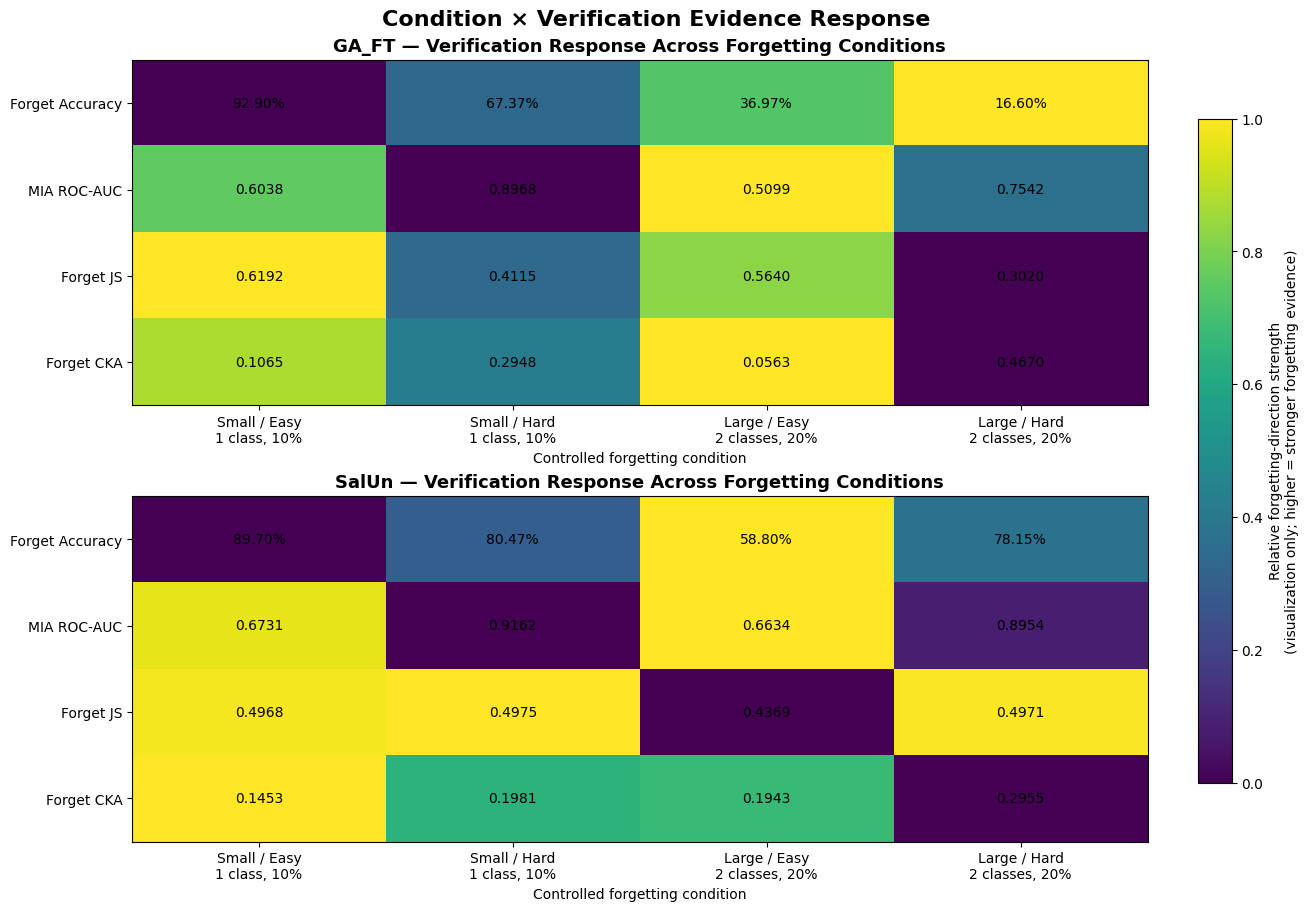


7.7.12 — CONDITION × EVIDENCE HEATMAP

Conditions:
- small_easy: Small / Easy 1 class, 10%
- small_hard: Small / Hard 1 class, 10%
- large_easy: Large / Easy 2 classes, 20%
- large_hard: Large / Hard 2 classes, 20%

Signals visualized:
- Forget Accuracy (lower = stronger forgetting evidence)
- MIA ROC-AUC (lower = stronger forgetting evidence)
- Forget JS (higher = stronger forgetting evidence)
- Forget CKA (lower = stronger forgetting evidence)

Important:
✓ Heatmap normalization is visualization-only.
✓ Raw metric values are printed inside the cells.
✓ No absolute verification threshold was introduced.
✓ The four frozen experimental conditions are preserved.

Saved figure:
/kaggle/working/Machine_Unlearning_Research/figures/condition_evidence_heatmap.png

Figure generated successfully.


In [44]:
# ============================================================
# ## 7.7.12 — Condition × Evidence Heatmap
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

INPUT_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "condition_level_evidence_consistency.csv"
)

FIGURES_DIR = os.path.join(
    PROJECT_DIR,
    "figures"
)

OUTPUT_PATH = os.path.join(
    FIGURES_DIR,
    "condition_evidence_heatmap.png"
)

os.makedirs(FIGURES_DIR, exist_ok=True)

# ------------------------------------------------------------
# Load existing condition-level evidence
# ------------------------------------------------------------

df = pd.read_csv(INPUT_PATH)

assert df.shape[0] == 8

# Exact columns from the verified 7.7.12a schema
required_columns = [
    "method",
    "condition",
    "forget_accuracy_mean",
    "mia_roc_auc_mean",
    "forget_mean_js",
    "forget_cka"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

# ------------------------------------------------------------
# Fixed condition order
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

method_order = [
    "GA_FT",
    "SalUn"
]

df["condition"] = pd.Categorical(
    df["condition"],
    categories=condition_order,
    ordered=True
)

df["method"] = pd.Categorical(
    df["method"],
    categories=method_order,
    ordered=True
)

df = df.sort_values(
    ["method", "condition"]
).reset_index(drop=True)

# ------------------------------------------------------------
# Human-readable condition labels
# ------------------------------------------------------------

condition_labels = {
    "small_easy": "Small / Easy\n1 class, 10%",
    "small_hard": "Small / Hard\n1 class, 10%",
    "large_easy": "Large / Easy\n2 classes, 20%",
    "large_hard": "Large / Hard\n2 classes, 20%"
}

# ------------------------------------------------------------
# Signal definitions
# ------------------------------------------------------------

signal_columns = {
    "Forget Accuracy": "forget_accuracy_mean",
    "MIA ROC-AUC": "mia_roc_auc_mean",
    "Forget JS": "forget_mean_js",
    "Forget CKA": "forget_cka"
}

# ------------------------------------------------------------
# Normalize only for visualization
#
# Higher heatmap value = stronger forgetting direction.
#
# This does NOT create a new evaluation metric.
# ------------------------------------------------------------

def normalize_for_forgetting(
    values,
    higher_is_forgetting
):

    values = np.asarray(
        values,
        dtype=float
    )

    min_value = values.min()
    max_value = values.max()

    if np.isclose(
        max_value,
        min_value
    ):
        normalized = np.full_like(
            values,
            0.5,
            dtype=float
        )
    else:
        normalized = (
            (values - min_value)
            / (max_value - min_value)
        )

    if not higher_is_forgetting:
        normalized = 1.0 - normalized

    return normalized


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(13, 9),
    constrained_layout=True
)

for ax, method in zip(
    axes,
    method_order
):

    method_df = df[
        df["method"] == method
    ].copy()

    method_df = (
        method_df
        .set_index("condition")
        .loc[condition_order]
        .reset_index()
    )

    # --------------------------------------------------------
    # Build visualization matrix
    # --------------------------------------------------------

    heatmap_values = []

    # Forget Accuracy:
    # lower = stronger forgetting evidence
    heatmap_values.append(
        normalize_for_forgetting(
            method_df[
                "forget_accuracy_mean"
            ],
            higher_is_forgetting=False
        )
    )

    # MIA ROC-AUC:
    # lower = stronger forgetting evidence
    heatmap_values.append(
        normalize_for_forgetting(
            method_df[
                "mia_roc_auc_mean"
            ],
            higher_is_forgetting=False
        )
    )

    # Forget JS:
    # higher = stronger forgetting evidence
    heatmap_values.append(
        normalize_for_forgetting(
            method_df[
                "forget_mean_js"
            ],
            higher_is_forgetting=True
        )
    )

    # Forget CKA:
    # lower = stronger forgetting evidence
    heatmap_values.append(
        normalize_for_forgetting(
            method_df[
                "forget_cka"
            ],
            higher_is_forgetting=False
        )
    )

    heatmap = np.array(
        heatmap_values
    )

    im = ax.imshow(
        heatmap,
        aspect="auto",
        vmin=0,
        vmax=1
    )

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    ax.set_xticks(
        range(len(condition_order))
    )

    ax.set_xticklabels(
        [
            condition_labels[c]
            for c in condition_order
        ]
    )

    ax.set_yticks(
        range(4)
    )

    ax.set_yticklabels(
        [
            "Forget Accuracy",
            "MIA ROC-AUC",
            "Forget JS",
            "Forget CKA"
        ]
    )

    ax.set_title(
        f"{method} — Verification Response Across Forgetting Conditions",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Controlled forgetting condition"
    )

    # --------------------------------------------------------
    # Annotate cells with ORIGINAL raw values
    # --------------------------------------------------------

    for row_idx, (
        signal_name,
        column_name
    ) in enumerate(
        signal_columns.items()
    ):

        for col_idx, value in enumerate(
            method_df[
                column_name
            ].values
        ):

            if signal_name == "Forget Accuracy":
                text = f"{value:.2f}%"
            else:
                text = f"{value:.4f}"

            ax.text(
                col_idx,
                row_idx,
                text,
                ha="center",
                va="center",
                fontsize=10
            )

# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.85
)

cbar.set_label(
    "Relative forgetting-direction strength\n"
    "(visualization only; higher = stronger forgetting evidence)"
)

fig.suptitle(
    "Condition × Verification Evidence Response",
    fontsize=16,
    fontweight="bold"
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

fig.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert os.path.exists(
    OUTPUT_PATH
)

print()
print("=" * 100)
print("7.7.12 — CONDITION × EVIDENCE HEATMAP")
print("=" * 100)

print()
print("Conditions:")

for condition in condition_order:
    print(
        f"- {condition}: "
        f"{condition_labels[condition].replace(chr(10), ' ')}"
    )

print()
print("Signals visualized:")

print(
    "- Forget Accuracy "
    "(lower = stronger forgetting evidence)"
)

print(
    "- MIA ROC-AUC "
    "(lower = stronger forgetting evidence)"
)

print(
    "- Forget JS "
    "(higher = stronger forgetting evidence)"
)

print(
    "- Forget CKA "
    "(lower = stronger forgetting evidence)"
)

print()
print("Important:")
print(
    "✓ Heatmap normalization is visualization-only."
)
print(
    "✓ Raw metric values are printed inside the cells."
)
print(
    "✓ No absolute verification threshold was introduced."
)
print(
    "✓ The four frozen experimental conditions are preserved."
)

print()
print("Saved figure:")
print(OUTPUT_PATH)

print()
print("Figure generated successfully.")

print("=" * 100)

In [45]:
# ============================================================
# ## 7.7.13 — Statistical / Effect Summary Across Conditions
# ============================================================

import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

INPUT_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "condition_level_evidence_consistency.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

OUTPUT_CONTRAST_PATH = os.path.join(
    OUTPUT_DIR,
    "condition_effect_contrasts.csv"
)

OUTPUT_RANGE_PATH = os.path.join(
    OUTPUT_DIR,
    "condition_effect_ranges.csv"
)

# ------------------------------------------------------------
# Load condition-level evidence
# ------------------------------------------------------------

df = pd.read_csv(INPUT_PATH)

assert df.shape[0] == 8

# ------------------------------------------------------------
# Fixed condition order
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

method_order = [
    "GA_FT",
    "SalUn"
]

# ------------------------------------------------------------
# Four forgetting-oriented signals
# ------------------------------------------------------------

signal_columns = {
    "Forget Accuracy": "forget_accuracy_mean",
    "MIA ROC-AUC": "mia_roc_auc_mean",
    "Forget JS": "forget_mean_js",
    "Forget CKA": "forget_cka"
}

# ------------------------------------------------------------
# Verify required columns
# ------------------------------------------------------------

required_columns = [
    "method",
    "condition"
] + list(signal_columns.values())

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

# ------------------------------------------------------------
# Condition-level effect contrasts
#
# Contrasts are descriptive:
#
# Difficulty effect:
#   hard - easy
#   within the same forget size
#
# Forget-size effect:
#   large - small
#   within the same difficulty
#
# No causal interpretation is assigned.
# ------------------------------------------------------------

contrast_rows = []

for method in method_order:

    method_df = df[
        df["method"] == method
    ].copy()

    method_df = (
        method_df
        .set_index("condition")
        .loc[condition_order]
    )

    for signal_name, column_name in signal_columns.items():

        small_easy = float(
            method_df.loc[
                "small_easy",
                column_name
            ]
        )

        small_hard = float(
            method_df.loc[
                "small_hard",
                column_name
            ]
        )

        large_easy = float(
            method_df.loc[
                "large_easy",
                column_name
            ]
        )

        large_hard = float(
            method_df.loc[
                "large_hard",
                column_name
            ]
        )

        # Difficulty contrasts
        small_difficulty_effect = (
            small_hard - small_easy
        )

        large_difficulty_effect = (
            large_hard - large_easy
        )

        # Forget-size contrasts
        easy_size_effect = (
            large_easy - small_easy
        )

        hard_size_effect = (
            large_hard - small_hard
        )

        # Overall condition range
        values = np.array([
            small_easy,
            small_hard,
            large_easy,
            large_hard
        ])

        condition_range = (
            values.max() - values.min()
        )

        contrast_rows.append({
            "method": method,
            "signal": signal_name,

            "small_easy": small_easy,
            "small_hard": small_hard,
            "large_easy": large_easy,
            "large_hard": large_hard,

            "difficulty_effect_small":
                small_difficulty_effect,

            "difficulty_effect_large":
                large_difficulty_effect,

            "size_effect_easy":
                easy_size_effect,

            "size_effect_hard":
                hard_size_effect,

            "condition_range":
                condition_range
        })

contrast_df = pd.DataFrame(
    contrast_rows
)

# ------------------------------------------------------------
# Save contrast table
# ------------------------------------------------------------

contrast_df.to_csv(
    OUTPUT_CONTRAST_PATH,
    index=False
)

# ------------------------------------------------------------
# Descriptive range summary
# ------------------------------------------------------------

range_rows = []

for method in method_order:

    method_df = df[
        df["method"] == method
    ]

    for signal_name, column_name in signal_columns.items():

        values = (
            method_df[column_name]
            .astype(float)
        )

        min_idx = values.idxmin()
        max_idx = values.idxmax()

        range_rows.append({
            "method": method,
            "signal": signal_name,

            "minimum_value":
                float(values.min()),

            "minimum_condition":
                method_df.loc[
                    min_idx,
                    "condition"
                ],

            "maximum_value":
                float(values.max()),

            "maximum_condition":
                method_df.loc[
                    max_idx,
                    "condition"
                ],

            "condition_range":
                float(values.max() - values.min())
        })

range_df = pd.DataFrame(
    range_rows
)

range_df.to_csv(
    OUTPUT_RANGE_PATH,
    index=False
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert contrast_df.shape[0] == 8
assert range_df.shape[0] == 8

assert (
    contrast_df[
        ["method", "signal"]
    ].duplicated().sum()
    == 0
)

assert (
    range_df[
        ["method", "signal"]
    ].duplicated().sum()
    == 0
)

assert np.isfinite(
    contrast_df.select_dtypes(
        include=np.number
    ).to_numpy()
).all()

assert np.isfinite(
    range_df.select_dtypes(
        include=np.number
    ).to_numpy()
).all()

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 110)
print("7.7.13 — STATISTICAL / EFFECT SUMMARY ACROSS CONDITIONS")
print("=" * 110)

print()
print("A. CONDITION EFFECT CONTRASTS")
print("-" * 110)

display_columns = [
    "method",
    "signal",
    "difficulty_effect_small",
    "difficulty_effect_large",
    "size_effect_easy",
    "size_effect_hard",
    "condition_range"
]

print(
    contrast_df[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print()
print("Interpretation of contrasts:")
print(
    "- Difficulty effect = hard condition − easy condition"
)
print(
    "- Size effect = large forget set − small forget set"
)
print(
    "- All contrasts are descriptive condition differences."
)
print(
    "- They do not establish causality or statistical significance."
)

print()
print("B. CONDITION RANGES")
print("-" * 110)

print(
    range_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print()
print("C. VALIDATION")
print("-" * 110)

print("✓ 8 method × signal summaries generated")
print("✓ 4 frozen conditions used")
print("✓ Difficulty and size contrasts computed")
print("✓ Overall condition ranges computed")
print("✓ No new verification thresholds introduced")
print("✓ No significance claims made")
print("✓ All numerical values are finite")

print()
print("Saved contrast table:")
print(OUTPUT_CONTRAST_PATH)

print()
print("Saved range summary:")
print(OUTPUT_RANGE_PATH)

print()
print("7.7.13 completed successfully.")

print("=" * 110)

7.7.13 — STATISTICAL / EFFECT SUMMARY ACROSS CONDITIONS

A. CONDITION EFFECT CONTRASTS
--------------------------------------------------------------------------------------------------------------
method          signal  difficulty_effect_small  difficulty_effect_large  size_effect_easy  size_effect_hard  condition_range
 GA_FT Forget Accuracy               -25.533333               -20.366667        -55.933333        -50.766667        76.300000
 GA_FT     MIA ROC-AUC                 0.292991                 0.244312         -0.093896         -0.142575         0.386887
 GA_FT       Forget JS                -0.207681                -0.261973         -0.055219         -0.109511         0.317192
 GA_FT      Forget CKA                 0.188283                 0.410712         -0.050169          0.172260         0.410712
 SalUn Forget Accuracy                -9.233333                19.350000        -30.900000         -2.316667        30.900000
 SalUn     MIA ROC-AUC                 0.24312

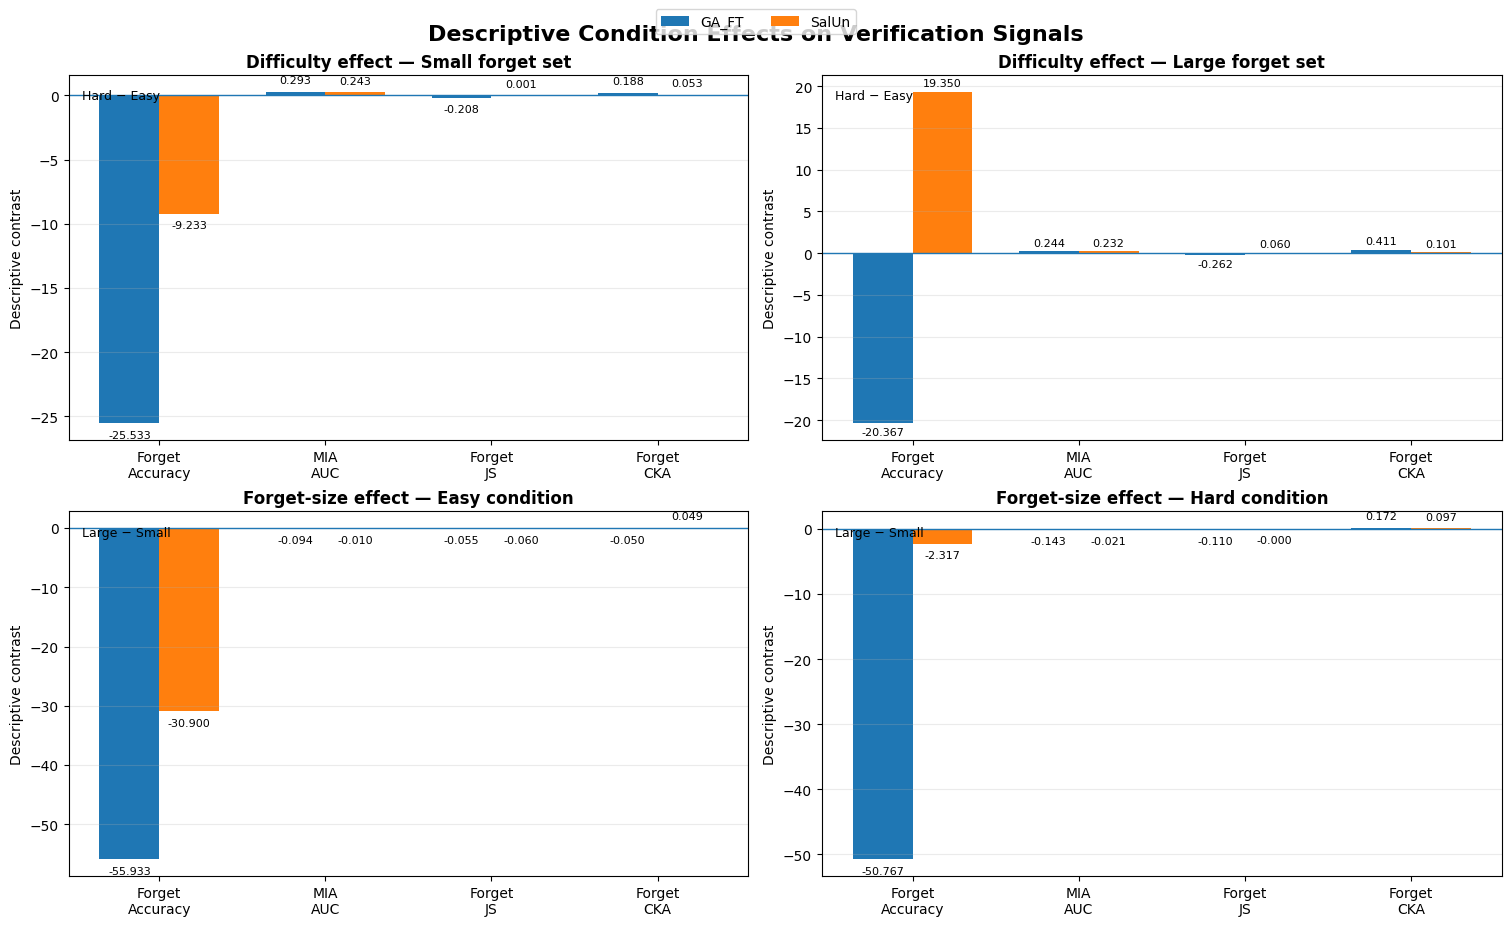


7.7.14 — EFFECT-CONTRAST VISUALIZATION

Visualized contrasts:
1. Difficulty effect for small forget sets (Hard − Easy)
2. Difficulty effect for large forget sets (Hard − Easy)
3. Forget-size effect under easy conditions (Large − Small)
4. Forget-size effect under hard conditions (Large − Small)

Interpretation note:
These are descriptive condition contrasts only.
Positive and negative values indicate the direction of the raw metric change.
No causal or statistical-significance interpretation is assigned.

Validation:
✓ 8 method × signal rows loaded
✓ Four condition contrasts visualized
✓ Both unlearning methods included
✓ Zero reference line included
✓ Raw contrast values annotated
✓ No new thresholds introduced

Saved figure:
/kaggle/working/Machine_Unlearning_Research/figures/condition_effect_contrasts.png

7.7.14 completed successfully.


In [46]:
# ============================================================
# ## 7.7.14 — Effect-Contrast Visualization
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

INPUT_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "condition_effect_contrasts.csv"
)

FIGURES_DIR = os.path.join(
    PROJECT_DIR,
    "figures"
)

OUTPUT_PATH = os.path.join(
    FIGURES_DIR,
    "condition_effect_contrasts.png"
)

os.makedirs(
    FIGURES_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# Load existing descriptive effect contrasts
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH
)

assert df.shape[0] == 8

required_columns = [
    "method",
    "signal",
    "difficulty_effect_small",
    "difficulty_effect_large",
    "size_effect_easy",
    "size_effect_hard"
]

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

# ------------------------------------------------------------
# Fixed ordering
# ------------------------------------------------------------

method_order = [
    "GA_FT",
    "SalUn"
]

signal_order = [
    "Forget Accuracy",
    "MIA ROC-AUC",
    "Forget JS",
    "Forget CKA"
]

df["method"] = pd.Categorical(
    df["method"],
    categories=method_order,
    ordered=True
)

df["signal"] = pd.Categorical(
    df["signal"],
    categories=signal_order,
    ordered=True
)

df = df.sort_values(
    [
        "method",
        "signal"
    ]
).reset_index(
    drop=True
)

# ------------------------------------------------------------
# Create one figure for all descriptive contrasts
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 9),
    constrained_layout=True
)

contrast_definitions = [
    (
        "difficulty_effect_small",
        "Difficulty effect — Small forget set",
        "Hard − Easy"
    ),
    (
        "difficulty_effect_large",
        "Difficulty effect — Large forget set",
        "Hard − Easy"
    ),
    (
        "size_effect_easy",
        "Forget-size effect — Easy condition",
        "Large − Small"
    ),
    (
        "size_effect_hard",
        "Forget-size effect — Hard condition",
        "Large − Small"
    )
]

# ------------------------------------------------------------
# Plot each contrast
# ------------------------------------------------------------

for ax, (
    column,
    title,
    subtitle
) in zip(
    axes.flat,
    contrast_definitions
):

    x = np.arange(
        len(signal_order)
    )

    width = 0.36

    ga_values = (
        df[
            df["method"] == "GA_FT"
        ]
        .set_index("signal")
        .loc[
            signal_order,
            column
        ]
        .astype(float)
        .values
    )

    salun_values = (
        df[
            df["method"] == "SalUn"
        ]
        .set_index("signal")
        .loc[
            signal_order,
            column
        ]
        .astype(float)
        .values
    )

    bars_ga = ax.bar(
        x - width / 2,
        ga_values,
        width,
        label="GA_FT"
    )

    bars_salun = ax.bar(
        x + width / 2,
        salun_values,
        width,
        label="SalUn"
    )

    # --------------------------------------------------------
    # Zero reference line
    # --------------------------------------------------------

    ax.axhline(
        0,
        linewidth=1
    )

    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        [
            "Forget\nAccuracy",
            "MIA\nAUC",
            "Forget\nJS",
            "Forget\nCKA"
        ]
    )

    ax.set_title(
        title,
        fontsize=12,
        fontweight="bold"
    )

    ax.set_ylabel(
        "Descriptive contrast"
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

    # --------------------------------------------------------
    # Annotate values
    # --------------------------------------------------------

    all_bars = [
        (bars_ga, ga_values),
        (bars_salun, salun_values)
    ]

    for bars, values in all_bars:

        for bar, value in zip(
            bars,
            values
        ):

            offset = (
                0.02
                * max(
                    1.0,
                    np.max(
                        np.abs(
                            np.concatenate(
                                [
                                    ga_values,
                                    salun_values
                                ]
                            )
                        )
                    )
                )
            )

            if value >= 0:
                y_position = value + offset
                vertical_alignment = "bottom"
            else:
                y_position = value - offset
                vertical_alignment = "top"

            ax.text(
                bar.get_x()
                + bar.get_width() / 2,
                y_position,
                f"{value:.3f}",
                ha="center",
                va=vertical_alignment,
                fontsize=8
            )

    # --------------------------------------------------------
    # Direction note
    # --------------------------------------------------------

    ax.text(
        0.02,
        0.96,
        subtitle,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9
    )

# ------------------------------------------------------------
# Shared legend
# ------------------------------------------------------------

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "Descriptive Condition Effects on Verification Signals",
    fontsize=16,
    fontweight="bold"
)

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

fig.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert os.path.exists(
    OUTPUT_PATH
)

print()
print("=" * 100)
print("7.7.14 — EFFECT-CONTRAST VISUALIZATION")
print("=" * 100)

print()
print("Visualized contrasts:")

print(
    "1. Difficulty effect for small forget sets "
    "(Hard − Easy)"
)

print(
    "2. Difficulty effect for large forget sets "
    "(Hard − Easy)"
)

print(
    "3. Forget-size effect under easy conditions "
    "(Large − Small)"
)

print(
    "4. Forget-size effect under hard conditions "
    "(Large − Small)"
)

print()
print("Interpretation note:")
print(
    "These are descriptive condition contrasts only."
)

print(
    "Positive and negative values indicate the direction "
    "of the raw metric change."
)

print(
    "No causal or statistical-significance interpretation "
    "is assigned."
)

print()
print("Validation:")
print("✓ 8 method × signal rows loaded")
print("✓ Four condition contrasts visualized")
print("✓ Both unlearning methods included")
print("✓ Zero reference line included")
print("✓ Raw contrast values annotated")
print("✓ No new thresholds introduced")

print()
print("Saved figure:")
print(OUTPUT_PATH)

print()
print("7.7.14 completed successfully.")

print("=" * 100)

In [47]:
# ============================================================
# ## 7.7.15 — Integrated Cross-Verification Summary
# ============================================================

import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

CROSS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

# ------------------------------------------------------------
# Existing result files
# ------------------------------------------------------------

CONDITION_PATH = os.path.join(
    CROSS_DIR,
    "condition_level_evidence_consistency.csv"
)

MATRIX_PATH = os.path.join(
    CROSS_DIR,
    "evidence_consistency_matrix.csv"
)

OUTPUT_PATH = os.path.join(
    CROSS_DIR,
    "integrated_cross_verification_summary.csv"
)

# ------------------------------------------------------------
# Load existing analyses
# ------------------------------------------------------------

condition_df = pd.read_csv(
    CONDITION_PATH
)

matrix_df = pd.read_csv(
    MATRIX_PATH
)

# ------------------------------------------------------------
# Validate source tables
# ------------------------------------------------------------

assert condition_df.shape[0] == 8
assert matrix_df.shape[0] == 24

required_condition_columns = [
    "method",
    "condition",
    "forget_accuracy_mean",
    "forget_accuracy_sd",
    "forget_accuracy_gap_mean",
    "retain_accuracy_mean",
    "retain_accuracy_sd",
    "retain_accuracy_gap_mean",
    "overall_accuracy_mean",
    "overall_accuracy_sd",
    "overall_accuracy_gap_mean",
    "forget_mean_js",
    "retain_mean_js",
    "forget_cka",
    "retain_cka",
    "mia_roc_auc_mean",
    "mia_roc_auc_sd"
]

required_matrix_columns = [
    "method",
    "condition",
    "seed",
    "more_forgetting_count",
    "less_forgetting_count",
    "neutral_count",
    "evidence_pattern"
]

missing_condition = [
    c for c in required_condition_columns
    if c not in condition_df.columns
]

missing_matrix = [
    c for c in required_matrix_columns
    if c not in matrix_df.columns
]

assert not missing_condition, (
    f"Missing condition columns: {missing_condition}"
)

assert not missing_matrix, (
    f"Missing matrix columns: {missing_matrix}"
)

# ------------------------------------------------------------
# Fixed ordering
# ------------------------------------------------------------

condition_order = [
    "small_easy",
    "small_hard",
    "large_easy",
    "large_hard"
]

method_order = [
    "GA_FT",
    "SalUn"
]

condition_df["condition"] = pd.Categorical(
    condition_df["condition"],
    categories=condition_order,
    ordered=True
)

condition_df["method"] = pd.Categorical(
    condition_df["method"],
    categories=method_order,
    ordered=True
)

# ------------------------------------------------------------
# Evidence-pattern counts from 7.7.11
# ------------------------------------------------------------

pattern_counts = (
    matrix_df
    .groupby(
        [
            "method",
            "condition",
            "evidence_pattern"
        ],
        observed=True
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

# Ensure all expected pattern columns exist
for column in [
    "mixed_evidence",
    "tie_or_neutral",
    "unanimous_forgetting_direction",
    "unanimous_non_forgetting_direction"
]:

    if column not in pattern_counts.columns:
        pattern_counts[column] = 0

pattern_counts = pattern_counts.rename(
    columns={
        "mixed_evidence":
            "mixed_evidence_runs",

        "tie_or_neutral":
            "tie_or_neutral_runs",

        "unanimous_forgetting_direction":
            "unanimous_forgetting_runs",

        "unanimous_non_forgetting_direction":
            "unanimous_non_forgetting_runs"
    }
)

# ------------------------------------------------------------
# Average directional counts across the 3 seeds
# ------------------------------------------------------------

direction_summary = (
    matrix_df
    .groupby(
        [
            "method",
            "condition"
        ],
        observed=True
    )[
        [
            "more_forgetting_count",
            "less_forgetting_count",
            "neutral_count"
        ]
    ]
    .mean()
    .reset_index()
    .rename(
        columns={
            "more_forgetting_count":
                "mean_more_forgetting_signals",

            "less_forgetting_count":
                "mean_less_forgetting_signals",

            "neutral_count":
                "mean_neutral_signals"
        }
    )
)

# ------------------------------------------------------------
# Merge condition-level verification evidence
# ------------------------------------------------------------

summary_df = condition_df.merge(
    pattern_counts,
    on=[
        "method",
        "condition"
    ],
    how="left",
    validate="one_to_one"
)

summary_df = summary_df.merge(
    direction_summary,
    on=[
        "method",
        "condition"
    ],
    how="left",
    validate="one_to_one"
)

# ------------------------------------------------------------
# Add human-readable frozen condition descriptors
# ------------------------------------------------------------

condition_descriptors = {
    "small_easy": {
        "forget_size_classes": 1,
        "forget_size_percent": 10.0,
        "difficulty_percent": 4.80
    },

    "small_hard": {
        "forget_size_classes": 1,
        "forget_size_percent": 10.0,
        "difficulty_percent": 26.00
    },

    "large_easy": {
        "forget_size_classes": 2,
        "forget_size_percent": 20.0,
        "difficulty_percent": 3.15
    },

    "large_hard": {
        "forget_size_classes": 2,
        "forget_size_percent": 20.0,
        "difficulty_percent": 18.25
    }
}

summary_df[
    "forget_size_classes"
] = summary_df[
    "condition"
].map(
    lambda x:
        condition_descriptors[x][
            "forget_size_classes"
        ]
)

summary_df[
    "forget_size_percent"
] = summary_df[
    "condition"
].map(
    lambda x:
        condition_descriptors[x][
            "forget_size_percent"
        ]
)

summary_df[
    "difficulty_percent"
] = summary_df[
    "condition"
].map(
    lambda x:
        condition_descriptors[x][
            "difficulty_percent"
        ]
)

# ------------------------------------------------------------
# Sort final table
# ------------------------------------------------------------

summary_df = summary_df.sort_values(
    [
        "method",
        "condition"
    ]
).reset_index(
    drop=True
)

# ------------------------------------------------------------
# Final column organization
# ------------------------------------------------------------

final_columns = [
    # Experimental condition
    "method",
    "condition",
    "forget_size_classes",
    "forget_size_percent",
    "difficulty_percent",

    # Behavioral verification
    "forget_accuracy_mean",
    "forget_accuracy_sd",
    "retain_accuracy_mean",
    "retain_accuracy_sd",
    "overall_accuracy_mean",
    "overall_accuracy_sd",

    # Oracle reference gaps
    "retain_accuracy_gap_mean",
    "overall_accuracy_gap_mean",

    # Privacy
    "mia_roc_auc_mean",
    "mia_roc_auc_sd",

    # Output similarity
    "forget_mean_js",
    "retain_mean_js",

    # Representation similarity
    "forget_cka",
    "retain_cka",

    # Evidence consistency
    "mixed_evidence_runs",
    "tie_or_neutral_runs",
    "unanimous_forgetting_runs",
    "unanimous_non_forgetting_runs",

    "mean_more_forgetting_signals",
    "mean_less_forgetting_signals",
    "mean_neutral_signals"
]

summary_df = summary_df[
    final_columns
]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert summary_df.shape[0] == 8

assert (
    summary_df[
        [
            "method",
            "condition"
        ]
    ]
    .duplicated()
    .sum()
    == 0
)

# Each method × condition has exactly 3 seeds
assert (
    (
        summary_df[
            "mixed_evidence_runs"
        ]
        + summary_df[
            "tie_or_neutral_runs"
        ]
        + summary_df[
            "unanimous_forgetting_runs"
        ]
        + summary_df[
            "unanimous_non_forgetting_runs"
        ]
    )
    == 3
).all()

# No unanimous patterns should exist based on 7.7.11
assert (
    summary_df[
        "unanimous_forgetting_runs"
    ] == 0
).all()

assert (
    summary_df[
        "unanimous_non_forgetting_runs"
    ] == 0
).all()

# Numeric values must be finite
numeric_values = summary_df.select_dtypes(
    include=np.number
).to_numpy()

assert np.isfinite(
    numeric_values
).all()

# ------------------------------------------------------------
# Save final integrated summary
# ------------------------------------------------------------

summary_df.to_csv(
    OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# Display compact master table
# ------------------------------------------------------------

print("=" * 120)
print("7.7.15 — INTEGRATED CROSS-VERIFICATION SUMMARY")
print("=" * 120)

print()
print("A. CONDITION-LEVEL MASTER SUMMARY")
print("-" * 120)

display_columns = [
    "method",
    "condition",
    "forget_size_percent",
    "difficulty_percent",

    "forget_accuracy_mean",
    "retain_accuracy_mean",
    "overall_accuracy_mean",

    "retain_accuracy_gap_mean",
    "overall_accuracy_gap_mean",

    "mia_roc_auc_mean",
    "forget_mean_js",
    "forget_cka",

    "mixed_evidence_runs",
    "tie_or_neutral_runs"
]

print(
    summary_df[
        display_columns
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print()
print("B. EVIDENCE CONSISTENCY SUMMARY")
print("-" * 120)

print(
    summary_df[
        [
            "method",
            "condition",
            "mixed_evidence_runs",
            "tie_or_neutral_runs",
            "unanimous_forgetting_runs",
            "unanimous_non_forgetting_runs",
            "mean_more_forgetting_signals",
            "mean_less_forgetting_signals",
            "mean_neutral_signals"
        ]
    ].to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)

print()
print("C. EXPERIMENTAL SCOPE")
print("-" * 120)

print("Methods: GA_FT, SalUn")
print("Conditions: 4 frozen conditions")
print("Seeds per condition: 3")
print("Total unlearning runs: 24")
print("Verification signals: behavioral, MIA, JS, CKA")

print()
print("D. VALIDATION")
print("-" * 120)

print("✓ 8 method × condition rows consolidated")
print("✓ Behavioral evidence included")
print("✓ MIA evidence included")
print("✓ Output-similarity evidence included")
print("✓ Representation evidence included")
print("✓ Oracle retain/overall gaps included")
print("✓ Evidence-consistency patterns included")
print("✓ No new metrics introduced")
print("✓ No new thresholds introduced")
print("✓ No unanimous four-signal patterns observed")
print("✓ All numerical values are finite")

print()
print("Saved integrated summary:")
print(OUTPUT_PATH)

print()
print("7.7.15 completed successfully.")

print("=" * 120)

7.7.15 — INTEGRATED CROSS-VERIFICATION SUMMARY

A. CONDITION-LEVEL MASTER SUMMARY
------------------------------------------------------------------------------------------------------------------------
method  condition  forget_size_percent  difficulty_percent  forget_accuracy_mean  retain_accuracy_mean  overall_accuracy_mean  retain_accuracy_gap_mean  overall_accuracy_gap_mean  mia_roc_auc_mean  forget_mean_js  forget_cka  mixed_evidence_runs  tie_or_neutral_runs
 GA_FT large_easy              20.0000              3.1500               36.9667               85.4375                75.7433                    1.0000                     8.1933            0.5099          0.5640      0.0563                    2                    1
 GA_FT large_hard              20.0000             18.2500               16.6000               91.8583                76.8067                    1.1083                     4.2067            0.7542          0.3020      0.4670                    1                  

In [48]:
# ============================================================
# ## 7.8.1 — Final Results Synthesis
# ============================================================

import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

CROSS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

INPUT_PATH = os.path.join(
    CROSS_DIR,
    "integrated_cross_verification_summary.csv"
)

OUTPUT_PATH = os.path.join(
    CROSS_DIR,
    "final_results_synthesis.csv"
)

# ------------------------------------------------------------
# Load final integrated summary
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH
)

assert df.shape[0] == 8

# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

required_columns = [
    "method",
    "condition",
    "forget_size_percent",
    "difficulty_percent",

    "forget_accuracy_mean",
    "forget_accuracy_sd",
    "retain_accuracy_mean",
    "retain_accuracy_sd",
    "overall_accuracy_mean",
    "overall_accuracy_sd",

    "retain_accuracy_gap_mean",
    "overall_accuracy_gap_mean",

    "mia_roc_auc_mean",
    "mia_roc_auc_sd",

    "forget_mean_js",
    "retain_mean_js",

    "forget_cka",
    "retain_cka",

    "mixed_evidence_runs",
    "tie_or_neutral_runs",

    "unanimous_forgetting_runs",
    "unanimous_non_forgetting_runs"
]

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

assert not missing_columns, (
    f"Missing required columns: {missing_columns}"
)

# ------------------------------------------------------------
# Method-level synthesis
# ------------------------------------------------------------

method_summary = (
    df.groupby(
        "method"
    )
    .agg(
        conditions=(
            "condition",
            "count"
        ),

        mean_forget_accuracy=(
            "forget_accuracy_mean",
            "mean"
        ),

        mean_retain_accuracy=(
            "retain_accuracy_mean",
            "mean"
        ),

        mean_overall_accuracy=(
            "overall_accuracy_mean",
            "mean"
        ),

        mean_retain_gap=(
            "retain_accuracy_gap_mean",
            "mean"
        ),

        mean_overall_gap=(
            "overall_accuracy_gap_mean",
            "mean"
        ),

        mean_mia_auc=(
            "mia_roc_auc_mean",
            "mean"
        ),

        mean_forget_js=(
            "forget_mean_js",
            "mean"
        ),

        mean_retain_js=(
            "retain_mean_js",
            "mean"
        ),

        mean_forget_cka=(
            "forget_cka",
            "mean"
        ),

        mean_retain_cka=(
            "retain_cka",
            "mean"
        ),

        mixed_runs=(
            "mixed_evidence_runs",
            "sum"
        ),

        tie_neutral_runs=(
            "tie_or_neutral_runs",
            "sum"
        )
    )
    .reset_index()
)

# ------------------------------------------------------------
# Condition with largest/smallest behavioral forgetting
# ------------------------------------------------------------

behavioral_extremes = []

for method in sorted(
    df["method"].unique()
):

    method_df = df[
        df["method"] == method
    ].copy()

    min_forget_idx = (
        method_df[
            "forget_accuracy_mean"
        ].idxmin()
    )

    max_forget_idx = (
        method_df[
            "forget_accuracy_mean"
        ].idxmax()
    )

    behavioral_extremes.append({
        "method": method,

        "lowest_forget_accuracy_condition":
            method_df.loc[
                min_forget_idx,
                "condition"
            ],

        "lowest_forget_accuracy":
            method_df.loc[
                min_forget_idx,
                "forget_accuracy_mean"
            ],

        "highest_forget_accuracy_condition":
            method_df.loc[
                max_forget_idx,
                "condition"
            ],

        "highest_forget_accuracy":
            method_df.loc[
                max_forget_idx,
                "forget_accuracy_mean"
            ]
    })

behavioral_extremes_df = pd.DataFrame(
    behavioral_extremes
)

# ------------------------------------------------------------
# Condition sensitivity ranges
# ------------------------------------------------------------

range_summary = []

range_columns = {
    "Forget Accuracy":
        "forget_accuracy_mean",

    "MIA ROC-AUC":
        "mia_roc_auc_mean",

    "Forget JS":
        "forget_mean_js",

    "Forget CKA":
        "forget_cka"
}

for method in sorted(
    df["method"].unique()
):

    method_df = df[
        df["method"] == method
    ]

    for signal, column in range_columns.items():

        values = (
            method_df[column]
            .astype(float)
        )

        range_summary.append({
            "method": method,
            "signal": signal,
            "minimum": values.min(),
            "maximum": values.max(),
            "range": values.max() - values.min()
        })

range_summary_df = pd.DataFrame(
    range_summary
)

# ------------------------------------------------------------
# Evidence consistency totals
# ------------------------------------------------------------

total_mixed = int(
    df["mixed_evidence_runs"].sum()
)

total_tie_neutral = int(
    df["tie_or_neutral_runs"].sum()
)

total_unanimous_forgetting = int(
    df[
        "unanimous_forgetting_runs"
    ].sum()
)

total_unanimous_non_forgetting = int(
    df[
        "unanimous_non_forgetting_runs"
    ].sum()
)

total_runs = (
    total_mixed
    + total_tie_neutral
    + total_unanimous_forgetting
    + total_unanimous_non_forgetting
)

assert total_runs == 24

# ------------------------------------------------------------
# Save method-level synthesis
# ------------------------------------------------------------

method_summary.to_csv(
    OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert method_summary.shape[0] == 2

assert behavioral_extremes_df.shape[0] == 2

assert range_summary_df.shape[0] == 8

assert total_unanimous_forgetting == 0
assert total_unanimous_non_forgetting == 0

assert np.isfinite(
    method_summary.select_dtypes(
        include=np.number
    ).to_numpy()
).all()

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 120)
print("7.8.1 — FINAL RESULTS SYNTHESIS")
print("=" * 120)

print()
print("A. METHOD-LEVEL SYNTHESIS")
print("-" * 120)

print(
    method_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print()
print("B. BEHAVIORAL EXTREMES")
print("-" * 120)

print(
    behavioral_extremes_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print()
print("C. CONDITION SENSITIVITY RANGES")
print("-" * 120)

print(
    range_summary_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)

print()
print("D. EVIDENCE CONSISTENCY")
print("-" * 120)

print(
    f"Total runs represented: {total_runs}"
)

print(
    f"Mixed evidence: "
    f"{total_mixed}/24 "
    f"({total_mixed / 24 * 100:.2f}%)"
)

print(
    f"Tie/neutral evidence: "
    f"{total_tie_neutral}/24 "
    f"({total_tie_neutral / 24 * 100:.2f}%)"
)

print(
    f"Unanimous forgetting direction: "
    f"{total_unanimous_forgetting}/24"
)

print(
    f"Unanimous non-forgetting direction: "
    f"{total_unanimous_non_forgetting}/24"
)

print()
print("E. INTERPRETATION GUARDRAILS")
print("-" * 120)

print(
    "✓ Results summarize the completed experiments only."
)

print(
    "✓ Condition differences are descriptive."
)

print(
    "✓ Oracle comparisons are reference comparisons, "
    "not proof of a universal ground truth."
)

print(
    "✓ Mixed evidence indicates disagreement among "
    "the four examined signals under the defined "
    "relative-direction procedure."
)

print(
    "✓ No causal interpretation is assigned to "
    "condition effects."
)

print(
    "✓ No claim of statistical significance is made."
)

print(
    "✓ No single verification signal is declared "
    "universally superior."
)

print()
print("Saved method-level synthesis:")
print(OUTPUT_PATH)

print()
print("7.8.1 completed successfully.")

print("=" * 120)

7.8.1 — FINAL RESULTS SYNTHESIS

A. METHOD-LEVEL SYNTHESIS
------------------------------------------------------------------------------------------------------------------------
method  conditions  mean_forget_accuracy  mean_retain_accuracy  mean_overall_accuracy  mean_retain_gap  mean_overall_gap  mean_mia_auc  mean_forget_js  mean_retain_js  mean_forget_cka  mean_retain_cka  mixed_runs  tie_neutral_runs
 GA_FT           4               53.4583               88.2230                81.6533           0.5317            7.1108        0.6912          0.4742          0.0438           0.2311           0.9196           6                 6
 SalUn           4               76.7792               87.2742                85.2700          -0.4171           10.7275        0.7870          0.4821          0.0512           0.2083           0.9160           8                 4

B. BEHAVIORAL EXTREMES
-------------------------------------------------------------------------------------------------------

In [49]:
# ============================================================
# ## 7.8.2 — Evidence-to-Finding Summary
# ============================================================

import os
import pandas as pd

PROJECT_DIR = "/kaggle/working/Machine_Unlearning_Research"

INPUT_PATH = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification",
    "integrated_cross_verification_summary.csv"
)

OUTPUT_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "cross_verification"
)

OUTPUT_PATH = os.path.join(
    OUTPUT_DIR,
    "evidence_to_finding_summary.csv"
)

# ------------------------------------------------------------
# Load completed integrated evidence
# ------------------------------------------------------------

df = pd.read_csv(
    INPUT_PATH
)

assert df.shape[0] == 8

# ------------------------------------------------------------
# Build compact evidence-to-finding table
#
# This does NOT introduce new metrics.
# It simply organizes already-computed evidence.
# ------------------------------------------------------------

finding_rows = []

# ------------------------------------------------------------
# 1. Behavioral verification
# ------------------------------------------------------------

finding_rows.append({
    "verification_dimension":
        "Behavioral verification",

    "evidence_metric":
        "Forget accuracy",

    "observed_response":
        (
            f"GA_FT ranged from "
            f"{df[df.method == 'GA_FT']['forget_accuracy_mean'].min():.2f}% "
            f"to "
            f"{df[df.method == 'GA_FT']['forget_accuracy_mean'].max():.2f}%; "
            f"SalUn ranged from "
            f"{df[df.method == 'SalUn']['forget_accuracy_mean'].min():.2f}% "
            f"to "
            f"{df[df.method == 'SalUn']['forget_accuracy_mean'].max():.2f}%."
        ),

    "interpretation_scope":
        "Descriptive condition-dependent behavioral response."
})

finding_rows.append({
    "verification_dimension":
        "Behavioral verification",

    "evidence_metric":
        "Oracle retain/overall accuracy gaps",

    "observed_response":
        (
            "Retain and overall accuracy remained different from "
            "the corresponding retrained reference by condition, "
            "with the magnitude and direction varying across "
            "method-condition combinations."
        ),

    "interpretation_scope":
        "Descriptive comparison with the retrained reference."
})

# ------------------------------------------------------------
# 2. Privacy / MIA verification
# ------------------------------------------------------------

mia_min = df["mia_roc_auc_mean"].min()
mia_max = df["mia_roc_auc_mean"].max()

finding_rows.append({
    "verification_dimension":
        "Privacy / membership inference",

    "evidence_metric":
        "MIA ROC-AUC",

    "observed_response":
        (
            f"MIA AUC ranged from "
            f"{mia_min:.4f} "
            f"to "
            f"{mia_max:.4f} "
            "across the eight method-condition combinations."
        ),

    "interpretation_scope":
        "Descriptive condition- and method-dependent privacy response."
})

# ------------------------------------------------------------
# 3. Output similarity
# ------------------------------------------------------------

js_min = df["forget_mean_js"].min()
js_max = df["forget_mean_js"].max()

finding_rows.append({
    "verification_dimension":
        "Output similarity",

    "evidence_metric":
        "Forget-set JS divergence",

    "observed_response":
        (
            f"Forget-set JS divergence ranged from "
            f"{js_min:.4f} "
            f"to "
            f"{js_max:.4f} "
            "across the eight method-condition combinations."
        ),

    "interpretation_scope":
        "Descriptive condition-dependent output response."
})

# ------------------------------------------------------------
# 4. Representation similarity
# ------------------------------------------------------------

cka_min = df["forget_cka"].min()
cka_max = df["forget_cka"].max()

finding_rows.append({
    "verification_dimension":
        "Representation similarity",

    "evidence_metric":
        "Forget-set CKA",

    "observed_response":
        (
            f"Forget-set CKA ranged from "
            f"{cka_min:.4f} "
            f"to "
            f"{cka_max:.4f} "
            "across the eight method-condition combinations."
        ),

    "interpretation_scope":
        "Descriptive condition-dependent representation response."
})

# ------------------------------------------------------------
# 5. Cross-signal consistency
# ------------------------------------------------------------

finding_rows.append({
    "verification_dimension":
        "Cross-signal consistency",

    "evidence_metric":
        "Four-signal directional agreement",

    "observed_response":
        (
            "Across 24 runs, 14 runs (58.33%) were classified "
            "as mixed evidence and 10 runs (41.67%) as "
            "tie/neutral; no run showed unanimous directional "
            "agreement across all four forgetting-oriented signals."
        ),

    "interpretation_scope":
        (
            "Descriptive evidence consistency under the "
            "within-condition median reference procedure."
        )
})

# ------------------------------------------------------------
# Create final table
# ------------------------------------------------------------

finding_df = pd.DataFrame(
    finding_rows
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert finding_df.shape[0] == 6

assert list(
    finding_df.columns
) == [
    "verification_dimension",
    "evidence_metric",
    "observed_response",
    "interpretation_scope"
]

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

finding_df.to_csv(
    OUTPUT_PATH,
    index=False
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 120)
print("7.8.2 — EVIDENCE-TO-FINDING SUMMARY")
print("=" * 120)

print()

for _, row in finding_df.iterrows():

    print(
        f"[{row['verification_dimension']}]"
    )

    print(
        f"Metric: {row['evidence_metric']}"
    )

    print(
        f"Observed response: "
        f"{row['observed_response']}"
    )

    print(
        f"Interpretation scope: "
        f"{row['interpretation_scope']}"
    )

    print("-" * 120)

print()
print("Validation:")
print("✓ Existing experimental results reused")
print("✓ No new metrics calculated")
print("✓ No thresholds introduced")
print("✓ Six evidence-to-finding entries generated")
print("✓ Interpretations explicitly marked as descriptive")

print()
print("Saved summary:")
print(OUTPUT_PATH)

print()
print("7.8.2 completed successfully.")

print("=" * 120)

7.8.2 — EVIDENCE-TO-FINDING SUMMARY

[Behavioral verification]
Metric: Forget accuracy
Observed response: GA_FT ranged from 16.60% to 92.90%; SalUn ranged from 58.80% to 89.70%.
Interpretation scope: Descriptive condition-dependent behavioral response.
------------------------------------------------------------------------------------------------------------------------
[Behavioral verification]
Metric: Oracle retain/overall accuracy gaps
Observed response: Retain and overall accuracy remained different from the corresponding retrained reference by condition, with the magnitude and direction varying across method-condition combinations.
Interpretation scope: Descriptive comparison with the retrained reference.
------------------------------------------------------------------------------------------------------------------------
[Privacy / membership inference]
Metric: MIA ROC-AUC
Observed response: MIA AUC ranged from 0.5099 to 0.9162 across the eight method-condition combinations.
I

In [38]:
print("hello bappa")

hello bappa
